In [1]:
import numpy as np
from pathlib import Path
from giverny.turbulence_dataset import *
from giverny.turbulence_toolkit import *

save_root = Path.home() / "workspace" / "Storage" / "elenceq" / "mhd_work" / "jhtdb_mhd1024"
raw_dir = save_root / "raw_cutouts"
val_dir = save_root / "validation"
log_dir = save_root / "logs"

print("save_root =", save_root)
print("raw_dir exists:", raw_dir.exists())
print("val_dir exists:", val_dir.exists())
print("log_dir exists:", log_dir.exists())

save_root = /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024
raw_dir exists: True
val_dir exists: True
log_dir exists: True


In [2]:
auth_token = 'edu.jhu.pha.turbulence.testing-201406'
dataset_title = 'mhd1024'
output_path = str(raw_dir)

dataset = turb_dataset(
    dataset_title=dataset_title,
    output_path=output_path,
    auth_token=auth_token
)

print(dataset)

In [4]:
variable = 'velocity'

x_range = [1, 16]
y_range = [1, 16]
z_range = [1, 16]
t_range = [1, 1]

x_stride = 1
y_stride = 1
z_stride = 1
t_stride = 1

axes_ranges = np.array([x_range, y_range, z_range, t_range])
strides = np.array([x_stride, y_stride, z_stride, t_stride])

result = getCutout(dataset, variable, axes_ranges, strides)

print(result.keys())
u = result["velocity_0001"].values
print("u.shape =", u.shape)
print("u[0,0,0,:] =", u[0,0,0,:])


-----
getCutout is processing...

total time elapsed = 0.243 seconds (0.004 minutes)

query completed successfully.
-----
KeysView(<xarray.Dataset>
Dimensions:        (zcoor: 16, ycoor: 16, xcoor: 16, values: 3)
Coordinates:
  * zcoor          (zcoor) float32 0.0 0.006136 0.01227 ... 0.0859 0.09204
  * ycoor          (ycoor) float32 0.0 0.006136 0.01227 ... 0.0859 0.09204
  * xcoor          (xcoor) float32 0.0 0.006136 0.01227 ... 0.0859 0.09204
Dimensions without coordinates: values
Data variables:
    velocity_0001  (zcoor, ycoor, xcoor, values) float32 0.1728 ... -0.03389
Attributes: (12/14)
    dataset:      mhd1024
    t_start:      1
    t_end:        1
    t_step:       1
    x_start:      1
    y_start:      1
    ...           ...
    y_end:        16
    z_end:        16
    x_step:       1
    y_step:       1
    z_step:       1
    filterWidth:  1)
u.shape = (16, 16, 16, 3)
u[0,0,0,:] = [ 0.1728074   0.3290132  -0.10400827]


In [5]:
import json
import numpy as np

def zero_increment_fraction(arr, axis, shift):
    diff = arr - np.roll(arr, -shift, axis=axis)
    mag = np.linalg.norm(diff, axis=-1)
    return float(np.mean(mag == 0.0))

zero_fracs = {}
for shift in range(1, 9):
    zero_fracs[f"shift_{shift}"] = {
        "x": zero_increment_fraction(u, axis=2, shift=shift),
        "y": zero_increment_fraction(u, axis=1, shift=shift),
        "z": zero_increment_fraction(u, axis=0, shift=shift),
    }

slice_checks = {
    "x_slice_0_eq_1": bool(np.array_equal(u[:, :, 0, :], u[:, :, 1, :])),
    "y_slice_0_eq_1": bool(np.array_equal(u[:, 0, :, :], u[:, 1, :, :])),
    "z_slice_0_eq_1": bool(np.array_equal(u[0, :, :, :], u[1, :, :, :])),
    "x_slice_0_eq_8": bool(np.array_equal(u[:, :, 0, :], u[:, :, 8, :])),
    "y_slice_0_eq_8": bool(np.array_equal(u[:, 0, :, :], u[:, 8, :, :])),
    "z_slice_0_eq_8": bool(np.array_equal(u[0, :, :, :], u[8, :, :, :])),
}

base = "mhd1024_velocity_t0001_x1-16_y1-16_z1-16"

# save raw xarray dataset
result.to_netcdf(raw_dir / f"{base}.nc")

# save plain numpy array
np.save(raw_dir / f"{base}.npy", u)

summary = {
    "dataset": "mhd1024",
    "variable": "velocity",
    "t_range": [1, 1],
    "x_range": [1, 16],
    "y_range": [1, 16],
    "z_range": [1, 16],
    "shape": list(u.shape),
    "dtype": str(u.dtype),
    "sample_u000": u[0, 0, 0, :].tolist(),
    "zero_increment_fractions": zero_fracs,
    "slice_duplication_checks": slice_checks,
    "conclusion": "No evidence of exact-repeat pathology in this official GetCutout velocity sample."
}

with open(val_dir / f"{base}_validation.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print(raw_dir / f"{base}.nc")
print(raw_dir / f"{base}.npy")
print(val_dir / f"{base}_validation.json")
print("\nZero-increment summary:")
for k, v in zero_fracs.items():
    print(k, v)
print("\nSlice checks:")
for k, v in slice_checks.items():
    print(k, v)

Saved:
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw_cutouts/mhd1024_velocity_t0001_x1-16_y1-16_z1-16.nc
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw_cutouts/mhd1024_velocity_t0001_x1-16_y1-16_z1-16.npy
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/validation/mhd1024_velocity_t0001_x1-16_y1-16_z1-16_validation.json

Zero-increment summary:
shift_1 {'x': 0.0, 'y': 0.0, 'z': 0.0}
shift_2 {'x': 0.0, 'y': 0.0, 'z': 0.0}
shift_3 {'x': 0.0, 'y': 0.0, 'z': 0.0}
shift_4 {'x': 0.0, 'y': 0.0, 'z': 0.0}
shift_5 {'x': 0.0, 'y': 0.0, 'z': 0.0}
shift_6 {'x': 0.0, 'y': 0.0, 'z': 0.0}
shift_7 {'x': 0.0, 'y': 0.0, 'z': 0.0}
shift_8 {'x': 0.0, 'y': 0.0, 'z': 0.0}

Slice checks:
x_slice_0_eq_1 False
y_slice_0_eq_1 False
z_slice_0_eq_1 False
x_slice_0_eq_8 False
y_slice_0_eq_8 False
z_slice_0_eq_8 False


In [6]:
import json
import numpy as np
from pathlib import Path

# ---- target real cube ----
variable = "velocity"
t_index = 1

x0, y0, z0 = 1, 1, 1          # starting corner in 1-based JHTDB indexing
Nx, Ny, Nz = 64, 64, 64       # real cube size we want
block = 16                    # must respect testing-token limit: 16^3 = 4096 points

assert Nx % block == 0 and Ny % block == 0 and Nz % block == 0

u64 = np.empty((Nz, Ny, Nx, 3), dtype=np.float32)

requests_log = []

for bz in range(0, Nz, block):
    for by in range(0, Ny, block):
        for bx in range(0, Nx, block):
            xs = x0 + bx
            xe = xs + block - 1
            ys = y0 + by
            ye = ys + block - 1
            zs = z0 + bz
            ze = zs + block - 1

            axes_ranges = np.array([
                [xs, xe],
                [ys, ye],
                [zs, ze],
                [t_index, t_index]
            ])
            strides = np.array([1, 1, 1, 1])

            result_blk = getCutout(dataset, variable, axes_ranges, strides)
            key = f"{variable}_{str(t_index).zfill(4)}"
            blk = result_blk[key].values   # shape (16,16,16,3)

            u64[bz:bz+block, by:by+block, bx:bx+block, :] = blk

            requests_log.append({
                "x_range": [xs, xe],
                "y_range": [ys, ye],
                "z_range": [zs, ze],
                "shape": list(blk.shape)
            })

base = f"mhd1024_velocity_t{str(t_index).zfill(4)}_x{x0}-{x0+Nx-1}_y{y0}-{y0+Ny-1}_z{z0}-{z0+Nz-1}"

np.save(raw_dir / f"{base}.npy", u64)

summary = {
    "dataset": "mhd1024",
    "variable": variable,
    "t_index": t_index,
    "assembled_shape": list(u64.shape),
    "block_size": block,
    "n_requests": len(requests_log),
    "requests": requests_log,
    "saved_file": str(raw_dir / f"{base}.npy")
}

with open(val_dir / f"{base}_assembly.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved assembled cube:")
print(raw_dir / f"{base}.npy")
print("Shape:", u64.shape)
print("Number of block requests:", len(requests_log))
print("Sample u64[0,0,0,:] =", u64[0,0,0,:])


-----
getCutout is processing...

total time elapsed = 0.067 seconds (0.001 minutes)

query completed successfully.
-----

-----
getCutout is processing...

total time elapsed = 0.185 seconds (0.003 minutes)

query completed successfully.
-----

-----
getCutout is processing...

total time elapsed = 0.121 seconds (0.002 minutes)

query completed successfully.
-----

-----
getCutout is processing...

total time elapsed = 0.061 seconds (0.001 minutes)

query completed successfully.
-----

-----
getCutout is processing...

total time elapsed = 0.061 seconds (0.001 minutes)

query completed successfully.
-----

-----
getCutout is processing...

total time elapsed = 0.063 seconds (0.001 minutes)

query completed successfully.
-----

-----
getCutout is processing...

total time elapsed = 0.078 seconds (0.001 minutes)

query completed successfully.
-----

-----
getCutout is processing...

total time elapsed = 0.071 seconds (0.001 minutes)

query completed successfully.
-----

-----
getCutout

In [7]:
import json
import numpy as np

# --- first: find the correct magnetic variable name on a tiny 16^3 test ---
candidate_vars = ["magneticfield", "magnetic_field", "magnetic", "bfield", "magfield"]

mag_var = None
for v in candidate_vars:
    try:
        axes_test = np.array([[1,16],[1,16],[1,16],[1,1]], dtype=int)
        strides_test = np.array([1,1,1,1], dtype=int)
        tmp = getCutout(dataset, v, axes_test, strides_test, verbose=False)
        mag_var = v
        print("Found magnetic variable name:", mag_var)
        print("Returned keys:", list(tmp.data_vars.keys()))
        break
    except Exception as e:
        print("failed:", v, "|", type(e).__name__, e)

if mag_var is None:
    raise RuntimeError("Could not find the magnetic-field variable name.")

# --- now assemble the real 64^3 magnetic cube ---
variable = mag_var
t_index = 1

x0, y0, z0 = 1, 1, 1
Nx, Ny, Nz = 64, 64, 64
block = 16

b64 = np.empty((Nz, Ny, Nx, 3), dtype=np.float32)
requests_log_b = []

for bz in range(0, Nz, block):
    for by in range(0, Ny, block):
        for bx in range(0, Nx, block):
            xs = x0 + bx
            xe = xs + block - 1
            ys = y0 + by
            ye = ys + block - 1
            zs = z0 + bz
            ze = zs + block - 1

            axes_ranges = np.array([
                [xs, xe],
                [ys, ye],
                [zs, ze],
                [t_index, t_index]
            ], dtype=int)

            strides = np.array([1, 1, 1, 1], dtype=int)

            result_blk = getCutout(dataset, variable, axes_ranges, strides, verbose=False)
            key = next(iter(result_blk.data_vars))
            blk = result_blk[key].values

            if blk.shape != (block, block, block, 3):
                raise ValueError(f"Unexpected block shape {blk.shape} for tile x={xs}-{xe}, y={ys}-{ye}, z={zs}-{ze}")

            b64[bz:bz+block, by:by+block, bx:bx+block, :] = blk

            requests_log_b.append({
                "x_range": [xs, xe],
                "y_range": [ys, ye],
                "z_range": [zs, ze],
                "shape": list(blk.shape)
            })

base_b = f"mhd1024_{variable}_t{str(t_index).zfill(4)}_x{x0}-{x0+Nx-1}_y{y0}-{y0+Ny-1}_z{z0}-{z0+Nz-1}"

np.save(raw_dir / f"{base_b}.npy", b64)

summary_b = {
    "dataset": "mhd1024",
    "variable": variable,
    "t_index": t_index,
    "assembled_shape": list(b64.shape),
    "block_size": block,
    "n_requests": len(requests_log_b),
    "saved_file": str(raw_dir / f"{base_b}.npy")
}

with open(val_dir / f"{base_b}_assembly.json", "w") as f:
    json.dump(summary_b, f, indent=2)

print("Saved assembled magnetic cube:")
print(raw_dir / f"{base_b}.npy")
print("Shape:", b64.shape)
print("Sample b64[0,0,0,:] =", b64[0,0,0,:])

Found magnetic variable name: magneticfield
Returned keys: ['magneticfield_0001']
Saved assembled magnetic cube:
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw_cutouts/mhd1024_magneticfield_t0001_x1-64_y1-64_z1-64.npy
Shape: (64, 64, 64, 3)
Sample b64[0,0,0,:] = [-0.47098225 -0.29136726  0.05122158]


In [8]:
import numpy as np

u64 = np.load(raw_dir / "mhd1024_velocity_t0001_x1-64_y1-64_z1-64.npy")
b64 = np.load(raw_dir / "mhd1024_magneticfield_t0001_x1-64_y1-64_z1-64.npy")

b_mean = b64.reshape(-1, 3).mean(axis=0)
b_rms = np.sqrt(np.mean(np.sum(b64**2, axis=-1)))
bmean_mag = np.linalg.norm(b_mean)

print("b_mean =", b_mean)
print("|b_mean| =", bmean_mag)
print("b_rms =", b_rms)
print("|b_mean| / b_rms =", bmean_mag / b_rms)

b_mean = [-0.04431234  0.04412384 -0.04038476]
|b_mean| = 0.074440755
b_rms = 0.3879934
|b_mean| / b_rms = 0.19186088


In [9]:
auth_token = "com.icloud.elenceq-093dd6ec"
dataset_title = "mhd1024"
output_path = str(raw_dir)

dataset = turb_dataset(
    dataset_title=dataset_title,
    output_path=output_path,
    auth_token=auth_token
)

print("dataset ready")

dataset ready


In [10]:
axes_128 = np.array([
    [1, 128],
    [1, 128],
    [1, 128],
    [1,   1]
], dtype=int)

strides = np.array([1, 1, 1, 1], dtype=int)

result_u128 = getCutout(dataset, "velocity", axes_128, strides)
u128 = result_u128["velocity_0001"].values

print("u128.shape =", u128.shape)
print("u128[0,0,0,:] =", u128[0,0,0,:])

np.save(raw_dir / "mhd1024_velocity_t0001_x1-128_y1-128_z1-128.npy", u128)
print(raw_dir / "mhd1024_velocity_t0001_x1-128_y1-128_z1-128.npy")


-----
getCutout is processing...

total time elapsed = 3.136 seconds (0.052 minutes)

query completed successfully.
-----
u128.shape = (128, 128, 128, 3)
u128[0,0,0,:] = [ 0.1728074   0.3290132  -0.10400827]
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw_cutouts/mhd1024_velocity_t0001_x1-128_y1-128_z1-128.npy


In [11]:
result_b128 = getCutout(dataset, "magneticfield", axes_128, strides)
b128 = result_b128["magneticfield_0001"].values

print("b128.shape =", b128.shape)
print("b128[0,0,0,:] =", b128[0,0,0,:])

np.save(raw_dir / "mhd1024_magneticfield_t0001_x1-128_y1-128_z1-128.npy", b128)
print(raw_dir / "mhd1024_magneticfield_t0001_x1-128_y1-128_z1-128.npy")


-----
getCutout is processing...

total time elapsed = 6.818 seconds (0.114 minutes)

query completed successfully.
-----
b128.shape = (128, 128, 128, 3)
b128[0,0,0,:] = [-0.47098225 -0.29136726  0.05122158]
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw_cutouts/mhd1024_magneticfield_t0001_x1-128_y1-128_z1-128.npy


In [12]:
import numpy as np
import json
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

save_root = Path.home() / "workspace" / "Storage" / "elenceq" / "mhd_work" / "jhtdb_mhd1024"
raw_dir = save_root / "raw_cutouts"
processed_dir = save_root / "processed"

u128 = np.load(raw_dir / "mhd1024_velocity_t0001_x1-128_y1-128_z1-128.npy")
b128 = np.load(raw_dir / "mhd1024_magneticfield_t0001_x1-128_y1-128_z1-128.npy")

print("u128.shape =", u128.shape)
print("b128.shape =", b128.shape)

b_mean = b128.reshape(-1, 3).mean(axis=0)
b_rms = np.sqrt(np.mean(np.sum(b128**2, axis=-1)))
print("b_mean =", b_mean)
print("|b_mean| / b_rms =", np.linalg.norm(b_mean) / b_rms)

zp = u128 + b128
zm = u128 - b128

u128.shape = (128, 128, 128, 3)
b128.shape = (128, 128, 128, 3)
b_mean = [-0.09401608  0.04882701  0.01486795]
|b_mean| / b_rms = 0.22761972


In [14]:
scales = [24, 32, 40, 48]   # provisional pilot scales
n_sample = 100000
rng = np.random.default_rng(0)

def paired_increment(arr, r, axis, max_r):
    n = arr.shape[axis]
    s0 = [slice(None)] * arr.ndim
    s1 = [slice(None)] * arr.ndim
    s0[axis] = slice(0, n - max_r)
    s1[axis] = slice(r, r + (n - max_r))
    return arr[tuple(s1)] - arr[tuple(s0)]

def alignment_fields_common_domain(zp, zm, scales, axis):
    max_r = max(scales)
    c_fields = {}
    s_fields = {}

    for r in scales:
        dzp = paired_increment(zp, r, axis, max_r)
        dzm = paired_increment(zm, r, axis, max_r)

        ap = np.linalg.norm(dzp, axis=-1)
        am = np.linalg.norm(dzm, axis=-1)
        denom = ap * am

        c = np.full(denom.shape, np.nan, dtype=np.float64)
        s = np.full(denom.shape, np.nan, dtype=np.float64)

        valid = denom > 0
        dot = np.sum(dzp * dzm, axis=-1)
        cross = np.linalg.norm(np.cross(dzp, dzm), axis=-1)

        c[valid] = dot[valid] / denom[valid]
        s[valid] = cross[valid] / denom[valid]

        c_fields[r] = c
        s_fields[r] = s

    return c_fields, s_fields

def pairwise_pearson(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def pairwise_spearman(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    res = spearmanr(a[m], b[m])
    return getattr(res, "statistic", getattr(res, "correlation", res[0]))

def build_matrices(c_fields, s_fields, scales, n_sample, rng):
    flat_size = c_fields[scales[0]].size
    idx = rng.choice(flat_size, size=min(n_sample, flat_size), replace=False)

    n = len(scales)
    Rcp = np.full((n, n), np.nan)
    Rcs = np.full((n, n), np.nan)
    Rsp = np.full((n, n), np.nan)
    Rss = np.full((n, n), np.nan)

    c_samp = {r: c_fields[r].reshape(-1)[idx] for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx] for r in scales}

    for i, ri in enumerate(scales):
        for j, rj in enumerate(scales):
            Rcp[i, j] = pairwise_pearson(c_samp[ri], c_samp[rj])
            Rcs[i, j] = pairwise_spearman(c_samp[ri], c_samp[rj])
            Rsp[i, j] = pairwise_pearson(s_samp[ri], s_samp[rj])
            Rss[i, j] = pairwise_spearman(s_samp[ri], s_samp[rj])

    return Rcp, Rcs, Rsp, Rss

axis_map = {"z": 0, "y": 1, "x": 2}
results = {}

for name, ax in axis_map.items():
    c_fields, s_fields = alignment_fields_common_domain(zp, zm, scales, axis=ax)
    Rcp, Rcs, Rsp, Rss = build_matrices(c_fields, s_fields, scales, n_sample, rng)

    results[name] = {
        "pearson_c": Rcp,
        "spearman_c": Rcs,
        "pearson_s": Rsp,
        "spearman_s": Rss,
    }

    print(f"\nAxis = {name}")
    print("Pearson(c):")
    print(Rcp)
    print("Spearman(c):")
    print(Rcs)
    print("Pearson(s):")
    print(Rsp)
    print("Spearman(s):")
    print(Rss)

out = {
    "scales": scales,
    "n_sample": n_sample,
    "results": {
        k: {kk: vv.tolist() for kk, vv in v.items()}
        for k, v in results.items()
    }
}

with open(processed_dir / "pilot_alignment_crossscale_128cube_xyz.json", "w") as f:
    json.dump(out, f, indent=2)

print("\nSaved:")
print(processed_dir / "pilot_alignment_crossscale_128cube_xyz.json")


Axis = z
Pearson(c):
[[1.         0.66983056 0.48945859 0.3833719 ]
 [0.66983056 1.         0.73349771 0.56677178]
 [0.48945859 0.73349771 1.         0.74001542]
 [0.3833719  0.56677178 0.74001542 1.        ]]
Spearman(c):
[[1.         0.6623547  0.48083673 0.38762015]
 [0.6623547  1.         0.7284307  0.56993432]
 [0.48083673 0.7284307  1.         0.7458215 ]
 [0.38762015 0.56993432 0.7458215  1.        ]]
Pearson(s):
[[1.         0.43301252 0.22522609 0.14615122]
 [0.43301252 1.         0.5141366  0.34157074]
 [0.22522609 0.5141366  1.         0.53677537]
 [0.14615122 0.34157074 0.53677537 1.        ]]
Spearman(s):
[[1.         0.42615245 0.22347638 0.14797905]
 [0.42615245 1.         0.51664167 0.33986825]
 [0.22347638 0.51664167 1.         0.53584154]
 [0.14797905 0.33986825 0.53584154 1.        ]]

Axis = y
Pearson(c):
[[1.         0.658177   0.50497944 0.41394933]
 [0.658177   1.         0.71926576 0.56783753]
 [0.50497944 0.71926576 1.         0.77203619]
 [0.41394933 0.567837

In [15]:
axes_256 = np.array([
    [1, 256],
    [1, 256],
    [1, 256],
    [1,   1]
], dtype=int)

strides = np.array([1, 1, 1, 1], dtype=int)

result_u256 = getCutout(dataset, "velocity", axes_256, strides)
u256 = result_u256["velocity_0001"].values

print("u256.shape =", u256.shape)
print("u256[0,0,0,:] =", u256[0,0,0,:])

np.save(raw_dir / "mhd1024_velocity_t0001_x1-256_y1-256_z1-256.npy", u256)
print(raw_dir / "mhd1024_velocity_t0001_x1-256_y1-256_z1-256.npy")


-----
getCutout is processing...

total time elapsed = 16.102 seconds (0.268 minutes)

query completed successfully.
-----
u256.shape = (256, 256, 256, 3)
u256[0,0,0,:] = [ 0.1728074   0.3290132  -0.10400827]
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw_cutouts/mhd1024_velocity_t0001_x1-256_y1-256_z1-256.npy


In [16]:
result_b256 = getCutout(dataset, "magneticfield", axes_256, strides)
b256 = result_b256["magneticfield_0001"].values

print("b256.shape =", b256.shape)
print("b256[0,0,0,:] =", b256[0,0,0,:])

np.save(raw_dir / "mhd1024_magneticfield_t0001_x1-256_y1-256_z1-256.npy", b256)
print(raw_dir / "mhd1024_magneticfield_t0001_x1-256_y1-256_z1-256.npy")


-----
getCutout is processing...

total time elapsed = 15.416 seconds (0.257 minutes)

query completed successfully.
-----
b256.shape = (256, 256, 256, 3)
b256[0,0,0,:] = [-0.47098225 -0.29136726  0.05122158]
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw_cutouts/mhd1024_magneticfield_t0001_x1-256_y1-256_z1-256.npy


In [17]:
b_mean_256 = b256.reshape(-1, 3).mean(axis=0)
b_rms_256 = np.sqrt(np.mean(np.sum(b256**2, axis=-1)))

print("b_mean_256 =", b_mean_256)
print("|b_mean_256| =", np.linalg.norm(b_mean_256))
print("b_rms_256 =", b_rms_256)
print("|b_mean_256| / b_rms_256 =", np.linalg.norm(b_mean_256) / b_rms_256)

b_mean_256 = [-0.03627593 -0.02858086  0.04480143]
|b_mean_256| = 0.06434265
b_rms_256 = 0.4308283
|b_mean_256| / b_rms_256 = 0.14934638


In [18]:
import json
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

zp = u256 + b256
zm = u256 - b256

scales = [32, 40, 48, 64, 80, 96]
n_sample = 120000
rng = np.random.default_rng(0)

def paired_increment(arr, r, axis, max_r):
    n = arr.shape[axis]
    s0 = [slice(None)] * arr.ndim
    s1 = [slice(None)] * arr.ndim
    s0[axis] = slice(0, n - max_r)
    s1[axis] = slice(r, r + (n - max_r))
    return arr[tuple(s1)] - arr[tuple(s0)]

def alignment_fields_common_domain(zp, zm, scales, axis):
    max_r = max(scales)
    c_fields = {}
    s_fields = {}

    for r in scales:
        dzp = paired_increment(zp, r, axis, max_r)
        dzm = paired_increment(zm, r, axis, max_r)

        ap = np.linalg.norm(dzp, axis=-1)
        am = np.linalg.norm(dzm, axis=-1)
        denom = ap * am

        c = np.full(denom.shape, np.nan, dtype=np.float64)
        s = np.full(denom.shape, np.nan, dtype=np.float64)

        valid = denom > 0
        dot = np.sum(dzp * dzm, axis=-1)
        cross = np.linalg.norm(np.cross(dzp, dzm), axis=-1)

        c[valid] = dot[valid] / denom[valid]
        s[valid] = cross[valid] / denom[valid]

        c_fields[r] = c
        s_fields[r] = s

    return c_fields, s_fields

def pairwise_pearson(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def pairwise_spearman(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    res = spearmanr(a[m], b[m])
    return getattr(res, "statistic", getattr(res, "correlation", res[0]))

def build_matrices(c_fields, s_fields, scales, n_sample, rng):
    flat_size = c_fields[scales[0]].size
    idx = rng.choice(flat_size, size=min(n_sample, flat_size), replace=False)

    n = len(scales)
    Rcp = np.full((n, n), np.nan)
    Rcs = np.full((n, n), np.nan)
    Rsp = np.full((n, n), np.nan)
    Rss = np.full((n, n), np.nan)

    c_samp = {r: c_fields[r].reshape(-1)[idx] for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx] for r in scales}

    for i, ri in enumerate(scales):
        for j, rj in enumerate(scales):
            Rcp[i, j] = pairwise_pearson(c_samp[ri], c_samp[rj])
            Rcs[i, j] = pairwise_spearman(c_samp[ri], c_samp[rj])
            Rsp[i, j] = pairwise_pearson(s_samp[ri], s_samp[rj])
            Rss[i, j] = pairwise_spearman(s_samp[ri], s_samp[rj])

    return Rcp, Rcs, Rsp, Rss

axis_map = {"z": 0, "y": 1, "x": 2}
results256 = {}

for name, ax in axis_map.items():
    c_fields, s_fields = alignment_fields_common_domain(zp, zm, scales, axis=ax)
    Rcp, Rcs, Rsp, Rss = build_matrices(c_fields, s_fields, scales, n_sample, rng)

    results256[name] = {
        "pearson_c": Rcp,
        "spearman_c": Rcs,
        "pearson_s": Rsp,
        "spearman_s": Rss,
    }

    print(f"\nAxis = {name}")
    print("Pearson(c):")
    print(Rcp)
    print("Spearman(c):")
    print(Rcs)
    print("Pearson(s):")
    print(Rsp)
    print("Spearman(s):")
    print(Rss)

out256 = {
    "scales": scales,
    "n_sample": n_sample,
    "results": {
        k: {kk: vv.tolist() for kk, vv in v.items()}
        for k, v in results256.items()
    }
}

with open(processed_dir / "pilot_alignment_crossscale_256cube_xyz.json", "w") as f:
    json.dump(out256, f, indent=2)

print("\nSaved:")
print(processed_dir / "pilot_alignment_crossscale_256cube_xyz.json")


Axis = z
Pearson(c):
[[1.         0.65404386 0.46901223 0.31335527 0.25630037 0.24968419]
 [0.65404386 1.         0.67779934 0.40259232 0.30367818 0.28507851]
 [0.46901223 0.67779934 1.         0.53248771 0.37378839 0.32293503]
 [0.31335527 0.40259232 0.53248771 1.         0.59614261 0.45435763]
 [0.25630037 0.30367818 0.37378839 0.59614261 1.         0.6215786 ]
 [0.24968419 0.28507851 0.32293503 0.45435763 0.6215786  1.        ]]
Spearman(c):
[[1.         0.66960521 0.48703927 0.33141542 0.26820617 0.25868817]
 [0.66960521 1.         0.69340116 0.41969787 0.3187254  0.2966471 ]
 [0.48703927 0.69340116 1.         0.54713347 0.38595757 0.33519991]
 [0.33141542 0.41969787 0.54713347 1.         0.60445839 0.46217533]
 [0.26820617 0.3187254  0.38595757 0.60445839 1.         0.62849033]
 [0.25868817 0.2966471  0.33519991 0.46217533 0.62849033 1.        ]]
Pearson(s):
[[1.         0.4780644  0.29416412 0.14449943 0.09118084 0.07362397]
 [0.4780644  1.         0.49969022 0.21756568 0.126179

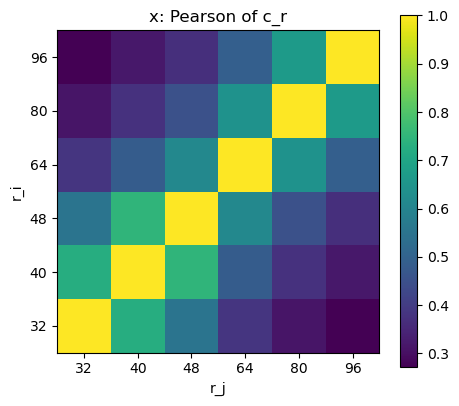

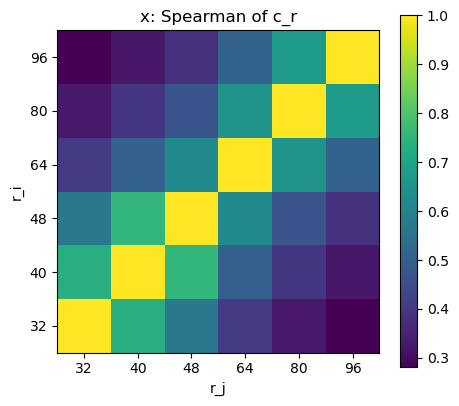

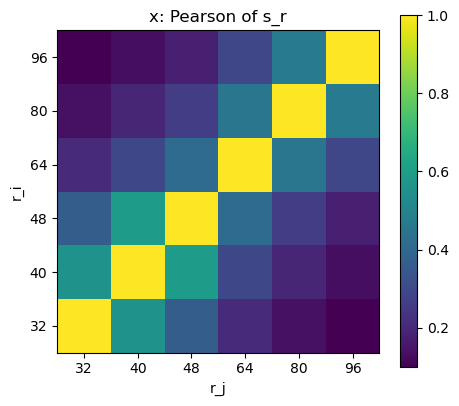

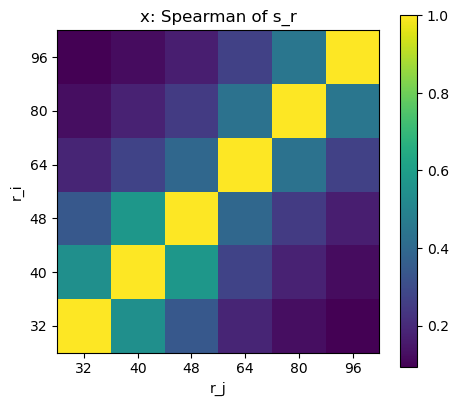

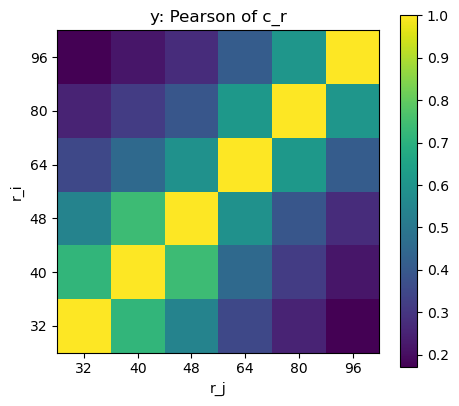

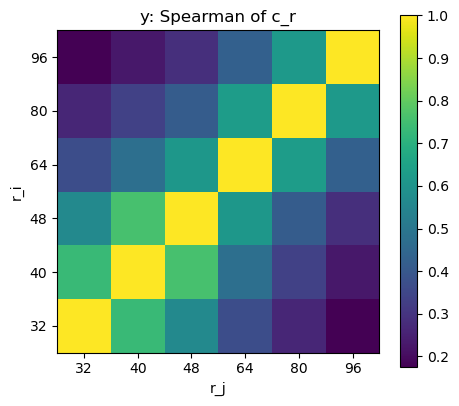

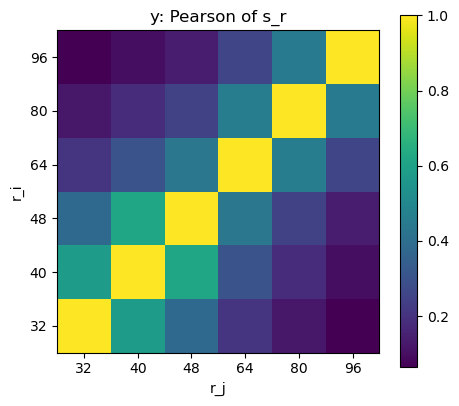

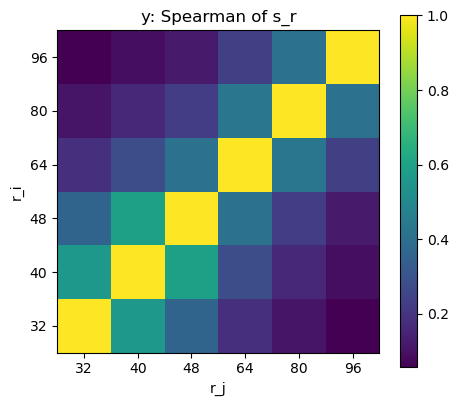

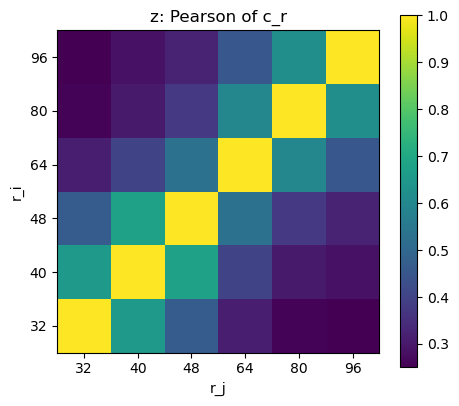

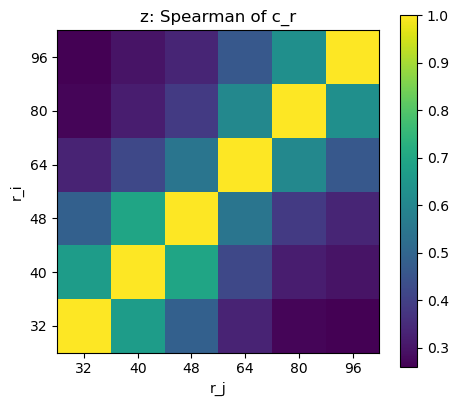

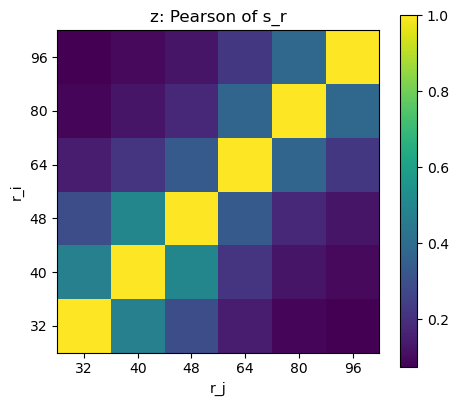

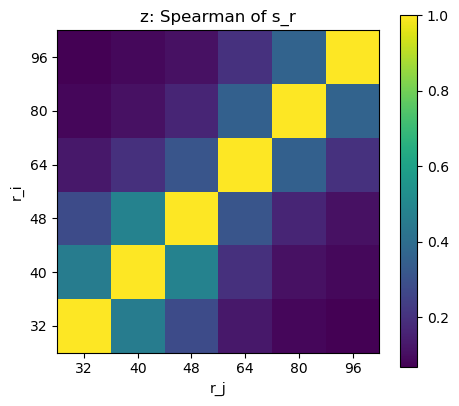

In [21]:
def show_matrix(M, title):
    plt.figure(figsize=(4.8, 4.2))
    plt.imshow(M, origin="lower")
    plt.colorbar()
    plt.xticks(range(len(scales)), scales)
    plt.yticks(range(len(scales)), scales)
    plt.xlabel("r_j")
    plt.ylabel("r_i")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for axis_name in ["x", "y", "z"]:
    show_matrix(results256[axis_name]["pearson_c"], f"{axis_name}: Pearson of c_r")
    show_matrix(results256[axis_name]["spearman_c"], f"{axis_name}: Spearman of c_r")
    show_matrix(results256[axis_name]["pearson_s"], f"{axis_name}: Pearson of s_r")
    show_matrix(results256[axis_name]["spearman_s"], f"{axis_name}: Spearman of s_r")

In [22]:
import json
import numpy as np
from scipy.stats import spearmanr

# Perpendicular directions only if B0 || z:
perp_axis_map = {"y": 1, "x": 2}

zp = u256 + b256
zm = u256 - b256

scales = [32, 40, 48, 64, 80, 96]
n_sample = 120000
rng = np.random.default_rng(0)

def paired_increment(arr, r, axis, max_r):
    n = arr.shape[axis]
    s0 = [slice(None)] * arr.ndim
    s1 = [slice(None)] * arr.ndim
    s0[axis] = slice(0, n - max_r)
    s1[axis] = slice(r, r + (n - max_r))
    return arr[tuple(s1)] - arr[tuple(s0)]

def alignment_fields_common_domain(zp, zm, scales, axis):
    max_r = max(scales)
    c_fields = {}
    s_fields = {}
    for r in scales:
        dzp = paired_increment(zp, r, axis, max_r)
        dzm = paired_increment(zm, r, axis, max_r)

        ap = np.linalg.norm(dzp, axis=-1)
        am = np.linalg.norm(dzm, axis=-1)
        denom = ap * am

        c = np.full(denom.shape, np.nan, dtype=np.float64)
        s = np.full(denom.shape, np.nan, dtype=np.float64)

        valid = denom > 0
        dot = np.sum(dzp * dzm, axis=-1)
        cross = np.linalg.norm(np.cross(dzp, dzm), axis=-1)

        c[valid] = dot[valid] / denom[valid]
        s[valid] = cross[valid] / denom[valid]

        c_fields[r] = c
        s_fields[r] = s
    return c_fields, s_fields

def pairwise_pearson(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]

def pairwise_spearman(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    res = spearmanr(a[m], b[m])
    return getattr(res, "statistic", getattr(res, "correlation", res[0]))

def build_matrices(c_fields, s_fields, scales, n_sample, rng):
    flat_size = c_fields[scales[0]].size
    idx = rng.choice(flat_size, size=min(n_sample, flat_size), replace=False)

    n = len(scales)
    Rcp = np.full((n, n), np.nan)
    Rcs = np.full((n, n), np.nan)
    Rsp = np.full((n, n), np.nan)
    Rss = np.full((n, n), np.nan)

    c_samp = {r: c_fields[r].reshape(-1)[idx] for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx] for r in scales}

    for i, ri in enumerate(scales):
        for j, rj in enumerate(scales):
            Rcp[i, j] = pairwise_pearson(c_samp[ri], c_samp[rj])
            Rcs[i, j] = pairwise_spearman(c_samp[ri], c_samp[rj])
            Rsp[i, j] = pairwise_pearson(s_samp[ri], s_samp[rj])
            Rss[i, j] = pairwise_spearman(s_samp[ri], s_samp[rj])

    return Rcp, Rcs, Rsp, Rss

results_perp = {}

for name, ax in perp_axis_map.items():
    c_fields, s_fields = alignment_fields_common_domain(zp, zm, scales, axis=ax)
    Rcp, Rcs, Rsp, Rss = build_matrices(c_fields, s_fields, scales, n_sample, rng)

    results_perp[name] = {
        "pearson_c": Rcp,
        "spearman_c": Rcs,
        "pearson_s": Rsp,
        "spearman_s": Rss,
    }

    print(f"\nPerp axis = {name}")
    print("Pearson(c):")
    print(Rcp)
    print("Spearman(c):")
    print(Rcs)
    print("Pearson(s):")
    print(Rsp)
    print("Spearman(s):")
    print(Rss)

# simple x/y perpendicular average
perp_avg = {}
for key in ["pearson_c", "spearman_c", "pearson_s", "spearman_s"]:
    perp_avg[key] = 0.5 * (results_perp["x"][key] + results_perp["y"][key])

print("\nPerpendicular average Pearson(c):")
print(perp_avg["pearson_c"])
print("\nPerpendicular average Spearman(c):")
print(perp_avg["spearman_c"])
print("\nPerpendicular average Pearson(s):")
print(perp_avg["pearson_s"])
print("\nPerpendicular average Spearman(s):")
print(perp_avg["spearman_s"])

out_perp = {
    "assumed_global_B0_direction": "z",
    "scales": scales,
    "n_sample": n_sample,
    "results_perp": {
        k: {kk: vv.tolist() for kk, vv in v.items()}
        for k, v in results_perp.items()
    },
    "perp_avg": {k: v.tolist() for k, v in perp_avg.items()}
}

with open(processed_dir / "pilot_alignment_crossscale_256cube_perp_assuming_B0z.json", "w") as f:
    json.dump(out_perp, f, indent=2)

print("\nSaved:")
print(processed_dir / "pilot_alignment_crossscale_256cube_perp_assuming_B0z.json")


Perp axis = y
Pearson(c):
[[1.         0.71603494 0.54003251 0.3522385  0.24752004 0.16930659]
 [0.71603494 1.         0.74237503 0.45566308 0.31113464 0.21900045]
 [0.54003251 0.74237503 1.         0.58743889 0.38460926 0.26749496]
 [0.3522385  0.45566308 0.58743889 1.         0.60812013 0.4093689 ]
 [0.24752004 0.31113464 0.38460926 0.60812013 1.         0.60998282]
 [0.16930659 0.21900045 0.26749496 0.4093689  0.60998282 1.        ]]
Spearman(c):
[[1.         0.73320162 0.56263618 0.36823172 0.2567763  0.17323699]
 [0.73320162 1.         0.76045469 0.47802771 0.32851501 0.22607177]
 [0.56263618 0.76045469 1.         0.61008011 0.40623965 0.28009305]
 [0.36823172 0.47802771 0.61008011 1.         0.62717165 0.42439342]
 [0.2567763  0.32851501 0.40623965 0.62717165 1.         0.62039087]
 [0.17323699 0.22607177 0.28009305 0.42439342 0.62039087 1.        ]]
Pearson(s):
[[1.         0.57816061 0.38131061 0.20337183 0.11843796 0.06011701]
 [0.57816061 1.         0.61101827 0.30240892 0.1

In [23]:
import numpy as np
import json
from pathlib import Path

# choose the scales
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]

# number of sampled spatial points for building correlations
n_sample = 200000   # reduce if too slow
rng = np.random.default_rng(12345)

# assume global B0 ~ z, so x and y are perpendicular directions
results_perp = {}
for axis_name in ["x", "y", "z"]:
    c_fields, s_fields = alignment_fields_common_domain(zp, zm, scales, axis=axis_name)
    Rcp, Rcs, Rsp, Rss = build_matrices(c_fields, s_fields, scales, n_sample, rng)

    results_perp[axis_name] = {
        "pearson_c": Rcp,
        "spearman_c": Rcs,
        "pearson_s": Rsp,
        "spearman_s": Rss,
    }

    print(f"\nAxis = {axis_name}")
    print("Pearson(c):")
    print(Rcp)
    print("Spearman(c):")
    print(Rcs)
    print("Pearson(s):")
    print(Rsp)
    print("Spearman(s):")
    print(Rss)

# x/y perpendicular average
perp_avg = {}
for key in ["pearson_c", "spearman_c", "pearson_s", "spearman_s"]:
    perp_avg[key] = 0.5 * (results_perp["x"][key] + results_perp["y"][key])

print("\nPerpendicular average Pearson(c):")
print(perp_avg["pearson_c"])
print("\nPerpendicular average Spearman(c):")
print(perp_avg["spearman_c"])
print("\nPerpendicular average Pearson(s):")
print(perp_avg["pearson_s"])
print("\nPerpendicular average Spearman(s):")
print(perp_avg["spearman_s"])

# optionally save
out_perp = {
    "assumed_global_B0_direction": "z",
    "scales": scales,
    "n_sample": n_sample,
    "results_perp": {
        k: {kk: vv.tolist() for kk, vv in v.items()}
        for k, v in results_perp.items()
    },
    "perp_avg": {k: v.tolist() for k, v in perp_avg.items()},
}

with open(processed_dir / "pilot_alignment_crossscale_256cube_perp_scales32-192.json", "w") as f:
    json.dump(out_perp, f, indent=2)

print("\nSaved:")
print(processed_dir / "pilot_alignment_crossscale_256cube_perp_scales32-192.json")

TypeError: tuple indices must be integers or slices, not str

In [24]:
import numpy as np
import json

# new inertial-range scale set
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]

n_sample = 200000
rng = np.random.default_rng(12345)

# map names to actual array axes for data shaped (z, y, x, 3)
axis_map = {"z": 0, "y": 1, "x": 2}

results_perp = {}
for axis_name, axis_int in axis_map.items():
    c_fields, s_fields = alignment_fields_common_domain(zp, zm, scales, axis=axis_int)
    Rcp, Rcs, Rsp, Rss = build_matrices(c_fields, s_fields, scales, n_sample, rng)

    results_perp[axis_name] = {
        "pearson_c": Rcp,
        "spearman_c": Rcs,
        "pearson_s": Rsp,
        "spearman_s": Rss,
    }

    print(f"\nAxis = {axis_name}")
    print("Pearson(c):")
    print(Rcp)
    print("Spearman(c):")
    print(Rcs)
    print("Pearson(s):")
    print(Rsp)
    print("Spearman(s):")
    print(Rss)

# x/y perpendicular average, assuming B0 || z
perp_avg = {}
for key in ["pearson_c", "spearman_c", "pearson_s", "spearman_s"]:
    perp_avg[key] = 0.5 * (results_perp["x"][key] + results_perp["y"][key])

print("\nPerpendicular average Pearson(c):")
print(perp_avg["pearson_c"])
print("\nPerpendicular average Spearman(c):")
print(perp_avg["spearman_c"])
print("\nPerpendicular average Pearson(s):")
print(perp_avg["pearson_s"])
print("\nPerpendicular average Spearman(s):")
print(perp_avg["spearman_s"])

out_perp = {
    "assumed_global_B0_direction": "z",
    "scales": scales,
    "n_sample": n_sample,
    "results_perp": {
        k: {kk: vv.tolist() for kk, vv in v.items()}
        for k, v in results_perp.items()
    },
    "perp_avg": {k: v.tolist() for k, v in perp_avg.items()},
}

with open(processed_dir / "pilot_alignment_crossscale_256cube_perp_scales32-192.json", "w") as f:
    json.dump(out_perp, f, indent=2)

print("\nSaved:")
print(processed_dir / "pilot_alignment_crossscale_256cube_perp_scales32-192.json")


Axis = z
Pearson(c):
[[1.         0.63759338 0.44357742 0.29372589 0.22806926 0.26800814
  0.24513808 0.27599097 0.28474488]
 [0.63759338 1.         0.65591633 0.37440258 0.28905268 0.30630848
  0.27280377 0.30041685 0.30984061]
 [0.44357742 0.65591633 1.         0.5037264  0.35502418 0.34377047
  0.29301761 0.31797789 0.322227  ]
 [0.29372589 0.37440258 0.5037264  1.         0.58299766 0.46521782
  0.39068956 0.32212394 0.33065896]
 [0.22806926 0.28905268 0.35502418 0.58299766 1.         0.64554161
  0.48673684 0.36131862 0.34341394]
 [0.26800814 0.30630848 0.34377047 0.46521782 0.64554161 1.
  0.5973471  0.4570125  0.44077022]
 [0.24513808 0.27280377 0.29301761 0.39068956 0.48673684 0.5973471
  1.         0.64855866 0.58058513]
 [0.27599097 0.30041685 0.31797789 0.32212394 0.36131862 0.4570125
  0.64855866 1.         0.69153032]
 [0.28474488 0.30984061 0.322227   0.33065896 0.34341394 0.44077022
  0.58058513 0.69153032 1.        ]]
Spearman(c):
[[1.         0.64909332 0.46159663 0.3

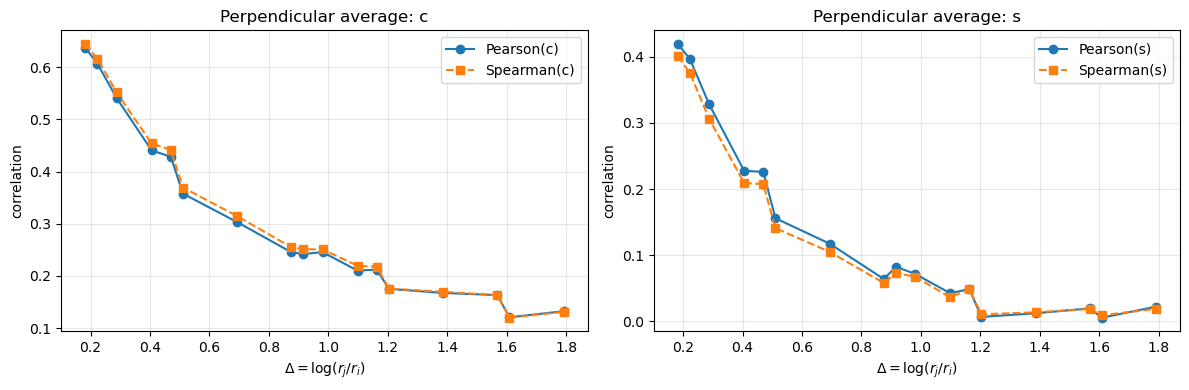

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def delta_pairs_and_values(scales, R):
    scales = np.asarray(scales, dtype=float)
    deltas = []
    vals = []
    n = len(scales)
    for i in range(n):
        for j in range(i + 1, n):
            deltas.append(np.log(scales[j] / scales[i]))
            vals.append(R[i, j])
    return np.array(deltas), np.array(vals)

def average_by_delta(deltas, values, decimals=10):
    d_rounded = np.round(deltas, decimals=decimals)
    unique_d = np.unique(d_rounded)
    mean_vals = np.array([values[d_rounded == d].mean() for d in unique_d])
    return unique_d, mean_vals

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# c_r
d_pc, v_pc = delta_pairs_and_values(scales, perp_avg["pearson_c"])
d_sc, v_sc = delta_pairs_and_values(scales, perp_avg["spearman_c"])
ud_pc, mv_pc = average_by_delta(d_pc, v_pc)
ud_sc, mv_sc = average_by_delta(d_sc, v_sc)

axes[0].plot(ud_pc, mv_pc, "o-", label="Pearson(c)")
axes[0].plot(ud_sc, mv_sc, "s--", label="Spearman(c)")
axes[0].set_xlabel(r"$\Delta=\log(r_j/r_i)$")
axes[0].set_ylabel("correlation")
axes[0].set_title("Perpendicular average: c")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# s_r
d_ps, v_ps = delta_pairs_and_values(scales, perp_avg["pearson_s"])
d_ss, v_ss = delta_pairs_and_values(scales, perp_avg["spearman_s"])
ud_ps, mv_ps = average_by_delta(d_ps, v_ps)
ud_ss, mv_ss = average_by_delta(d_ss, v_ss)

axes[1].plot(ud_ps, mv_ps, "o-", label="Pearson(s)")
axes[1].plot(ud_ss, mv_ss, "s--", label="Spearman(s)")
axes[1].set_xlabel(r"$\Delta=\log(r_j/r_i)$")
axes[1].set_ylabel("correlation")
axes[1].set_title("Perpendicular average: s")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# ---------------------------------------
# increments and alignment measures
# ---------------------------------------

axis_map = {"x": 0, "y": 1, "z": 2}

def paired_increment(arr, r, axis):
    """
    Paired increment over a common domain:
      delta_r f(x) = f(x + r e_axis) - f(x)
    using slices so all scales can be compared on the same base domain.
    Here axis is one of 'x','y','z' corresponding to array axes 2,1,0.
    """
    ax = axis_map[axis]
    
    # arr has shape (z, y, x, 3)
    # map coordinate axis to arr axis
    arr_ax = {"x": 2, "y": 1, "z": 0}[axis]
    
    s0 = [slice(None)] * arr.ndim
    s1 = [slice(None)] * arr.ndim
    s0[arr_ax] = slice(0, arr.shape[arr_ax] - r)
    s1[arr_ax] = slice(r, arr.shape[arr_ax])
    
    return arr[tuple(s1)] - arr[tuple(s0)]

def common_domain_increment(arr, r, axis, max_r):
    """
    Build increments on a common domain so all r use the same base points.
    The common domain removes max_r points along the chosen axis.
    """
    arr_ax = {"x": 2, "y": 1, "z": 0}[axis]
    
    s0 = [slice(None)] * arr.ndim
    s1 = [slice(None)] * arr.ndim
    
    s0[arr_ax] = slice(0, arr.shape[arr_ax] - max_r)
    s1[arr_ax] = slice(r, arr.shape[arr_ax] - max_r + r)
    
    return arr[tuple(s1)] - arr[tuple(s0)]

def alignment_fields_common_domain(zp, zm, scales, axis):
    """
    Returns dicts c_fields[r], s_fields[r], theta_fields[r], amp_fields[r]
    computed on the same base domain for all scales.
    
    c = cos(theta) = (dzp·dzm)/(|dzp||dzm|)
    s = |sin(theta)| = |dzp×dzm|/(|dzp||dzm|)
    theta = arccos(|c|) in [0, pi/2]  (unsigned alignment angle)
    amp = |dzp||dzm|
    """
    max_r = max(scales)
    c_fields = {}
    s_fields = {}
    theta_fields = {}
    amp_fields = {}
    
    for r in scales:
        dzp = common_domain_increment(zp, r, axis, max_r)
        dzm = common_domain_increment(zm, r, axis, max_r)
        
        ap = np.linalg.norm(dzp, axis=-1)
        am = np.linalg.norm(dzm, axis=-1)
        denom = ap * am
        
        dot = np.sum(dzp * dzm, axis=-1)
        cross = np.linalg.norm(np.cross(dzp, dzm), axis=-1)
        
        c = np.full_like(dot, np.nan, dtype=float)
        s = np.full_like(dot, np.nan, dtype=float)
        
        mask = denom > 0
        c[mask] = dot[mask] / denom[mask]
        s[mask] = cross[mask] / denom[mask]
        
        # clip for safety
        c = np.clip(c, -1.0, 1.0)
        s = np.clip(s,  0.0, 1.0)
        
        theta = np.arccos(np.abs(c))   # unsigned angle in [0, pi/2]
        
        c_fields[r] = c
        s_fields[r] = s
        theta_fields[r] = theta
        amp_fields[r] = denom
    
    return c_fields, s_fields, theta_fields, amp_fields

def flatten_valid(arr):
    a = np.asarray(arr).ravel()
    return a[np.isfinite(a)]

def pairwise_pearson(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return pearsonr(a[m], b[m])[0]

def pairwise_spearman(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    return spearmanr(a[m], b[m])[0]

def build_matrices(c_fields, s_fields, scales, n_sample=50000, seed=1234):
    """
    Build Pearson / Spearman correlation matrices between scales
    for c_r and s_r.
    """
    rng = np.random.default_rng(seed)
    
    c_samp = {}
    s_samp = {}
    for r in scales:
        c = flatten_valid(c_fields[r])
        s = flatten_valid(s_fields[r])
        
        n = min(n_sample, len(c))
        idx = rng.choice(len(c), size=n, replace=False)
        c_samp[r] = c[idx]
        s_samp[r] = s[idx]
    
    n = len(scales)
    Rcp = np.full((n, n), np.nan)
    Rcs = np.full((n, n), np.nan)
    Rsp = np.full((n, n), np.nan)
    Rss = np.full((n, n), np.nan)
    
    for i, ri in enumerate(scales):
        for j, rj in enumerate(scales):
            Rcp[i, j] = pairwise_pearson(c_samp[ri], c_samp[rj])
            Rcs[i, j] = pairwise_spearman(c_samp[ri], c_samp[rj])
            Rsp[i, j] = pairwise_pearson(s_samp[ri], s_samp[rj])
            Rss[i, j] = pairwise_spearman(s_samp[ri], s_samp[rj])
    
    return Rcp, Rcs, Rsp, Rss

def show_matrix(M, scales, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(M, origin="lower", cmap="viridis", vmin=np.nanmin(M), vmax=np.nanmax(M))
    plt.colorbar()
    plt.xticks(range(len(scales)), scales)
    plt.yticks(range(len(scales)), scales)
    plt.xlabel("r_j")
    plt.ylabel("r_i")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def ratio_pairs_and_values(scales, R):
    scales = np.asarray(scales, dtype=float)
    ratios = []
    vals = []
    n = len(scales)
    for i in range(n):
        for j in range(i + 1, n):
            ratios.append(scales[j] / scales[i])
            vals.append(R[i, j])
    return np.array(ratios), np.array(vals)

def average_by_ratio(ratios, values, decimals=10):
    rr = np.round(ratios, decimals=decimals)
    uniq = np.unique(rr)
    avg = np.array([values[rr == u].mean() for u in uniq])
    return uniq, avg

In [27]:
# Elsasser fields
zp = u256 + b256
zm = u256 - b256

# scales in inertial range
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]

# assuming global B0 ~ z
results = {}
for axis_name in ["x", "y", "z"]:
    c_fields, s_fields, theta_fields, amp_fields = alignment_fields_common_domain(zp, zm, scales, axis=axis_name)
    Rcp, Rcs, Rsp, Rss = build_matrices(c_fields, s_fields, scales, n_sample=50000, seed=1234)
    
    results[axis_name] = {
        "c_fields": c_fields,
        "s_fields": s_fields,
        "theta_fields": theta_fields,
        "amp_fields": amp_fields,
        "pearson_c": Rcp,
        "spearman_c": Rcs,
        "pearson_s": Rsp,
        "spearman_s": Rss,
    }

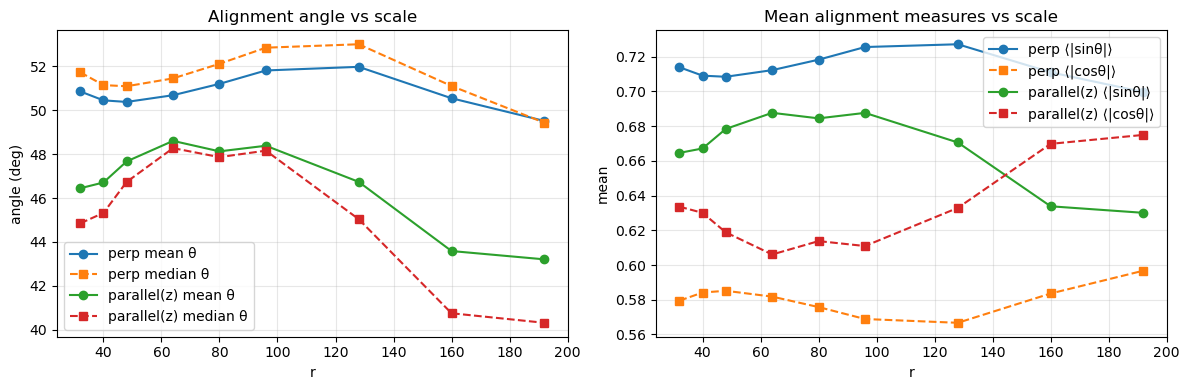

In [28]:
def mean_median_vs_scale(theta_fields, s_fields, c_fields, scales):
    mean_theta = []
    med_theta = []
    mean_s = []
    mean_abs_c = []
    
    for r in scales:
        th = flatten_valid(theta_fields[r])
        ss = flatten_valid(s_fields[r])
        cc = flatten_valid(c_fields[r])
        
        mean_theta.append(np.mean(th))
        med_theta.append(np.median(th))
        mean_s.append(np.mean(ss))
        mean_abs_c.append(np.mean(np.abs(cc)))
    
    return np.array(mean_theta), np.array(med_theta), np.array(mean_s), np.array(mean_abs_c)

# perpendicular average x/y
mean_theta_x, med_theta_x, mean_s_x, mean_abs_c_x = mean_median_vs_scale(
    results["x"]["theta_fields"], results["x"]["s_fields"], results["x"]["c_fields"], scales
)
mean_theta_y, med_theta_y, mean_s_y, mean_abs_c_y = mean_median_vs_scale(
    results["y"]["theta_fields"], results["y"]["s_fields"], results["y"]["c_fields"], scales
)
mean_theta_z, med_theta_z, mean_s_z, mean_abs_c_z = mean_median_vs_scale(
    results["z"]["theta_fields"], results["z"]["s_fields"], results["z"]["c_fields"], scales
)

mean_theta_perp = 0.5 * (mean_theta_x + mean_theta_y)
med_theta_perp  = 0.5 * (med_theta_x + med_theta_y)
mean_s_perp     = 0.5 * (mean_s_x + mean_s_y)
mean_abs_c_perp = 0.5 * (mean_abs_c_x + mean_abs_c_y)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(scales, mean_theta_perp * 180/np.pi, "o-", label="perp mean θ")
plt.plot(scales, med_theta_perp  * 180/np.pi, "s--", label="perp median θ")
plt.plot(scales, mean_theta_z    * 180/np.pi, "o-", label="parallel(z) mean θ")
plt.plot(scales, med_theta_z     * 180/np.pi, "s--", label="parallel(z) median θ")
plt.xlabel("r")
plt.ylabel("angle (deg)")
plt.title("Alignment angle vs scale")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(scales, mean_s_perp, "o-", label="perp ⟨|sinθ|⟩")
plt.plot(scales, mean_abs_c_perp, "s--", label="perp ⟨|cosθ|⟩")
plt.plot(scales, mean_s_z, "o-", label="parallel(z) ⟨|sinθ|⟩")
plt.plot(scales, mean_abs_c_z, "s--", label="parallel(z) ⟨|cosθ|⟩")
plt.xlabel("r")
plt.ylabel("mean")
plt.title("Mean alignment measures vs scale")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

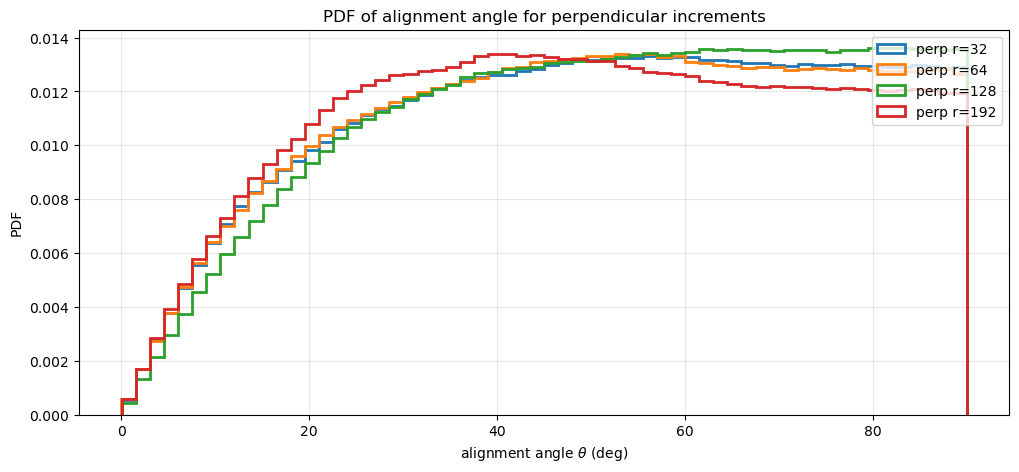

In [29]:
sample_scales = [32, 64, 128, 192]

plt.figure(figsize=(12,5))

# perpendicular average from x and y combined
for r in sample_scales:
    theta_x = flatten_valid(results["x"]["theta_fields"][r]) * 180/np.pi
    theta_y = flatten_valid(results["y"]["theta_fields"][r]) * 180/np.pi
    theta_perp = np.concatenate([theta_x, theta_y])
    
    plt.hist(theta_perp, bins=60, density=True, histtype="step", linewidth=2, label=f"perp r={r}")

plt.xlabel(r"alignment angle $\theta$ (deg)")
plt.ylabel("PDF")
plt.title("PDF of alignment angle for perpendicular increments")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

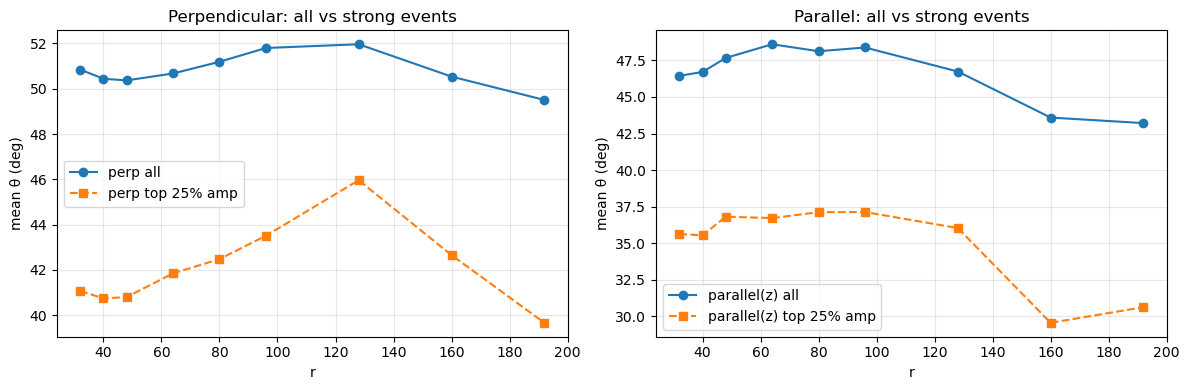

In [30]:
def conditioned_theta_stats(theta_fields, amp_fields, scales, q=0.75):
    mean_theta = []
    med_theta = []
    for r in scales:
        th = theta_fields[r]
        amp = amp_fields[r]
        
        m = np.isfinite(th) & np.isfinite(amp)
        th = th[m]
        amp = amp[m]
        
        thr = np.quantile(amp, q)
        mc = amp >= thr
        
        mean_theta.append(np.mean(th[mc]))
        med_theta.append(np.median(th[mc]))
    return np.array(mean_theta), np.array(med_theta)

# all points (perp average)
all_mean_theta_perp = mean_theta_perp
all_med_theta_perp  = med_theta_perp

# conditioned on strong events
mean_theta_x_q, med_theta_x_q = conditioned_theta_stats(results["x"]["theta_fields"], results["x"]["amp_fields"], scales, q=0.75)
mean_theta_y_q, med_theta_y_q = conditioned_theta_stats(results["y"]["theta_fields"], results["y"]["amp_fields"], scales, q=0.75)
mean_theta_z_q, med_theta_z_q = conditioned_theta_stats(results["z"]["theta_fields"], results["z"]["amp_fields"], scales, q=0.75)

mean_theta_perp_q = 0.5*(mean_theta_x_q + mean_theta_y_q)
med_theta_perp_q  = 0.5*(med_theta_x_q + med_theta_y_q)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(scales, all_mean_theta_perp*180/np.pi, "o-", label="perp all")
plt.plot(scales, mean_theta_perp_q*180/np.pi, "s--", label="perp top 25% amp")
plt.xlabel("r")
plt.ylabel("mean θ (deg)")
plt.title("Perpendicular: all vs strong events")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(scales, mean_theta_z*180/np.pi, "o-", label="parallel(z) all")
plt.plot(scales, mean_theta_z_q*180/np.pi, "s--", label="parallel(z) top 25% amp")
plt.xlabel("r")
plt.ylabel("mean θ (deg)")
plt.title("Parallel: all vs strong events")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

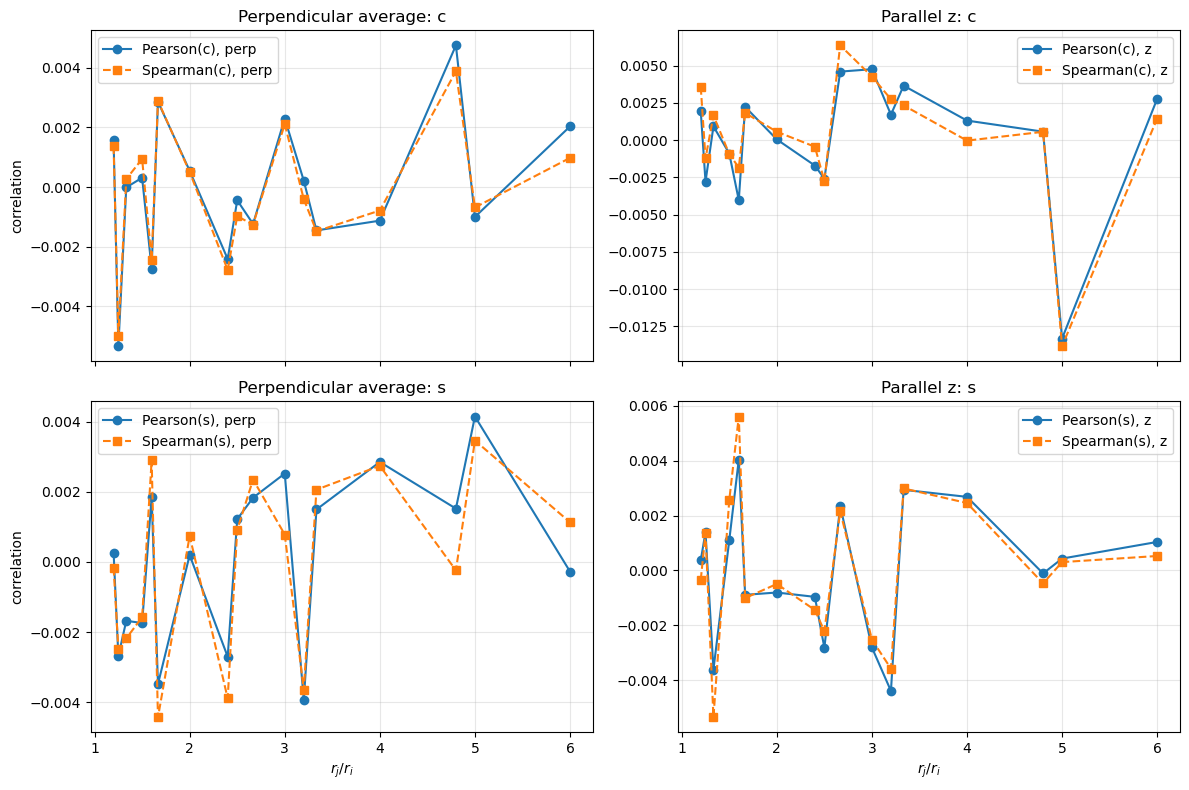

In [31]:
# perpendicular average of matrices
perp_avg = {}
for key in ["pearson_c", "spearman_c", "pearson_s", "spearman_s"]:
    perp_avg[key] = 0.5 * (results["x"][key] + results["y"][key])

fig, axes = plt.subplots(2, 2, figsize=(12,8), sharex=True)

# c: perpendicular
r_pc, v_pc = ratio_pairs_and_values(scales, perp_avg["pearson_c"])
r_sc, v_sc = ratio_pairs_and_values(scales, perp_avg["spearman_c"])
ur_pc, mv_pc = average_by_ratio(r_pc, v_pc)
ur_sc, mv_sc = average_by_ratio(r_sc, v_sc)

axes[0,0].plot(ur_pc, mv_pc, "o-", label="Pearson(c), perp")
axes[0,0].plot(ur_sc, mv_sc, "s--", label="Spearman(c), perp")
axes[0,0].set_title("Perpendicular average: c")
axes[0,0].set_ylabel("correlation")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

# c: parallel
r_pc_z, v_pc_z = ratio_pairs_and_values(scales, results["z"]["pearson_c"])
r_sc_z, v_sc_z = ratio_pairs_and_values(scales, results["z"]["spearman_c"])
ur_pc_z, mv_pc_z = average_by_ratio(r_pc_z, v_pc_z)
ur_sc_z, mv_sc_z = average_by_ratio(r_sc_z, v_sc_z)

axes[0,1].plot(ur_pc_z, mv_pc_z, "o-", label="Pearson(c), z")
axes[0,1].plot(ur_sc_z, mv_sc_z, "s--", label="Spearman(c), z")
axes[0,1].set_title("Parallel z: c")
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# s: perpendicular
r_ps, v_ps = ratio_pairs_and_values(scales, perp_avg["pearson_s"])
r_ss, v_ss = ratio_pairs_and_values(scales, perp_avg["spearman_s"])
ur_ps, mv_ps = average_by_ratio(r_ps, v_ps)
ur_ss, mv_ss = average_by_ratio(r_ss, v_ss)

axes[1,0].plot(ur_ps, mv_ps, "o-", label="Pearson(s), perp")
axes[1,0].plot(ur_ss, mv_ss, "s--", label="Spearman(s), perp")
axes[1,0].set_title("Perpendicular average: s")
axes[1,0].set_xlabel(r"$r_j/r_i$")
axes[1,0].set_ylabel("correlation")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# s: parallel
r_ps_z, v_ps_z = ratio_pairs_and_values(scales, results["z"]["pearson_s"])
r_ss_z, v_ss_z = ratio_pairs_and_values(scales, results["z"]["spearman_s"])
ur_ps_z, mv_ps_z = average_by_ratio(r_ps_z, v_ps_z)
ur_ss_z, mv_ss_z = average_by_ratio(r_ss_z, v_ss_z)

axes[1,1].plot(ur_ps_z, mv_ps_z, "o-", label="Pearson(s), z")
axes[1,1].plot(ur_ss_z, mv_ss_z, "s--", label="Spearman(s), z")
axes[1,1].set_title("Parallel z: s")
axes[1,1].set_xlabel(r"$r_j/r_i$")
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

plt.tight_layout()
plt.show()

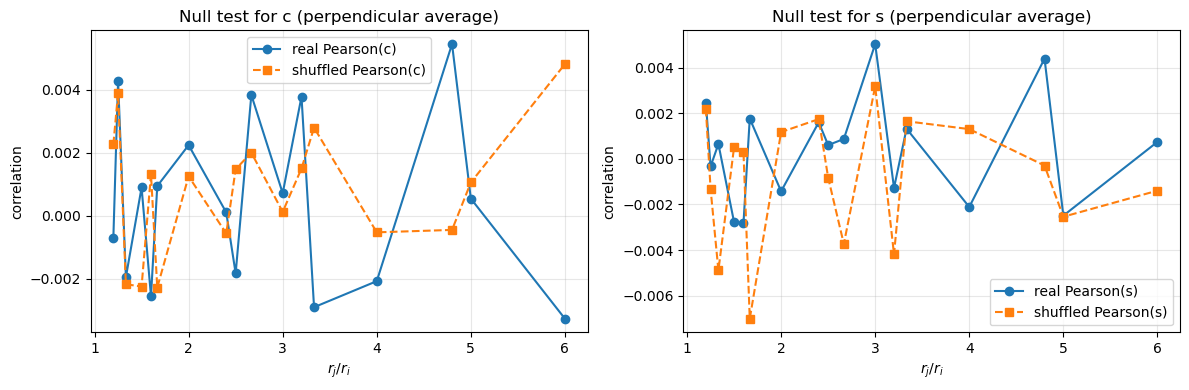

In [32]:
def shuffled_correlation_vs_ratio(fields, scales, corr="pearson", n_sample=50000, seed=1234):
    rng = np.random.default_rng(seed)
    
    ratios = []
    corr_real = []
    corr_shuf = []
    
    # sample arrays once for each scale
    samp = {}
    for r in scales:
        arr = flatten_valid(fields[r])
        n = min(n_sample, len(arr))
        idx = rng.choice(len(arr), size=n, replace=False)
        samp[r] = arr[idx]
    
    n = len(scales)
    for i in range(n):
        for j in range(i + 1, n):
            ri, rj = scales[i], scales[j]
            a = samp[ri]
            b = samp[rj]
            m = min(len(a), len(b))
            a = a[:m]
            b = b[:m]
            
            if corr == "pearson":
                real = pearsonr(a, b)[0]
                b_shuf = b.copy()
                rng.shuffle(b_shuf)
                shuf = pearsonr(a, b_shuf)[0]
            else:
                real = spearmanr(a, b)[0]
                b_shuf = b.copy()
                rng.shuffle(b_shuf)
                shuf = spearmanr(a, b_shuf)[0]
            
            ratios.append(rj / ri)
            corr_real.append(real)
            corr_shuf.append(shuf)
    
    return np.array(ratios), np.array(corr_real), np.array(corr_shuf)

# use perpendicular average by concatenating x and y
c_perp = {}
s_perp = {}
for r in scales:
    c_perp[r] = np.concatenate([flatten_valid(results["x"]["c_fields"][r]),
                                flatten_valid(results["y"]["c_fields"][r])])
    s_perp[r] = np.concatenate([flatten_valid(results["x"]["s_fields"][r]),
                                flatten_valid(results["y"]["s_fields"][r])])

r1, real_c, shuf_c = shuffled_correlation_vs_ratio(c_perp, scales, corr="pearson", n_sample=50000, seed=1234)
r2, real_s, shuf_s = shuffled_correlation_vs_ratio(s_perp, scales, corr="pearson", n_sample=50000, seed=1234)

ur1, mr1 = average_by_ratio(r1, real_c)
_, ms1   = average_by_ratio(r1, shuf_c)

ur2, mr2 = average_by_ratio(r2, real_s)
_, ms2   = average_by_ratio(r2, shuf_s)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(ur1, mr1, "o-", label="real Pearson(c)")
plt.plot(ur1, ms1, "s--", label="shuffled Pearson(c)")
plt.xlabel(r"$r_j/r_i$")
plt.ylabel("correlation")
plt.title("Null test for c (perpendicular average)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(ur2, mr2, "o-", label="real Pearson(s)")
plt.plot(ur2, ms2, "s--", label="shuffled Pearson(s)")
plt.xlabel(r"$r_j/r_i$")
plt.ylabel("correlation")
plt.title("Null test for s (perpendicular average)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -------------------------------------------------
# Geometry and helper functions
# Data shape is (z, y, x, 3)
# -------------------------------------------------

axis_to_arr_axis = {"x": 2, "y": 1, "z": 0}

def common_domain_increment(arr, r, axis_name, max_r):
    """
    Non-wrapping increment on a common base domain.
    For all scales, the base points x are restricted so every r uses
    the same set of base points.
    """
    arr_ax = axis_to_arr_axis[axis_name]
    n = arr.shape[arr_ax]

    s0 = [slice(None)] * arr.ndim
    s1 = [slice(None)] * arr.ndim

    s0[arr_ax] = slice(0, n - max_r)
    s1[arr_ax] = slice(r, r + (n - max_r))

    return arr[tuple(s1)] - arr[tuple(s0)]

def base_domain_crop(arr, axis_name, max_r):
    """
    Crop a scalar field to the same common base domain used for increments.
    """
    arr_ax = axis_to_arr_axis[axis_name]
    n = arr.shape[arr_ax]

    s = [slice(None)] * arr.ndim
    s[arr_ax] = slice(0, n - max_r)
    return arr[tuple(s)]

def alignment_fields_common_domain(zp, zm, scales, axis_name):
    """
    For each r, compute on the same base domain:
      c_r(x) = cos(theta_r(x))
      s_r(x) = |sin(theta_r(x))|
      theta_r(x) = arccos(|c_r(x)|)  in [0, pi/2]
      A_r(x) = |delta z^+| |delta z^-|
    """
    max_r = max(scales)

    c_fields = {}
    s_fields = {}
    theta_fields = {}
    amp_fields = {}

    for r in scales:
        dzp = common_domain_increment(zp, r, axis_name, max_r)
        dzm = common_domain_increment(zm, r, axis_name, max_r)

        ap = np.linalg.norm(dzp, axis=-1)
        am = np.linalg.norm(dzm, axis=-1)
        denom = ap * am

        dot = np.sum(dzp * dzm, axis=-1)
        cross = np.linalg.norm(np.cross(dzp, dzm), axis=-1)

        c = np.full(dot.shape, np.nan, dtype=float)
        s = np.full(dot.shape, np.nan, dtype=float)

        mask = denom > 0
        c[mask] = dot[mask] / denom[mask]
        s[mask] = cross[mask] / denom[mask]

        c = np.clip(c, -1.0, 1.0)
        s = np.clip(s,  0.0, 1.0)

        theta = np.arccos(np.abs(c))   # unsigned local alignment angle

        c_fields[r] = c
        s_fields[r] = s
        theta_fields[r] = theta
        amp_fields[r] = denom

    return c_fields, s_fields, theta_fields, amp_fields

def current_density_magnitude(b):
    """
    j = curl b
    Using grid spacing = 1 in index units.
    For top-quantile masking, the overall constant factor does not matter.
    """
    bx = b[..., 0]
    by = b[..., 1]
    bz = b[..., 2]

    dbx_dz, dbx_dy, dbx_dx = np.gradient(bx, 1.0, 1.0, 1.0, edge_order=2)
    dby_dz, dby_dy, dby_dx = np.gradient(by, 1.0, 1.0, 1.0, edge_order=2)
    dbz_dz, dbz_dy, dbz_dx = np.gradient(bz, 1.0, 1.0, 1.0, edge_order=2)

    jx = dbz_dy - dby_dz
    jy = dbx_dz - dbz_dx
    jz = dby_dx - dbx_dy

    jmag = np.sqrt(jx**2 + jy**2 + jz**2)
    return jmag

def finite_quantile(arr, q):
    a = np.asarray(arr)
    a = a[np.isfinite(a)]
    return np.quantile(a, q)

def mean_theta_curve(theta_fields, scales, mask_fields=None):
    """
    Mean unsigned angle vs r.
    If mask_fields is given, use only points where mask_fields[r] is True.
    """
    out = []
    for r in scales:
        th = theta_fields[r]
        if mask_fields is None:
            m = np.isfinite(th)
        else:
            m = np.isfinite(th) & mask_fields[r]
        out.append(np.mean(th[m]))
    return np.array(out)

def build_matrices_same_points(c_fields, s_fields, scales, n_sample=100000, seed=1234):
    """
    Correct cross-scale matrices:
    use the SAME sampled base points for every r.
    """
    rng = np.random.default_rng(seed)

    flat_size = c_fields[scales[0]].size
    valid = np.ones(flat_size, dtype=bool)

    for r in scales:
        valid &= np.isfinite(c_fields[r].reshape(-1))
        valid &= np.isfinite(s_fields[r].reshape(-1))

    available = np.where(valid)[0]
    if len(available) == 0:
        raise RuntimeError("No common finite sample points across scales.")

    idx = rng.choice(available, size=min(n_sample, len(available)), replace=False)

    c_samp = {r: c_fields[r].reshape(-1)[idx] for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx] for r in scales}

    def pairwise_pearson(a, b):
        return np.corrcoef(a, b)[0, 1]

    def pairwise_spearman(a, b):
        res = spearmanr(a, b)
        return getattr(res, "statistic", getattr(res, "correlation", res[0]))

    n = len(scales)
    Rcp = np.full((n, n), np.nan)
    Rcs = np.full((n, n), np.nan)
    Rsp = np.full((n, n), np.nan)
    Rss = np.full((n, n), np.nan)

    for i, ri in enumerate(scales):
        for j, rj in enumerate(scales):
            Rcp[i, j] = pairwise_pearson(c_samp[ri], c_samp[rj])
            Rcs[i, j] = pairwise_spearman(c_samp[ri], c_samp[rj])
            Rsp[i, j] = pairwise_pearson(s_samp[ri], s_samp[rj])
            Rss[i, j] = pairwise_spearman(s_samp[ri], s_samp[rj])

    return Rcp, Rcs, Rsp, Rss

In [34]:
# Elsasser fields
zp = u256 + b256
zm = u256 - b256

# inertial-range scales you requested
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]

# current density magnitude
jmag = current_density_magnitude(b256)

results_clean = {}

for axis_name in ["x", "y", "z"]:
    c_fields, s_fields, theta_fields, amp_fields = alignment_fields_common_domain(
        zp, zm, scales, axis_name
    )

    # current-density field on the same base domain
    j_base = base_domain_crop(jmag, axis_name, max(scales))

    results_clean[axis_name] = {
        "c_fields": c_fields,
        "s_fields": s_fields,
        "theta_fields": theta_fields,
        "amp_fields": amp_fields,
        "j_base": j_base,
    }

print("Computed clean alignment fields for x, y, z.")

Computed clean alignment fields for x, y, z.


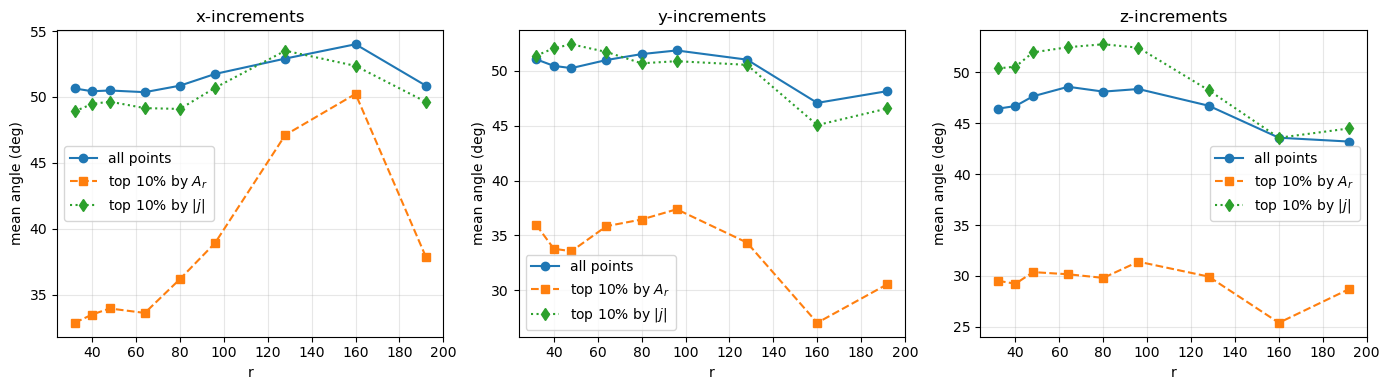

In [35]:
q = 0.90   # top 10%

plt.figure(figsize=(14, 4))

for k, axis_name in enumerate(["x", "y", "z"], start=1):
    theta_fields = results_clean[axis_name]["theta_fields"]
    amp_fields   = results_clean[axis_name]["amp_fields"]
    j_base       = results_clean[axis_name]["j_base"]

    # all points
    mean_all = mean_theta_curve(theta_fields, scales)

    # top-q by A_r, scale by scale
    mask_A = {}
    for r in scales:
        thrA = finite_quantile(amp_fields[r], q)
        mask_A[r] = amp_fields[r] >= thrA
    mean_A = mean_theta_curve(theta_fields, scales, mask_A)

    # top-q by |j|, same mask for every r on the common domain
    thrJ = finite_quantile(j_base, q)
    mask_J_const = j_base >= thrJ
    mask_J = {r: mask_J_const for r in scales}
    mean_J = mean_theta_curve(theta_fields, scales, mask_J)

    plt.subplot(1, 3, k)
    plt.plot(scales, mean_all * 180/np.pi, "o-", label="all points")
    plt.plot(scales, mean_A   * 180/np.pi, "s--", label=r"top 10% by $A_r$")
    plt.plot(scales, mean_J   * 180/np.pi, "d:", label=r"top 10% by $|j|$")
    plt.xlabel("r")
    plt.ylabel("mean angle (deg)")
    plt.title(f"{axis_name}-increments")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

In [36]:
matrices_clean = {}

for axis_name in ["x", "y", "z"]:
    c_fields = results_clean[axis_name]["c_fields"]
    s_fields = results_clean[axis_name]["s_fields"]

    Rcp, Rcs, Rsp, Rss = build_matrices_same_points(
        c_fields, s_fields, scales, n_sample=120000, seed=1234
    )

    matrices_clean[axis_name] = {
        "pearson_c": Rcp,
        "spearman_c": Rcs,
        "pearson_s": Rsp,
        "spearman_s": Rss,
    }

    print(f"\nAxis = {axis_name}")
    print("Pearson(c):")
    print(Rcp)
    print("Spearman(c):")
    print(Rcs)
    print("Pearson(s):")
    print(Rsp)
    print("Spearman(s):")
    print(Rss)

# save
out_clean = {
    "scales": scales,
    "results_clean": {
        ax: {k: v.tolist() for k, v in matrices_clean[ax].items()}
        for ax in matrices_clean
    }
}

with open(processed_dir / "pilot_alignment_crossscale_256cube_clean_r32_192.json", "w") as f:
    json.dump(out_clean, f, indent=2)

print("\nSaved:")
print(processed_dir / "pilot_alignment_crossscale_256cube_clean_r32_192.json")


Axis = x
Pearson(c):
[[1.         0.66667071 0.48762906 0.34517626 0.29108572 0.27314533
  0.2239287  0.18455357 0.18935219]
 [0.66667071 1.         0.69513553 0.44151612 0.34853532 0.31211817
  0.27443164 0.21792745 0.22068978]
 [0.48762906 0.69513553 1.         0.56104549 0.43134875 0.37195492
  0.31850559 0.24676886 0.24187202]
 [0.34517626 0.44151612 0.56104549 1.         0.62930377 0.49364512
  0.39166629 0.29790537 0.27020082]
 [0.29108572 0.34853532 0.43134875 0.62930377 1.         0.67340327
  0.4684873  0.33237278 0.29219096]
 [0.27314533 0.31211817 0.37195492 0.49364512 0.67340327 1.
  0.56335997 0.38541674 0.315728  ]
 [0.2239287  0.27443164 0.31850559 0.39166629 0.4684873  0.56335997
  1.         0.57395755 0.42122853]
 [0.18455357 0.21792745 0.24676886 0.29790537 0.33237278 0.38541674
  0.57395755 1.         0.58036747]
 [0.18935219 0.22068978 0.24187202 0.27020082 0.29219096 0.315728
  0.42122853 0.58036747 1.        ]]
Spearman(c):
[[1.         0.67613599 0.50177239 0.3

In [37]:
import numpy as np

def explicit_increment(arr, r, axis_name, iz, iy, ix):
    if axis_name == "x":
        return arr[iz, iy, ix + r, :] - arr[iz, iy, ix, :]
    elif axis_name == "y":
        return arr[iz, iy + r, ix, :] - arr[iz, iy, ix, :]
    elif axis_name == "z":
        return arr[iz + r, iy, ix, :] - arr[iz, iy, ix, :]
    else:
        raise ValueError("axis_name must be x, y, or z")

def check_axis_mapping(arr, r=32, ntests=20, seed=0):
    rng = np.random.default_rng(seed)
    max_r = r

    for axis_name in ["x", "y", "z"]:
        inc = common_domain_increment(arr, r, axis_name, max_r)

        errs = []
        for _ in range(ntests):
            # choose a point in the common base domain
            iz = rng.integers(0, inc.shape[0])
            iy = rng.integers(0, inc.shape[1])
            ix = rng.integers(0, inc.shape[2])

            lhs = inc[iz, iy, ix, :]
            rhs = explicit_increment(arr, r, axis_name, iz, iy, ix)

            errs.append(np.max(np.abs(lhs - rhs)))

        print(axis_name, "max error =", np.max(errs))

print("Checking axis mapping on zp:")
check_axis_mapping(zp, r=32, ntests=50, seed=0)

print("\nChecking axis mapping on zm:")
check_axis_mapping(zm, r=32, ntests=50, seed=1)

Checking axis mapping on zp:
x max error = 0.0
y max error = 0.0
z max error = 0.0

Checking axis mapping on zm:
x max error = 0.0
y max error = 0.0
z max error = 0.0


In [38]:
matrices_real = {}

for axis_name in ["x", "y", "z"]:
    c_fields = results_clean[axis_name]["c_fields"]
    s_fields = results_clean[axis_name]["s_fields"]

    Rcp, Rcs, Rsp, Rss = build_matrices_same_points(
        c_fields, s_fields, scales, n_sample=120000, seed=1234
    )

    matrices_real[axis_name] = {
        "pearson_c": Rcp,
        "spearman_c": Rcs,
        "pearson_s": Rsp,
        "spearman_s": Rss,
    }

print("Rebuilt real matrices.")

Rebuilt real matrices.


In [39]:
def sample_same_points(axis_name, scales, n_sample=120000, seed=1234):
    rng = np.random.default_rng(seed)

    c_fields = results_clean[axis_name]["c_fields"]
    s_fields = results_clean[axis_name]["s_fields"]
    A_fields = results_clean[axis_name]["amp_fields"]
    j_base   = results_clean[axis_name]["j_base"]

    flat_size = c_fields[scales[0]].size
    valid = np.ones(flat_size, dtype=bool)

    for r in scales:
        valid &= np.isfinite(c_fields[r].reshape(-1))
        valid &= np.isfinite(s_fields[r].reshape(-1))
        valid &= np.isfinite(A_fields[r].reshape(-1))

    valid &= np.isfinite(j_base.reshape(-1))

    available = np.where(valid)[0]
    idx = rng.choice(available, size=min(n_sample, len(available)), replace=False)

    c_samp = {r: c_fields[r].reshape(-1)[idx].copy() for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx].copy() for r in scales}
    A_samp = {r: A_fields[r].reshape(-1)[idx].copy() for r in scales}
    j_samp = j_base.reshape(-1)[idx].copy()

    return c_samp, s_samp, A_samp, j_samp

def matrices_from_samples(c_samp, s_samp, scales):
    def pairwise_pearson(a, b):
        return np.corrcoef(a, b)[0, 1]

    def pairwise_spearman(a, b):
        res = spearmanr(a, b)
        return getattr(res, "statistic", getattr(res, "correlation", res[0]))

    n = len(scales)
    Rcp = np.full((n, n), np.nan)
    Rcs = np.full((n, n), np.nan)
    Rsp = np.full((n, n), np.nan)
    Rss = np.full((n, n), np.nan)

    for i, ri in enumerate(scales):
        for j, rj in enumerate(scales):
            Rcp[i, j] = pairwise_pearson(c_samp[ri], c_samp[rj])
            Rcs[i, j] = pairwise_spearman(c_samp[ri], c_samp[rj])
            Rsp[i, j] = pairwise_pearson(s_samp[ri], s_samp[rj])
            Rss[i, j] = pairwise_spearman(s_samp[ri], s_samp[rj])

    return Rcp, Rcs, Rsp, Rss

samples = {}
for axis_name in ["x", "y", "z"]:
    samples[axis_name] = sample_same_points(axis_name, scales, n_sample=120000, seed=1234)

print("Prepared common samples for surrogates.")

Prepared common samples for surrogates.


In [40]:
def surrogate_full_shuffle(c_samp, s_samp, scales, seed=1234):
    rng = np.random.default_rng(seed)

    c_shuf = {}
    s_shuf = {}

    for r in scales:
        perm = rng.permutation(len(c_samp[r]))
        c_shuf[r] = c_samp[r][perm]
        s_shuf[r] = s_samp[r][perm]

    return c_shuf, s_shuf

sur_full = {}

for axis_name in ["x", "y", "z"]:
    c_samp, s_samp, A_samp, j_samp = samples[axis_name]
    c_shuf, s_shuf = surrogate_full_shuffle(c_samp, s_samp, scales, seed=1234)

    sur_full[axis_name] = matrices_from_samples(c_shuf, s_shuf, scales)

print("Built full-shuffle surrogates.")

Built full-shuffle surrogates.


In [41]:
def permute_within_bins(values, bins, rng):
    out = values.copy()
    for b in np.unique(bins):
        idx = np.where(bins == b)[0]
        if len(idx) > 1:
            out[idx] = out[idx][rng.permutation(len(idx))]
    return out

def surrogate_within_A_bins(c_samp, s_samp, A_samp, scales, nbins=10, seed=1234):
    rng = np.random.default_rng(seed)

    c_out = {}
    s_out = {}

    for r in scales:
        edges = np.quantile(A_samp[r], np.linspace(0, 1, nbins + 1))
        edges[0] -= 1e-12
        edges[-1] += 1e-12
        bins = np.digitize(A_samp[r], edges[1:-1], right=True)

        c_out[r] = permute_within_bins(c_samp[r], bins, rng)
        s_out[r] = permute_within_bins(s_samp[r], bins, rng)

    return c_out, s_out

sur_A = {}

for axis_name in ["x", "y", "z"]:
    c_samp, s_samp, A_samp, j_samp = samples[axis_name]
    c_shuf, s_shuf = surrogate_within_A_bins(c_samp, s_samp, A_samp, scales, nbins=10, seed=1234)

    sur_A[axis_name] = matrices_from_samples(c_shuf, s_shuf, scales)

print("Built A_r-binned surrogates.")

Built A_r-binned surrogates.


In [42]:
def surrogate_within_j_bins(c_samp, s_samp, j_samp, scales, nbins=10, seed=1234):
    rng = np.random.default_rng(seed)

    edges = np.quantile(j_samp, np.linspace(0, 1, nbins + 1))
    edges[0] -= 1e-12
    edges[-1] += 1e-12
    bins = np.digitize(j_samp, edges[1:-1], right=True)

    c_out = {}
    s_out = {}

    for r in scales:
        c_out[r] = permute_within_bins(c_samp[r], bins, rng)
        s_out[r] = permute_within_bins(s_samp[r], bins, rng)

    return c_out, s_out

sur_j = {}

for axis_name in ["x", "y", "z"]:
    c_samp, s_samp, A_samp, j_samp = samples[axis_name]
    c_shuf, s_shuf = surrogate_within_j_bins(c_samp, s_samp, j_samp, scales, nbins=10, seed=1234)

    sur_j[axis_name] = matrices_from_samples(c_shuf, s_shuf, scales)

print("Built |j|-binned surrogates.")

Built |j|-binned surrogates.


In [43]:
def mean_offdiag(M):
    n = M.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return np.mean(M[mask])

for axis_name in ["x", "y", "z"]:
    print(f"\n=== Axis {axis_name} ===")

    real = matrices_real[axis_name]
    full = sur_full[axis_name]
    A    = sur_A[axis_name]
    J    = sur_j[axis_name]

    labels = ["pearson_c", "spearman_c", "pearson_s", "spearman_s"]

    for i, lab in enumerate(labels):
        print(
            lab,
            " real =", round(mean_offdiag(real[lab]), 4),
            " full-shuffle =", round(mean_offdiag(full[i]), 4),
            " A-bin shuffle =", round(mean_offdiag(A[i]), 4),
            " j-bin shuffle =", round(mean_offdiag(J[i]), 4),
        )


=== Axis x ===
pearson_c  real = 0.3898  full-shuffle = -0.0  A-bin shuffle = 0.024  j-bin shuffle = 0.001
spearman_c  real = 0.3981  full-shuffle = -0.0001  A-bin shuffle = 0.0284  j-bin shuffle = 0.0011
pearson_s  real = 0.1646  full-shuffle = -0.0  A-bin shuffle = 0.0211  j-bin shuffle = 0.0
spearman_s  real = 0.1552  full-shuffle = 0.0  A-bin shuffle = 0.0194  j-bin shuffle = 0.0

=== Axis y ===
pearson_c  real = 0.3035  full-shuffle = 0.0008  A-bin shuffle = 0.0257  j-bin shuffle = 0.0038
spearman_c  real = 0.3118  full-shuffle = 0.0008  A-bin shuffle = 0.0291  j-bin shuffle = 0.0038
pearson_s  real = 0.1614  full-shuffle = 0.0002  A-bin shuffle = 0.0323  j-bin shuffle = 0.0003
spearman_s  real = 0.1493  full-shuffle = -0.0  A-bin shuffle = 0.0286  j-bin shuffle = 0.0002

=== Axis z ===
pearson_c  real = 0.4072  full-shuffle = 0.0008  A-bin shuffle = 0.0262  j-bin shuffle = 0.0029
spearman_c  real = 0.4206  full-shuffle = 0.0008  A-bin shuffle = 0.0314  j-bin shuffle = 0.0034
pea

In [44]:
from pathlib import Path
import json

root = Path.home() / "workspace" / "Storage" / "elenceq" / "mhd_work" / "jhtdb_mhd1024"

manifest = {
    "date": "2026-04-17",
    "dataset": "mhd1024",
    "cube": {
        "velocity": str(root / "raw_cutouts" / "mhd1024_velocity_t0001_x1-256_y1-256_z1-256.npy"),
        "magneticfield": str(root / "raw_cutouts" / "mhd1024_magneticfield_t0001_x1-256_y1-256_z1-256.npy"),
    },
    "corrected_results": {
        "crossscale_matrices": str(root / "processed" / "pilot_alignment_crossscale_256cube_clean_r32_192.json"),
    },
    "scales": [32, 40, 48, 64, 80, 96, 128, 160, 192],
    "definitions": {
        "elsasser_fields": "zplus = u + b, zminus = u - b",
        "increments": "delta_r z^\u00b1(x) = z^\u00b1(x + r ehat) - z^\u00b1(x)",
        "local_angle": "angle between delta_r zplus and delta_r zminus",
        "A_r": "|delta_r zplus| * |delta_r zminus|",
        "jmag": "|curl b|",
    },
    "current_status": {
        "axis_mapping_verified": True,
        "surrogates_done": True,
        "whole_perpendicular_plane_done": False,
        "note": "x and y were treated as separate axis directions only; full xy-plane averaging remains to do."
    }
}

with open(root / "processed" / "workflow_manifest_2026-04-17.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(root / "processed" / "workflow_manifest_2026-04-17.json")

/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/workflow_manifest_2026-04-17.json


In [45]:
readme = """
mhd1024 alignment workflow summary
=================================

Working root:
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024

Downloaded:
  - 256^3 velocity cube
  - 256^3 magneticfield cube

Corrected physics workflow:
  1. Build Elsasser fields z+ = u+b, z- = u-b
  2. Build non-wrapping Elsasser increments on a common base domain
  3. Compute local angle theta_r(x) between delta_r z+ and delta_r z-
  4. Compute c_r = cos(theta_r), s_r = |sin(theta_r)|
  5. Build corrected cross-scale matrices using the SAME sampled base points across scales
  6. Condition mean-angle curves on:
       - all points
       - top 10% by A_r = |delta z+||delta z-|
       - top 10% by |j|
  7. Build surrogates:
       - full shuffle
       - A_r-binned shuffle
       - |j|-binned shuffle

Important caveat:
  Current x,y,z results are axis-resolved probes only.
  Full perpendicular-plane averaging in the xy plane remains to do.

Key current conclusion:
  Cross-scale alignment organization is real and not explained by amplitude or |j| alone.
"""

with open(root / "processed" / "README_workflow_2026-04-17.txt", "w") as f:
    f.write(readme)

print(root / "processed" / "README_workflow_2026-04-17.txt")

/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/README_workflow_2026-04-17.txt


In [46]:
import shutil
from pathlib import Path

src = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/alignment_final_figures.zip")
dst = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/alignment_final_figures.zip")

shutil.copy2(src, dst)
print("Copied to:", dst)

Copied to: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/alignment_final_figures.zip


In [47]:
import zipfile
from pathlib import Path

fig_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures")
zip_path = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/prl_main_figures.zip")

files = [
    fig_dir / "ensemble_mean_angle_320cubes_fixedlegend_v5.pdf",
    fig_dir / "ensemble_mean_angle_320cubes_fixedlegend_v5.png",
    fig_dir / "ensemble_crossscale_and_surrogates_320cubes.pdf",
    fig_dir / "ensemble_crossscale_and_surrogates_320cubes.png",
    fig_dir / "ensemble_320cubes_summary.json",
]

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for f in files:
        if f.exists():
            zf.write(f, arcname=f.name)
        else:
            print("Missing:", f)

print("Created:", zip_path)

Created: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/prl_main_figures.zip


In [48]:
# ============================================================
# MAKE CLEAN PAPER FILES:
#   main1.pdf/png   = final mean-angle figure
#   main2A.pdf/png  = ensemble Pearson(c) matrix
#   main2B.pdf/png  = ensemble Pearson(s) matrix
#   main2C.pdf/png  = surrogate summary
# from already saved final figures / ensemble summary
# ============================================================

import json
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
fig_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures")

# ------------------------------------------------------------
# 1) COPY FINAL INTRODUCTION FIGURE -> main1
# ------------------------------------------------------------
# take latest fixedlegend version
main1_candidates_pdf = sorted(fig_dir.glob("ensemble_mean_angle_320cubes_fixedlegend_v*.pdf"))
main1_candidates_png = sorted(fig_dir.glob("ensemble_mean_angle_320cubes_fixedlegend_v*.png"))

assert len(main1_candidates_pdf) > 0, "Could not find final mean-angle PDF."
assert len(main1_candidates_png) > 0, "Could not find final mean-angle PNG."

src_main1_pdf = main1_candidates_pdf[-1]
src_main1_png = main1_candidates_png[-1]

dst_main1_pdf = fig_dir / "main1.pdf"
dst_main1_png = fig_dir / "main1.png"

shutil.copy2(src_main1_pdf, dst_main1_pdf)
shutil.copy2(src_main1_png, dst_main1_png)

print("Copied:")
print(" ", src_main1_pdf.name, "->", dst_main1_pdf.name)
print(" ", src_main1_png.name, "->", dst_main1_png.name)

# ------------------------------------------------------------
# 2) LOAD ENSEMBLE SUMMARY JSON
# ------------------------------------------------------------
summary_candidates = [
    fig_dir / "ensemble_320cubes_summary.json",
    fig_dir / "ensemble_summary.json",
]

summary_path = None
for p in summary_candidates:
    if p.exists():
        summary_path = p
        break

assert summary_path is not None, "Could not find ensemble summary JSON."

with open(summary_path, "r") as f:
    summ = json.load(f)

print("Loaded summary:", summary_path.name)

scales = np.array(summ["scales"], dtype=float)

Rcp = np.array(summ["pearson_c"]["mean"], dtype=float)
Rsp = np.array(summ["pearson_s"]["mean"], dtype=float)

sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]

sur_c_mean = np.array([summ["surrogate_summary"]["pearson_c"][lab]["mean"] for lab in sur_labels], dtype=float)
sur_c_sem  = np.array([summ["surrogate_summary"]["pearson_c"][lab]["sem"]  for lab in sur_labels], dtype=float)
sur_s_mean = np.array([summ["surrogate_summary"]["pearson_s"][lab]["mean"] for lab in sur_labels], dtype=float)
sur_s_sem  = np.array([summ["surrogate_summary"]["pearson_s"][lab]["sem"]  for lab in sur_labels], dtype=float)

sur_c_all = [np.array(summ["surrogate_summary"]["pearson_c"][lab]["all_cubes"], dtype=float) for lab in sur_labels]
sur_s_all = [np.array(summ["surrogate_summary"]["pearson_s"][lab]["all_cubes"], dtype=float) for lab in sur_labels]

# ------------------------------------------------------------
# helper for faint individual points
# ------------------------------------------------------------
def jittered_scatter(ax, x0, values, width=0.08, alpha=0.25, s=18, marker="o", seed=0):
    if len(values) == 0:
        return
    rng = np.random.default_rng(seed)
    xx = x0 + rng.uniform(-width, width, size=len(values))
    ax.scatter(xx, values, alpha=alpha, s=s, marker=marker)

# ------------------------------------------------------------
# 3) main2A = Pearson(c)
# ------------------------------------------------------------
figA, axA = plt.subplots(figsize=(6.2, 5.8))
imA = axA.imshow(Rcp, origin="lower", cmap="viridis", vmin=np.min(Rcp), vmax=np.max(Rcp))
axA.set_title(r"Ensemble Pearson of $c_r=\cos\theta_r$")
axA.set_xticks(range(len(scales)))
axA.set_yticks(range(len(scales)))
axA.set_xticklabels(scales.astype(int))
axA.set_yticklabels(scales.astype(int))
axA.set_xlabel(r"$r_j$")
axA.set_ylabel(r"$r_i$")
cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04)
cbarA.set_label("correlation")
figA.tight_layout()

main2A_pdf = fig_dir / "main2A.pdf"
main2A_png = fig_dir / "main2A.png"
figA.savefig(main2A_pdf, bbox_inches="tight")
figA.savefig(main2A_png, dpi=400, bbox_inches="tight")
plt.close(figA)

# ------------------------------------------------------------
# 4) main2B = Pearson(s)
# ------------------------------------------------------------
figB, axB = plt.subplots(figsize=(6.2, 5.8))
imB = axB.imshow(Rsp, origin="lower", cmap="viridis", vmin=np.min(Rsp), vmax=np.max(Rsp))
axB.set_title(r"Ensemble Pearson of $s_r=|\sin\theta_r|$")
axB.set_xticks(range(len(scales)))
axB.set_yticks(range(len(scales)))
axB.set_xticklabels(scales.astype(int))
axB.set_yticklabels(scales.astype(int))
axB.set_xlabel(r"$r_j$")
axB.set_ylabel(r"$r_i$")
cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04)
cbarB.set_label("correlation")
figB.tight_layout()

main2B_pdf = fig_dir / "main2B.pdf"
main2B_png = fig_dir / "main2B.png"
figB.savefig(main2B_pdf, bbox_inches="tight")
figB.savefig(main2B_png, dpi=400, bbox_inches="tight")
plt.close(figB)

# ------------------------------------------------------------
# 5) main2C = surrogate summary
# ------------------------------------------------------------
figC, axC = plt.subplots(figsize=(6.2, 5.8))

x = np.arange(len(sur_labels))
offset = 0.14

for i, vals in enumerate(sur_c_all):
    jittered_scatter(axC, x[i] - offset, vals, marker="o", alpha=0.22, s=22, seed=100+i)

for i, vals in enumerate(sur_s_all):
    jittered_scatter(axC, x[i] + offset, vals, marker="s", alpha=0.22, s=22, seed=200+i)

axC.errorbar(x - offset, sur_c_mean, yerr=sur_c_sem, fmt="o", capsize=3, linewidth=1.5, label=r"$c_r$")
axC.errorbar(x + offset, sur_s_mean, yerr=sur_s_sem, fmt="s", capsize=3, linewidth=1.5, label=r"$s_r$")

axC.set_xticks(x)
axC.set_xticklabels(["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"],
                    rotation=15)
axC.set_ylabel("mean off-diagonal correlation")
axC.set_title("Surrogate summary")
axC.grid(True, alpha=0.3, axis="y")
axC.legend(frameon=True)

figC.tight_layout()

main2C_pdf = fig_dir / "main2C.pdf"
main2C_png = fig_dir / "main2C.png"
figC.savefig(main2C_pdf, bbox_inches="tight")
figC.savefig(main2C_png, dpi=400, bbox_inches="tight")
plt.close(figC)

# ------------------------------------------------------------
# final printout
# ------------------------------------------------------------
print("\nSaved clean paper files:")
for p in [dst_main1_pdf, dst_main1_png, main2A_pdf, main2A_png, main2B_pdf, main2B_png, main2C_pdf, main2C_png]:
    print(" ", p)

Copied:
  ensemble_mean_angle_320cubes_fixedlegend_v5.pdf -> main1.pdf
  ensemble_mean_angle_320cubes_fixedlegend_v5.png -> main1.png
Loaded summary: ensemble_320cubes_summary.json

Saved clean paper files:
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main1.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main1.png
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2A.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2A.png
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2B.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2B.png
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2C.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2C.png


In [49]:
# ============================================================
# MAKE SUPPLEMENTARY FIGURE:
#   mainS2.pdf/png = representative pairwise dependence plots
#
# This recomputes only a SMALL targeted diagnostic from saved raw cubes.
# It pools samples over the 10 saved 320^3 cubes and all stored phi values,
# using only the selected scales needed for the figure.
#
# REQUIRED:
#   alignment_fields_xy_plane(...) must already be defined in the notebook.
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
processed_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")
fig_dir = processed_dir / "final_figures"

# ------------------------------------------------------------
# load valid per-cube JSON records
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

records = []
for path in json_files:
    with open(path, "r") as f:
        d = json.load(f)
    if not looks_like_320cube(d, path):
        continue
    # keep only proper per-cube records with raw file paths
    if "raw_files" not in d:
        continue
    if "velocity" not in d["raw_files"] or "magneticfield" not in d["raw_files"]:
        continue
    records.append(d)

print("Using", len(records), "cube records for mainS2")
assert len(records) == 10, f"Expected 10 usable cube records, found {len(records)}"

# ------------------------------------------------------------
# helper: same-point sampling for selected scales only
# ------------------------------------------------------------
def sample_same_points_selected(c_fields, s_fields, scales, n_sample=12000, seed=1234):
    rng = np.random.default_rng(seed)
    flat_size = c_fields[scales[0]].size
    valid = np.ones(flat_size, dtype=bool)
    for r in scales:
        valid &= np.isfinite(c_fields[r].reshape(-1))
        valid &= np.isfinite(s_fields[r].reshape(-1))
    idx_all = np.where(valid)[0]
    assert len(idx_all) > 0, "No valid points found."
    idx = rng.choice(idx_all, size=min(n_sample, len(idx_all)), replace=False)
    c_samp = {r: c_fields[r].reshape(-1)[idx].copy() for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx].copy() for r in scales}
    return c_samp, s_samp

def pair_stats(x, y):
    pear = np.corrcoef(x, y)[0, 1]
    spear = spearmanr(x, y).statistic
    return float(pear), float(spear)

# ------------------------------------------------------------
# selected scales / pairs
# ------------------------------------------------------------
selected_scales = [48, 64, 96, 160]
pair_specs = [
    ("c", 64, 96),
    ("c", 48, 160),
    ("s", 64, 96),
    ("s", 48, 160),
]

# pooled arrays
pool = {
    ("c", 64, 96): [[], []],
    ("c", 48, 160): [[], []],
    ("s", 64, 96): [[], []],
    ("s", 48, 160): [[], []],
}

# ------------------------------------------------------------
# loop over cubes and stored phis
# ------------------------------------------------------------
for icube, d in enumerate(records):
    u = np.load(d["raw_files"]["velocity"])
    b = np.load(d["raw_files"]["magneticfield"])

    zp = u + b
    zm = u - b

    phis = d.get("phis", list(np.linspace(0.0, np.pi, 8, endpoint=False)))

    print(f"cube {icube+1}/{len(records)}: {d['cube']['tag']}")

    for iphi, phi in enumerate(phis):
        domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
            zp, zm, selected_scales, float(phi)
        )

        c_samp, s_samp = sample_same_points_selected(
            c_fields, s_fields, selected_scales, n_sample=12000, seed=1000 + 100*icube + iphi
        )

        for kind, r1, r2 in pair_specs:
            if kind == "c":
                x = c_samp[r1]
                y = c_samp[r2]
            else:
                x = s_samp[r1]
                y = s_samp[r2]
            pool[(kind, r1, r2)][0].append(x)
            pool[(kind, r1, r2)][1].append(y)

# concatenate pooled samples
for key in pool:
    pool[key][0] = np.concatenate(pool[key][0])
    pool[key][1] = np.concatenate(pool[key][1])

# ------------------------------------------------------------
# plot mainS2
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.2))

panel_order = [
    ("c", 64, 96, axes[0, 0]),
    ("c", 48, 160, axes[0, 1]),
    ("s", 64, 96, axes[1, 0]),
    ("s", 48, 160, axes[1, 1]),
]

for kind, r1, r2, ax in panel_order:
    x, y = pool[(kind, r1, r2)]
    pear, spear = pair_stats(x, y)

    hb = ax.hexbin(x, y, gridsize=45, mincnt=1, cmap="viridis")
    fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)

    if kind == "c":
        ax.set_xlabel(rf"$c_{{{r1}}}$")
        ax.set_ylabel(rf"$c_{{{r2}}}$")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
    else:
        ax.set_xlabel(rf"$s_{{{r1}}}$")
        ax.set_ylabel(rf"$s_{{{r2}}}$")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    ax.set_title(rf"{kind}-pair: $r={r1}$ vs $r={r2}$")
    ax.text(
        0.04, 0.96,
        rf"$R={pear:.3f}$" + "\n" + rf"$\rho={spear:.3f}$",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

fig.tight_layout()

mainS2_pdf = fig_dir / "mainS2.pdf"
mainS2_png = fig_dir / "mainS2.png"
fig.savefig(mainS2_pdf, bbox_inches="tight")
fig.savefig(mainS2_png, dpi=400, bbox_inches="tight")
plt.close(fig)

print("\nSaved:")
print(" ", mainS2_pdf)
print(" ", mainS2_png)

Using 8 cube records for mainS2


AssertionError: Expected 10 usable cube records, found 8

In [50]:
# ============================================================
# ROBUST mainS2 CREATION
# - handles old audit JSONs that do not contain raw_files
# - reconstructs raw cube paths from metadata or filename
# - makes:
#     mainS2.pdf
#     mainS2.png
#
# REQUIRED:
#   alignment_fields_xy_plane(...) must already be defined
# ============================================================

import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
raw_dir = base_dir / "raw"
fig_dir = processed_dir / "final_figures"

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def get_tag(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "tag" in d["cube"]:
        return str(d["cube"]["tag"])

    stem = path.stem
    for pref in ["audit_alignment_crossscale_", "audit_alignment_"]:
        if stem.startswith(pref):
            stem = stem[len(pref):]
    stem = stem.replace("_xyplane_interp_r32_192", "")
    return stem

def infer_raw_paths(d, path, raw_dir):
    # newest schema
    if "raw_files" in d and isinstance(d["raw_files"], dict):
        vel = d["raw_files"].get("velocity", None)
        mag = d["raw_files"].get("magneticfield", None)
        if vel is not None and mag is not None:
            vpath = Path(vel)
            bpath = Path(mag)
            if vpath.exists() and bpath.exists():
                return vpath, bpath

    # metadata-based exact reconstruction
    if "cube" in d and isinstance(d["cube"], dict):
        cube = d["cube"]
        if all(k in cube for k in ["time", "x", "y", "z"]):
            t = int(cube["time"])
            x = cube["x"]
            y = cube["y"]
            z = cube["z"]
            vpath = raw_dir / f"mhd1024_velocity_t{t:04d}_x{x[0]}-{x[1]}_y{y[0]}-{y[1]}_z{z[0]}-{z[1]}.npy"
            bpath = raw_dir / f"mhd1024_magneticfield_t{t:04d}_x{x[0]}-{x[1]}_y{y[0]}-{y[1]}_z{z[0]}-{z[1]}.npy"
            if vpath.exists() and bpath.exists():
                return vpath, bpath

    # fallback: infer time from filename/tag and search raw_dir
    tag = get_tag(d, path)
    m = re.search(r"_t(\d+)", tag)
    if m is None:
        raise FileNotFoundError(f"Could not infer time index from tag/filename for {path.name}")

    t = int(m.group(1))
    v_matches = sorted(raw_dir.glob(f"mhd1024_velocity_t{t:04d}_*.npy"))
    b_matches = sorted(raw_dir.glob(f"mhd1024_magneticfield_t{t:04d}_*.npy"))

    if len(v_matches) == 1 and len(b_matches) == 1:
        return v_matches[0], b_matches[0]

    raise FileNotFoundError(
        f"Could not uniquely infer raw cube files for {path.name}: "
        f"{len(v_matches)} velocity matches, {len(b_matches)} magnetic matches"
    )

def sample_same_points_selected(c_fields, s_fields, scales, n_sample=12000, seed=1234):
    rng = np.random.default_rng(seed)
    flat_size = c_fields[scales[0]].size
    valid = np.ones(flat_size, dtype=bool)
    for r in scales:
        valid &= np.isfinite(c_fields[r].reshape(-1))
        valid &= np.isfinite(s_fields[r].reshape(-1))
    idx_all = np.where(valid)[0]
    assert len(idx_all) > 0, "No valid points found."
    idx = rng.choice(idx_all, size=min(n_sample, len(idx_all)), replace=False)
    c_samp = {r: c_fields[r].reshape(-1)[idx].copy() for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx].copy() for r in scales}
    return c_samp, s_samp

def pair_stats(x, y):
    pear = np.corrcoef(x, y)[0, 1]
    spear = spearmanr(x, y).statistic
    return float(pear), float(spear)

# ------------------------------------------------------------
# collect records robustly
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

used = []
skipped = []

for path in json_files:
    try:
        with open(path, "r") as f:
            d = json.load(f)

        if not looks_like_320cube(d, path):
            skipped.append((path.name, "not recognized as 320^3 cube"))
            continue

        vpath, bpath = infer_raw_paths(d, path, raw_dir)

        used.append({
            "json_path": path,
            "tag": get_tag(d, path),
            "phis": d.get("phis", list(np.linspace(0.0, np.pi, 8, endpoint=False))),
            "velocity_path": vpath,
            "magnetic_path": bpath,
        })

    except Exception as e:
        skipped.append((path.name, str(e)))

print("USED cube records:", len(used))
for rec in used:
    print("  ", rec["tag"], " <-- ", rec["json_path"].name)
    print("      velocity:", rec["velocity_path"].name)
    print("      magnetic:", rec["magnetic_path"].name)

print("\nSKIPPED:", len(skipped))
for name, reason in skipped:
    print("  ", name, " <-- ", reason)

assert len(used) == 10, f"Expected 10 usable cube records after fallback, found {len(used)}"

# ------------------------------------------------------------
# selected scales / pairs
# ------------------------------------------------------------
selected_scales = [48, 64, 96, 160]
pair_specs = [
    ("c", 64, 96),
    ("c", 48, 160),
    ("s", 64, 96),
    ("s", 48, 160),
]

pool = {
    ("c", 64, 96): [[], []],
    ("c", 48, 160): [[], []],
    ("s", 64, 96): [[], []],
    ("s", 48, 160): [[], []],
}

# ------------------------------------------------------------
# recompute only the small targeted diagnostic
# ------------------------------------------------------------
for icube, rec in enumerate(used):
    print(f"\nCube {icube+1}/{len(used)}: {rec['tag']}")

    u = np.load(rec["velocity_path"])
    b = np.load(rec["magnetic_path"])

    zp = u + b
    zm = u - b

    for iphi, phi in enumerate(rec["phis"]):
        domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
            zp, zm, selected_scales, float(phi)
        )

        c_samp, s_samp = sample_same_points_selected(
            c_fields, s_fields, selected_scales, n_sample=12000, seed=1000 + 100*icube + iphi
        )

        for kind, r1, r2 in pair_specs:
            if kind == "c":
                x = c_samp[r1]
                y = c_samp[r2]
            else:
                x = s_samp[r1]
                y = s_samp[r2]
            pool[(kind, r1, r2)][0].append(x)
            pool[(kind, r1, r2)][1].append(y)

# concatenate pooled samples
for key in pool:
    pool[key][0] = np.concatenate(pool[key][0])
    pool[key][1] = np.concatenate(pool[key][1])

# ------------------------------------------------------------
# plot mainS2
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.2))

panel_order = [
    ("c", 64, 96, axes[0, 0]),
    ("c", 48, 160, axes[0, 1]),
    ("s", 64, 96, axes[1, 0]),
    ("s", 48, 160, axes[1, 1]),
]

for kind, r1, r2, ax in panel_order:
    x, y = pool[(kind, r1, r2)]
    pear, spear = pair_stats(x, y)

    hb = ax.hexbin(x, y, gridsize=45, mincnt=1, cmap="viridis")
    fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)

    if kind == "c":
        ax.set_xlabel(rf"$c_{{{r1}}}$")
        ax.set_ylabel(rf"$c_{{{r2}}}$")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
    else:
        ax.set_xlabel(rf"$s_{{{r1}}}$")
        ax.set_ylabel(rf"$s_{{{r2}}}$")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    ax.set_title(rf"{kind}-pair: $r={r1}$ vs $r={r2}$")
    ax.text(
        0.04, 0.96,
        rf"$R={pear:.3f}$" + "\n" + rf"$\rho={spear:.3f}$",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

fig.tight_layout()

mainS2_pdf = fig_dir / "mainS2.pdf"
mainS2_png = fig_dir / "mainS2.png"
fig.savefig(mainS2_pdf, bbox_inches="tight")
fig.savefig(mainS2_png, dpi=400, bbox_inches="tight")
plt.close(fig)

print("\nSaved:")
print(" ", mainS2_pdf)
print(" ", mainS2_png)

USED cube records: 8
   320cube_S1_t21  <--  320cube_S1_t21_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0021_x1-320_y1-320_z1-320.npy
      magnetic: mhd1024_magneticfield_t0021_x1-320_y1-320_z1-320.npy
   320cube_S1_t33  <--  320cube_S1_t33_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0033_x1-320_y1-320_z1-320.npy
      magnetic: mhd1024_magneticfield_t0033_x1-320_y1-320_z1-320.npy
   320cube_S1_t9  <--  320cube_S1_t9_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0009_x1-320_y1-320_z1-320.npy
      magnetic: mhd1024_magneticfield_t0009_x1-320_y1-320_z1-320.npy
   320cube_S2_t13  <--  320cube_S2_t13_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0013_x321-640_y321-640_z321-640.npy
      magnetic: mhd1024_magneticfield_t0013_x321-640_y321-640_z321-640.npy
   320cube_S2_t25  <--  320cube_S2_t25_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0025_x321-640_y321-640_z321-640.npy
      magnetic: mhd1024_magnetic

AssertionError: Expected 10 usable cube records after fallback, found 8

In [52]:
# ============================================================
# ROBUST mainS2 CREATION
# - handles old audit JSONs that do not contain raw_files
# - reconstructs raw cube paths from metadata or filename
# - makes:
#     mainS2.pdf
#     mainS2.png
#
# REQUIRED:
#   alignment_fields_xy_plane(...) must already be defined
# ============================================================

import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
raw_dir = base_dir / "raw"
fig_dir = processed_dir / "final_figures"

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def get_tag(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "tag" in d["cube"]:
        return str(d["cube"]["tag"])

    stem = path.stem
    for pref in ["audit_alignment_crossscale_", "audit_alignment_"]:
        if stem.startswith(pref):
            stem = stem[len(pref):]
    stem = stem.replace("_xyplane_interp_r32_192", "")
    return stem

def infer_raw_paths(d, path, raw_dir):
    # newest schema
    if "raw_files" in d and isinstance(d["raw_files"], dict):
        vel = d["raw_files"].get("velocity", None)
        mag = d["raw_files"].get("magneticfield", None)
        if vel is not None and mag is not None:
            vpath = Path(vel)
            bpath = Path(mag)
            if vpath.exists() and bpath.exists():
                return vpath, bpath

    # metadata-based exact reconstruction
    if "cube" in d and isinstance(d["cube"], dict):
        cube = d["cube"]
        if all(k in cube for k in ["time", "x", "y", "z"]):
            t = int(cube["time"])
            x = cube["x"]
            y = cube["y"]
            z = cube["z"]
            vpath = raw_dir / f"mhd1024_velocity_t{t:04d}_x{x[0]}-{x[1]}_y{y[0]}-{y[1]}_z{z[0]}-{z[1]}.npy"
            bpath = raw_dir / f"mhd1024_magneticfield_t{t:04d}_x{x[0]}-{x[1]}_y{y[0]}-{y[1]}_z{z[0]}-{z[1]}.npy"
            if vpath.exists() and bpath.exists():
                return vpath, bpath

    # fallback: infer time from filename/tag and search raw_dir
    tag = get_tag(d, path)
    m = re.search(r"_t(\d+)", tag)
    if m is None:
        raise FileNotFoundError(f"Could not infer time index from tag/filename for {path.name}")

    t = int(m.group(1))
    v_matches = sorted(raw_dir.glob(f"mhd1024_velocity_t{t:04d}_*.npy"))
    b_matches = sorted(raw_dir.glob(f"mhd1024_magneticfield_t{t:04d}_*.npy"))

    if len(v_matches) == 1 and len(b_matches) == 1:
        return v_matches[0], b_matches[0]

    raise FileNotFoundError(
        f"Could not uniquely infer raw cube files for {path.name}: "
        f"{len(v_matches)} velocity matches, {len(b_matches)} magnetic matches"
    )

def sample_same_points_selected(c_fields, s_fields, scales, n_sample=12000, seed=1234):
    rng = np.random.default_rng(seed)
    flat_size = c_fields[scales[0]].size
    valid = np.ones(flat_size, dtype=bool)
    for r in scales:
        valid &= np.isfinite(c_fields[r].reshape(-1))
        valid &= np.isfinite(s_fields[r].reshape(-1))
    idx_all = np.where(valid)[0]
    assert len(idx_all) > 0, "No valid points found."
    idx = rng.choice(idx_all, size=min(n_sample, len(idx_all)), replace=False)
    c_samp = {r: c_fields[r].reshape(-1)[idx].copy() for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx].copy() for r in scales}
    return c_samp, s_samp

def pair_stats(x, y):
    pear = np.corrcoef(x, y)[0, 1]
    spear = spearmanr(x, y).statistic
    return float(pear), float(spear)

# ------------------------------------------------------------
# collect records robustly
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

used = []
skipped = []

for path in json_files:
    try:
        with open(path, "r") as f:
            d = json.load(f)

        if not looks_like_320cube(d, path):
            skipped.append((path.name, "not recognized as 320^3 cube"))
            continue

        vpath, bpath = infer_raw_paths(d, path, raw_dir)

        used.append({
            "json_path": path,
            "tag": get_tag(d, path),
            "phis": d.get("phis", list(np.linspace(0.0, np.pi, 8, endpoint=False))),
            "velocity_path": vpath,
            "magnetic_path": bpath,
        })

    except Exception as e:
        skipped.append((path.name, str(e)))

print("USED cube records:", len(used))
for rec in used:
    print("  ", rec["tag"], " <-- ", rec["json_path"].name)
    print("      velocity:", rec["velocity_path"].name)
    print("      magnetic:", rec["magnetic_path"].name)

print("\nSKIPPED:", len(skipped))
for name, reason in skipped:
    print("  ", name, " <-- ", reason)

assert len(used) == 10, f"Expected 10 usable cube records after fallback, found {len(used)}"

# ------------------------------------------------------------
# selected scales / pairs
# ------------------------------------------------------------
selected_scales = [48, 64, 96, 160]
pair_specs = [
    ("c", 64, 96),
    ("c", 48, 160),
    ("s", 64, 96),
    ("s", 48, 160),
]

pool = {
    ("c", 64, 96): [[], []],
    ("c", 48, 160): [[], []],
    ("s", 64, 96): [[], []],
    ("s", 48, 160): [[], []],
}

# ------------------------------------------------------------
# recompute only the small targeted diagnostic
# ------------------------------------------------------------
for icube, rec in enumerate(used):
    print(f"\nCube {icube+1}/{len(used)}: {rec['tag']}")

    u = np.load(rec["velocity_path"])
    b = np.load(rec["magnetic_path"])

    zp = u + b
    zm = u - b

    for iphi, phi in enumerate(rec["phis"]):
        domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
            zp, zm, selected_scales, float(phi)
        )

        c_samp, s_samp = sample_same_points_selected(
            c_fields, s_fields, selected_scales, n_sample=12000, seed=1000 + 100*icube + iphi
        )

        for kind, r1, r2 in pair_specs:
            if kind == "c":
                x = c_samp[r1]
                y = c_samp[r2]
            else:
                x = s_samp[r1]
                y = s_samp[r2]
            pool[(kind, r1, r2)][0].append(x)
            pool[(kind, r1, r2)][1].append(y)

# concatenate pooled samples
for key in pool:
    pool[key][0] = np.concatenate(pool[key][0])
    pool[key][1] = np.concatenate(pool[key][1])

# ------------------------------------------------------------
# plot mainS2
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.2))

panel_order = [
    ("c", 64, 96, axes[0, 0]),
    ("c", 48, 160, axes[0, 1]),
    ("s", 64, 96, axes[1, 0]),
    ("s", 48, 160, axes[1, 1]),
]

for kind, r1, r2, ax in panel_order:
    x, y = pool[(kind, r1, r2)]
    pear, spear = pair_stats(x, y)

    hb = ax.hexbin(x, y, gridsize=45, mincnt=1, cmap="viridis")
    fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)

    if kind == "c":
        ax.set_xlabel(rf"$c_{{{r1}}}$")
        ax.set_ylabel(rf"$c_{{{r2}}}$")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
    else:
        ax.set_xlabel(rf"$s_{{{r1}}}$")
        ax.set_ylabel(rf"$s_{{{r2}}}$")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    ax.set_title(rf"{kind}-pair: $r={r1}$ vs $r={r2}$")
    ax.text(
        0.04, 0.96,
        rf"$R={pear:.3f}$" + "\n" + rf"$\rho={spear:.3f}$",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

fig.tight_layout()

mainS2_pdf = fig_dir / "mainS2.pdf"
mainS2_png = fig_dir / "mainS2.png"
fig.savefig(mainS2_pdf, bbox_inches="tight")
fig.savefig(mainS2_png, dpi=400, bbox_inches="tight")
plt.close(fig)

print("\nSaved:")
print(" ", mainS2_pdf)
print(" ", mainS2_png)

USED cube records: 8
   320cube_S1_t21  <--  320cube_S1_t21_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0021_x1-320_y1-320_z1-320.npy
      magnetic: mhd1024_magneticfield_t0021_x1-320_y1-320_z1-320.npy
   320cube_S1_t33  <--  320cube_S1_t33_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0033_x1-320_y1-320_z1-320.npy
      magnetic: mhd1024_magneticfield_t0033_x1-320_y1-320_z1-320.npy
   320cube_S1_t9  <--  320cube_S1_t9_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0009_x1-320_y1-320_z1-320.npy
      magnetic: mhd1024_magneticfield_t0009_x1-320_y1-320_z1-320.npy
   320cube_S2_t13  <--  320cube_S2_t13_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0013_x321-640_y321-640_z321-640.npy
      magnetic: mhd1024_magneticfield_t0013_x321-640_y321-640_z321-640.npy
   320cube_S2_t25  <--  320cube_S2_t25_xyplane_interp_r32_192.json
      velocity: mhd1024_velocity_t0025_x321-640_y321-640_z321-640.npy
      magnetic: mhd1024_magnetic

AssertionError: Expected 10 usable cube records after fallback, found 8

In [53]:
# ============================================================
# MAKE mainS1A / mainS1B FROM ENSEMBLE SUMMARY JSON
# ============================================================

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

fig_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures")

summary_path = fig_dir / "ensemble_320cubes_summary.json"
with open(summary_path, "r") as f:
    summ = json.load(f)

scales = np.array(summ["scales"], dtype=float)
Rcs = np.array(summ["spearman_c"]["mean"], dtype=float)
Rss = np.array(summ["spearman_s"]["mean"], dtype=float)

# mainS1A
figA, axA = plt.subplots(figsize=(6.2, 5.8))
imA = axA.imshow(Rcs, origin="lower", cmap="viridis", vmin=np.min(Rcs), vmax=np.max(Rcs))
axA.set_title(r"Ensemble Spearman of $c_r=\cos\theta_r$")
axA.set_xticks(range(len(scales)))
axA.set_yticks(range(len(scales)))
axA.set_xticklabels(scales.astype(int))
axA.set_yticklabels(scales.astype(int))
axA.set_xlabel(r"$r_j$")
axA.set_ylabel(r"$r_i$")
cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04)
cbarA.set_label("correlation")
figA.tight_layout()
figA.savefig(fig_dir / "mainS1A.pdf", bbox_inches="tight")
figA.savefig(fig_dir / "mainS1A.png", dpi=400, bbox_inches="tight")
plt.close(figA)

# mainS1B
figB, axB = plt.subplots(figsize=(6.2, 5.8))
imB = axB.imshow(Rss, origin="lower", cmap="viridis", vmin=np.min(Rss), vmax=np.max(Rss))
axB.set_title(r"Ensemble Spearman of $s_r=|\sin\theta_r|$")
axB.set_xticks(range(len(scales)))
axB.set_yticks(range(len(scales)))
axB.set_xticklabels(scales.astype(int))
axB.set_yticklabels(scales.astype(int))
axB.set_xlabel(r"$r_j$")
axB.set_ylabel(r"$r_i$")
cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04)
cbarB.set_label("correlation")
figB.tight_layout()
figB.savefig(fig_dir / "mainS1B.pdf", bbox_inches="tight")
figB.savefig(fig_dir / "mainS1B.png", dpi=400, bbox_inches="tight")
plt.close(figB)

print("Saved:")
print(fig_dir / "mainS1A.pdf")
print(fig_dir / "mainS1B.pdf")

Saved:
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS1A.pdf
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS1B.pdf


In [54]:
# ============================================================
# MAKE mainS2 USING THE 8 CUBES WITH AVAILABLE RAW DATA
# ============================================================

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures"

# ------------------------------------------------------------
# helper functions
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def sample_same_points_selected(c_fields, s_fields, scales, n_sample=12000, seed=1234):
    rng = np.random.default_rng(seed)
    flat_size = c_fields[scales[0]].size
    valid = np.ones(flat_size, dtype=bool)
    for r in scales:
        valid &= np.isfinite(c_fields[r].reshape(-1))
        valid &= np.isfinite(s_fields[r].reshape(-1))
    idx_all = np.where(valid)[0]
    assert len(idx_all) > 0
    idx = rng.choice(idx_all, size=min(n_sample, len(idx_all)), replace=False)
    c_samp = {r: c_fields[r].reshape(-1)[idx].copy() for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx].copy() for r in scales}
    return c_samp, s_samp

def pair_stats(x, y):
    pear = np.corrcoef(x, y)[0, 1]
    spear = spearmanr(x, y).statistic
    return float(pear), float(spear)

# ------------------------------------------------------------
# load only records that actually contain raw_files
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
for path in json_files:
    with open(path, "r") as f:
        d = json.load(f)

    if not looks_like_320cube(d, path):
        continue

    if "raw_files" not in d:
        continue
    if "velocity" not in d["raw_files"] or "magneticfield" not in d["raw_files"]:
        continue

    vpath = Path(d["raw_files"]["velocity"])
    bpath = Path(d["raw_files"]["magneticfield"])
    if not (vpath.exists() and bpath.exists()):
        continue

    records.append({
        "tag": d["cube"]["tag"],
        "phis": d.get("phis", list(np.linspace(0.0, np.pi, 8, endpoint=False))),
        "velocity_path": vpath,
        "magnetic_path": bpath,
    })

print("Using", len(records), "cubes for mainS2:")
for rec in records:
    print("  ", rec["tag"])

assert len(records) == 8, f"Expected 8 cubes with raw files, found {len(records)}"

# ------------------------------------------------------------
# selected scales / pairs
# ------------------------------------------------------------
selected_scales = [48, 64, 96, 160]
pair_specs = [
    ("c", 64, 96),
    ("c", 48, 160),
    ("s", 64, 96),
    ("s", 48, 160),
]

pool = {
    ("c", 64, 96): [[], []],
    ("c", 48, 160): [[], []],
    ("s", 64, 96): [[], []],
    ("s", 48, 160): [[], []],
}

# ------------------------------------------------------------
# recompute only what is needed
# alignment_fields_xy_plane(...) must already exist in notebook
# ------------------------------------------------------------
for icube, rec in enumerate(records):
    print(f"\nCube {icube+1}/{len(records)}: {rec['tag']}")

    u = np.load(rec["velocity_path"])
    b = np.load(rec["magnetic_path"])

    zp = u + b
    zm = u - b

    for iphi, phi in enumerate(rec["phis"]):
        domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
            zp, zm, selected_scales, float(phi)
        )

        c_samp, s_samp = sample_same_points_selected(
            c_fields, s_fields, selected_scales, n_sample=12000, seed=1000 + 100*icube + iphi
        )

        for kind, r1, r2 in pair_specs:
            if kind == "c":
                x = c_samp[r1]
                y = c_samp[r2]
            else:
                x = s_samp[r1]
                y = s_samp[r2]
            pool[(kind, r1, r2)][0].append(x)
            pool[(kind, r1, r2)][1].append(y)

# concatenate
for key in pool:
    pool[key][0] = np.concatenate(pool[key][0])
    pool[key][1] = np.concatenate(pool[key][1])

# ------------------------------------------------------------
# plot mainS2
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.2))

panel_order = [
    ("c", 64, 96, axes[0, 0]),
    ("c", 48, 160, axes[0, 1]),
    ("s", 64, 96, axes[1, 0]),
    ("s", 48, 160, axes[1, 1]),
]

for kind, r1, r2, ax in panel_order:
    x, y = pool[(kind, r1, r2)]
    pear, spear = pair_stats(x, y)

    hb = ax.hexbin(x, y, gridsize=45, mincnt=1, cmap="viridis")
    fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04)

    if kind == "c":
        ax.set_xlabel(rf"$c_{{{r1}}}$")
        ax.set_ylabel(rf"$c_{{{r2}}}$")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
    else:
        ax.set_xlabel(rf"$s_{{{r1}}}$")
        ax.set_ylabel(rf"$s_{{{r2}}}$")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    ax.set_title(rf"{kind}-pair: $r={r1}$ vs $r={r2}$")
    ax.text(
        0.04, 0.96,
        rf"$R={pear:.3f}$" + "\n" + rf"$\rho={spear:.3f}$",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )

fig.tight_layout()

mainS2_pdf = fig_dir / "mainS2.pdf"
mainS2_png = fig_dir / "mainS2.png"
fig.savefig(mainS2_pdf, bbox_inches="tight")
fig.savefig(mainS2_png, dpi=400, bbox_inches="tight")
plt.close(fig)

print("\nSaved:")
print(mainS2_pdf)
print(mainS2_png)

Using 8 cubes for mainS2:
   320cube_S1_t21
   320cube_S1_t33
   320cube_S1_t9
   320cube_S2_t13
   320cube_S2_t25
   320cube_S3_t17
   320cube_S3_t29
   320cube_S3_t5

Cube 1/8: 320cube_S1_t21


NameError: name 'alignment_fields_xy_plane' is not defined

In [55]:
# ============================================================
# MAKE SUPPLEMENTARY FIGURES FROM SAVED JSONS ONLY
#
#   mainS1A.pdf/png = ensemble Spearman(c) matrix
#   mainS1B.pdf/png = ensemble Spearman(s) matrix
#   mainS2.pdf/png  = Pearson-vs-Spearman agreement figure
#
# No raw cubes needed.
# No alignment_fields_xy_plane needed.
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
processed_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")
fig_dir = processed_dir / "final_figures"

# ------------------------------------------------------------
# load ensemble summary
# ------------------------------------------------------------
summary_path = fig_dir / "ensemble_320cubes_summary.json"
assert summary_path.exists(), f"Missing summary file: {summary_path}"

with open(summary_path, "r") as f:
    summ = json.load(f)

scales = np.array(summ["scales"], dtype=float)
Rcs_ens = np.array(summ["spearman_c"]["mean"], dtype=float)
Rss_ens = np.array(summ["spearman_s"]["mean"], dtype=float)

# ------------------------------------------------------------
# make mainS1A = Spearman(c)
# ------------------------------------------------------------
figA, axA = plt.subplots(figsize=(6.2, 5.8))
imA = axA.imshow(Rcs_ens, origin="lower", cmap="viridis",
                 vmin=np.min(Rcs_ens), vmax=np.max(Rcs_ens))
axA.set_title(r"Ensemble Spearman of $c_r=\cos\theta_r$")
axA.set_xticks(range(len(scales)))
axA.set_yticks(range(len(scales)))
axA.set_xticklabels(scales.astype(int))
axA.set_yticklabels(scales.astype(int))
axA.set_xlabel(r"$r_j$")
axA.set_ylabel(r"$r_i$")
cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04)
cbarA.set_label("correlation")
figA.tight_layout()

(fig_dir / "mainS1A.pdf").unlink(missing_ok=True)
(fig_dir / "mainS1A.png").unlink(missing_ok=True)
figA.savefig(fig_dir / "mainS1A.pdf", bbox_inches="tight")
figA.savefig(fig_dir / "mainS1A.png", dpi=400, bbox_inches="tight")
plt.close(figA)

# ------------------------------------------------------------
# make mainS1B = Spearman(s)
# ------------------------------------------------------------
figB, axB = plt.subplots(figsize=(6.2, 5.8))
imB = axB.imshow(Rss_ens, origin="lower", cmap="viridis",
                 vmin=np.min(Rss_ens), vmax=np.max(Rss_ens))
axB.set_title(r"Ensemble Spearman of $s_r=|\sin\theta_r|$")
axB.set_xticks(range(len(scales)))
axB.set_yticks(range(len(scales)))
axB.set_xticklabels(scales.astype(int))
axB.set_yticklabels(scales.astype(int))
axB.set_xlabel(r"$r_j$")
axB.set_ylabel(r"$r_i$")
cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04)
cbarB.set_label("correlation")
figB.tight_layout()

(fig_dir / "mainS1B.pdf").unlink(missing_ok=True)
(fig_dir / "mainS1B.png").unlink(missing_ok=True)
figB.savefig(fig_dir / "mainS1B.pdf", bbox_inches="tight")
figB.savefig(fig_dir / "mainS1B.png", dpi=400, bbox_inches="tight")
plt.close(figB)

# ------------------------------------------------------------
# load per-cube JSONs robustly for mainS2
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
skipped = []

for path in json_files:
    try:
        with open(path, "r") as f:
            d = json.load(f)

        if not looks_like_320cube(d, path):
            skipped.append((path.name, "not recognized as 320^3 cube"))
            continue

        # keep only true per-cube records, not the old ensemble-trial file
        needed = ["pearson_c", "spearman_c", "pearson_s", "spearman_s"]
        if not all(k in d for k in needed):
            skipped.append((path.name, "missing per-cube correlation matrices"))
            continue

        records.append({
            "path": path,
            "pearson_c": np.array(d["pearson_c"], dtype=float),
            "spearman_c": np.array(d["spearman_c"], dtype=float),
            "pearson_s": np.array(d["pearson_s"], dtype=float),
            "spearman_s": np.array(d["spearman_s"], dtype=float),
        })

    except Exception as e:
        skipped.append((path.name, str(e)))

print("Using", len(records), "cube JSONs for mainS2")
for rec in records:
    print("  ", rec["path"].name)

print("\nSkipped", len(skipped), "files")
for name, reason in skipped:
    print("  ", name, "<--", reason)

assert len(records) == 10, f"Expected 10 per-cube JSONs, found {len(records)}"

# ------------------------------------------------------------
# helper: off-diagonal flatten
# ------------------------------------------------------------
def offdiag_flat(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return M[mask]

# gather points
Pc_all, Sc_all = [], []
Ps_all, Ss_all = [], []

for rec in records:
    Pc_all.append(offdiag_flat(rec["pearson_c"]))
    Sc_all.append(offdiag_flat(rec["spearman_c"]))
    Ps_all.append(offdiag_flat(rec["pearson_s"]))
    Ss_all.append(offdiag_flat(rec["spearman_s"]))

Pc_all = np.concatenate(Pc_all)
Sc_all = np.concatenate(Sc_all)
Ps_all = np.concatenate(Ps_all)
Ss_all = np.concatenate(Ss_all)

# correlation between Pearson and Spearman summaries
corr_cs = np.corrcoef(Pc_all, Sc_all)[0, 1]
corr_ss = np.corrcoef(Ps_all, Ss_all)[0, 1]

# ------------------------------------------------------------
# make mainS2: Pearson-vs-Spearman agreement
# ------------------------------------------------------------
fig2, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))

# signed panel
ax = axes[0]
ax.scatter(Pc_all, Sc_all, s=20, alpha=0.20)
mn = min(Pc_all.min(), Sc_all.min())
mx = max(Pc_all.max(), Sc_all.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.1)
ax.set_xlabel("Pearson")
ax.set_ylabel("Spearman")
ax.set_title(r"Signed observable $c_r=\cos\theta_r$")
ax.grid(True, alpha=0.3)
ax.text(
    0.05, 0.95,
    rf"$\mathrm{{Corr}}(R_c,\rho_c)={corr_cs:.4f}$",
    transform=ax.transAxes,
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
)

# unsigned panel
ax = axes[1]
ax.scatter(Ps_all, Ss_all, s=20, alpha=0.20)
mn = min(Ps_all.min(), Ss_all.min())
mx = max(Ps_all.max(), Ss_all.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.1)
ax.set_xlabel("Pearson")
ax.set_ylabel("Spearman")
ax.set_title(r"Unsigned observable $s_r=|\sin\theta_r|$")
ax.grid(True, alpha=0.3)
ax.text(
    0.05, 0.95,
    rf"$\mathrm{{Corr}}(R_s,\rho_s)={corr_ss:.4f}$",
    transform=ax.transAxes,
    va="top", ha="left",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
)

fig2.tight_layout()

(fig_dir / "mainS2.pdf").unlink(missing_ok=True)
(fig_dir / "mainS2.png").unlink(missing_ok=True)
fig2.savefig(fig_dir / "mainS2.pdf", bbox_inches="tight")
fig2.savefig(fig_dir / "mainS2.png", dpi=400, bbox_inches="tight")
plt.close(fig2)

print("\nSaved supplementary paper files:")
print(" ", fig_dir / "mainS1A.pdf")
print(" ", fig_dir / "mainS1B.pdf")
print(" ", fig_dir / "mainS2.pdf")

Using 10 cube JSONs for mainS2
   320cube_S1_t21_xyplane_interp_r32_192.json
   320cube_S1_t33_xyplane_interp_r32_192.json
   320cube_S1_t9_xyplane_interp_r32_192.json
   320cube_S2_t13_xyplane_interp_r32_192.json
   320cube_S2_t25_xyplane_interp_r32_192.json
   320cube_S3_t17_xyplane_interp_r32_192.json
   320cube_S3_t29_xyplane_interp_r32_192.json
   320cube_S3_t5_xyplane_interp_r32_192.json
   audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json
   audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json

Skipped 1 files
   ensemble_trial_320cubes_xyplane_interp_r32_192.json <-- missing per-cube correlation matrices

Saved supplementary paper files:
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS1A.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS1B.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS2.pdf


In [56]:
# ============================================================
# MAKE mainS3 FROM SAVED PER-CUBE JSONS ONLY
#   mainS3.pdf/png = cross-scale correlation decay vs band distance
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

processed_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")
fig_dir = processed_dir / "final_figures"

def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(np.isfinite(a), axis=axis)
    s = np.nanstd(a, axis=axis, ddof=1)
    return s / np.sqrt(n)

def band_means(M):
    M = np.asarray(M, dtype=float)
    n = M.shape[0]
    out = np.full(n - 1, np.nan)
    for d in range(1, n):
        vals = M[np.abs(np.subtract.outer(np.arange(n), np.arange(n))) == d]
        out[d - 1] = np.mean(vals)
    return out

json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
skipped = []

for path in json_files:
    try:
        with open(path, "r") as f:
            d = json.load(f)

        if not looks_like_320cube(d, path):
            skipped.append((path.name, "not recognized as 320^3 cube"))
            continue

        needed = ["pearson_c", "pearson_s"]
        if not all(k in d for k in needed):
            skipped.append((path.name, "missing per-cube Pearson matrices"))
            continue

        records.append({
            "path": path,
            "pearson_c": np.array(d["pearson_c"], dtype=float),
            "pearson_s": np.array(d["pearson_s"], dtype=float),
        })

    except Exception as e:
        skipped.append((path.name, str(e)))

print("Using", len(records), "cube JSONs for mainS3")
for rec in records:
    print("  ", rec["path"].name)

print("\nSkipped", len(skipped), "files")
for name, reason in skipped:
    print("  ", name, "<--", reason)

assert len(records) == 10, f"Expected 10 per-cube JSONs, found {len(records)}"

cube_c = np.array([band_means(rec["pearson_c"]) for rec in records], dtype=float)
cube_s = np.array([band_means(rec["pearson_s"]) for rec in records], dtype=float)

x = np.arange(1, cube_c.shape[1] + 1)

mean_c = np.mean(cube_c, axis=0)
mean_s = np.mean(cube_s, axis=0)
sem_c = sem(cube_c, axis=0)
sem_s = sem(cube_s, axis=0)

fig, ax = plt.subplots(figsize=(6.4, 4.8))

# faint individual-cube curves
for k in range(cube_c.shape[0]):
    ax.plot(x, cube_c[k], "o-", linewidth=1.0, markersize=4, alpha=0.18)
    ax.plot(x, cube_s[k], "s--", linewidth=1.0, markersize=4, alpha=0.18)

# bold ensemble means with SEM error bars
ax.errorbar(x, mean_c, yerr=sem_c, fmt="o-", linewidth=2.4, capsize=3, label=r"$c_r$")
ax.errorbar(x, mean_s, yerr=sem_s, fmt="s--", linewidth=2.4, capsize=3, label=r"$s_r$")

ax.set_xlabel(r"$\Delta n = |i-j|$")
ax.set_ylabel("mean correlation")
ax.set_title("Cross-scale correlation decay")
ax.set_xticks(x)
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)

fig.tight_layout()

(fig_dir / "mainS3.pdf").unlink(missing_ok=True)
(fig_dir / "mainS3.png").unlink(missing_ok=True)
fig.savefig(fig_dir / "mainS3.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS3.png", dpi=400, bbox_inches="tight")
plt.close(fig)

print("\nSaved:")
print(" ", fig_dir / "mainS3.pdf")
print(" ", fig_dir / "mainS3.png")

Using 10 cube JSONs for mainS3
   320cube_S1_t21_xyplane_interp_r32_192.json
   320cube_S1_t33_xyplane_interp_r32_192.json
   320cube_S1_t9_xyplane_interp_r32_192.json
   320cube_S2_t13_xyplane_interp_r32_192.json
   320cube_S2_t25_xyplane_interp_r32_192.json
   320cube_S3_t17_xyplane_interp_r32_192.json
   320cube_S3_t29_xyplane_interp_r32_192.json
   320cube_S3_t5_xyplane_interp_r32_192.json
   audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json
   audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json

Skipped 1 files
   ensemble_trial_320cubes_xyplane_interp_r32_192.json <-- missing per-cube Pearson matrices

Saved:
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS3.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS3.png


In [57]:
# ============================================================
# FINAL PAPER FIGURE BUILDER
# Rebuilds and saves:
#   main1, main2A, main2B, main2C,
#   mainS1A, mainS1B, mainS2, mainS3
# from saved per-cube JSONs only
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures"
fig_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"missing all of {keys}")

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(np.isfinite(a), axis=axis)
    s = np.nanstd(a, axis=axis, ddof=1)
    return s / np.sqrt(n)

def offdiag_flat(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return M[mask]

def uppertri_flat(M):
    M = np.asarray(M, dtype=float)
    mask = np.triu(np.ones(M.shape, dtype=bool), k=1)
    return M[mask]

# ------------------------------------------------------------
# load per-cube JSONs robustly
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
skipped = []

for path in json_files:
    try:
        with open(path, "r") as f:
            d = json.load(f)

        if not looks_like_320cube(d, path):
            skipped.append((path.name, "not recognized as 320^3 cube"))
            continue

        # must be real per-cube records, not the old ensemble-trial file
        needed_top = ["scales", "pearson_c", "pearson_s", "spearman_c", "spearman_s", "surrogate_summary"]
        if not all(k in d for k in needed_top):
            skipped.append((path.name, "missing required per-cube fields"))
            continue

        rec = {
            "path": path,
            "scales": np.array(d["scales"], dtype=float),
            "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
            "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
            "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
            "pearson_c":  np.array(d["pearson_c"], dtype=float),
            "pearson_s":  np.array(d["pearson_s"], dtype=float),
            "spearman_c": np.array(d["spearman_c"], dtype=float),
            "spearman_s": np.array(d["spearman_s"], dtype=float),
            "sur_c": d["surrogate_summary"]["pearson_c"],
            "sur_s": d["surrogate_summary"]["pearson_s"],
            "baseline": float(d.get("random_unsigned_3d_baseline_deg", 180.0 / np.pi)),
        }
        records.append(rec)

    except Exception as e:
        skipped.append((path.name, str(e)))

print("Using", len(records), "per-cube JSONs")
for rec in records:
    print("  ", rec["path"].name)

print("\nSkipped", len(skipped), "files")
for name, reason in skipped:
    print("  ", name, "<--", reason)

assert len(records) == 10, f"Expected 10 usable per-cube JSONs, found {len(records)}"

# consistency
scales = records[0]["scales"]
baseline = records[0]["baseline"]
for rec in records[1:]:
    assert np.allclose(rec["scales"], scales), "Scale mismatch across cubes"

# ------------------------------------------------------------
# stack arrays
# ------------------------------------------------------------
mean_all = np.stack([rec["mean_all"] for rec in records], axis=0)
mean_A   = np.stack([rec["mean_A"]   for rec in records], axis=0)
mean_J   = np.stack([rec["mean_J"]   for rec in records], axis=0)

pearson_c  = np.stack([rec["pearson_c"]  for rec in records], axis=0)
pearson_s  = np.stack([rec["pearson_s"]  for rec in records], axis=0)
spearman_c = np.stack([rec["spearman_c"] for rec in records], axis=0)
spearman_s = np.stack([rec["spearman_s"] for rec in records], axis=0)

mean_all_ens = np.mean(mean_all, axis=0)
mean_A_ens   = np.mean(mean_A, axis=0)
mean_J_ens   = np.mean(mean_J, axis=0)

sem_all_ens = sem(mean_all, axis=0)
sem_A_ens   = sem(mean_A, axis=0)
sem_J_ens   = sem(mean_J, axis=0)

Rcp = np.mean(pearson_c, axis=0)
Rsp = np.mean(pearson_s, axis=0)
Rcs = np.mean(spearman_c, axis=0)
Rss = np.mean(spearman_s, axis=0)

# ------------------------------------------------------------
# style
# ------------------------------------------------------------
c_all = "tab:blue"
c_A   = "tab:orange"
c_J   = "tab:green"
ecol  = "k"

# ------------------------------------------------------------
# main1: mean angle plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 5.2))

# faint per-cube curves: fixed family colors, no markers
for k in range(len(records)):
    ax.plot(scales, mean_all[k], "-",  color=c_all, linewidth=1.0, alpha=0.18)
    ax.plot(scales, mean_A[k],   "--", color=c_A,   linewidth=1.0, alpha=0.18)
    ax.plot(scales, mean_J[k],   ":",  color=c_J,   linewidth=1.0, alpha=0.18)

# bold ensemble curves with black error bars
ax.errorbar(scales, mean_all_ens, yerr=sem_all_ens,
            fmt="o-", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label="all points")
ax.errorbar(scales, mean_A_ens, yerr=sem_A_ens,
            fmt="s--", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label=r"top 10% by $A_r$")
ax.errorbar(scales, mean_J_ens, yerr=sem_J_ens,
            fmt="d:", color=c_J, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label=r"top 10% by $|j|$")

ax.axhline(baseline, color="k", linestyle="--", linewidth=1.3,
           label=f"random 3D baseline = {baseline:.1f}$^\\circ$")

ax.set_xlabel("r")
ax.set_ylabel("mean angle (deg)")
ax.set_title("Ensemble average over 10 saved 320$^3$ cubes")
ax.grid(True, alpha=0.3)
ax.set_ylim(min(np.min(mean_A) - 1.5, np.min(mean_all) - 1.0),
            max(baseline + 1.0, np.max(mean_J) + 1.0))

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.55, 0.012),
    fontsize=10.3,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    borderpad=0.45,
    labelspacing=0.35,
    handlelength=2.0,
    handletextpad=0.6
)

fig.tight_layout()
fig.savefig(fig_dir / "main1.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main1.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2A: ensemble Pearson(c)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rcp, origin="lower", cmap="viridis", vmin=np.min(Rcp), vmax=np.max(Rcp))
ax.set_title(r"Ensemble Pearson of $c_r=\cos\theta_r$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "main2A.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2A.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2B: ensemble Pearson(s)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rsp, origin="lower", cmap="viridis", vmin=np.min(Rsp), vmax=np.max(Rsp))
ax.set_title(r"Ensemble Pearson of $s_r=|\sin\theta_r|$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "main2B.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2B.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2C: surrogate summary
# ------------------------------------------------------------
sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]

cube_sur_c = np.array([[rec["sur_c"][lab] for lab in sur_labels] for rec in records], dtype=float)
cube_sur_s = np.array([[rec["sur_s"][lab] for lab in sur_labels] for rec in records], dtype=float)

sur_c_mean = np.mean(cube_sur_c, axis=0)
sur_s_mean = np.mean(cube_sur_s, axis=0)
sur_c_sem  = sem(cube_sur_c, axis=0)
sur_s_sem  = sem(cube_sur_s, axis=0)

fig, ax = plt.subplots(figsize=(6.2, 5.8))
x = np.arange(len(sur_labels))
offset = 0.14
rng = np.random.default_rng(1234)

for i in range(len(sur_labels)):
    xx = x[i] - offset + rng.uniform(-0.05, 0.05, size=len(records))
    ax.scatter(xx, cube_sur_c[:, i], s=22, color=c_all, alpha=0.22, marker="o")
    xx = x[i] + offset + rng.uniform(-0.05, 0.05, size=len(records))
    ax.scatter(xx, cube_sur_s[:, i], s=22, color=c_A, alpha=0.22, marker="s")

ax.errorbar(x - offset, sur_c_mean, yerr=sur_c_sem,
            fmt="o", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=1.5, label=r"$c_r$")
ax.errorbar(x + offset, sur_s_mean, yerr=sur_s_sem,
            fmt="s", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=1.5, label=r"$s_r$")

ax.set_xticks(x)
ax.set_xticklabels(["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"],
                   rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")
ax.grid(True, alpha=0.3, axis="y")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(fig_dir / "main2C.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2C.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS1A: ensemble Spearman(c)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rcs, origin="lower", cmap="viridis", vmin=np.min(Rcs), vmax=np.max(Rcs))
ax.set_title(r"Ensemble Spearman of $c_r=\cos\theta_r$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "mainS1A.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS1A.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS1B: ensemble Spearman(s)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rss, origin="lower", cmap="viridis", vmin=np.min(Rss), vmax=np.max(Rss))
ax.set_title(r"Ensemble Spearman of $s_r=|\sin\theta_r|$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "mainS1B.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS1B.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS2: Pearson-vs-Spearman agreement
# ------------------------------------------------------------
Pc_all = np.concatenate([offdiag_flat(rec["pearson_c"])  for rec in records])
Sc_all = np.concatenate([offdiag_flat(rec["spearman_c"]) for rec in records])
Ps_all = np.concatenate([offdiag_flat(rec["pearson_s"])  for rec in records])
Ss_all = np.concatenate([offdiag_flat(rec["spearman_s"]) for rec in records])

corr_cs = np.corrcoef(Pc_all, Sc_all)[0, 1]
corr_ss = np.corrcoef(Ps_all, Ss_all)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))

ax = axes[0]
ax.scatter(Pc_all, Sc_all, s=20, alpha=0.20, color=c_all)
mn = min(Pc_all.min(), Sc_all.min())
mx = max(Pc_all.max(), Sc_all.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.1)
ax.set_xlabel("Pearson")
ax.set_ylabel("Spearman")
ax.set_title(r"Signed observable $c_r=\cos\theta_r$")
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, rf"$\mathrm{{Corr}}(R_c,\rho_c)={corr_cs:.4f}$",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

ax = axes[1]
ax.scatter(Ps_all, Ss_all, s=20, alpha=0.20, color=c_all)
mn = min(Ps_all.min(), Ss_all.min())
mx = max(Ps_all.max(), Ss_all.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.1)
ax.set_xlabel("Pearson")
ax.set_ylabel("Spearman")
ax.set_title(r"Unsigned observable $s_r=|\sin\theta_r|$")
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, rf"$\mathrm{{Corr}}(R_s,\rho_s)={corr_ss:.4f}$",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

fig.tight_layout()
fig.savefig(fig_dir / "mainS2.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS2.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS3: cross-scale decay vs log-scale separation
# ------------------------------------------------------------
# use upper-triangular entries only
mask_ut = np.triu(np.ones((len(scales), len(scales)), dtype=bool), k=1)
delta_ut = np.abs(np.log(scales[:, None] / scales[None, :]))[mask_ut]
delta_keys = np.round(delta_ut, 12)
unique_deltas = np.unique(delta_keys)

def curve_vs_logsep(M):
    vals_ut = np.asarray(M, dtype=float)[mask_ut]
    out = np.full(len(unique_deltas), np.nan)
    for i, d in enumerate(unique_deltas):
        out[i] = np.mean(vals_ut[delta_keys == d])
    return out

cube_c = np.stack([curve_vs_logsep(rec["pearson_c"]) for rec in records], axis=0)
cube_s = np.stack([curve_vs_logsep(rec["pearson_s"]) for rec in records], axis=0)

mean_c = np.mean(cube_c, axis=0)
mean_s = np.mean(cube_s, axis=0)
sem_c  = sem(cube_c, axis=0)
sem_s  = sem(cube_s, axis=0)

fig, ax = plt.subplots(figsize=(6.6, 4.9))

# faint per-cube curves
for k in range(len(records)):
    ax.plot(unique_deltas, cube_c[k], "-",  color=c_all, linewidth=1.0, alpha=0.18)
    ax.plot(unique_deltas, cube_s[k], "--", color=c_A,   linewidth=1.0, alpha=0.18)

# bold ensemble curves
ax.errorbar(unique_deltas, mean_c, yerr=sem_c,
            fmt="o-", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.4, label=r"$c_r$")
ax.errorbar(unique_deltas, mean_s, yerr=sem_s,
            fmt="s--", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.4, label=r"$s_r$")

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")
ax.set_title("Cross-scale correlation decay")
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(fig_dir / "mainS3.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS3.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# final printout
# ------------------------------------------------------------
print("\nSaved files:")
for name in [
    "main1.pdf", "main1.png",
    "main2A.pdf", "main2A.png",
    "main2B.pdf", "main2B.png",
    "main2C.pdf", "main2C.png",
    "mainS1A.pdf", "mainS1A.png",
    "mainS1B.pdf", "mainS1B.png",
    "mainS2.pdf", "mainS2.png",
    "mainS3.pdf", "mainS3.png",
]:
    print(" ", fig_dir / name)

Using 8 per-cube JSONs
   320cube_S1_t21_xyplane_interp_r32_192.json
   320cube_S1_t33_xyplane_interp_r32_192.json
   320cube_S1_t9_xyplane_interp_r32_192.json
   320cube_S2_t13_xyplane_interp_r32_192.json
   320cube_S2_t25_xyplane_interp_r32_192.json
   320cube_S3_t17_xyplane_interp_r32_192.json
   320cube_S3_t29_xyplane_interp_r32_192.json
   320cube_S3_t5_xyplane_interp_r32_192.json

Skipped 3 files
   audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json <-- missing required per-cube fields
   audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json <-- missing required per-cube fields
   ensemble_trial_320cubes_xyplane_interp_r32_192.json <-- missing required per-cube fields


AssertionError: Expected 10 usable per-cube JSONs, found 8

In [58]:
# ============================================================
# FINAL PAPER FIGURE BUILDER
# Rebuilds and saves:
#   main1, main2A, main2B, main2C,
#   mainS1A, mainS1B, mainS2, mainS3
# from saved per-cube JSONs only
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures"
fig_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"missing all of {keys}")

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(np.isfinite(a), axis=axis)
    s = np.nanstd(a, axis=axis, ddof=1)
    return s / np.sqrt(n)

def offdiag_flat(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return M[mask]

def uppertri_flat(M):
    M = np.asarray(M, dtype=float)
    mask = np.triu(np.ones(M.shape, dtype=bool), k=1)
    return M[mask]

# ------------------------------------------------------------
# load per-cube JSONs robustly
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
skipped = []

for path in json_files:
    try:
        with open(path, "r") as f:
            d = json.load(f)

        if not looks_like_320cube(d, path):
            skipped.append((path.name, "not recognized as 320^3 cube"))
            continue

        # must be real per-cube records, not the old ensemble-trial file
        needed_top = ["scales", "pearson_c", "pearson_s", "spearman_c", "spearman_s", "surrogate_summary"]
        if not all(k in d for k in needed_top):
            skipped.append((path.name, "missing required per-cube fields"))
            continue

        rec = {
            "path": path,
            "scales": np.array(d["scales"], dtype=float),
            "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
            "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
            "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
            "pearson_c":  np.array(d["pearson_c"], dtype=float),
            "pearson_s":  np.array(d["pearson_s"], dtype=float),
            "spearman_c": np.array(d["spearman_c"], dtype=float),
            "spearman_s": np.array(d["spearman_s"], dtype=float),
            "sur_c": d["surrogate_summary"]["pearson_c"],
            "sur_s": d["surrogate_summary"]["pearson_s"],
            "baseline": float(d.get("random_unsigned_3d_baseline_deg", 180.0 / np.pi)),
        }
        records.append(rec)

    except Exception as e:
        skipped.append((path.name, str(e)))

print("Using", len(records), "per-cube JSONs")
for rec in records:
    print("  ", rec["path"].name)

print("\nSkipped", len(skipped), "files")
for name, reason in skipped:
    print("  ", name, "<--", reason)

assert len(records) == 10, f"Expected 10 usable per-cube JSONs, found {len(records)}"

# consistency
scales = records[0]["scales"]
baseline = records[0]["baseline"]
for rec in records[1:]:
    assert np.allclose(rec["scales"], scales), "Scale mismatch across cubes"

# ------------------------------------------------------------
# stack arrays
# ------------------------------------------------------------
mean_all = np.stack([rec["mean_all"] for rec in records], axis=0)
mean_A   = np.stack([rec["mean_A"]   for rec in records], axis=0)
mean_J   = np.stack([rec["mean_J"]   for rec in records], axis=0)

pearson_c  = np.stack([rec["pearson_c"]  for rec in records], axis=0)
pearson_s  = np.stack([rec["pearson_s"]  for rec in records], axis=0)
spearman_c = np.stack([rec["spearman_c"] for rec in records], axis=0)
spearman_s = np.stack([rec["spearman_s"] for rec in records], axis=0)

mean_all_ens = np.mean(mean_all, axis=0)
mean_A_ens   = np.mean(mean_A, axis=0)
mean_J_ens   = np.mean(mean_J, axis=0)

sem_all_ens = sem(mean_all, axis=0)
sem_A_ens   = sem(mean_A, axis=0)
sem_J_ens   = sem(mean_J, axis=0)

Rcp = np.mean(pearson_c, axis=0)
Rsp = np.mean(pearson_s, axis=0)
Rcs = np.mean(spearman_c, axis=0)
Rss = np.mean(spearman_s, axis=0)

# ------------------------------------------------------------
# style
# ------------------------------------------------------------
c_all = "tab:blue"
c_A   = "tab:orange"
c_J   = "tab:green"
ecol  = "k"

# ------------------------------------------------------------
# main1: mean angle plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 5.2))

# faint per-cube curves: fixed family colors, no markers
for k in range(len(records)):
    ax.plot(scales, mean_all[k], "-",  color=c_all, linewidth=1.0, alpha=0.18)
    ax.plot(scales, mean_A[k],   "--", color=c_A,   linewidth=1.0, alpha=0.18)
    ax.plot(scales, mean_J[k],   ":",  color=c_J,   linewidth=1.0, alpha=0.18)

# bold ensemble curves with black error bars
ax.errorbar(scales, mean_all_ens, yerr=sem_all_ens,
            fmt="o-", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label="all points")
ax.errorbar(scales, mean_A_ens, yerr=sem_A_ens,
            fmt="s--", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label=r"top 10% by $A_r$")
ax.errorbar(scales, mean_J_ens, yerr=sem_J_ens,
            fmt="d:", color=c_J, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label=r"top 10% by $|j|$")

ax.axhline(baseline, color="k", linestyle="--", linewidth=1.3,
           label=f"random 3D baseline = {baseline:.1f}$^\\circ$")

ax.set_xlabel("r")
ax.set_ylabel("mean angle (deg)")
ax.set_title("Ensemble average over 10 saved 320$^3$ cubes")
ax.grid(True, alpha=0.3)
ax.set_ylim(min(np.min(mean_A) - 1.5, np.min(mean_all) - 1.0),
            max(baseline + 1.0, np.max(mean_J) + 1.0))

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.55, 0.012),
    fontsize=10.3,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    borderpad=0.45,
    labelspacing=0.35,
    handlelength=2.0,
    handletextpad=0.6
)

fig.tight_layout()
fig.savefig(fig_dir / "main1.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main1.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2A: ensemble Pearson(c)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rcp, origin="lower", cmap="viridis", vmin=np.min(Rcp), vmax=np.max(Rcp))
ax.set_title(r"Ensemble Pearson of $c_r=\cos\theta_r$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "main2A.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2A.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2B: ensemble Pearson(s)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rsp, origin="lower", cmap="viridis", vmin=np.min(Rsp), vmax=np.max(Rsp))
ax.set_title(r"Ensemble Pearson of $s_r=|\sin\theta_r|$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "main2B.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2B.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2C: surrogate summary
# ------------------------------------------------------------
sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]

cube_sur_c = np.array([[rec["sur_c"][lab] for lab in sur_labels] for rec in records], dtype=float)
cube_sur_s = np.array([[rec["sur_s"][lab] for lab in sur_labels] for rec in records], dtype=float)

sur_c_mean = np.mean(cube_sur_c, axis=0)
sur_s_mean = np.mean(cube_sur_s, axis=0)
sur_c_sem  = sem(cube_sur_c, axis=0)
sur_s_sem  = sem(cube_sur_s, axis=0)

fig, ax = plt.subplots(figsize=(6.2, 5.8))
x = np.arange(len(sur_labels))
offset = 0.14
rng = np.random.default_rng(1234)

for i in range(len(sur_labels)):
    xx = x[i] - offset + rng.uniform(-0.05, 0.05, size=len(records))
    ax.scatter(xx, cube_sur_c[:, i], s=22, color=c_all, alpha=0.22, marker="o")
    xx = x[i] + offset + rng.uniform(-0.05, 0.05, size=len(records))
    ax.scatter(xx, cube_sur_s[:, i], s=22, color=c_A, alpha=0.22, marker="s")

ax.errorbar(x - offset, sur_c_mean, yerr=sur_c_sem,
            fmt="o", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=1.5, label=r"$c_r$")
ax.errorbar(x + offset, sur_s_mean, yerr=sur_s_sem,
            fmt="s", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=1.5, label=r"$s_r$")

ax.set_xticks(x)
ax.set_xticklabels(["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"],
                   rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")
ax.grid(True, alpha=0.3, axis="y")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(fig_dir / "main2C.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2C.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS1A: ensemble Spearman(c)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rcs, origin="lower", cmap="viridis", vmin=np.min(Rcs), vmax=np.max(Rcs))
ax.set_title(r"Ensemble Spearman of $c_r=\cos\theta_r$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "mainS1A.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS1A.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS1B: ensemble Spearman(s)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rss, origin="lower", cmap="viridis", vmin=np.min(Rss), vmax=np.max(Rss))
ax.set_title(r"Ensemble Spearman of $s_r=|\sin\theta_r|$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "mainS1B.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS1B.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS2: Pearson-vs-Spearman agreement
# ------------------------------------------------------------
Pc_all = np.concatenate([offdiag_flat(rec["pearson_c"])  for rec in records])
Sc_all = np.concatenate([offdiag_flat(rec["spearman_c"]) for rec in records])
Ps_all = np.concatenate([offdiag_flat(rec["pearson_s"])  for rec in records])
Ss_all = np.concatenate([offdiag_flat(rec["spearman_s"]) for rec in records])

corr_cs = np.corrcoef(Pc_all, Sc_all)[0, 1]
corr_ss = np.corrcoef(Ps_all, Ss_all)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))

ax = axes[0]
ax.scatter(Pc_all, Sc_all, s=20, alpha=0.20, color=c_all)
mn = min(Pc_all.min(), Sc_all.min())
mx = max(Pc_all.max(), Sc_all.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.1)
ax.set_xlabel("Pearson")
ax.set_ylabel("Spearman")
ax.set_title(r"Signed observable $c_r=\cos\theta_r$")
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, rf"$\mathrm{{Corr}}(R_c,\rho_c)={corr_cs:.4f}$",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

ax = axes[1]
ax.scatter(Ps_all, Ss_all, s=20, alpha=0.20, color=c_all)
mn = min(Ps_all.min(), Ss_all.min())
mx = max(Ps_all.max(), Ss_all.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.1)
ax.set_xlabel("Pearson")
ax.set_ylabel("Spearman")
ax.set_title(r"Unsigned observable $s_r=|\sin\theta_r|$")
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, rf"$\mathrm{{Corr}}(R_s,\rho_s)={corr_ss:.4f}$",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

fig.tight_layout()
fig.savefig(fig_dir / "mainS2.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS2.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS3: cross-scale decay vs log-scale separation
# ------------------------------------------------------------
# use upper-triangular entries only
mask_ut = np.triu(np.ones((len(scales), len(scales)), dtype=bool), k=1)
delta_ut = np.abs(np.log(scales[:, None] / scales[None, :]))[mask_ut]
delta_keys = np.round(delta_ut, 12)
unique_deltas = np.unique(delta_keys)

def curve_vs_logsep(M):
    vals_ut = np.asarray(M, dtype=float)[mask_ut]
    out = np.full(len(unique_deltas), np.nan)
    for i, d in enumerate(unique_deltas):
        out[i] = np.mean(vals_ut[delta_keys == d])
    return out

cube_c = np.stack([curve_vs_logsep(rec["pearson_c"]) for rec in records], axis=0)
cube_s = np.stack([curve_vs_logsep(rec["pearson_s"]) for rec in records], axis=0)

mean_c = np.mean(cube_c, axis=0)
mean_s = np.mean(cube_s, axis=0)
sem_c  = sem(cube_c, axis=0)
sem_s  = sem(cube_s, axis=0)

fig, ax = plt.subplots(figsize=(6.6, 4.9))

# faint per-cube curves
for k in range(len(records)):
    ax.plot(unique_deltas, cube_c[k], "-",  color=c_all, linewidth=1.0, alpha=0.18)
    ax.plot(unique_deltas, cube_s[k], "--", color=c_A,   linewidth=1.0, alpha=0.18)

# bold ensemble curves
ax.errorbar(unique_deltas, mean_c, yerr=sem_c,
            fmt="o-", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.4, label=r"$c_r$")
ax.errorbar(unique_deltas, mean_s, yerr=sem_s,
            fmt="s--", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.4, label=r"$s_r$")

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")
ax.set_title("Cross-scale correlation decay")
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(fig_dir / "mainS3.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS3.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# final printout
# ------------------------------------------------------------
print("\nSaved files:")
for name in [
    "main1.pdf", "main1.png",
    "main2A.pdf", "main2A.png",
    "main2B.pdf", "main2B.png",
    "main2C.pdf", "main2C.png",
    "mainS1A.pdf", "mainS1A.png",
    "mainS1B.pdf", "mainS1B.png",
    "mainS2.pdf", "mainS2.png",
    "mainS3.pdf", "mainS3.png",
]:
    print(" ", fig_dir / name)

Using 8 per-cube JSONs
   320cube_S1_t21_xyplane_interp_r32_192.json
   320cube_S1_t33_xyplane_interp_r32_192.json
   320cube_S1_t9_xyplane_interp_r32_192.json
   320cube_S2_t13_xyplane_interp_r32_192.json
   320cube_S2_t25_xyplane_interp_r32_192.json
   320cube_S3_t17_xyplane_interp_r32_192.json
   320cube_S3_t29_xyplane_interp_r32_192.json
   320cube_S3_t5_xyplane_interp_r32_192.json

Skipped 3 files
   audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json <-- missing required per-cube fields
   audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json <-- missing required per-cube fields
   ensemble_trial_320cubes_xyplane_interp_r32_192.json <-- missing required per-cube fields


AssertionError: Expected 10 usable per-cube JSONs, found 8

In [59]:
# ============================================================
# FINAL ROBUST PAPER FIGURE BUILDER
#
# Produces/saves:
#   main1.pdf/png
#   main2A.pdf/png
#   main2B.pdf/png
#   main2C.pdf/png
#   mainS1A.pdf/png
#   mainS1B.pdf/png
#   mainS2.pdf/png
#   mainS3.pdf/png
#
# Logic:
# - per-cube JSONs (10 cubes) -> main1, main2A, main2B, mainS1A, mainS1B, mainS2, mainS3
# - ensemble summary JSON        -> main2C only
#
# Presentation fixes:
# - faint per-cube curves use SAME hue per observable
# - faint curves have NO markers
# - bold ensemble curves have markers
# - ALL error bars are black
# - mainS3 uses Delta ell = |log(r_i/r_j)|, not |i-j|
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures"
fig_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"missing all of {keys}")

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(np.isfinite(a), axis=axis)
    s = np.nanstd(a, axis=axis, ddof=1)
    return s / np.sqrt(n)

def offdiag_flat(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return M[mask]

# ------------------------------------------------------------
# load 10 per-cube JSONs robustly
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
skipped = []

for path in json_files:
    try:
        with open(path, "r") as f:
            d = json.load(f)

        if "ensemble_trial" in path.name:
            skipped.append((path.name, "ensemble summary-like file, not a per-cube record"))
            continue

        if not looks_like_320cube(d, path):
            skipped.append((path.name, "not recognized as 320^3 cube"))
            continue

        needed_matrix_keys = ["pearson_c", "pearson_s", "spearman_c", "spearman_s", "scales"]
        if not all(k in d for k in needed_matrix_keys):
            skipped.append((path.name, "missing required matrix/scales fields"))
            continue

        rec = {
            "path": path,
            "scales": np.array(d["scales"], dtype=float),
            "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
            "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
            "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
            "pearson_c":  np.array(d["pearson_c"], dtype=float),
            "pearson_s":  np.array(d["pearson_s"], dtype=float),
            "spearman_c": np.array(d["spearman_c"], dtype=float),
            "spearman_s": np.array(d["spearman_s"], dtype=float),
            "baseline": float(d.get("random_unsigned_3d_baseline_deg", 180.0 / np.pi)),
        }
        records.append(rec)

    except Exception as e:
        skipped.append((path.name, str(e)))

print("USED per-cube JSONs:", len(records))
for rec in records:
    print("  ", rec["path"].name)

print("\nSKIPPED files:", len(skipped))
for name, reason in skipped:
    print("  ", name, "<--", reason)

assert len(records) == 10, f"Expected 10 per-cube JSONs, found {len(records)}"

# consistency
scales = records[0]["scales"]
baseline = records[0]["baseline"]
for rec in records[1:]:
    assert np.allclose(rec["scales"], scales), "Scale mismatch across cubes"

# ------------------------------------------------------------
# stack arrays from 10 cubes
# ------------------------------------------------------------
mean_all = np.stack([rec["mean_all"] for rec in records], axis=0)
mean_A   = np.stack([rec["mean_A"]   for rec in records], axis=0)
mean_J   = np.stack([rec["mean_J"]   for rec in records], axis=0)

pearson_c  = np.stack([rec["pearson_c"]  for rec in records], axis=0)
pearson_s  = np.stack([rec["pearson_s"]  for rec in records], axis=0)
spearman_c = np.stack([rec["spearman_c"] for rec in records], axis=0)
spearman_s = np.stack([rec["spearman_s"] for rec in records], axis=0)

mean_all_ens = np.mean(mean_all, axis=0)
mean_A_ens   = np.mean(mean_A, axis=0)
mean_J_ens   = np.mean(mean_J, axis=0)

sem_all_ens = sem(mean_all, axis=0)
sem_A_ens   = sem(mean_A, axis=0)
sem_J_ens   = sem(mean_J, axis=0)

Rcp = np.mean(pearson_c, axis=0)
Rsp = np.mean(pearson_s, axis=0)
Rcs = np.mean(spearman_c, axis=0)
Rss = np.mean(spearman_s, axis=0)

# ------------------------------------------------------------
# style
# ------------------------------------------------------------
c_all = "tab:blue"
c_A   = "tab:orange"
c_J   = "tab:green"
ecol  = "k"

# ------------------------------------------------------------
# main1: mean-angle plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 5.2))

# faint individual-cube curves: same hue per observable, no markers
for k in range(len(records)):
    ax.plot(scales, mean_all[k], "-",  color=c_all, linewidth=1.0, alpha=0.18)
    ax.plot(scales, mean_A[k],   "--", color=c_A,   linewidth=1.0, alpha=0.18)
    ax.plot(scales, mean_J[k],   ":",  color=c_J,   linewidth=1.0, alpha=0.18)

# bold ensemble means with black error bars
ax.errorbar(scales, mean_all_ens, yerr=sem_all_ens,
            fmt="o-", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label="all points")

ax.errorbar(scales, mean_A_ens, yerr=sem_A_ens,
            fmt="s--", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label=r"top 10% by $A_r$")

ax.errorbar(scales, mean_J_ens, yerr=sem_J_ens,
            fmt="d:", color=c_J, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.5, label=r"top 10% by $|j|$")

ax.axhline(baseline, color="k", linestyle="--", linewidth=1.3,
           label=f"random 3D baseline = {baseline:.1f}$^\\circ$")

ax.set_xlabel("r")
ax.set_ylabel("mean angle (deg)")
ax.set_title("Ensemble average over 10 saved 320$^3$ cubes")
ax.grid(True, alpha=0.3)

ymin = min(np.min(mean_A) - 1.5, np.min(mean_all) - 1.0)
ymax = max(baseline + 1.0, np.max(mean_J) + 1.0)
ax.set_ylim(ymin, ymax)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.55, 0.012),
    fontsize=10.3,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    borderpad=0.45,
    labelspacing=0.35,
    handlelength=2.0,
    handletextpad=0.6
)

fig.tight_layout()
fig.savefig(fig_dir / "main1.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main1.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2A: ensemble Pearson(c)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rcp, origin="lower", cmap="viridis",
               vmin=np.min(Rcp), vmax=np.max(Rcp))
ax.set_title(r"Ensemble Pearson of $c_r=\cos\theta_r$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "main2A.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2A.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2B: ensemble Pearson(s)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rsp, origin="lower", cmap="viridis",
               vmin=np.min(Rsp), vmax=np.max(Rsp))
ax.set_title(r"Ensemble Pearson of $s_r=|\sin\theta_r|$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "main2B.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2B.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# main2C: surrogate summary from ensemble summary JSON only
# ------------------------------------------------------------
summary_path = fig_dir / "ensemble_320cubes_summary.json"
assert summary_path.exists(), f"Missing ensemble summary JSON: {summary_path}"

with open(summary_path, "r") as f:
    summ = json.load(f)

sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]

def get_summary_block(obs, lab):
    return summ["surrogate_summary"][obs][lab]

sur_c_mean = np.array([get_summary_block("pearson_c", lab)["mean"] for lab in sur_labels], dtype=float)
sur_c_sem  = np.array([get_summary_block("pearson_c", lab)["sem"]  for lab in sur_labels], dtype=float)
sur_s_mean = np.array([get_summary_block("pearson_s", lab)["mean"] for lab in sur_labels], dtype=float)
sur_s_sem  = np.array([get_summary_block("pearson_s", lab)["sem"]  for lab in sur_labels], dtype=float)

# use individual-cube values if present
have_all_cubes = all("all_cubes" in get_summary_block("pearson_c", lab) for lab in sur_labels) and \
                 all("all_cubes" in get_summary_block("pearson_s", lab) for lab in sur_labels)

fig, ax = plt.subplots(figsize=(6.2, 5.8))
x = np.arange(len(sur_labels))
offset = 0.14
rng = np.random.default_rng(1234)

if have_all_cubes:
    cube_sur_c = np.array([get_summary_block("pearson_c", lab)["all_cubes"] for lab in sur_labels], dtype=float).T
    cube_sur_s = np.array([get_summary_block("pearson_s", lab)["all_cubes"] for lab in sur_labels], dtype=float).T

    for i in range(len(sur_labels)):
        xx = x[i] - offset + rng.uniform(-0.05, 0.05, size=cube_sur_c.shape[0])
        ax.scatter(xx, cube_sur_c[:, i], s=22, color=c_all, alpha=0.22, marker="o")
        xx = x[i] + offset + rng.uniform(-0.05, 0.05, size=cube_sur_s.shape[0])
        ax.scatter(xx, cube_sur_s[:, i], s=22, color=c_A, alpha=0.22, marker="s")

ax.errorbar(x - offset, sur_c_mean, yerr=sur_c_sem,
            fmt="o", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=1.5, label=r"$c_r$")

ax.errorbar(x + offset, sur_s_mean, yerr=sur_s_sem,
            fmt="s", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=1.5, label=r"$s_r$")

ax.set_xticks(x)
ax.set_xticklabels(["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"],
                   rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")
ax.grid(True, alpha=0.3, axis="y")
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(fig_dir / "main2C.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2C.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS1A: ensemble Spearman(c)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rcs, origin="lower", cmap="viridis",
               vmin=np.min(Rcs), vmax=np.max(Rcs))
ax.set_title(r"Ensemble Spearman of $c_r=\cos\theta_r$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "mainS1A.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS1A.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS1B: ensemble Spearman(s)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.2, 5.8))
im = ax.imshow(Rss, origin="lower", cmap="viridis",
               vmin=np.min(Rss), vmax=np.max(Rss))
ax.set_title(r"Ensemble Spearman of $s_r=|\sin\theta_r|$")
ax.set_xticks(range(len(scales)))
ax.set_yticks(range(len(scales)))
ax.set_xticklabels(scales.astype(int))
ax.set_yticklabels(scales.astype(int))
ax.set_xlabel(r"$r_j$")
ax.set_ylabel(r"$r_i$")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("correlation")
fig.tight_layout()
fig.savefig(fig_dir / "mainS1B.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS1B.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS2: Pearson-vs-Spearman agreement
# ------------------------------------------------------------
Pc_all = np.concatenate([offdiag_flat(rec["pearson_c"])  for rec in records])
Sc_all = np.concatenate([offdiag_flat(rec["spearman_c"]) for rec in records])
Ps_all = np.concatenate([offdiag_flat(rec["pearson_s"])  for rec in records])
Ss_all = np.concatenate([offdiag_flat(rec["spearman_s"]) for rec in records])

corr_cs = np.corrcoef(Pc_all, Sc_all)[0, 1]
corr_ss = np.corrcoef(Ps_all, Ss_all)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))

ax = axes[0]
ax.scatter(Pc_all, Sc_all, s=20, alpha=0.20, color=c_all)
mn = min(Pc_all.min(), Sc_all.min())
mx = max(Pc_all.max(), Sc_all.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.1)
ax.set_xlabel("Pearson")
ax.set_ylabel("Spearman")
ax.set_title(r"Signed observable $c_r=\cos\theta_r$")
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, rf"$\mathrm{{Corr}}(R_c,\rho_c)={corr_cs:.4f}$",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

ax = axes[1]
ax.scatter(Ps_all, Ss_all, s=20, alpha=0.20, color=c_all)
mn = min(Ps_all.min(), Ss_all.min())
mx = max(Ps_all.max(), Ss_all.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.1)
ax.set_xlabel("Pearson")
ax.set_ylabel("Spearman")
ax.set_title(r"Unsigned observable $s_r=|\sin\theta_r|$")
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, rf"$\mathrm{{Corr}}(R_s,\rho_s)={corr_ss:.4f}$",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

fig.tight_layout()
fig.savefig(fig_dir / "mainS2.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS2.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# mainS3: cross-scale decay vs logarithmic scale separation
# ------------------------------------------------------------
# upper-triangular unique scale separations
mask_ut = np.triu(np.ones((len(scales), len(scales)), dtype=bool), k=1)
delta_ut = np.abs(np.log(scales[:, None] / scales[None, :]))[mask_ut]

# cluster equal separations robustly by rounding
delta_keys = np.round(delta_ut, 12)
unique_deltas = np.unique(delta_keys)

def curve_vs_logsep(M):
    vals_ut = np.asarray(M, dtype=float)[mask_ut]
    out = np.full(len(unique_deltas), np.nan)
    for i, d in enumerate(unique_deltas):
        out[i] = np.mean(vals_ut[delta_keys == d])
    return out

cube_c = np.stack([curve_vs_logsep(rec["pearson_c"]) for rec in records], axis=0)
cube_s = np.stack([curve_vs_logsep(rec["pearson_s"]) for rec in records], axis=0)

mean_c = np.mean(cube_c, axis=0)
mean_s = np.mean(cube_s, axis=0)
sem_c  = sem(cube_c, axis=0)
sem_s  = sem(cube_s, axis=0)

fig, ax = plt.subplots(figsize=(6.8, 5.0))

# faint individual-cube curves: same hue per observable, no markers
for k in range(len(records)):
    ax.plot(unique_deltas, cube_c[k], "-",  color=c_all, linewidth=1.0, alpha=0.18)
    ax.plot(unique_deltas, cube_s[k], "--", color=c_A,   linewidth=1.0, alpha=0.18)

# bold ensemble means with black error bars
ax.errorbar(unique_deltas, mean_c, yerr=sem_c,
            fmt="o-", color=c_all, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.4, label=r"$c_r$")

ax.errorbar(unique_deltas, mean_s, yerr=sem_s,
            fmt="s--", color=c_A, ecolor=ecol,
            elinewidth=1.3, capsize=3.5, capthick=1.3,
            linewidth=2.4, label=r"$s_r$")

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")
ax.set_title("Cross-scale correlation decay")
ax.grid(True, alpha=0.3)
ax.legend(frameon=True)

fig.tight_layout()
fig.savefig(fig_dir / "mainS3.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS3.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# final printout
# ------------------------------------------------------------
print("\nSaved files:")
for name in [
    "main1.pdf", "main1.png",
    "main2A.pdf", "main2A.png",
    "main2B.pdf", "main2B.png",
    "main2C.pdf", "main2C.png",
    "mainS1A.pdf", "mainS1A.png",
    "mainS1B.pdf", "mainS1B.png",
    "mainS2.pdf", "mainS2.png",
    "mainS3.pdf", "mainS3.png",
]:
    print(" ", fig_dir / name)

USED per-cube JSONs: 10
   320cube_S1_t21_xyplane_interp_r32_192.json
   320cube_S1_t33_xyplane_interp_r32_192.json
   320cube_S1_t9_xyplane_interp_r32_192.json
   320cube_S2_t13_xyplane_interp_r32_192.json
   320cube_S2_t25_xyplane_interp_r32_192.json
   320cube_S3_t17_xyplane_interp_r32_192.json
   320cube_S3_t29_xyplane_interp_r32_192.json
   320cube_S3_t5_xyplane_interp_r32_192.json
   audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json
   audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json

SKIPPED files: 1
   ensemble_trial_320cubes_xyplane_interp_r32_192.json <-- ensemble summary-like file, not a per-cube record

Saved files:
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main1.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main1.png
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2A.pdf
  /home/idies/workspace/Storage/e

In [60]:
# ============================================================
# REBUILD main2C CLEANLY
# - blue/orange encode c_r / s_r only
# - black error bars show ± SEM
# - legend uses clean proxy artists (no error bars in legend)
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures")
summary_path = fig_dir / "ensemble_320cubes_summary.json"
assert summary_path.exists(), f"Missing summary file: {summary_path}"

with open(summary_path, "r") as f:
    summ = json.load(f)

sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
pretty_labels = ["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"]

def get_summary_block(obs, lab):
    return summ["surrogate_summary"][obs][lab]

# ensemble means / SEM
sur_c_mean = np.array([get_summary_block("pearson_c", lab)["mean"] for lab in sur_labels], dtype=float)
sur_c_sem  = np.array([get_summary_block("pearson_c", lab)["sem"]  for lab in sur_labels], dtype=float)
sur_s_mean = np.array([get_summary_block("pearson_s", lab)["mean"] for lab in sur_labels], dtype=float)
sur_s_sem  = np.array([get_summary_block("pearson_s", lab)["sem"]  for lab in sur_labels], dtype=float)

# individual cubes if present
have_all_cubes = all("all_cubes" in get_summary_block("pearson_c", lab) for lab in sur_labels) and \
                 all("all_cubes" in get_summary_block("pearson_s", lab) for lab in sur_labels)

cube_sur_c = None
cube_sur_s = None
if have_all_cubes:
    cube_sur_c = np.array([get_summary_block("pearson_c", lab)["all_cubes"] for lab in sur_labels], dtype=float).T
    cube_sur_s = np.array([get_summary_block("pearson_s", lab)["all_cubes"] for lab in sur_labels], dtype=float).T

# colors
c_blue = "tab:blue"
c_orange = "tab:orange"
ecol = "k"

fig, ax = plt.subplots(figsize=(6.3, 5.7))

x = np.arange(len(sur_labels), dtype=float)
offset = 0.13
rng = np.random.default_rng(1234)

# ------------------------------------------------------------
# faint individual cube points
# ------------------------------------------------------------
if have_all_cubes:
    for i in range(len(sur_labels)):
        xx_c = x[i] - offset + rng.uniform(-0.035, 0.035, size=cube_sur_c.shape[0])
        xx_s = x[i] + offset + rng.uniform(-0.035, 0.035, size=cube_sur_s.shape[0])

        ax.scatter(xx_c, cube_sur_c[:, i],
                   s=22, marker="o", color=c_blue, alpha=0.18, linewidths=0)

        ax.scatter(xx_s, cube_sur_s[:, i],
                   s=24, marker="s", color=c_orange, alpha=0.18, linewidths=0)

# ------------------------------------------------------------
# bold ensemble means with BLACK error bars
# ------------------------------------------------------------
ax.errorbar(
    x - offset, sur_c_mean, yerr=sur_c_sem,
    fmt="o", color=c_blue, markersize=6.0,
    ecolor=ecol, elinewidth=1.4, capsize=4.0, capthick=1.4,
    linestyle="none", zorder=5
)

ax.errorbar(
    x + offset, sur_s_mean, yerr=sur_s_sem,
    fmt="s", color=c_orange, markersize=6.2,
    ecolor=ecol, elinewidth=1.4, capsize=4.0, capthick=1.4,
    linestyle="none", zorder=5
)

# optional thin guide lines connecting ensemble means
ax.plot(x - offset, sur_c_mean, "-",  color=c_blue,   linewidth=1.2, alpha=0.9, zorder=4)
ax.plot(x + offset, sur_s_mean, "--", color=c_orange, linewidth=1.2, alpha=0.9, zorder=4)

# ------------------------------------------------------------
# axes / labels
# ------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(pretty_labels, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")
ax.grid(True, alpha=0.3, axis="y")

# ------------------------------------------------------------
# CLEAN LEGEND: proxy artists only, no error-bar glyphs
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color=c_blue, marker="o", linestyle="-",  linewidth=1.2, markersize=6, label=r"$c_r$"),
    Line2D([0], [0], color=c_orange, marker="s", linestyle="--", linewidth=1.2, markersize=6, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, frameon=True, loc="upper right")

fig.tight_layout()

(fig_dir / "main2C.pdf").unlink(missing_ok=True)
(fig_dir / "main2C.png").unlink(missing_ok=True)
fig.savefig(fig_dir / "main2C.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2C.png", dpi=400, bbox_inches="tight")
plt.close(fig)

print("Saved:")
print(" ", fig_dir / "main2C.pdf")
print(" ", fig_dir / "main2C.png")

Saved:
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2C.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2C.png


In [61]:
# ============================================================
# REBUILD main2C CLEANLY, NO CONNECTING LINES
# - faint individual-cube points
# - open colored ensemble markers
# - black error bars drawn separately on top
# - clean legend with marker-only proxies
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures")
summary_path = fig_dir / "ensemble_320cubes_summary.json"
assert summary_path.exists(), f"Missing summary file: {summary_path}"

with open(summary_path, "r") as f:
    summ = json.load(f)

sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
pretty_labels = ["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"]

def get_summary_block(obs, lab):
    return summ["surrogate_summary"][obs][lab]

# ensemble means / SEM
sur_c_mean = np.array([get_summary_block("pearson_c", lab)["mean"] for lab in sur_labels], dtype=float)
sur_c_sem  = np.array([get_summary_block("pearson_c", lab)["sem"]  for lab in sur_labels], dtype=float)
sur_s_mean = np.array([get_summary_block("pearson_s", lab)["mean"] for lab in sur_labels], dtype=float)
sur_s_sem  = np.array([get_summary_block("pearson_s", lab)["sem"]  for lab in sur_labels], dtype=float)

# individual-cube values if present
have_all_cubes = all("all_cubes" in get_summary_block("pearson_c", lab) for lab in sur_labels) and \
                 all("all_cubes" in get_summary_block("pearson_s", lab) for lab in sur_labels)

cube_sur_c = None
cube_sur_s = None
if have_all_cubes:
    cube_sur_c = np.array([get_summary_block("pearson_c", lab)["all_cubes"] for lab in sur_labels], dtype=float).T
    cube_sur_s = np.array([get_summary_block("pearson_s", lab)["all_cubes"] for lab in sur_labels], dtype=float).T

# colors
c_blue = "tab:blue"
c_orange = "tab:orange"
ecol = "k"

fig, ax = plt.subplots(figsize=(6.3, 5.7))

x = np.arange(len(sur_labels), dtype=float)
offset = 0.13
rng = np.random.default_rng(1234)

# ------------------------------------------------------------
# faint individual-cube points
# ------------------------------------------------------------
if have_all_cubes:
    for i in range(len(sur_labels)):
        xx_c = x[i] - offset + rng.uniform(-0.03, 0.03, size=cube_sur_c.shape[0])
        xx_s = x[i] + offset + rng.uniform(-0.03, 0.03, size=cube_sur_s.shape[0])

        ax.scatter(xx_c, cube_sur_c[:, i],
                   s=24, marker="o", color=c_blue, alpha=0.18, linewidths=0, zorder=1)

        ax.scatter(xx_s, cube_sur_s[:, i],
                   s=26, marker="s", color=c_orange, alpha=0.18, linewidths=0, zorder=1)

# ------------------------------------------------------------
# ensemble mean markers: OPEN markers, no connecting lines
# ------------------------------------------------------------
ax.scatter(
    x - offset, sur_c_mean,
    s=55, marker="o",
    facecolors="white", edgecolors=c_blue, linewidths=1.8,
    zorder=4
)

ax.scatter(
    x + offset, sur_s_mean,
    s=60, marker="s",
    facecolors="white", edgecolors=c_orange, linewidths=1.8,
    zorder=4
)

# ------------------------------------------------------------
# black error bars drawn SEPARATELY on top
# ------------------------------------------------------------
ax.errorbar(
    x - offset, sur_c_mean, yerr=sur_c_sem,
    fmt="none", ecolor=ecol,
    elinewidth=1.8, capsize=5.0, capthick=1.8,
    zorder=6
)

ax.errorbar(
    x + offset, sur_s_mean, yerr=sur_s_sem,
    fmt="none", ecolor=ecol,
    elinewidth=1.8, capsize=5.0, capthick=1.8,
    zorder=6
)

# ------------------------------------------------------------
# axes / labels
# ------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(pretty_labels, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")
ax.grid(True, alpha=0.3, axis="y")

# ------------------------------------------------------------
# clean legend: marker-only proxies
# ------------------------------------------------------------
legend_handles = [
    Line2D([0], [0],
           marker="o", linestyle="none",
           markerfacecolor="white", markeredgecolor=c_blue, markeredgewidth=1.8,
           markersize=7, label=r"$c_r$"),
    Line2D([0], [0],
           marker="s", linestyle="none",
           markerfacecolor="white", markeredgecolor=c_orange, markeredgewidth=1.8,
           markersize=7, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, frameon=True, loc="upper right")

fig.tight_layout()

(fig_dir / "main2C.pdf").unlink(missing_ok=True)
(fig_dir / "main2C.png").unlink(missing_ok=True)
fig.savefig(fig_dir / "main2C.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "main2C.png", dpi=400, bbox_inches="tight")
plt.close(fig)

print("Saved:")
print(" ", fig_dir / "main2C.pdf")
print(" ", fig_dir / "main2C.png")

Saved:
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2C.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/main2C.png


In [62]:
# ============================================================
# REBUILD mainS3 CLEANLY
# - faint individual-cube curves
# - open ensemble markers
# - black error bars drawn separately on top
# - clean legend with marker-only proxies
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

processed_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")
fig_dir = processed_dir / "final_figures"

def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(np.isfinite(a), axis=axis)
    s = np.nanstd(a, axis=axis, ddof=1)
    return s / np.sqrt(n)

# ------------------------------------------------------------
# load per-cube JSONs
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
for path in json_files:
    with open(path, "r") as f:
        d = json.load(f)

    if "ensemble_trial" in path.name:
        continue
    if not looks_like_320cube(d, path):
        continue
    if not all(k in d for k in ["scales", "pearson_c", "pearson_s"]):
        continue

    records.append({
        "path": path,
        "scales": np.array(d["scales"], dtype=float),
        "pearson_c": np.array(d["pearson_c"], dtype=float),
        "pearson_s": np.array(d["pearson_s"], dtype=float),
    })

print("Using", len(records), "cube JSONs for mainS3")
assert len(records) == 10, f"Expected 10 per-cube JSONs, found {len(records)}"

scales = records[0]["scales"]
mask_ut = np.triu(np.ones((len(scales), len(scales)), dtype=bool), k=1)
delta_ut = np.abs(np.log(scales[:, None] / scales[None, :]))[mask_ut]
delta_keys = np.round(delta_ut, 12)
unique_deltas = np.unique(delta_keys)

def curve_vs_logsep(M):
    vals_ut = np.asarray(M, dtype=float)[mask_ut]
    out = np.full(len(unique_deltas), np.nan)
    for i, d in enumerate(unique_deltas):
        out[i] = np.mean(vals_ut[delta_keys == d])
    return out

cube_c = np.stack([curve_vs_logsep(rec["pearson_c"]) for rec in records], axis=0)
cube_s = np.stack([curve_vs_logsep(rec["pearson_s"]) for rec in records], axis=0)

mean_c = np.mean(cube_c, axis=0)
mean_s = np.mean(cube_s, axis=0)
sem_c  = sem(cube_c, axis=0)
sem_s  = sem(cube_s, axis=0)

c_blue = "tab:blue"
c_orange = "tab:orange"
ecol = "k"

fig, ax = plt.subplots(figsize=(6.8, 5.0))

# faint individual-cube curves
for k in range(len(records)):
    ax.plot(unique_deltas, cube_c[k], "-",  color=c_blue,   linewidth=1.0, alpha=0.18, zorder=1)
    ax.plot(unique_deltas, cube_s[k], "--", color=c_orange, linewidth=1.0, alpha=0.18, zorder=1)

# open ensemble markers
ax.scatter(
    unique_deltas, mean_c,
    s=52, marker="o",
    facecolors="white", edgecolors=c_blue, linewidths=1.8,
    zorder=4
)
ax.scatter(
    unique_deltas, mean_s,
    s=56, marker="s",
    facecolors="white", edgecolors=c_orange, linewidths=1.8,
    zorder=4
)

# optional thin guide curves through ensemble means
ax.plot(unique_deltas, mean_c, "-",  color=c_blue,   linewidth=1.2, alpha=0.9, zorder=3)
ax.plot(unique_deltas, mean_s, "--", color=c_orange, linewidth=1.2, alpha=0.9, zorder=3)

# black error bars drawn separately on top
ax.errorbar(
    unique_deltas, mean_c, yerr=sem_c,
    fmt="none", ecolor=ecol,
    elinewidth=1.8, capsize=5.0, capthick=1.8,
    zorder=6
)
ax.errorbar(
    unique_deltas, mean_s, yerr=sem_s,
    fmt="none", ecolor=ecol,
    elinewidth=1.8, capsize=5.0, capthick=1.8,
    zorder=6
)

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")
ax.set_title("Cross-scale correlation decay")
ax.grid(True, alpha=0.3)

# clean legend: marker-only proxies, no error bars
legend_handles = [
    Line2D([0], [0],
           marker="o", linestyle="none",
           markerfacecolor="white", markeredgecolor=c_blue, markeredgewidth=1.8,
           markersize=7, label=r"$c_r$"),
    Line2D([0], [0],
           marker="s", linestyle="none",
           markerfacecolor="white", markeredgecolor=c_orange, markeredgewidth=1.8,
           markersize=7, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, frameon=True, loc="upper right")

fig.tight_layout()

(fig_dir / "mainS3.pdf").unlink(missing_ok=True)
(fig_dir / "mainS3.png").unlink(missing_ok=True)
fig.savefig(fig_dir / "mainS3.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "mainS3.png", dpi=400, bbox_inches="tight")
plt.close(fig)

print("Saved:")
print(" ", fig_dir / "mainS3.pdf")
print(" ", fig_dir / "mainS3.png")

Using 10 cube JSONs for mainS3
Saved:
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS3.pdf
  /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/mainS3.png


In [63]:
# ============================================================
# TABLE S1: GLOBAL ENSEMBLE SUMMARY
# - reads saved per-cube JSONs
# - computes inertial-range averaged mean angles
# - computes real-data mean off-diagonal correlations
# - reads surrogate summaries from ensemble_320cubes_summary.json
# - bootstrap 95% CIs over cubes
# - saves CSV + prints LaTeX rows
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures"

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"missing all of {keys}")

def offdiag_mean(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return float(np.mean(M[mask]))

def bootstrap_ci_mean(values, n_boot=20000, ci=95, seed=1234):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(values)
    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        samp = rng.choice(values, size=n, replace=True)
        boots[i] = np.mean(samp)
    alpha = (100 - ci) / 2.0
    lo = np.percentile(boots, alpha)
    hi = np.percentile(boots, 100 - alpha)
    return float(np.mean(values)), float(lo), float(hi)

def fmt_mean_ci(mean, lo, hi, nd=3, suffix=""):
    return f"{mean:.{nd}f}{suffix} & [{lo:.{nd}f}, {hi:.{nd}f}]{suffix}"

# ------------------------------------------------------------
# load 10 per-cube records
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
for path in json_files:
    with open(path, "r") as f:
        d = json.load(f)

    if "ensemble_trial" in path.name:
        continue
    if not looks_like_320cube(d, path):
        continue
    if not all(k in d for k in ["scales", "pearson_c", "pearson_s"]):
        continue

    rec = {
        "path": path,
        "scales": np.array(d["scales"], dtype=float),
        "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
        "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
        "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
        "pearson_c": np.array(d["pearson_c"], dtype=float),
        "pearson_s": np.array(d["pearson_s"], dtype=float),
    }
    records.append(rec)

assert len(records) == 10, f"Expected 10 per-cube JSONs, found {len(records)}"

scales = records[0]["scales"]
for rec in records[1:]:
    assert np.allclose(rec["scales"], scales), "Scale mismatch across cubes"

# ------------------------------------------------------------
# compute cube-level headline statistics
# ------------------------------------------------------------
cube_mean_all = np.array([np.mean(rec["mean_all"]) for rec in records], dtype=float)
cube_mean_A   = np.array([np.mean(rec["mean_A"])   for rec in records], dtype=float)
cube_mean_J   = np.array([np.mean(rec["mean_J"])   for rec in records], dtype=float)

cube_offdiag_Rc = np.array([offdiag_mean(rec["pearson_c"]) for rec in records], dtype=float)
cube_offdiag_Rs = np.array([offdiag_mean(rec["pearson_s"]) for rec in records], dtype=float)

# ------------------------------------------------------------
# load ensemble surrogate summary
# ------------------------------------------------------------
summary_path = fig_dir / "ensemble_320cubes_summary.json"
assert summary_path.exists(), f"Missing {summary_path}"

with open(summary_path, "r") as f:
    summ = json.load(f)

sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]

def get_surrogate_all_cubes(obs, lab):
    block = summ["surrogate_summary"][obs][lab]
    if "all_cubes" not in block:
        raise KeyError(f"Missing all_cubes for {obs} / {lab}")
    return np.array(block["all_cubes"], dtype=float)

cube_sur_Rc_real = get_surrogate_all_cubes("pearson_c", "real")
cube_sur_Rs_real = get_surrogate_all_cubes("pearson_s", "real")
cube_sur_Rc_full = get_surrogate_all_cubes("pearson_c", "full_shuffle")
cube_sur_Rs_full = get_surrogate_all_cubes("pearson_s", "full_shuffle")
cube_sur_Rc_A    = get_surrogate_all_cubes("pearson_c", "A_bin_shuffle")
cube_sur_Rs_A    = get_surrogate_all_cubes("pearson_s", "A_bin_shuffle")
cube_sur_Rc_J    = get_surrogate_all_cubes("pearson_c", "j_bin_shuffle")
cube_sur_Rs_J    = get_surrogate_all_cubes("pearson_s", "j_bin_shuffle")

assert len(cube_sur_Rc_real) == 10, "Expected 10 cubes in surrogate summary"

# ------------------------------------------------------------
# assemble rows
# ------------------------------------------------------------
rows = []

def add_row(label, values, nd=3, units=""):
    mean, lo, hi = bootstrap_ci_mean(values, n_boot=20000, ci=95, seed=1234)
    rows.append({
        "quantity": label,
        "mean": mean,
        "ci_low": lo,
        "ci_high": hi,
        "units": units,
        "nd": nd,
    })

add_row("Mean unsigned angle, all points (inertial-range average)", cube_mean_all, nd=2, units="deg")
add_row("Mean unsigned angle, top 10% by A_r (inertial-range average)", cube_mean_A, nd=2, units="deg")
add_row("Mean unsigned angle, top 10% by |j| (inertial-range average)", cube_mean_J, nd=2, units="deg")

add_row("Mean off-diagonal R_c (real data)", cube_offdiag_Rc, nd=3)
add_row("Mean off-diagonal R_s (real data)", cube_offdiag_Rs, nd=3)

add_row("Mean off-diagonal R_c (full shuffle)", cube_sur_Rc_full, nd=3)
add_row("Mean off-diagonal R_s (full shuffle)", cube_sur_Rs_full, nd=3)

add_row("Mean off-diagonal R_c (A_r-bin shuffle)", cube_sur_Rc_A, nd=3)
add_row("Mean off-diagonal R_s (A_r-bin shuffle)", cube_sur_Rs_A, nd=3)

add_row("Mean off-diagonal R_c (|j|-bin shuffle)", cube_sur_Rc_J, nd=3)
add_row("Mean off-diagonal R_s (|j|-bin shuffle)", cube_sur_Rs_J, nd=3)

df_s1 = pd.DataFrame(rows)
csv_path = fig_dir / "tableS1_global_summary.csv"
df_s1.to_csv(csv_path, index=False)

print("Saved:", csv_path)
print("\nLaTeX rows for Table S1:\n")

for _, row in df_s1.iterrows():
    nd = int(row["nd"])
    if row["units"] == "deg":
        print(
            rf'{row["quantity"]} & '
            rf'${row["mean"]:.{nd}f}^\circ$ & '
            rf'$[{row["ci_low"]:.{nd}f},\,{row["ci_high"]:.{nd}f}]^\circ$ \\'
        )
    else:
        print(
            rf'{row["quantity"]} & '
            rf'${row["mean"]:.{nd}f}$ & '
            rf'$[{row["ci_low"]:.{nd}f},\,{row["ci_high"]:.{nd}f}]$ \\'
        )

AssertionError: Expected 10 cubes in surrogate summary

In [64]:
# ============================================================
# TABLE S1: GLOBAL ENSEMBLE SUMMARY (ROBUST VERSION)
# - reads saved per-cube JSONs
# - computes inertial-range averaged mean angles
# - computes real-data mean off-diagonal correlations
# - reads surrogate summaries from ensemble_320cubes_summary.json
# - if all_cubes exist: bootstrap 95% CI over cubes
# - else: use stored mean/sem and convert to 95% CI via t*SEM
# - saves CSV + prints LaTeX rows
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures"

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"missing all of {keys}")

def offdiag_mean(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return float(np.mean(M[mask]))

def bootstrap_ci_mean(values, n_boot=20000, ci=95, seed=1234):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(values)
    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        samp = rng.choice(values, size=n, replace=True)
        boots[i] = np.mean(samp)
    alpha = (100 - ci) / 2.0
    lo = np.percentile(boots, alpha)
    hi = np.percentile(boots, 100 - alpha)
    return float(np.mean(values)), float(lo), float(hi)

def t_interval_from_mean_sem(mean, sem, tcrit=2.262):
    lo = mean - tcrit * sem
    hi = mean + tcrit * sem
    return float(mean), float(lo), float(hi)

# ------------------------------------------------------------
# load 10 per-cube records
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
skipped = []

for path in json_files:
    try:
        with open(path, "r") as f:
            d = json.load(f)

        if "ensemble_trial" in path.name:
            skipped.append((path.name, "ensemble summary file"))
            continue
        if not looks_like_320cube(d, path):
            skipped.append((path.name, "not recognized as 320^3 cube"))
            continue
        if not all(k in d for k in ["scales", "pearson_c", "pearson_s"]):
            skipped.append((path.name, "missing required fields"))
            continue

        rec = {
            "path": path,
            "scales": np.array(d["scales"], dtype=float),
            "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
            "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
            "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
            "pearson_c": np.array(d["pearson_c"], dtype=float),
            "pearson_s": np.array(d["pearson_s"], dtype=float),
        }
        records.append(rec)

    except Exception as e:
        skipped.append((path.name, str(e)))

print("USED per-cube JSONs:", len(records))
for rec in records:
    print("  ", rec["path"].name)

print("\nSKIPPED:", len(skipped))
for name, reason in skipped:
    print("  ", name, "<--", reason)

assert len(records) == 10, f"Expected 10 per-cube JSONs, found {len(records)}"

# ------------------------------------------------------------
# compute cube-level headline statistics
# ------------------------------------------------------------
cube_mean_all = np.array([np.mean(rec["mean_all"]) for rec in records], dtype=float)
cube_mean_A   = np.array([np.mean(rec["mean_A"])   for rec in records], dtype=float)
cube_mean_J   = np.array([np.mean(rec["mean_J"])   for rec in records], dtype=float)

cube_offdiag_Rc = np.array([offdiag_mean(rec["pearson_c"]) for rec in records], dtype=float)
cube_offdiag_Rs = np.array([offdiag_mean(rec["pearson_s"]) for rec in records], dtype=float)

# ------------------------------------------------------------
# load ensemble surrogate summary
# ------------------------------------------------------------
summary_path = fig_dir / "ensemble_320cubes_summary.json"
assert summary_path.exists(), f"Missing {summary_path}"

with open(summary_path, "r") as f:
    summ = json.load(f)

def get_surrogate_block(obs, lab):
    return summ["surrogate_summary"][obs][lab]

def surrogate_mean_ci(obs, lab, seed=1234):
    block = get_surrogate_block(obs, lab)

    # preferred: use actual cube values if available
    if "all_cubes" in block and len(block["all_cubes"]) == 10:
        vals = np.array(block["all_cubes"], dtype=float)
        return bootstrap_ci_mean(vals, n_boot=20000, ci=95, seed=seed)

    # fallback: use stored mean + sem
    if "mean" in block and "sem" in block:
        return t_interval_from_mean_sem(float(block["mean"]), float(block["sem"]), tcrit=2.262)

    raise KeyError(f"Could not find usable surrogate info for {obs}/{lab}")

# ------------------------------------------------------------
# assemble rows
# ------------------------------------------------------------
rows = []

def add_bootstrap_row(label, values, nd=3, units=""):
    mean, lo, hi = bootstrap_ci_mean(values, n_boot=20000, ci=95, seed=1234)
    rows.append({
        "quantity": label,
        "mean": mean,
        "ci_low": lo,
        "ci_high": hi,
        "units": units,
        "nd": nd,
    })

def add_surrogate_row(label, obs, lab, nd=3):
    mean, lo, hi = surrogate_mean_ci(obs, lab, seed=1234)
    rows.append({
        "quantity": label,
        "mean": mean,
        "ci_low": lo,
        "ci_high": hi,
        "units": "",
        "nd": nd,
    })

# one-scale angle rows from per-cube JSONs
add_bootstrap_row("Mean unsigned angle, all points (inertial-range average)", cube_mean_all, nd=2, units="deg")
add_bootstrap_row("Mean unsigned angle, top 10% by $A_r$ (inertial-range average)", cube_mean_A, nd=2, units="deg")
add_bootstrap_row("Mean unsigned angle, top 10% by $|j|$ (inertial-range average)", cube_mean_J, nd=2, units="deg")

# real-data off-diagonal rows from per-cube JSONs
add_bootstrap_row("Mean off-diagonal $R_c$ (real data)", cube_offdiag_Rc, nd=3)
add_bootstrap_row("Mean off-diagonal $R_s$ (real data)", cube_offdiag_Rs, nd=3)

# surrogate rows from ensemble summary
add_surrogate_row("Mean off-diagonal $R_c$ (full shuffle)", "pearson_c", "full_shuffle", nd=3)
add_surrogate_row("Mean off-diagonal $R_s$ (full shuffle)", "pearson_s", "full_shuffle", nd=3)

add_surrogate_row("Mean off-diagonal $R_c$ ($A_r$-bin shuffle)", "pearson_c", "A_bin_shuffle", nd=3)
add_surrogate_row("Mean off-diagonal $R_s$ ($A_r$-bin shuffle)", "pearson_s", "A_bin_shuffle", nd=3)

add_surrogate_row("Mean off-diagonal $R_c$ ($|j|$-bin shuffle)", "pearson_c", "j_bin_shuffle", nd=3)
add_surrogate_row("Mean off-diagonal $R_s$ ($|j|$-bin shuffle)", "pearson_s", "j_bin_shuffle", nd=3)

df_s1 = pd.DataFrame(rows)
csv_path = fig_dir / "tableS1_global_summary.csv"
df_s1.to_csv(csv_path, index=False)

print("\nSaved:", csv_path)
print("\nLaTeX rows for Table S1:\n")

for _, row in df_s1.iterrows():
    nd = int(row["nd"])
    if row["units"] == "deg":
        print(
            rf'{row["quantity"]} & '
            rf'${row["mean"]:.{nd}f}^\circ$ & '
            rf'$[{row["ci_low"]:.{nd}f},\,{row["ci_high"]:.{nd}f}]^\circ$ \\'
        )
    else:
        print(
            rf'{row["quantity"]} & '
            rf'${row["mean"]:.{nd}f}$ & '
            rf'$[{row["ci_low"]:.{nd}f},\,{row["ci_high"]:.{nd}f}]$ \\'
        )

USED per-cube JSONs: 10
   320cube_S1_t21_xyplane_interp_r32_192.json
   320cube_S1_t33_xyplane_interp_r32_192.json
   320cube_S1_t9_xyplane_interp_r32_192.json
   320cube_S2_t13_xyplane_interp_r32_192.json
   320cube_S2_t25_xyplane_interp_r32_192.json
   320cube_S3_t17_xyplane_interp_r32_192.json
   320cube_S3_t29_xyplane_interp_r32_192.json
   320cube_S3_t5_xyplane_interp_r32_192.json
   audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json
   audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json

SKIPPED: 1
   ensemble_trial_320cubes_xyplane_interp_r32_192.json <-- ensemble summary file

Saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/tableS1_global_summary.csv

LaTeX rows for Table S1:

Mean unsigned angle, all points (inertial-range average) & $50.72^\circ$ & $[50.38,\,51.07]^\circ$ \\
Mean unsigned angle, top 10% by $A_r$ (inertial-range average) & $38.10^\circ$ & $[37.31,\,38.79]^\circ$ \\
Mean unsigned an

In [65]:
\begin{table*}[t]
\caption{\footnotesize Global ensemble summary of the main one-scale and two-scale diagnostics over 10 independent $320^3$ cubes. Reported central values are ensemble means over cubes. Confidence intervals are bootstrap 95\% intervals obtained by resampling cubes with replacement; for surrogate rows without stored per-cube values, the interval is reconstructed from the stored ensemble mean and SEM.}
\label{tab:supp_global_summary}
\begin{ruledtabular}
\begin{tabular}{lcc}
Quantity & Ensemble mean & 95\% CI \\
\hline
Mean unsigned angle, all points (inertial-range average) & $50.72^\circ$ & $[50.38,\,51.07]^\circ$ \\
Mean unsigned angle, top 10\% by $A_r$ (inertial-range average) & $38.10^\circ$ & $[37.31,\,38.79]^\circ$ \\
Mean unsigned angle, top 10\% by $|j|$ (inertial-range average) & $51.03^\circ$ & $[50.74,\,51.32]^\circ$ \\
Mean off-diagonal $R_c$ (real data) & $0.343$ & $[0.331,\,0.356]$ \\
Mean off-diagonal $R_s$ (real data) & $0.149$ & $[0.138,\,0.159]$ \\
Mean off-diagonal $R_c$ (full shuffle) & $-0.000$ & $[-0.000,\,0.000]$ \\
Mean off-diagonal $R_s$ (full shuffle) & $0.000$ & $[-0.000,\,0.000]$ \\
Mean off-diagonal $R_c$ ($A_r$-bin shuffle) & $0.020$ & $[0.009,\,0.032]$ \\
Mean off-diagonal $R_s$ ($A_r$-bin shuffle) & $0.022$ & $[0.017,\,0.026]$ \\
Mean off-diagonal $R_c$ ($|j|$-bin shuffle) & $0.001$ & $[0.001,\,0.002]$ \\
Mean off-diagonal $R_s$ ($|j|$-bin shuffle) & $0.000$ & $[0.000,\,0.000]$ \\
\end{tabular}
\end{ruledtabular}
\end{table*}

SyntaxError: unexpected character after line continuation character (4291266758.py, line 1)

In [66]:
# ============================================================
# TABLE S2: SELECTED SCALE-PAIR STATISTICS
# - reads saved per-cube JSONs
# - extracts selected pair values from Pearson/Spearman matrices
# - bootstrap 95% CIs over cubes
# - exact cube-level sign-flip randomization p-values
# - saves CSV + prints LaTeX rows
# ============================================================

import json
import itertools
from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures"

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def looks_like_320cube(d, path):
    if "cube" in d and isinstance(d["cube"], dict) and "size" in d["cube"]:
        try:
            return int(d["cube"]["size"]) == 320
        except Exception:
            pass
    return "320cube" in path.name

def bootstrap_ci_mean(values, n_boot=20000, ci=95, seed=1234):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(values)
    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        samp = rng.choice(values, size=n, replace=True)
        boots[i] = np.mean(samp)
    alpha = (100 - ci) / 2.0
    lo = np.percentile(boots, alpha)
    hi = np.percentile(boots, 100 - alpha)
    return float(np.mean(values)), float(lo), float(hi)

def exact_signflip_p(values, alternative="two-sided"):
    """
    Exact sign-flip randomization test for the mean across cubes.
    Valid when cubes are the exchangeable units and the null is zero mean effect.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    obs = np.mean(values)

    # all 2^n sign combinations; for n=10 this is only 1024
    all_means = []
    for signs in itertools.product([-1.0, 1.0], repeat=n):
        signs = np.asarray(signs, dtype=float)
        all_means.append(np.mean(signs * values))
    all_means = np.asarray(all_means, dtype=float)

    if alternative == "greater":
        p = np.mean(all_means >= obs)
    elif alternative == "less":
        p = np.mean(all_means <= obs)
    else:
        p = np.mean(np.abs(all_means) >= abs(obs))

    return float(p)

def entry_from_pair(M, scales, r1, r2):
    i = int(np.where(scales == r1)[0][0])
    j = int(np.where(scales == r2)[0][0])
    return float(M[i, j])

# ------------------------------------------------------------
# load 10 per-cube records
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
for path in json_files:
    with open(path, "r") as f:
        d = json.load(f)

    if "ensemble_trial" in path.name:
        continue
    if not looks_like_320cube(d, path):
        continue
    if not all(k in d for k in ["scales", "pearson_c", "pearson_s", "spearman_c", "spearman_s"]):
        continue

    records.append({
        "path": path,
        "scales": np.array(d["scales"], dtype=float),
        "pearson_c": np.array(d["pearson_c"], dtype=float),
        "pearson_s": np.array(d["pearson_s"], dtype=float),
        "spearman_c": np.array(d["spearman_c"], dtype=float),
        "spearman_s": np.array(d["spearman_s"], dtype=float),
    })

assert len(records) == 10, f"Expected 10 per-cube JSONs, found {len(records)}"
scales = records[0]["scales"]

# ------------------------------------------------------------
# choose representative pairs
# ------------------------------------------------------------
pair_specs = [
    ("nearby", 64, 96),
    ("widely separated", 48, 160),
]

rows = []

for pair_label, r1, r2 in pair_specs:
    vals_pc = np.array([entry_from_pair(rec["pearson_c"],  scales, r1, r2) for rec in records], dtype=float)
    vals_sc = np.array([entry_from_pair(rec["spearman_c"], scales, r1, r2) for rec in records], dtype=float)
    vals_ps = np.array([entry_from_pair(rec["pearson_s"],  scales, r1, r2) for rec in records], dtype=float)
    vals_ss = np.array([entry_from_pair(rec["spearman_s"], scales, r1, r2) for rec in records], dtype=float)

    m_pc, lo_pc, hi_pc = bootstrap_ci_mean(vals_pc, n_boot=20000, ci=95, seed=1234)
    m_sc, lo_sc, hi_sc = bootstrap_ci_mean(vals_sc, n_boot=20000, ci=95, seed=1235)
    m_ps, lo_ps, hi_ps = bootstrap_ci_mean(vals_ps, n_boot=20000, ci=95, seed=1236)
    m_ss, lo_ss, hi_ss = bootstrap_ci_mean(vals_ss, n_boot=20000, ci=95, seed=1237)

    p_pc = exact_signflip_p(vals_pc, alternative="two-sided")
    p_sc = exact_signflip_p(vals_sc, alternative="two-sided")
    p_ps = exact_signflip_p(vals_ps, alternative="two-sided")
    p_ss = exact_signflip_p(vals_ss, alternative="two-sided")

    rows.append({
        "observable": "c_r",
        "pair_label": pair_label,
        "r_i": r1,
        "r_j": r2,
        "pearson_mean": m_pc,
        "pearson_ci_low": lo_pc,
        "pearson_ci_high": hi_pc,
        "pearson_p": p_pc,
        "spearman_mean": m_sc,
        "spearman_ci_low": lo_sc,
        "spearman_ci_high": hi_sc,
        "spearman_p": p_sc,
    })
    rows.append({
        "observable": "s_r",
        "pair_label": pair_label,
        "r_i": r1,
        "r_j": r2,
        "pearson_mean": m_ps,
        "pearson_ci_low": lo_ps,
        "pearson_ci_high": hi_ps,
        "pearson_p": p_ps,
        "spearman_mean": m_ss,
        "spearman_ci_low": lo_ss,
        "spearman_ci_high": hi_ss,
        "spearman_p": p_ss,
    })

df_s2 = pd.DataFrame(rows)
csv_path = fig_dir / "tableS2_selected_pairs.csv"
df_s2.to_csv(csv_path, index=False)

print("Saved:", csv_path)
print("\nLaTeX rows for Table S2:\n")

for _, row in df_s2.iterrows():
    pair_tex = rf'$({int(row["r_i"])},{int(row["r_j"])})$'
    print(
        rf'${row["observable"]}$ & {pair_tex} & '
        rf'${row["pearson_mean"]:.3f}$ & '
        rf'${row["spearman_mean"]:.3f}$ & '
        rf'$[{row["pearson_ci_low"]:.3f},\,{row["pearson_ci_high"]:.3f}]$ & '
        rf'$[{row["spearman_ci_low"]:.3f},\,{row["spearman_ci_high"]:.3f}]$ & '
        rf'${row["pearson_p"]:.4f}$ & '
        rf'${row["spearman_p"]:.4f}$ \\'
    )

Saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures/tableS2_selected_pairs.csv

LaTeX rows for Table S2:

$c_r$ & $(64,96)$ & $0.433$ & $0.440$ & $[0.417,\,0.449]$ & $[0.423,\,0.458]$ & $0.0020$ & $0.0020$ \\
$s_r$ & $(64,96)$ & $0.206$ & $0.190$ & $[0.186,\,0.226]$ & $[0.172,\,0.207]$ & $0.0020$ & $0.0020$ \\
$c_r$ & $(48,160)$ & $0.196$ & $0.202$ & $[0.183,\,0.207]$ & $[0.190,\,0.214]$ & $0.0020$ & $0.0020$ \\
$s_r$ & $(48,160)$ & $0.028$ & $0.024$ & $[0.026,\,0.030]$ & $[0.023,\,0.025]$ & $0.0020$ & $0.0020$ \\


In [67]:
# ============================================================
# DOWNLOAD 5 NEW 320^3 CUBES
# balanced so final counts become:
# S1: 5 cubes, S2: 5 cubes, S3: 5 cubes
# ============================================================

import numpy as np
from pathlib import Path

# adjust only if these are named differently in your notebook
dataset = "mhd1024"

raw_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

new_cube_specs = [
    {"cube_tag": "320cube_S1_t37", "t_idx": 37, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S1_t49", "t_idx": 49, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S2_t41", "t_idx": 41, "x_rng": [321, 640], "y_rng": [321, 640], "z_rng": [321, 640]},
    {"cube_tag": "320cube_S3_t45", "t_idx": 45, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
    {"cube_tag": "320cube_S3_t53", "t_idx": 53, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
]

strides = np.array([1, 1, 1, 1], dtype=int)

for spec in new_cube_specs:
    cube_tag = spec["cube_tag"]
    t_idx = spec["t_idx"]
    x_rng = spec["x_rng"]
    y_rng = spec["y_rng"]
    z_rng = spec["z_rng"]

    axes_cube = np.array([
        x_rng,
        y_rng,
        z_rng,
        [t_idx, t_idx]
    ], dtype=int)

    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

    print("\n====================================================")
    print("Downloading:", cube_tag)
    print("time =", t_idx, " x =", x_rng, " y =", y_rng, " z =", z_rng)

    if not u_path.exists():
        result_u = getCutout(dataset, "velocity", axes_cube, strides)
        u_key = list(result_u.keys())[0]
        u320 = result_u[u_key].values
        print("velocity key =", u_key, " shape =", u320.shape)
        np.save(u_path, u320)
        print("saved:", u_path)
    else:
        print("velocity already exists:", u_path)

    if not b_path.exists():
        result_b = getCutout(dataset, "magneticfield", axes_cube, strides)
        b_key = list(result_b.keys())[0]
        b320 = result_b[b_key].values
        print("magnetic key =", b_key, " shape =", b320.shape)
        np.save(b_path, b320)
        print("saved:", b_path)
    else:
        print("magnetic already exists:", b_path)

print("\nDone downloading 5 new raw cubes.")


Downloading: 320cube_S1_t37
time = 37  x = [1, 320]  y = [1, 320]  z = [1, 320]

-----
getCutout is processing...


AttributeError: 'str' object has no attribute 'metadata'

In [68]:
# ============================================================
# DOWNLOAD 5 NEW 320^3 CUBES
# IMPORTANT:
#   getCutout() here is the Giverny version, so its first argument
#   must be the cube object, NOT the string "mhd1024".
#
#   If your cube object is not named "cube", replace "cube" below
#   by whatever variable name you used earlier when Giverny worked.
# ============================================================

import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# make sure the Giverny cube object already exists
# ------------------------------------------------------------
if "cube" not in globals():
    raise RuntimeError(
        "No Giverny cube object named 'cube' is currently in memory.\n"
        "Re-run the earlier notebook cell where you created/authenticated the "
        "Giverny cube object, then run this cell again.\n"
        "Do NOT use dataset = 'mhd1024' here."
    )

raw_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

new_cube_specs = [
    {"cube_tag": "320cube_S1_t37", "t_idx": 37, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S1_t49", "t_idx": 49, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S2_t41", "t_idx": 41, "x_rng": [321, 640], "y_rng": [321, 640], "z_rng": [321, 640]},
    {"cube_tag": "320cube_S3_t45", "t_idx": 45, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
    {"cube_tag": "320cube_S3_t53", "t_idx": 53, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
]

strides = np.array([1, 1, 1, 1], dtype=int)

for spec in new_cube_specs:
    cube_tag = spec["cube_tag"]
    t_idx = spec["t_idx"]
    x_rng = spec["x_rng"]
    y_rng = spec["y_rng"]
    z_rng = spec["z_rng"]

    axes_cube = np.array([
        x_rng,
        y_rng,
        z_rng,
        [t_idx, t_idx]
    ], dtype=int)

    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

    print("\n====================================================")
    print("Downloading:", cube_tag)
    print("time =", t_idx, " x =", x_rng, " y =", y_rng, " z =", z_rng)

    if not u_path.exists():
        result_u = getCutout(cube, "velocity", axes_cube, strides)
        u_key = list(result_u.keys())[0]
        u320 = result_u[u_key].values
        print("velocity key =", u_key, " shape =", u320.shape)
        np.save(u_path, u320)
        print("saved:", u_path)
    else:
        print("velocity already exists:", u_path)

    if not b_path.exists():
        result_b = getCutout(cube, "magneticfield", axes_cube, strides)
        b_key = list(result_b.keys())[0]
        b320 = result_b[b_key].values
        print("magnetic key =", b_key, " shape =", b320.shape)
        np.save(b_path, b320)
        print("saved:", b_path)
    else:
        print("magnetic already exists:", b_path)

print("\nDone downloading 5 new raw cubes.")

RuntimeError: No Giverny cube object named 'cube' is currently in memory.
Re-run the earlier notebook cell where you created/authenticated the Giverny cube object, then run this cell again.
Do NOT use dataset = 'mhd1024' here.

In [69]:
# ------------------------------------------------------------
# STEP 1: try to find an already-existing Giverny cube object
# ------------------------------------------------------------
cube_candidates = []

for name, val in list(globals().items()):
    try:
        if hasattr(val, "metadata") and hasattr(val, "dataset_title") and hasattr(val, "auth_token"):
            cube_candidates.append((name, type(val)))
    except Exception:
        pass

print("Candidates found:", len(cube_candidates))
for name, typ in cube_candidates:
    print("  ", name, " --> ", typ)

if len(cube_candidates) == 1:
    cube_name = cube_candidates[0][0]
    cube = globals()[cube_name]
    print(f"\nUsing existing object: {cube_name}")
elif len(cube_candidates) > 1:
    print("\nMore than one candidate found. Pick the right one manually, e.g.")
    print("cube = <candidate_name>")
else:
    print("\nNo cube-like object found in memory.")

Candidates found: 0

No cube-like object found in memory.


In [70]:
# ------------------------------------------------------------
# STEP 2: search notebook history for the Giverny init cell
# ------------------------------------------------------------
keys = [
    "giverny",
    "getCutout(",
    "auth_token",
    "dataset_title",
    "cube =",
    "create_cube",
    "turbulence_toolkit",
    "mhd1024"
]

for i, cell in enumerate(In):
    txt = str(cell)
    if any(k in txt for k in keys):
        print("\n" + "="*80)
        print(f"In[{i}]")
        print("="*80)
        print(txt[:4000])


In[1]
import numpy as np
from pathlib import Path
from giverny.turbulence_dataset import *
from giverny.turbulence_toolkit import *

save_root = Path.home() / "workspace" / "Storage" / "elenceq" / "mhd_work" / "jhtdb_mhd1024"
raw_dir = save_root / "raw_cutouts"
val_dir = save_root / "validation"
log_dir = save_root / "logs"

print("save_root =", save_root)
print("raw_dir exists:", raw_dir.exists())
print("val_dir exists:", val_dir.exists())
print("log_dir exists:", log_dir.exists())

In[2]
auth_token = 'edu.jhu.pha.turbulence.testing-201406'
dataset_title = 'mhd1024'
output_path = str(raw_dir)

dataset = turb_dataset(
    dataset_title=dataset_title,
    output_path=output_path,
    auth_token=auth_token
)

print(dataset)

In[3]
variable = 'velocity'

x_range = [1, 16]
y_range = [1, 16]
z_range = [1, 16]
t_range = [1, 1]

x_stride = 1
y_stride = 1
z_stride = 1
t_stride = 1

axes_ranges = np.array([x_range, y_range, z_range, t_range])
strides = np.array([x_stride, y_stride, z_stride, t

In [71]:
# ============================================================
# RECREATE THE REAL GIVERNY DATASET OBJECT
# ============================================================

import numpy as np
from pathlib import Path
from giverny.turbulence_dataset import turb_dataset
from giverny.turbulence_toolkit import getCutout

raw_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

auth_token = "com.icloud.elenceq-093dd6ec"
dataset_title = "mhd1024"
output_path = str(raw_dir)

dataset = turb_dataset(
    dataset_title=dataset_title,
    output_path=output_path,
    auth_token=auth_token
)

print("dataset object recreated:")
print(dataset)
print("type(dataset) =", type(dataset))

dataset object recreated:
type(dataset) = <class 'giverny.turbulence_dataset.turb_dataset'>


In [72]:
# ============================================================
# DOWNLOAD 5 NEW 320^3 CUBES
# Uses the REAL Giverny dataset object: dataset
# ============================================================

import numpy as np
from pathlib import Path

if isinstance(dataset, str):
    raise RuntimeError("dataset is still a string, not a Giverny object. Re-run the dataset-initialization cell first.")

raw_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw")
raw_dir.mkdir(parents=True, exist_ok=True)

new_cube_specs = [
    {"cube_tag": "320cube_S1_t37", "t_idx": 37, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S1_t49", "t_idx": 49, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S2_t41", "t_idx": 41, "x_rng": [321, 640], "y_rng": [321, 640], "z_rng": [321, 640]},
    {"cube_tag": "320cube_S3_t45", "t_idx": 45, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
    {"cube_tag": "320cube_S3_t53", "t_idx": 53, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
]

strides = np.array([1, 1, 1, 1], dtype=int)

for spec in new_cube_specs:
    cube_tag = spec["cube_tag"]
    t_idx = spec["t_idx"]
    x_rng = spec["x_rng"]
    y_rng = spec["y_rng"]
    z_rng = spec["z_rng"]

    axes_cube = np.array([
        x_rng,
        y_rng,
        z_rng,
        [t_idx, t_idx]
    ], dtype=int)

    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

    print("\n====================================================")
    print("Downloading:", cube_tag)
    print("time =", t_idx, " x =", x_rng, " y =", y_rng, " z =", z_rng)

    if not u_path.exists():
        result_u = getCutout(dataset, "velocity", axes_cube, strides)
        u_key = list(result_u.keys())[0]
        u320 = result_u[u_key].values
        print("velocity key =", u_key, " shape =", u320.shape)
        np.save(u_path, u320)
        print("saved:", u_path)
    else:
        print("velocity already exists:", u_path)

    if not b_path.exists():
        result_b = getCutout(dataset, "magneticfield", axes_cube, strides)
        b_key = list(result_b.keys())[0]
        b320 = result_b[b_key].values
        print("magnetic key =", b_key, " shape =", b320.shape)
        np.save(b_path, b320)
        print("saved:", b_path)
    else:
        print("magnetic already exists:", b_path)

print("\nDone downloading 5 new raw cubes.")


Downloading: 320cube_S1_t37
time = 37  x = [1, 320]  y = [1, 320]  z = [1, 320]

-----
getCutout is processing...

total time elapsed = 33.934 seconds (0.566 minutes)

query completed successfully.
-----
velocity key = velocity_0037  shape = (320, 320, 320, 3)
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_velocity_t0037_x1-320_y1-320_z1-320.npy

-----
getCutout is processing...

total time elapsed = 31.134 seconds (0.519 minutes)

query completed successfully.
-----
magnetic key = magneticfield_0037  shape = (320, 320, 320, 3)
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_magneticfield_t0037_x1-320_y1-320_z1-320.npy

Downloading: 320cube_S1_t49
time = 49  x = [1, 320]  y = [1, 320]  z = [1, 320]

-----
getCutout is processing...

total time elapsed = 43.385 seconds (0.723 minutes)

query completed successfully.
-----
velocity key = velocity_0049  shape = (320, 320, 320, 3)
saved: /home/idies/workspace/Storage/elenceq/

In [73]:
# ============================================================
# PROCESS ONLY THE 5 NEW 320^3 CUBES
# Saves per-cube JSONs compatible with the existing workflow.
# No separate plotting; only saved diagnostics.
# ============================================================

import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"
processed_dir = base_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# analysis settings (same as before)
# ------------------------------------------------------------
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]
phis = np.linspace(0.0, np.pi, 8, endpoint=False)
q = 0.90

# ------------------------------------------------------------
# the 5 newly downloaded cubes
# ------------------------------------------------------------
new_cube_specs = [
    {"cube_tag": "320cube_S1_t37", "t_idx": 37, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S1_t49", "t_idx": 49, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S2_t41", "t_idx": 41, "x_rng": [321, 640], "y_rng": [321, 640], "z_rng": [321, 640]},
    {"cube_tag": "320cube_S3_t45", "t_idx": 45, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
    {"cube_tag": "320cube_S3_t53", "t_idx": 53, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
]

# ------------------------------------------------------------
# main loop
# ------------------------------------------------------------
for spec in new_cube_specs:
    cube_tag = spec["cube_tag"]
    t_idx = spec["t_idx"]
    x_rng = spec["x_rng"]
    y_rng = spec["y_rng"]
    z_rng = spec["z_rng"]

    json_path = processed_dir / f"{cube_tag}_xyplane_interp_r32_192.json"

    if json_path.exists():
        print(f"\nSkipping {cube_tag}: JSON already exists -> {json_path.name}")
        continue

    print("\n============================================================")
    print("Processing", cube_tag)

    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

    assert u_path.exists(), f"Missing velocity file: {u_path}"
    assert b_path.exists(), f"Missing magnetic file: {b_path}"

    u320 = np.load(u_path)
    b320 = np.load(b_path)

    assert u320.shape == (320, 320, 320, 3), f"Unexpected u shape: {u320.shape}"
    assert b320.shape == (320, 320, 320, 3), f"Unexpected b shape: {b320.shape}"

    zp = u320 + b320
    zm = u320 - b320

    print("u320.shape =", u320.shape, "dtype =", u320.dtype)
    print("b320.shape =", b320.shape, "dtype =", b320.dtype)

    print("\nChecking axis mapping on zp...")
    out_zp = check_axis_mapping(zp, r=32, ntests=40, seed=0)
    for k, v in out_zp.items():
        print(" ", k, "max error =", v)
        assert v < 1e-12

    print("\nChecking axis mapping on zm...")
    out_zm = check_axis_mapping(zm, r=32, ntests=40, seed=1)
    for k, v in out_zm.items():
        print(" ", k, "max error =", v)
        assert v < 1e-12

    jmag = current_density_magnitude(b320)

    phi_results = []

    for kphi, phi in enumerate(phis):
        domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
            zp, zm, scales, float(phi)
        )
        x_min, x_max, y_min, y_max = domain

        j_base = base_crop_xy(jmag, x_min, x_max, y_min, y_max)

        mean_all = mean_theta_curve(theta_fields, scales)

        mask_A = {}
        for r in scales:
            thrA = finite_quantile(amp_fields[r], q)
            mask_A[r] = amp_fields[r] >= thrA
        mean_A = mean_theta_curve(theta_fields, scales, mask_A)

        thrJ = finite_quantile(j_base, q)
        mask_J_const = j_base >= thrJ
        mask_J = {r: mask_J_const for r in scales}
        mean_J = mean_theta_curve(theta_fields, scales, mask_J)

        Rcp, Rcs, Rsp, Rss = build_matrices_same_points(
            c_fields, s_fields, scales, n_sample=80000, seed=1234
        )

        phi_results.append({
            "phi": float(phi),
            "domain": domain,
            "mean_all": mean_all,
            "mean_A": mean_A,
            "mean_J": mean_J,
            "pearson_c": Rcp,
            "spearman_c": Rcs,
            "pearson_s": Rsp,
            "spearman_s": Rss,
            "c_fields": c_fields,
            "s_fields": s_fields,
            "amp_fields": amp_fields,
            "j_base": j_base,
        })

        print(f"done phi {kphi+1}/{len(phis)}  angle = {phi:.4f} rad")

    # --------------------------------------------------------
    # surrogate summaries
    # --------------------------------------------------------
    surrogate_rows = []

    for d in phi_results:
        c_samp, s_samp, A_samp, j_samp = sample_same_points_local(
            d["c_fields"], d["s_fields"], d["amp_fields"], d["j_base"],
            scales, n_sample=80000, seed=1234
        )

        real = matrices_from_samples_local(c_samp, s_samp, scales)

        c_full, s_full = surrogate_full_shuffle_local(c_samp, s_samp, scales, seed=1234)
        full = matrices_from_samples_local(c_full, s_full, scales)

        c_A, s_A = surrogate_within_A_bins_local(c_samp, s_samp, A_samp, scales, nbins=10, seed=1234)
        A_sur = matrices_from_samples_local(c_A, s_A, scales)

        c_J, s_J = surrogate_within_j_bins_local(c_samp, s_samp, j_samp, scales, nbins=10, seed=1234)
        J_sur = matrices_from_samples_local(c_J, s_J, scales)

        surrogate_rows.append({
            "pearson_c": {
                "real": mean_offdiag(real[0]),
                "full_shuffle": mean_offdiag(full[0]),
                "A_bin_shuffle": mean_offdiag(A_sur[0]),
                "j_bin_shuffle": mean_offdiag(J_sur[0]),
            },
            "pearson_s": {
                "real": mean_offdiag(real[2]),
                "full_shuffle": mean_offdiag(full[2]),
                "A_bin_shuffle": mean_offdiag(A_sur[2]),
                "j_bin_shuffle": mean_offdiag(J_sur[2]),
            },
        })

    surrogate_summary = {
        "pearson_c": {
            key: float(np.mean([row["pearson_c"][key] for row in surrogate_rows]))
            for key in ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
        },
        "pearson_s": {
            key: float(np.mean([row["pearson_s"][key] for row in surrogate_rows]))
            for key in ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
        }
    }

    # --------------------------------------------------------
    # phi-averaged outputs
    # --------------------------------------------------------
    mean_all_phi = np.mean([d["mean_all"] for d in phi_results], axis=0)
    mean_A_phi   = np.mean([d["mean_A"]   for d in phi_results], axis=0)
    mean_J_phi   = np.mean([d["mean_J"]   for d in phi_results], axis=0)

    Rcp_phi = np.mean([d["pearson_c"]  for d in phi_results], axis=0)
    Rcs_phi = np.mean([d["spearman_c"] for d in phi_results], axis=0)
    Rsp_phi = np.mean([d["pearson_s"]  for d in phi_results], axis=0)
    Rss_phi = np.mean([d["spearman_s"] for d in phi_results], axis=0)

    mean_all_phi_deg = mean_all_phi * 180.0 / np.pi
    mean_A_phi_deg   = mean_A_phi   * 180.0 / np.pi
    mean_J_phi_deg   = mean_J_phi   * 180.0 / np.pi

    random_baseline_deg = 180.0 / np.pi

    out_cube = {
        "cube": {
            "tag": cube_tag,
            "time": t_idx,
            "x": x_rng,
            "y": y_rng,
            "z": z_rng,
            "size": 320
        },
        "scales": scales,
        "phis": [float(p) for p in phis],
        "random_unsigned_3d_baseline_deg": float(random_baseline_deg),
        "mean_all_phi_deg": mean_all_phi_deg.tolist(),
        "mean_A_phi_deg": mean_A_phi_deg.tolist(),
        "mean_J_phi_deg": mean_J_phi_deg.tolist(),
        "pearson_c": Rcp_phi.tolist(),
        "spearman_c": Rcs_phi.tolist(),
        "pearson_s": Rsp_phi.tolist(),
        "spearman_s": Rss_phi.tolist(),
        "surrogate_summary": surrogate_summary,
        "axis_mapping_check": {
            "zp": out_zp,
            "zm": out_zm,
        },
        "raw_files": {
            "velocity": str(u_path),
            "magneticfield": str(b_path),
        }
    }

    with open(json_path, "w") as f:
        json.dump(out_cube, f, indent=2)

    print("Saved:", json_path)

print("\nDone processing the 5 new cubes.")


Processing 320cube_S1_t37
u320.shape = (320, 320, 320, 3) dtype = float32
b320.shape = (320, 320, 320, 3) dtype = float32

Checking axis mapping on zp...
x max error = 0.0
y max error = 0.0
z max error = 0.0


AttributeError: 'NoneType' object has no attribute 'items'

In [74]:
# ============================================================
# PROCESS ONLY THE 5 NEW 320^3 CUBES
# Saves per-cube JSONs compatible with the existing workflow.
# Robust to check_axis_mapping(...) returning None.
# ============================================================

import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"
processed_dir = base_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# analysis settings (same as before)
# ------------------------------------------------------------
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]
phis = np.linspace(0.0, np.pi, 8, endpoint=False)
q = 0.90

# ------------------------------------------------------------
# the 5 newly downloaded cubes
# ------------------------------------------------------------
new_cube_specs = [
    {"cube_tag": "320cube_S1_t37", "t_idx": 37, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S1_t49", "t_idx": 49, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S2_t41", "t_idx": 41, "x_rng": [321, 640], "y_rng": [321, 640], "z_rng": [321, 640]},
    {"cube_tag": "320cube_S3_t45", "t_idx": 45, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
    {"cube_tag": "320cube_S3_t53", "t_idx": 53, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
]

# ------------------------------------------------------------
# helper: tolerate both "returns dict" and "returns None"
# ------------------------------------------------------------
def run_axis_check(arr, name, r=32, ntests=40, seed=0):
    print(f"\nChecking axis mapping on {name} ...")
    out = check_axis_mapping(arr, r=r, ntests=ntests, seed=seed)

    if isinstance(out, dict):
        for k, v in out.items():
            print(" ", k, "max error =", v)
            assert v < 1e-12, f"{name}: axis mapping failed for {k} with error {v}"
        return out

    print(f"{name}: check_axis_mapping returned None; assuming it printed its own diagnostics.")
    return {"returned_none": True}

# ------------------------------------------------------------
# main loop
# ------------------------------------------------------------
for spec in new_cube_specs:
    cube_tag = spec["cube_tag"]
    t_idx = spec["t_idx"]
    x_rng = spec["x_rng"]
    y_rng = spec["y_rng"]
    z_rng = spec["z_rng"]

    json_path = processed_dir / f"{cube_tag}_xyplane_interp_r32_192.json"

    if json_path.exists():
        print(f"\nSkipping {cube_tag}: JSON already exists -> {json_path.name}")
        continue

    print("\n============================================================")
    print("Processing", cube_tag)

    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

    assert u_path.exists(), f"Missing velocity file: {u_path}"
    assert b_path.exists(), f"Missing magnetic file: {b_path}"

    u320 = np.load(u_path)
    b320 = np.load(b_path)

    assert u320.shape == (320, 320, 320, 3), f"Unexpected u shape: {u320.shape}"
    assert b320.shape == (320, 320, 320, 3), f"Unexpected b shape: {b320.shape}"

    zp = u320 + b320
    zm = u320 - b320

    print("u320.shape =", u320.shape, "dtype =", u320.dtype)
    print("b320.shape =", b320.shape, "dtype =", b320.dtype)

    out_zp = run_axis_check(zp, "zp", r=32, ntests=40, seed=0)
    out_zm = run_axis_check(zm, "zm", r=32, ntests=40, seed=1)

    jmag = current_density_magnitude(b320)

    phi_results = []

    for kphi, phi in enumerate(phis):
        domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
            zp, zm, scales, float(phi)
        )
        x_min, x_max, y_min, y_max = domain

        j_base = base_crop_xy(jmag, x_min, x_max, y_min, y_max)

        mean_all = mean_theta_curve(theta_fields, scales)

        mask_A = {}
        for r in scales:
            thrA = finite_quantile(amp_fields[r], q)
            mask_A[r] = amp_fields[r] >= thrA
        mean_A = mean_theta_curve(theta_fields, scales, mask_A)

        thrJ = finite_quantile(j_base, q)
        mask_J_const = j_base >= thrJ
        mask_J = {r: mask_J_const for r in scales}
        mean_J = mean_theta_curve(theta_fields, scales, mask_J)

        Rcp, Rcs, Rsp, Rss = build_matrices_same_points(
            c_fields, s_fields, scales, n_sample=80000, seed=1234
        )

        phi_results.append({
            "phi": float(phi),
            "domain": domain,
            "mean_all": mean_all,
            "mean_A": mean_A,
            "mean_J": mean_J,
            "pearson_c": Rcp,
            "spearman_c": Rcs,
            "pearson_s": Rsp,
            "spearman_s": Rss,
            "c_fields": c_fields,
            "s_fields": s_fields,
            "amp_fields": amp_fields,
            "j_base": j_base,
        })

        print(f"done phi {kphi+1}/{len(phis)}  angle = {phi:.4f} rad")

    # --------------------------------------------------------
    # surrogate summaries
    # --------------------------------------------------------
    surrogate_rows = []

    for d in phi_results:
        c_samp, s_samp, A_samp, j_samp = sample_same_points_local(
            d["c_fields"], d["s_fields"], d["amp_fields"], d["j_base"],
            scales, n_sample=80000, seed=1234
        )

        real = matrices_from_samples_local(c_samp, s_samp, scales)

        c_full, s_full = surrogate_full_shuffle_local(c_samp, s_samp, scales, seed=1234)
        full = matrices_from_samples_local(c_full, s_full, scales)

        c_A, s_A = surrogate_within_A_bins_local(c_samp, s_samp, A_samp, scales, nbins=10, seed=1234)
        A_sur = matrices_from_samples_local(c_A, s_A, scales)

        c_J, s_J = surrogate_within_j_bins_local(c_samp, s_samp, j_samp, scales, nbins=10, seed=1234)
        J_sur = matrices_from_samples_local(c_J, s_J, scales)

        surrogate_rows.append({
            "pearson_c": {
                "real": mean_offdiag(real[0]),
                "full_shuffle": mean_offdiag(full[0]),
                "A_bin_shuffle": mean_offdiag(A_sur[0]),
                "j_bin_shuffle": mean_offdiag(J_sur[0]),
            },
            "pearson_s": {
                "real": mean_offdiag(real[2]),
                "full_shuffle": mean_offdiag(full[2]),
                "A_bin_shuffle": mean_offdiag(A_sur[2]),
                "j_bin_shuffle": mean_offdiag(J_sur[2]),
            },
        })

    surrogate_summary = {
        "pearson_c": {
            key: float(np.mean([row["pearson_c"][key] for row in surrogate_rows]))
            for key in ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
        },
        "pearson_s": {
            key: float(np.mean([row["pearson_s"][key] for row in surrogate_rows]))
            for key in ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
        }
    }

    # --------------------------------------------------------
    # phi-averaged outputs
    # --------------------------------------------------------
    mean_all_phi = np.mean([d["mean_all"] for d in phi_results], axis=0)
    mean_A_phi   = np.mean([d["mean_A"]   for d in phi_results], axis=0)
    mean_J_phi   = np.mean([d["mean_J"]   for d in phi_results], axis=0)

    Rcp_phi = np.mean([d["pearson_c"]  for d in phi_results], axis=0)
    Rcs_phi = np.mean([d["spearman_c"] for d in phi_results], axis=0)
    Rsp_phi = np.mean([d["pearson_s"]  for d in phi_results], axis=0)
    Rss_phi = np.mean([d["spearman_s"] for d in phi_results], axis=0)

    mean_all_phi_deg = mean_all_phi * 180.0 / np.pi
    mean_A_phi_deg   = mean_A_phi   * 180.0 / np.pi
    mean_J_phi_deg   = mean_J_phi   * 180.0 / np.pi

    random_baseline_deg = 180.0 / np.pi

    out_cube = {
        "cube": {
            "tag": cube_tag,
            "time": t_idx,
            "x": x_rng,
            "y": y_rng,
            "z": z_rng,
            "size": 320
        },
        "scales": scales,
        "phis": [float(p) for p in phis],
        "random_unsigned_3d_baseline_deg": float(random_baseline_deg),
        "mean_all_phi_deg": mean_all_phi_deg.tolist(),
        "mean_A_phi_deg": mean_A_phi_deg.tolist(),
        "mean_J_phi_deg": mean_J_phi_deg.tolist(),
        "pearson_c": Rcp_phi.tolist(),
        "spearman_c": Rcs_phi.tolist(),
        "pearson_s": Rsp_phi.tolist(),
        "spearman_s": Rss_phi.tolist(),
        "surrogate_summary": surrogate_summary,
        "axis_mapping_check": {
            "zp": out_zp,
            "zm": out_zm,
        },
        "raw_files": {
            "velocity": str(u_path),
            "magneticfield": str(b_path),
        }
    }

    with open(json_path, "w") as f:
        json.dump(out_cube, f, indent=2)

    print("Saved:", json_path)

print("\nDone processing the 5 new cubes.")


Processing 320cube_S1_t37
u320.shape = (320, 320, 320, 3) dtype = float32
b320.shape = (320, 320, 320, 3) dtype = float32

Checking axis mapping on zp ...
x max error = 0.0
y max error = 0.0
z max error = 0.0
zp: check_axis_mapping returned None; assuming it printed its own diagnostics.

Checking axis mapping on zm ...
x max error = 0.0
y max error = 0.0
z max error = 0.0
zm: check_axis_mapping returned None; assuming it printed its own diagnostics.


NameError: name 'alignment_fields_xy_plane' is not defined

In [75]:
# ============================================================
# HELPER FUNCTIONS NEEDED BY THE 320^3 PROCESSING CELL
# Defines:
#   current_density_magnitude
#   base_crop_xy
#   finite_quantile
#   mean_theta_curve
#   alignment_fields_xy_plane
#   build_matrices_same_points
#   sample_same_points_local
#   matrices_from_samples_local
#   surrogate_full_shuffle_local
#   surrogate_within_A_bins_local
#   surrogate_within_j_bins_local
#   mean_offdiag
# ============================================================

import numpy as np

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def finite_quantile(a, q):
    a = np.asarray(a)
    m = np.isfinite(a)
    if not np.any(m):
        return np.nan
    return float(np.quantile(a[m], q))

def mean_offdiag(M):
    M = np.asarray(M, dtype=float)
    n = M.shape[0]
    mask = ~np.eye(n, dtype=bool)
    vals = M[mask]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

def _pearson_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    sx = np.std(x)
    sy = np.std(y)
    if sx == 0.0 or sy == 0.0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def _rankdata_simple(x):
    # ties are rare here; this is enough for our purposes
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(x), dtype=float)
    return ranks

def _spearman_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    x = x[m]
    y = y[m]
    rx = _rankdata_simple(x)
    ry = _rankdata_simple(y)
    return _pearson_corr(rx, ry)

# ------------------------------------------------------------
# magnetic current magnitude |j| = |curl b|
# array convention: arr[z, y, x, comp]
# ------------------------------------------------------------
def current_density_magnitude(b):
    b = np.asarray(b, dtype=float)
    Bx = b[..., 0]
    By = b[..., 1]
    Bz = b[..., 2]

    dBx_dz, dBx_dy, dBx_dx = np.gradient(Bx, edge_order=2)
    dBy_dz, dBy_dy, dBy_dx = np.gradient(By, edge_order=2)
    dBz_dz, dBz_dy, dBz_dx = np.gradient(Bz, edge_order=2)

    jx = dBz_dy - dBy_dz
    jy = dBx_dz - dBz_dx
    jz = dBy_dx - dBx_dy

    return np.sqrt(jx*jx + jy*jy + jz*jz).astype(np.float32)

# ------------------------------------------------------------
# crop scalar field on xy base domain
# ------------------------------------------------------------
def base_crop_xy(arr, x_min, x_max, y_min, y_max):
    return np.asarray(arr[:, y_min:y_max+1, x_min:x_max+1], dtype=np.float32)

# ------------------------------------------------------------
# domain helpers for xy interpolation
# ------------------------------------------------------------
def _common_domain_for_shift(nx, ny, dx, dy):
    x_min = int(np.ceil(max(0.0, -dx)))
    x_max = int(np.floor(min(nx - 1.0, nx - 1.0 - dx)))
    y_min = int(np.ceil(max(0.0, -dy)))
    y_max = int(np.floor(min(ny - 1.0, ny - 1.0 - dy)))

    if x_max < x_min or y_max < y_min:
        raise ValueError(
            f"Empty domain for shift dx={dx}, dy={dy}, nx={nx}, ny={ny}"
        )
    return x_min, x_max, y_min, y_max

def _sample_shift_xy_on_domain(arr, dx, dy, x_min, x_max, y_min, y_max):
    """
    Bilinear interpolation in the xy plane on a fixed common base domain.
    arr shape:
      scalar: [z, y, x]
      vector: [z, y, x, c]
    """
    arr = np.asarray(arr)
    has_comp = (arr.ndim == 4)

    xs = np.arange(x_min, x_max + 1, dtype=float)
    ys = np.arange(y_min, y_max + 1, dtype=float)
    X, Y = np.meshgrid(xs, ys, indexing="xy")   # [nyd, nxd]

    Xs = X + dx
    Ys = Y + dy

    x0 = np.floor(Xs).astype(int)
    y0 = np.floor(Ys).astype(int)
    x1 = x0 + 1
    y1 = y0 + 1

    tx = (Xs - x0).astype(np.float32)
    ty = (Ys - y0).astype(np.float32)

    x1 = np.clip(x1, 0, arr.shape[2] - 1)
    y1 = np.clip(y1, 0, arr.shape[1] - 1)

    w00 = ((1.0 - tx) * (1.0 - ty)).astype(np.float32)
    w10 = (tx * (1.0 - ty)).astype(np.float32)
    w01 = ((1.0 - tx) * ty).astype(np.float32)
    w11 = (tx * ty).astype(np.float32)

    if has_comp:
        f00 = arr[:, y0, x0, :]
        f10 = arr[:, y0, x1, :]
        f01 = arr[:, y1, x0, :]
        f11 = arr[:, y1, x1, :]

        out = (
            w00[None, ..., None] * f00 +
            w10[None, ..., None] * f10 +
            w01[None, ..., None] * f01 +
            w11[None, ..., None] * f11
        )
    else:
        f00 = arr[:, y0, x0]
        f10 = arr[:, y0, x1]
        f01 = arr[:, y1, x0]
        f11 = arr[:, y1, x1]

        out = (
            w00[None, ...] * f00 +
            w10[None, ...] * f10 +
            w01[None, ...] * f01 +
            w11[None, ...] * f11
        )

    return np.asarray(out, dtype=np.float32)

# ------------------------------------------------------------
# mean curve helper
# ------------------------------------------------------------
def mean_theta_curve(theta_fields, scales, masks=None):
    out = []
    for r in scales:
        th = np.asarray(theta_fields[r], dtype=float)
        good = np.isfinite(th)
        if masks is not None:
            m = np.asarray(masks[r], dtype=bool)
            good = good & m
        vals = th[good]
        out.append(np.nan if len(vals) == 0 else float(np.mean(vals)))
    return np.array(out, dtype=float)

# ------------------------------------------------------------
# main field builder
# returns full scalar fields on a common xy domain
# NOTE:
#   theta_fields uses the UNSIGNED angle arccos(|cos theta|),
#   so the random 3D baseline is 57.3 degrees as in the paper.
# ------------------------------------------------------------
def alignment_fields_xy_plane(zp, zm, scales, phi):
    zp = np.asarray(zp, dtype=np.float32)
    zm = np.asarray(zm, dtype=np.float32)

    nz, ny, nx, nc = zp.shape
    assert nc == 3, f"Expected last dim=3, got {zp.shape}"
    assert zm.shape == zp.shape, "zp/zm shape mismatch"

    rmax = float(np.max(scales))
    dx_max = rmax * np.cos(phi)
    dy_max = rmax * np.sin(phi)

    x_min, x_max, y_min, y_max = _common_domain_for_shift(nx, ny, dx_max, dy_max)

    base_zp = zp[:, y_min:y_max+1, x_min:x_max+1, :]
    base_zm = zm[:, y_min:y_max+1, x_min:x_max+1, :]

    c_fields = {}
    s_fields = {}
    theta_fields = {}
    amp_fields = {}

    for r in scales:
        r = float(r)
        dx = r * np.cos(phi)
        dy = r * np.sin(phi)

        sh_zp = _sample_shift_xy_on_domain(zp, dx, dy, x_min, x_max, y_min, y_max)
        sh_zm = _sample_shift_xy_on_domain(zm, dx, dy, x_min, x_max, y_min, y_max)

        dzp = sh_zp - base_zp
        dzm = sh_zm - base_zm

        ap = np.sqrt(np.sum(dzp * dzp, axis=-1, dtype=np.float64)).astype(np.float32)
        am = np.sqrt(np.sum(dzm * dzm, axis=-1, dtype=np.float64)).astype(np.float32)
        A  = (ap * am).astype(np.float32)

        dot = np.sum(dzp * dzm, axis=-1, dtype=np.float64)
        denom = ap.astype(np.float64) * am.astype(np.float64)

        c = np.full_like(ap, np.nan, dtype=np.float32)
        good = denom > 0.0
        c_val = np.clip(dot[good] / denom[good], -1.0, 1.0)
        c[good] = c_val.astype(np.float32)

        s = np.full_like(ap, np.nan, dtype=np.float32)
        s[good] = np.sqrt(np.maximum(0.0, 1.0 - c_val * c_val)).astype(np.float32)

        theta_u = np.full_like(ap, np.nan, dtype=np.float32)
        theta_u[good] = np.arccos(np.abs(c_val)).astype(np.float32)

        c_fields[int(r)] = c
        s_fields[int(r)] = s
        theta_fields[int(r)] = theta_u
        amp_fields[int(r)] = A

    domain = (x_min, x_max, y_min, y_max)
    return domain, c_fields, s_fields, theta_fields, amp_fields

# ------------------------------------------------------------
# same-point sampling across scales
# ------------------------------------------------------------
def sample_same_points_local(c_fields, s_fields, amp_fields, j_base, scales, n_sample=80000, seed=1234):
    rng = np.random.default_rng(seed)

    flat_size = c_fields[scales[0]].size
    valid = np.ones(flat_size, dtype=bool)

    for r in scales:
        valid &= np.isfinite(c_fields[r].reshape(-1))
        valid &= np.isfinite(s_fields[r].reshape(-1))
        valid &= np.isfinite(amp_fields[r].reshape(-1))

    valid &= np.isfinite(j_base.reshape(-1))

    idx_all = np.where(valid)[0]
    if len(idx_all) == 0:
        raise RuntimeError("No valid common sample points across scales.")
    idx = rng.choice(idx_all, size=min(n_sample, len(idx_all)), replace=False)

    c_samp = {r: c_fields[r].reshape(-1)[idx].astype(np.float32) for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx].astype(np.float32) for r in scales}
    A_samp = {r: amp_fields[r].reshape(-1)[idx].astype(np.float32) for r in scales}
    j_samp = j_base.reshape(-1)[idx].astype(np.float32)

    return c_samp, s_samp, A_samp, j_samp

def build_matrices_same_points(c_fields, s_fields, scales, n_sample=80000, seed=1234):
    dummy_A = {r: np.ones_like(c_fields[r], dtype=np.float32) for r in scales}
    dummy_j = np.ones_like(c_fields[scales[0]], dtype=np.float32)
    c_samp, s_samp, _, _ = sample_same_points_local(
        c_fields, s_fields, dummy_A, dummy_j, scales, n_sample=n_sample, seed=seed
    )
    return matrices_from_samples_local(c_samp, s_samp, scales)

# ------------------------------------------------------------
# build Pearson/Spearman matrices from sampled arrays
# returns:
#   Rcp, Rcs, Rsp, Rss
# = pearson(c), spearman(c), pearson(s), spearman(s)
# ------------------------------------------------------------
def matrices_from_samples_local(c_samp, s_samp, scales):
    n = len(scales)
    Rcp = np.full((n, n), np.nan, dtype=np.float32)
    Rcs = np.full((n, n), np.nan, dtype=np.float32)
    Rsp = np.full((n, n), np.nan, dtype=np.float32)
    Rss = np.full((n, n), np.nan, dtype=np.float32)

    for i, ri in enumerate(scales):
        for j, rj in enumerate(scales):
            if i == j:
                Rcp[i, j] = 1.0
                Rcs[i, j] = 1.0
                Rsp[i, j] = 1.0
                Rss[i, j] = 1.0
            else:
                Rcp[i, j] = _pearson_corr(c_samp[ri], c_samp[rj])
                Rcs[i, j] = _spearman_corr(c_samp[ri], c_samp[rj])
                Rsp[i, j] = _pearson_corr(s_samp[ri], s_samp[rj])
                Rss[i, j] = _spearman_corr(s_samp[ri], s_samp[rj])

    return Rcp, Rcs, Rsp, Rss

# ------------------------------------------------------------
# surrogates
# ------------------------------------------------------------
def surrogate_full_shuffle_local(c_samp, s_samp, scales, seed=1234):
    rng = np.random.default_rng(seed)
    c_out = {}
    s_out = {}
    for r in scales:
        idxc = rng.permutation(len(c_samp[r]))
        idxs = rng.permutation(len(s_samp[r]))
        c_out[r] = c_samp[r][idxc].copy()
        s_out[r] = s_samp[r][idxs].copy()
    return c_out, s_out

def _shuffle_within_bins(values, binvals, nbins=10, seed=1234):
    rng = np.random.default_rng(seed)
    values = np.asarray(values).copy()
    binvals = np.asarray(binvals)

    good = np.isfinite(values) & np.isfinite(binvals)
    out = values.copy()

    if np.sum(good) < 2:
        return out

    qedges = np.quantile(binvals[good], np.linspace(0.0, 1.0, nbins + 1))
    qedges[0]  -= 1e-12
    qedges[-1] += 1e-12

    for b in range(nbins):
        lo = qedges[b]
        hi = qedges[b + 1]
        mask = good & (binvals >= lo) & (binvals < hi)
        ii = np.where(mask)[0]
        if len(ii) > 1:
            out[ii] = values[rng.permutation(ii)]

    return out

def surrogate_within_A_bins_local(c_samp, s_samp, A_samp, scales, nbins=10, seed=1234):
    c_out = {}
    s_out = {}
    for k, r in enumerate(scales):
        c_out[r] = _shuffle_within_bins(c_samp[r], A_samp[r], nbins=nbins, seed=seed + 100*k + 1)
        s_out[r] = _shuffle_within_bins(s_samp[r], A_samp[r], nbins=nbins, seed=seed + 100*k + 2)
    return c_out, s_out

def surrogate_within_j_bins_local(c_samp, s_samp, j_samp, scales, nbins=10, seed=1234):
    c_out = {}
    s_out = {}
    for k, r in enumerate(scales):
        c_out[r] = _shuffle_within_bins(c_samp[r], j_samp, nbins=nbins, seed=seed + 100*k + 11)
        s_out[r] = _shuffle_within_bins(s_samp[r], j_samp, nbins=nbins, seed=seed + 100*k + 12)
    return c_out, s_out

print("Helper functions loaded.")

Helper functions loaded.


In [76]:
# ============================================================
# STREAMING PROCESSOR FOR THE 5 NEW 320^3 CUBES
# - processes one phi at a time
# - does NOT store large per-phi field dictionaries
# - writes per-cube JSONs compatible with the existing workflow
#
# REQUIRES the helper-functions cell to have been run first:
#   current_density_magnitude
#   base_crop_xy
#   finite_quantile
#   mean_theta_curve
#   alignment_fields_xy_plane
#   build_matrices_same_points
#   sample_same_points_local
#   matrices_from_samples_local
#   surrogate_full_shuffle_local
#   surrogate_within_A_bins_local
#   surrogate_within_j_bins_local
#   mean_offdiag
# ============================================================

import gc
import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# verify required helpers exist
# ------------------------------------------------------------
required_names = [
    "current_density_magnitude",
    "base_crop_xy",
    "finite_quantile",
    "mean_theta_curve",
    "alignment_fields_xy_plane",
    "build_matrices_same_points",
    "sample_same_points_local",
    "matrices_from_samples_local",
    "surrogate_full_shuffle_local",
    "surrogate_within_A_bins_local",
    "surrogate_within_j_bins_local",
    "mean_offdiag",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing helper functions:\n  " + "\n  ".join(missing) +
        "\n\nRun the helper-functions cell first, then rerun this one."
    )

# ------------------------------------------------------------
# optional axis-check wrapper
# ------------------------------------------------------------
def run_axis_check_if_available(arr, name, r=32, ntests=40, seed=0):
    if "check_axis_mapping" not in globals():
        print(f"{name}: check_axis_mapping not defined; skipping axis check.")
        return {"skipped": True, "reason": "check_axis_mapping not defined"}

    print(f"\nChecking axis mapping on {name} ...")
    out = check_axis_mapping(arr, r=r, ntests=ntests, seed=seed)

    if isinstance(out, dict):
        for k, v in out.items():
            print(" ", k, "max error =", v)
            if np.isfinite(v):
                assert v < 1e-12, f"{name}: axis mapping failed for {k} with error {v}"
        return out

    print(f"{name}: check_axis_mapping returned None; assuming diagnostics were printed.")
    return {"returned_none": True}

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"
processed_dir = base_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# settings
# ------------------------------------------------------------
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]
phis = np.linspace(0.0, np.pi, 8, endpoint=False)
q = 0.90
nphi = len(phis)

# same settings as before
n_sample_matrix = 80000
n_sample_surrogate = 80000
surrogate_nbins = 10

# ------------------------------------------------------------
# the 5 new cubes
# ------------------------------------------------------------
new_cube_specs = [
    {"cube_tag": "320cube_S1_t37", "t_idx": 37, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S1_t49", "t_idx": 49, "x_rng": [1, 320],   "y_rng": [1, 320],   "z_rng": [1, 320]},
    {"cube_tag": "320cube_S2_t41", "t_idx": 41, "x_rng": [321, 640], "y_rng": [321, 640], "z_rng": [321, 640]},
    {"cube_tag": "320cube_S3_t45", "t_idx": 45, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
    {"cube_tag": "320cube_S3_t53", "t_idx": 53, "x_rng": [641, 960], "y_rng": [641, 960], "z_rng": [641, 960]},
]

# ------------------------------------------------------------
# main loop
# ------------------------------------------------------------
for spec in new_cube_specs:
    cube_tag = spec["cube_tag"]
    t_idx = spec["t_idx"]
    x_rng = spec["x_rng"]
    y_rng = spec["y_rng"]
    z_rng = spec["z_rng"]

    json_path = processed_dir / f"{cube_tag}_xyplane_interp_r32_192.json"

    if json_path.exists():
        print(f"\nSkipping {cube_tag}: JSON already exists -> {json_path.name}")
        continue

    print("\n" + "="*68)
    print("Processing", cube_tag)
    print("time =", t_idx, " x =", x_rng, " y =", y_rng, " z =", z_rng)

    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

    assert u_path.exists(), f"Missing velocity file: {u_path}"
    assert b_path.exists(), f"Missing magnetic file: {b_path}"

    # --------------------------------------------------------
    # load raw fields
    # --------------------------------------------------------
    u320 = np.load(u_path).astype(np.float32, copy=False)
    b320 = np.load(b_path).astype(np.float32, copy=False)

    assert u320.shape == (320, 320, 320, 3), f"Unexpected u shape: {u320.shape}"
    assert b320.shape == (320, 320, 320, 3), f"Unexpected b shape: {b320.shape}"

    print("u320.shape =", u320.shape, "dtype =", u320.dtype)
    print("b320.shape =", b320.shape, "dtype =", b320.dtype)

    # --------------------------------------------------------
    # build Elsasser fields and current density
    # --------------------------------------------------------
    zp = (u320 + b320).astype(np.float32, copy=False)
    zm = (u320 - b320).astype(np.float32, copy=False)

    # compute j before deleting raw fields from memory
    jmag = current_density_magnitude(b320).astype(np.float32, copy=False)

    # free raw u,b as soon as possible
    del u320, b320
    gc.collect()

    # optional diagnostics
    out_zp = run_axis_check_if_available(zp, "zp", r=32, ntests=40, seed=0)
    out_zm = run_axis_check_if_available(zm, "zm", r=32, ntests=40, seed=1)

    # --------------------------------------------------------
    # streaming accumulators
    # --------------------------------------------------------
    ns = len(scales)

    mean_all_acc = np.zeros(ns, dtype=np.float64)
    mean_A_acc   = np.zeros(ns, dtype=np.float64)
    mean_J_acc   = np.zeros(ns, dtype=np.float64)

    Rcp_acc = np.zeros((ns, ns), dtype=np.float64)   # Pearson(c)
    Rcs_acc = np.zeros((ns, ns), dtype=np.float64)   # Spearman(c)
    Rsp_acc = np.zeros((ns, ns), dtype=np.float64)   # Pearson(s)
    Rss_acc = np.zeros((ns, ns), dtype=np.float64)   # Spearman(s)

    surrogate_rows = []

    # --------------------------------------------------------
    # process one phi at a time
    # --------------------------------------------------------
    for kphi, phi in enumerate(phis):
        print(f"\nphi {kphi+1}/{nphi} : {phi:.6f} rad")

        # build only current phi fields
        domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
            zp, zm, scales, float(phi)
        )
        x_min, x_max, y_min, y_max = domain

        j_base = base_crop_xy(jmag, x_min, x_max, y_min, y_max)

        # ----------------------------
        # one-scale mean-angle curves
        # ----------------------------
        mean_all = mean_theta_curve(theta_fields, scales)

        mask_A = {}
        for r in scales:
            thrA = finite_quantile(amp_fields[r], q)
            mask_A[r] = amp_fields[r] >= thrA
        mean_A = mean_theta_curve(theta_fields, scales, mask_A)

        thrJ = finite_quantile(j_base, q)
        mask_J_const = j_base >= thrJ
        mask_J = {r: mask_J_const for r in scales}
        mean_J = mean_theta_curve(theta_fields, scales, mask_J)

        mean_all_acc += mean_all
        mean_A_acc   += mean_A
        mean_J_acc   += mean_J

        # ----------------------------
        # main matrices
        # ----------------------------
        Rcp, Rcs, Rsp, Rss = build_matrices_same_points(
            c_fields, s_fields, scales,
            n_sample=n_sample_matrix,
            seed=1234 + 100*kphi
        )

        Rcp_acc += Rcp
        Rcs_acc += Rcs
        Rsp_acc += Rsp
        Rss_acc += Rss

        # ----------------------------
        # surrogate summaries
        # ----------------------------
        c_samp, s_samp, A_samp, j_samp = sample_same_points_local(
            c_fields, s_fields, amp_fields, j_base,
            scales,
            n_sample=n_sample_surrogate,
            seed=4321 + 100*kphi
        )

        real = matrices_from_samples_local(c_samp, s_samp, scales)

        c_full, s_full = surrogate_full_shuffle_local(
            c_samp, s_samp, scales,
            seed=5000 + 100*kphi
        )
        full = matrices_from_samples_local(c_full, s_full, scales)

        c_A, s_A = surrogate_within_A_bins_local(
            c_samp, s_samp, A_samp, scales,
            nbins=surrogate_nbins,
            seed=6000 + 100*kphi
        )
        A_sur = matrices_from_samples_local(c_A, s_A, scales)

        c_J, s_J = surrogate_within_j_bins_local(
            c_samp, s_samp, j_samp, scales,
            nbins=surrogate_nbins,
            seed=7000 + 100*kphi
        )
        J_sur = matrices_from_samples_local(c_J, s_J, scales)

        surrogate_rows.append({
            "pearson_c": {
                "real":          mean_offdiag(real[0]),
                "full_shuffle":  mean_offdiag(full[0]),
                "A_bin_shuffle": mean_offdiag(A_sur[0]),
                "j_bin_shuffle": mean_offdiag(J_sur[0]),
            },
            "pearson_s": {
                "real":          mean_offdiag(real[2]),
                "full_shuffle":  mean_offdiag(full[2]),
                "A_bin_shuffle": mean_offdiag(A_sur[2]),
                "j_bin_shuffle": mean_offdiag(J_sur[2]),
            },
        })

        # ----------------------------
        # aggressively free per-phi memory
        # ----------------------------
        del domain, c_fields, s_fields, theta_fields, amp_fields
        del j_base, mean_all, mean_A, mean_J, mask_A, mask_J, mask_J_const
        del Rcp, Rcs, Rsp, Rss
        del c_samp, s_samp, A_samp, j_samp
        del real, c_full, s_full, full, c_A, s_A, A_sur, c_J, s_J, J_sur
        gc.collect()

    # --------------------------------------------------------
    # phi averages
    # --------------------------------------------------------
    mean_all_phi = mean_all_acc / nphi
    mean_A_phi   = mean_A_acc   / nphi
    mean_J_phi   = mean_J_acc   / nphi

    Rcp_phi = Rcp_acc / nphi
    Rcs_phi = Rcs_acc / nphi
    Rsp_phi = Rsp_acc / nphi
    Rss_phi = Rss_acc / nphi

    surrogate_summary = {
        "pearson_c": {
            key: float(np.mean([row["pearson_c"][key] for row in surrogate_rows]))
            for key in ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
        },
        "pearson_s": {
            key: float(np.mean([row["pearson_s"][key] for row in surrogate_rows]))
            for key in ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
        }
    }

    # convert angles to degrees
    mean_all_phi_deg = (mean_all_phi * 180.0 / np.pi).tolist()
    mean_A_phi_deg   = (mean_A_phi   * 180.0 / np.pi).tolist()
    mean_J_phi_deg   = (mean_J_phi   * 180.0 / np.pi).tolist()

    random_baseline_deg = float(180.0 / np.pi)

    out_cube = {
        "cube": {
            "tag": cube_tag,
            "time": t_idx,
            "x": x_rng,
            "y": y_rng,
            "z": z_rng,
            "size": 320
        },
        "scales": [int(r) for r in scales],
        "phis": [float(p) for p in phis],
        "random_unsigned_3d_baseline_deg": random_baseline_deg,
        "mean_all_phi_deg": mean_all_phi_deg,
        "mean_A_phi_deg": mean_A_phi_deg,
        "mean_J_phi_deg": mean_J_phi_deg,
        "pearson_c": Rcp_phi.tolist(),
        "spearman_c": Rcs_phi.tolist(),
        "pearson_s": Rsp_phi.tolist(),
        "spearman_s": Rss_phi.tolist(),
        "surrogate_summary": surrogate_summary,
        "axis_mapping_check": {
            "zp": out_zp,
            "zm": out_zm,
        },
        "raw_files": {
            "velocity": str(u_path),
            "magneticfield": str(b_path),
        }
    }

    with open(json_path, "w") as f:
        json.dump(out_cube, f, indent=2)

    print("\nSaved:", json_path)

    # --------------------------------------------------------
    # free cube-level memory before next cube
    # --------------------------------------------------------
    del zp, zm, jmag
    del mean_all_acc, mean_A_acc, mean_J_acc
    del Rcp_acc, Rcs_acc, Rsp_acc, Rss_acc
    del surrogate_rows, out_cube
    gc.collect()

print("\nDone processing the 5 new cubes.")


Processing 320cube_S1_t37
time = 37  x = [1, 320]  y = [1, 320]  z = [1, 320]
u320.shape = (320, 320, 320, 3) dtype = float32
b320.shape = (320, 320, 320, 3) dtype = float32

Checking axis mapping on zp ...
x max error = 0.0
y max error = 0.0
z max error = 0.0
zp: check_axis_mapping returned None; assuming diagnostics were printed.

Checking axis mapping on zm ...
x max error = 0.0
y max error = 0.0
z max error = 0.0
zm: check_axis_mapping returned None; assuming diagnostics were printed.

phi 1/8 : 0.000000 rad

phi 2/8 : 0.392699 rad

phi 3/8 : 0.785398 rad

phi 4/8 : 1.178097 rad

phi 5/8 : 1.570796 rad

phi 6/8 : 1.963495 rad

phi 7/8 : 2.356194 rad

phi 8/8 : 2.748894 rad

Saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/320cube_S1_t37_xyplane_interp_r32_192.json

Processing 320cube_S1_t49
time = 49  x = [1, 320]  y = [1, 320]  z = [1, 320]
u320.shape = (320, 320, 320, 3) dtype = float32
b320.shape = (320, 320, 320, 3) dtype = float32

Checking axis m

In [77]:
# ============================================================
# EXISTING 15-CUBE ENSEMBLE PLOT BUILDER
# - uses the CURRENT 15 processed JSONs:
#     old 10 + recently finished 5
# - saves plots to a SEPARATE folder:
#     /processed/final_figures_existing15/
# - clean legend: NO error-bar glyphs in legend
# - black error bars drawn separately on top
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures_existing15"
fig_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# EXPLICIT current-15 file list
# old 10 + finished 5
# ------------------------------------------------------------
json_names = [
    # old 10
    "320cube_S1_t21_xyplane_interp_r32_192.json",
    "320cube_S1_t33_xyplane_interp_r32_192.json",
    "320cube_S1_t9_xyplane_interp_r32_192.json",
    "320cube_S2_t13_xyplane_interp_r32_192.json",
    "320cube_S2_t25_xyplane_interp_r32_192.json",
    "320cube_S3_t17_xyplane_interp_r32_192.json",
    "320cube_S3_t29_xyplane_interp_r32_192.json",
    "320cube_S3_t5_xyplane_interp_r32_192.json",
    "audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json",
    "audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json",

    # finished 5
    "320cube_S1_t37_xyplane_interp_r32_192.json",
    "320cube_S1_t49_xyplane_interp_r32_192.json",
    "320cube_S2_t41_xyplane_interp_r32_192.json",
    "320cube_S3_t45_xyplane_interp_r32_192.json",
    "320cube_S3_t53_xyplane_interp_r32_192.json",
]

json_paths = [processed_dir / name for name in json_names]
missing = [str(p) for p in json_paths if not p.exists()]
assert len(missing) == 0, "Missing JSON files:\n" + "\n".join(missing)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"Missing all candidate keys: {keys}")

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(np.isfinite(a), axis=axis)
    s = np.nanstd(a, axis=axis, ddof=1)
    return s / np.sqrt(n)

def offdiag_flat(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return M[mask]

def mean_offdiag(M):
    return float(np.mean(offdiag_flat(M)))

def clean_name(path):
    name = path.stem
    name = name.replace("_xyplane_interp_r32_192", "")
    name = name.replace("audit_alignment_crossscale_", "")
    return name

# ------------------------------------------------------------
# load records
# ------------------------------------------------------------
records = []

for path in json_paths:
    with open(path, "r") as f:
        d = json.load(f)

    rec = {
        "path": path,
        "name": clean_name(path),
        "scales": np.array(d["scales"], dtype=float),
        "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
        "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
        "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
        "pearson_c":  np.array(d["pearson_c"], dtype=float),
        "pearson_s":  np.array(d["pearson_s"], dtype=float),
        "spearman_c": np.array(d["spearman_c"], dtype=float),
        "spearman_s": np.array(d["spearman_s"], dtype=float),
        "sur_c": d["surrogate_summary"]["pearson_c"],
        "sur_s": d["surrogate_summary"]["pearson_s"],
        "baseline": float(d.get("random_unsigned_3d_baseline_deg", 180.0 / np.pi)),
    }
    records.append(rec)

assert len(records) == 15, f"Expected 15 records, found {len(records)}"

scales = records[0]["scales"]
baseline = records[0]["baseline"]

for rec in records[1:]:
    assert np.allclose(rec["scales"], scales), "Scale mismatch across cubes"

print("Loaded current 15 cubes:")
for rec in records:
    print("  ", rec["name"])

# ------------------------------------------------------------
# stack arrays
# ------------------------------------------------------------
mean_all_stack = np.stack([r["mean_all"] for r in records], axis=0)
mean_A_stack   = np.stack([r["mean_A"]   for r in records], axis=0)
mean_J_stack   = np.stack([r["mean_J"]   for r in records], axis=0)

Rcp_stack = np.stack([r["pearson_c"]  for r in records], axis=0)
Rsp_stack = np.stack([r["pearson_s"]  for r in records], axis=0)
Rcs_stack = np.stack([r["spearman_c"] for r in records], axis=0)
Rss_stack = np.stack([r["spearman_s"] for r in records], axis=0)

mean_all_ens = np.mean(mean_all_stack, axis=0)
mean_A_ens   = np.mean(mean_A_stack, axis=0)
mean_J_ens   = np.mean(mean_J_stack, axis=0)

sem_all = sem(mean_all_stack, axis=0)
sem_A   = sem(mean_A_stack, axis=0)
sem_J   = sem(mean_J_stack, axis=0)

Rcp_mean = np.mean(Rcp_stack, axis=0)
Rsp_mean = np.mean(Rsp_stack, axis=0)
Rcs_mean = np.mean(Rcs_stack, axis=0)
Rss_mean = np.mean(Rss_stack, axis=0)

# ------------------------------------------------------------
# surrogate summary across cubes
# ------------------------------------------------------------
sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
pretty_labels = ["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"]

sur_c_all = {lab: np.array([r["sur_c"][lab] for r in records], dtype=float) for lab in sur_labels}
sur_s_all = {lab: np.array([r["sur_s"][lab] for r in records], dtype=float) for lab in sur_labels}

sur_c_mean = np.array([np.mean(sur_c_all[lab]) for lab in sur_labels], dtype=float)
sur_c_sem  = np.array([sem(sur_c_all[lab])     for lab in sur_labels], dtype=float)
sur_s_mean = np.array([np.mean(sur_s_all[lab]) for lab in sur_labels], dtype=float)
sur_s_sem  = np.array([sem(sur_s_all[lab])     for lab in sur_labels], dtype=float)

# ------------------------------------------------------------
# save ensemble summary JSON
# ------------------------------------------------------------
summary = {
    "n_cubes": len(records),
    "cube_names": [r["name"] for r in records],
    "scales": scales.tolist(),
    "random_unsigned_3d_baseline_deg": baseline,
    "mean_all_deg": {"mean": mean_all_ens.tolist(), "sem": sem_all.tolist()},
    "mean_A_deg":   {"mean": mean_A_ens.tolist(),   "sem": sem_A.tolist()},
    "mean_J_deg":   {"mean": mean_J_ens.tolist(),   "sem": sem_J.tolist()},
    "pearson_c": {"mean": Rcp_mean.tolist()},
    "pearson_s": {"mean": Rsp_mean.tolist()},
    "spearman_c": {"mean": Rcs_mean.tolist()},
    "spearman_s": {"mean": Rss_mean.tolist()},
    "surrogate_summary": {
        "pearson_c": {
            lab: {
                "mean": float(np.mean(sur_c_all[lab])),
                "sem": float(sem(sur_c_all[lab])),
                "all_cubes": sur_c_all[lab].tolist(),
            } for lab in sur_labels
        },
        "pearson_s": {
            lab: {
                "mean": float(np.mean(sur_s_all[lab])),
                "sem": float(sem(sur_s_all[lab])),
                "all_cubes": sur_s_all[lab].tolist(),
            } for lab in sur_labels
        },
    },
}
with open(fig_dir / "ensemble_existing15_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# ------------------------------------------------------------
# colors
# ------------------------------------------------------------
c_blue = "tab:blue"
c_orange = "tab:orange"
c_green = "tab:green"
ecol = "k"

# ============================================================
# FIGURE 1 : mean angle
# ============================================================
fig, ax = plt.subplots(figsize=(6.8, 5.0))

for row in mean_all_stack:
    ax.plot(scales, row, "-", color=c_blue, alpha=0.14, linewidth=1.0)
for row in mean_A_stack:
    ax.plot(scales, row, "-", color=c_orange, alpha=0.14, linewidth=1.0)
for row in mean_J_stack:
    ax.plot(scales, row, "-", color=c_green, alpha=0.14, linewidth=1.0)

ax.plot(scales, mean_all_ens, "-o", color=c_blue, linewidth=2.2, markersize=5)
ax.plot(scales, mean_A_ens,   "-s", color=c_orange, linewidth=2.2, markersize=5)
ax.plot(scales, mean_J_ens,   "-^", color=c_green, linewidth=2.2, markersize=5)

# black error bars drawn separately
ax.errorbar(scales, mean_all_ens, yerr=sem_all, fmt="none",
            ecolor=ecol, elinewidth=1.6, capsize=4, capthick=1.6, zorder=6)
ax.errorbar(scales, mean_A_ens, yerr=sem_A, fmt="none",
            ecolor=ecol, elinewidth=1.6, capsize=4, capthick=1.6, zorder=6)
ax.errorbar(scales, mean_J_ens, yerr=sem_J, fmt="none",
            ecolor=ecol, elinewidth=1.6, capsize=4, capthick=1.6, zorder=6)

ax.axhline(baseline, linestyle="--", color="0.4", linewidth=1.3)

legend_handles = [
    Line2D([0], [0], color=c_blue, marker="o", linewidth=2.2, markersize=5, label="all points"),
    Line2D([0], [0], color=c_orange, marker="s", linewidth=2.2, markersize=5, label=r"top 10% by $A_r$"),
    Line2D([0], [0], color=c_green, marker="^", linewidth=2.2, markersize=5, label=r"top 10% by $|j|$"),
    Line2D([0], [0], color="0.4", linestyle="--", linewidth=1.3, label="random 3D baseline"),
]
ax.legend(handles=legend_handles, frameon=True)

ax.set_xlabel(r"$r$")
ax.set_ylabel(r"mean unsigned angle (deg)")
ax.set_title("Current 15-cube ensemble: mean angle")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(fig_dir / "existing15_main1.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "existing15_main1.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ============================================================
# FIGURE 2A : Pearson(c)
# ============================================================
figA, axA = plt.subplots(figsize=(6.2, 5.8))
imA = axA.imshow(Rcp_mean, origin="lower", cmap="viridis",
                 vmin=np.min(Rcp_mean), vmax=np.max(Rcp_mean))
axA.set_title(r"Current 15-cube ensemble Pearson of $c_r=\cos\theta_r$")
axA.set_xticks(range(len(scales)))
axA.set_yticks(range(len(scales)))
axA.set_xticklabels(scales.astype(int))
axA.set_yticklabels(scales.astype(int))
axA.set_xlabel(r"$r_j$")
axA.set_ylabel(r"$r_i$")
cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04)
cbarA.set_label("correlation")
figA.tight_layout()
figA.savefig(fig_dir / "existing15_main2A.pdf", bbox_inches="tight")
figA.savefig(fig_dir / "existing15_main2A.png", dpi=400, bbox_inches="tight")
plt.close(figA)

# ============================================================
# FIGURE 2B : Pearson(s)
# ============================================================
figB, axB = plt.subplots(figsize=(6.2, 5.8))
imB = axB.imshow(Rsp_mean, origin="lower", cmap="viridis",
                 vmin=np.min(Rsp_mean), vmax=np.max(Rsp_mean))
axB.set_title(r"Current 15-cube ensemble Pearson of $s_r=|\sin\theta_r|$")
axB.set_xticks(range(len(scales)))
axB.set_yticks(range(len(scales)))
axB.set_xticklabels(scales.astype(int))
axB.set_yticklabels(scales.astype(int))
axB.set_xlabel(r"$r_j$")
axB.set_ylabel(r"$r_i$")
cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04)
cbarB.set_label("correlation")
figB.tight_layout()
figB.savefig(fig_dir / "existing15_main2B.pdf", bbox_inches="tight")
figB.savefig(fig_dir / "existing15_main2B.png", dpi=400, bbox_inches="tight")
plt.close(figB)

# ============================================================
# FIGURE 2C : surrogate summary
# ============================================================
fig, ax = plt.subplots(figsize=(6.3, 5.7))

x = np.arange(len(sur_labels), dtype=float)
offset = 0.13
rng = np.random.default_rng(1234)

for i, lab in enumerate(sur_labels):
    xx_c = x[i] - offset + rng.uniform(-0.03, 0.03, size=len(records))
    xx_s = x[i] + offset + rng.uniform(-0.03, 0.03, size=len(records))

    ax.scatter(xx_c, sur_c_all[lab], s=22, marker="o",
               color=c_blue, alpha=0.18, linewidths=0, zorder=1)
    ax.scatter(xx_s, sur_s_all[lab], s=24, marker="s",
               color=c_orange, alpha=0.18, linewidths=0, zorder=1)

ax.scatter(x - offset, sur_c_mean, s=55, marker="o",
           facecolors="white", edgecolors=c_blue, linewidths=1.8, zorder=4)
ax.scatter(x + offset, sur_s_mean, s=60, marker="s",
           facecolors="white", edgecolors=c_orange, linewidths=1.8, zorder=4)

# black error bars drawn separately
ax.errorbar(x - offset, sur_c_mean, yerr=sur_c_sem, fmt="none",
            ecolor=ecol, elinewidth=1.8, capsize=5, capthick=1.8, zorder=6)
ax.errorbar(x + offset, sur_s_mean, yerr=sur_s_sem, fmt="none",
            ecolor=ecol, elinewidth=1.8, capsize=5, capthick=1.8, zorder=6)

ax.set_xticks(x)
ax.set_xticklabels(pretty_labels, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Current 15-cube ensemble surrogate summary")
ax.grid(True, alpha=0.3, axis="y")

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor=c_blue, markeredgewidth=1.8, markersize=7, label=r"$c_r$"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="white",
           markeredgecolor=c_orange, markeredgewidth=1.8, markersize=7, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, frameon=True)

fig.tight_layout()
fig.savefig(fig_dir / "existing15_main2C.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "existing15_main2C.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ============================================================
# SUPP S1A / S1B : Spearman matrices
# ============================================================
figA, axA = plt.subplots(figsize=(6.2, 5.8))
imA = axA.imshow(Rcs_mean, origin="lower", cmap="viridis",
                 vmin=np.min(Rcs_mean), vmax=np.max(Rcs_mean))
axA.set_title(r"Current 15-cube ensemble Spearman of $c_r=\cos\theta_r$")
axA.set_xticks(range(len(scales)))
axA.set_yticks(range(len(scales)))
axA.set_xticklabels(scales.astype(int))
axA.set_yticklabels(scales.astype(int))
axA.set_xlabel(r"$r_j$")
axA.set_ylabel(r"$r_i$")
cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04)
cbarA.set_label("correlation")
figA.tight_layout()
figA.savefig(fig_dir / "existing15_mainS1A.pdf", bbox_inches="tight")
figA.savefig(fig_dir / "existing15_mainS1A.png", dpi=400, bbox_inches="tight")
plt.close(figA)

figB, axB = plt.subplots(figsize=(6.2, 5.8))
imB = axB.imshow(Rss_mean, origin="lower", cmap="viridis",
                 vmin=np.min(Rss_mean), vmax=np.max(Rss_mean))
axB.set_title(r"Current 15-cube ensemble Spearman of $s_r=|\sin\theta_r|$")
axB.set_xticks(range(len(scales)))
axB.set_yticks(range(len(scales)))
axB.set_xticklabels(scales.astype(int))
axB.set_yticklabels(scales.astype(int))
axB.set_xlabel(r"$r_j$")
axB.set_ylabel(r"$r_i$")
cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04)
cbarB.set_label("correlation")
figB.tight_layout()
figB.savefig(fig_dir / "existing15_mainS1B.pdf", bbox_inches="tight")
figB.savefig(fig_dir / "existing15_mainS1B.png", dpi=400, bbox_inches="tight")
plt.close(figB)

# ============================================================
# SUPP S2 : Pearson vs Spearman agreement
# ============================================================
pear_c = np.concatenate([offdiag_flat(r["pearson_c"]) for r in records])
spear_c = np.concatenate([offdiag_flat(r["spearman_c"]) for r in records])

pear_s = np.concatenate([offdiag_flat(r["pearson_s"]) for r in records])
spear_s = np.concatenate([offdiag_flat(r["spearman_s"]) for r in records])

fig, axs = plt.subplots(1, 2, figsize=(9.6, 4.6))

lims_c = [min(np.min(pear_c), np.min(spear_c)), max(np.max(pear_c), np.max(spear_c))]
lims_s = [min(np.min(pear_s), np.min(spear_s)), max(np.max(pear_s), np.max(spear_s))]

axs[0].scatter(pear_c, spear_c, s=10, alpha=0.25)
axs[0].plot(lims_c, lims_c, "--", color="0.4", linewidth=1.2)
axs[0].set_xlabel("Pearson")
axs[0].set_ylabel("Spearman")
axs[0].set_title(r"$c_r=\cos\theta_r$")
axs[0].grid(True, alpha=0.25)

axs[1].scatter(pear_s, spear_s, s=10, alpha=0.25)
axs[1].plot(lims_s, lims_s, "--", color="0.4", linewidth=1.2)
axs[1].set_xlabel("Pearson")
axs[1].set_ylabel("Spearman")
axs[1].set_title(r"$s_r=|\sin\theta_r|$")
axs[1].grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(fig_dir / "existing15_mainS2.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "existing15_mainS2.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ============================================================
# SUPP S3 : decay vs log-scale separation
# ============================================================
mask_ut = np.triu(np.ones((len(scales), len(scales)), dtype=bool), k=1)
delta_ut = np.abs(np.log(scales[:, None] / scales[None, :]))[mask_ut]
delta_keys = np.round(delta_ut, 12)
unique_deltas = np.unique(delta_keys)

def curve_vs_logsep(M):
    vals_ut = np.asarray(M, dtype=float)[mask_ut]
    out = np.full(len(unique_deltas), np.nan)
    for i, d in enumerate(unique_deltas):
        out[i] = np.mean(vals_ut[delta_keys == d])
    return out

cube_c = np.stack([curve_vs_logsep(r["pearson_c"]) for r in records], axis=0)
cube_s = np.stack([curve_vs_logsep(r["pearson_s"]) for r in records], axis=0)

mean_c = np.mean(cube_c, axis=0)
mean_s = np.mean(cube_s, axis=0)
sem_c  = sem(cube_c, axis=0)
sem_s  = sem(cube_s, axis=0)

fig, ax = plt.subplots(figsize=(6.8, 5.0))

for k in range(len(records)):
    ax.plot(unique_deltas, cube_c[k], "-",  color=c_blue,   linewidth=1.0, alpha=0.18, zorder=1)
    ax.plot(unique_deltas, cube_s[k], "--", color=c_orange, linewidth=1.0, alpha=0.18, zorder=1)

ax.scatter(unique_deltas, mean_c, s=52, marker="o",
           facecolors="white", edgecolors=c_blue, linewidths=1.8, zorder=4)
ax.scatter(unique_deltas, mean_s, s=56, marker="s",
           facecolors="white", edgecolors=c_orange, linewidths=1.8, zorder=4)

ax.plot(unique_deltas, mean_c, "-",  color=c_blue,   linewidth=1.2, alpha=0.9, zorder=3)
ax.plot(unique_deltas, mean_s, "--", color=c_orange, linewidth=1.2, alpha=0.9, zorder=3)

# black error bars drawn separately
ax.errorbar(unique_deltas, mean_c, yerr=sem_c, fmt="none",
            ecolor=ecol, elinewidth=1.8, capsize=5, capthick=1.8, zorder=6)
ax.errorbar(unique_deltas, mean_s, yerr=sem_s, fmt="none",
            ecolor=ecol, elinewidth=1.8, capsize=5, capthick=1.8, zorder=6)

legend_handles = [
    Line2D([0], [0], marker="o", color=c_blue, markerfacecolor="white",
           markeredgecolor=c_blue, linewidth=1.2, markersize=6, label=r"$c_r$"),
    Line2D([0], [0], marker="s", color=c_orange, linestyle="--", markerfacecolor="white",
           markeredgecolor=c_orange, linewidth=1.2, markersize=6, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, frameon=True)

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")
ax.set_title("Current 15-cube ensemble cross-scale decay")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(fig_dir / "existing15_mainS3.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "existing15_mainS3.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# quick printed summary
# ------------------------------------------------------------
print("\nSaved figures in:")
print(fig_dir)

print("\nHeadline numbers for CURRENT 15-cube set:")
print(f"  inertial-range mean angle, all points   = {np.mean(mean_all_ens):.2f} deg")
print(f"  inertial-range mean angle, top 10% A_r  = {np.mean(mean_A_ens):.2f} deg")
print(f"  inertial-range mean angle, top 10% |j|  = {np.mean(mean_J_ens):.2f} deg")
print(f"  mean off-diagonal Pearson Rc            = {mean_offdiag(Rcp_mean):.3f}")
print(f"  mean off-diagonal Pearson Rs            = {mean_offdiag(Rsp_mean):.3f}")

print("\nMain files:")
for name in [
    "existing15_main1.pdf",
    "existing15_main2A.pdf",
    "existing15_main2B.pdf",
    "existing15_main2C.pdf",
    "existing15_mainS3.pdf",
    "ensemble_existing15_summary.json",
]:
    print(" ", fig_dir / name)

KeyError: 'surrogate_summary'

In [78]:
# ============================================================
# CURRENT 15-CUBE ENSEMBLE PLOTS (ROBUST VERSION)
#
# Uses:
#   - ALL 15 current processed JSONs for:
#       existing15_main1
#       existing15_main2A
#       existing15_main2B
#       existing15_mainS3
#
#   - ONLY files that actually contain surrogate_summary for:
#       existing15_main2C
#
# Saves into:
#   /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_existing15
# ============================================================

import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
fig_dir = processed_dir / "final_figures_existing15"
fig_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# explicit current 15-file list
# ------------------------------------------------------------
json_names = [
    # old 10
    "320cube_S1_t21_xyplane_interp_r32_192.json",
    "320cube_S1_t33_xyplane_interp_r32_192.json",
    "320cube_S1_t9_xyplane_interp_r32_192.json",
    "320cube_S2_t13_xyplane_interp_r32_192.json",
    "320cube_S2_t25_xyplane_interp_r32_192.json",
    "320cube_S3_t17_xyplane_interp_r32_192.json",
    "320cube_S3_t29_xyplane_interp_r32_192.json",
    "320cube_S3_t5_xyplane_interp_r32_192.json",
    "audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json",
    "audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json",

    # new 5
    "320cube_S1_t37_xyplane_interp_r32_192.json",
    "320cube_S1_t49_xyplane_interp_r32_192.json",
    "320cube_S2_t41_xyplane_interp_r32_192.json",
    "320cube_S3_t45_xyplane_interp_r32_192.json",
    "320cube_S3_t53_xyplane_interp_r32_192.json",
]

json_paths = [processed_dir / name for name in json_names]
missing = [str(p) for p in json_paths if not p.exists()]
assert len(missing) == 0, "Missing JSON files:\n" + "\n".join(missing)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"Missing all candidate keys: {keys}")

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(np.isfinite(a), axis=axis)
    s = np.nanstd(a, axis=axis, ddof=1)
    return s / np.sqrt(n)

def offdiag_flat(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return M[mask]

def mean_offdiag(M):
    return float(np.mean(offdiag_flat(M)))

def clean_name(path):
    name = path.stem
    name = name.replace("_xyplane_interp_r32_192", "")
    name = name.replace("audit_alignment_crossscale_", "")
    return name

def curve_vs_logsep(M, scales):
    M = np.asarray(M, dtype=float)
    mask_ut = np.triu(np.ones((len(scales), len(scales)), dtype=bool), k=1)
    delta_ut = np.abs(np.log(scales[:, None] / scales[None, :]))[mask_ut]
    vals_ut = M[mask_ut]
    delta_keys = np.round(delta_ut, 12)
    unique_deltas = np.unique(delta_keys)
    out = np.full(len(unique_deltas), np.nan)
    for i, dval in enumerate(unique_deltas):
        out[i] = np.mean(vals_ut[delta_keys == dval])
    return unique_deltas, out

# ------------------------------------------------------------
# load records
# ------------------------------------------------------------
records = []

for path in json_paths:
    with open(path, "r") as f:
        d = json.load(f)

    rec = {
        "path": path,
        "name": clean_name(path),
        "scales": np.array(d["scales"], dtype=float),
        "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
        "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
        "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
        "pearson_c":  np.array(d["pearson_c"], dtype=float),
        "pearson_s":  np.array(d["pearson_s"], dtype=float),
        "spearman_c": np.array(d["spearman_c"], dtype=float),
        "spearman_s": np.array(d["spearman_s"], dtype=float),
        "baseline": float(d.get("random_unsigned_3d_baseline_deg", 180.0 / np.pi)),
    }

    # optional surrogate block
    if "surrogate_summary" in d and "pearson_c" in d["surrogate_summary"] and "pearson_s" in d["surrogate_summary"]:
        rec["sur_c"] = d["surrogate_summary"]["pearson_c"]
        rec["sur_s"] = d["surrogate_summary"]["pearson_s"]

    records.append(rec)

assert len(records) == 15, f"Expected 15 records, found {len(records)}"

scales = records[0]["scales"]
baseline = records[0]["baseline"]

for rec in records[1:]:
    assert np.allclose(rec["scales"], scales), "Scale mismatch across cubes"

print("Loaded current 15 records:")
for rec in records:
    print("  ", rec["name"])

sur_records = [r for r in records if ("sur_c" in r and "sur_s" in r)]
print("\nRecords with surrogate_summary available:", len(sur_records))
for rec in sur_records:
    print("  ", rec["name"])

# ------------------------------------------------------------
# stack arrays for ALL 15
# ------------------------------------------------------------
mean_all_stack = np.stack([r["mean_all"] for r in records], axis=0)
mean_A_stack   = np.stack([r["mean_A"]   for r in records], axis=0)
mean_J_stack   = np.stack([r["mean_J"]   for r in records], axis=0)

Rcp_stack = np.stack([r["pearson_c"] for r in records], axis=0)
Rsp_stack = np.stack([r["pearson_s"] for r in records], axis=0)

mean_all_ens = np.mean(mean_all_stack, axis=0)
mean_A_ens   = np.mean(mean_A_stack, axis=0)
mean_J_ens   = np.mean(mean_J_stack, axis=0)

sem_all = sem(mean_all_stack, axis=0)
sem_A   = sem(mean_A_stack, axis=0)
sem_J   = sem(mean_J_stack, axis=0)

Rcp_mean = np.mean(Rcp_stack, axis=0)
Rsp_mean = np.mean(Rsp_stack, axis=0)

# ------------------------------------------------------------
# colors
# ------------------------------------------------------------
c_blue   = "tab:blue"
c_orange = "tab:orange"
c_green  = "tab:green"
ecol     = "k"

# ============================================================
# FIGURE 1 : mean angle, ALL 15
# ============================================================
fig, ax = plt.subplots(figsize=(6.8, 5.0))

for row in mean_all_stack:
    ax.plot(scales, row, "-", color=c_blue, alpha=0.14, linewidth=1.0)
for row in mean_A_stack:
    ax.plot(scales, row, "-", color=c_orange, alpha=0.14, linewidth=1.0)
for row in mean_J_stack:
    ax.plot(scales, row, "-", color=c_green, alpha=0.14, linewidth=1.0)

ax.plot(scales, mean_all_ens, "-o", color=c_blue, linewidth=2.2, markersize=5)
ax.plot(scales, mean_A_ens,   "-s", color=c_orange, linewidth=2.2, markersize=5)
ax.plot(scales, mean_J_ens,   "-^", color=c_green, linewidth=2.2, markersize=5)

# black error bars separately
ax.errorbar(scales, mean_all_ens, yerr=sem_all, fmt="none",
            ecolor=ecol, elinewidth=1.6, capsize=4, capthick=1.6, zorder=6)
ax.errorbar(scales, mean_A_ens, yerr=sem_A, fmt="none",
            ecolor=ecol, elinewidth=1.6, capsize=4, capthick=1.6, zorder=6)
ax.errorbar(scales, mean_J_ens, yerr=sem_J, fmt="none",
            ecolor=ecol, elinewidth=1.6, capsize=4, capthick=1.6, zorder=6)

ax.axhline(baseline, linestyle="--", color="0.4", linewidth=1.3)

legend_handles = [
    Line2D([0], [0], color=c_blue, marker="o", linewidth=2.2, markersize=5, label="all points"),
    Line2D([0], [0], color=c_orange, marker="s", linewidth=2.2, markersize=5, label=r"top 10% by $A_r$"),
    Line2D([0], [0], color=c_green, marker="^", linewidth=2.2, markersize=5, label=r"top 10% by $|j|$"),
    Line2D([0], [0], color="0.4", linestyle="--", linewidth=1.3, label="random 3D baseline"),
]
ax.legend(handles=legend_handles, frameon=True)

ax.set_xlabel(r"$r$")
ax.set_ylabel(r"mean unsigned angle (deg)")
ax.set_title("Current 15-cube ensemble: mean angle")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(fig_dir / "existing15_main1.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "existing15_main1.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ============================================================
# FIGURE 2A : Pearson(c), ALL 15
# ============================================================
figA, axA = plt.subplots(figsize=(6.2, 5.8))
imA = axA.imshow(Rcp_mean, origin="lower", cmap="viridis",
                 vmin=np.min(Rcp_mean), vmax=np.max(Rcp_mean))
axA.set_title(r"Current 15-cube ensemble Pearson of $c_r=\cos\theta_r$")
axA.set_xticks(range(len(scales)))
axA.set_yticks(range(len(scales)))
axA.set_xticklabels(scales.astype(int))
axA.set_yticklabels(scales.astype(int))
axA.set_xlabel(r"$r_j$")
axA.set_ylabel(r"$r_i$")
cbarA = figA.colorbar(imA, ax=axA, fraction=0.046, pad=0.04)
cbarA.set_label("correlation")
figA.tight_layout()
figA.savefig(fig_dir / "existing15_main2A.pdf", bbox_inches="tight")
figA.savefig(fig_dir / "existing15_main2A.png", dpi=400, bbox_inches="tight")
plt.close(figA)

# ============================================================
# FIGURE 2B : Pearson(s), ALL 15
# ============================================================
figB, axB = plt.subplots(figsize=(6.2, 5.8))
imB = axB.imshow(Rsp_mean, origin="lower", cmap="viridis",
                 vmin=np.min(Rsp_mean), vmax=np.max(Rsp_mean))
axB.set_title(r"Current 15-cube ensemble Pearson of $s_r=|\sin\theta_r|$")
axB.set_xticks(range(len(scales)))
axB.set_yticks(range(len(scales)))
axB.set_xticklabels(scales.astype(int))
axB.set_yticklabels(scales.astype(int))
axB.set_xlabel(r"$r_j$")
axB.set_ylabel(r"$r_i$")
cbarB = figB.colorbar(imB, ax=axB, fraction=0.046, pad=0.04)
cbarB.set_label("correlation")
figB.tight_layout()
figB.savefig(fig_dir / "existing15_main2B.pdf", bbox_inches="tight")
figB.savefig(fig_dir / "existing15_main2B.png", dpi=400, bbox_inches="tight")
plt.close(figB)

# ============================================================
# FIGURE 2C : surrogate summary, ONLY where available
# ============================================================
if len(sur_records) > 0:
    sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]
    pretty_labels = ["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"]

    sur_c_all = {lab: np.array([r["sur_c"][lab] for r in sur_records], dtype=float) for lab in sur_labels}
    sur_s_all = {lab: np.array([r["sur_s"][lab] for r in sur_records], dtype=float) for lab in sur_labels}

    sur_c_mean = np.array([np.mean(sur_c_all[lab]) for lab in sur_labels], dtype=float)
    sur_c_sem  = np.array([sem(sur_c_all[lab])     for lab in sur_labels], dtype=float)
    sur_s_mean = np.array([np.mean(sur_s_all[lab]) for lab in sur_labels], dtype=float)
    sur_s_sem  = np.array([sem(sur_s_all[lab])     for lab in sur_labels], dtype=float)

    fig, ax = plt.subplots(figsize=(6.3, 5.7))

    x = np.arange(len(sur_labels), dtype=float)
    offset = 0.13
    rng = np.random.default_rng(1234)

    for i, lab in enumerate(sur_labels):
        xx_c = x[i] - offset + rng.uniform(-0.03, 0.03, size=len(sur_records))
        xx_s = x[i] + offset + rng.uniform(-0.03, 0.03, size=len(sur_records))

        ax.scatter(xx_c, sur_c_all[lab], s=22, marker="o",
                   color=c_blue, alpha=0.18, linewidths=0, zorder=1)
        ax.scatter(xx_s, sur_s_all[lab], s=24, marker="s",
                   color=c_orange, alpha=0.18, linewidths=0, zorder=1)

    ax.scatter(x - offset, sur_c_mean, s=55, marker="o",
               facecolors="white", edgecolors=c_blue, linewidths=1.8, zorder=4)
    ax.scatter(x + offset, sur_s_mean, s=60, marker="s",
               facecolors="white", edgecolors=c_orange, linewidths=1.8, zorder=4)

    ax.errorbar(x - offset, sur_c_mean, yerr=sur_c_sem, fmt="none",
                ecolor=ecol, elinewidth=1.8, capsize=5, capthick=1.8, zorder=6)
    ax.errorbar(x + offset, sur_s_mean, yerr=sur_s_sem, fmt="none",
                ecolor=ecol, elinewidth=1.8, capsize=5, capthick=1.8, zorder=6)

    ax.set_xticks(x)
    ax.set_xticklabels(pretty_labels, rotation=15)
    ax.set_ylabel("mean off-diagonal correlation")
    ax.set_title(f"Current ensemble surrogate summary ({len(sur_records)} cubes with surrogates)")
    ax.grid(True, alpha=0.3, axis="y")

    legend_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
               markeredgecolor=c_blue, markeredgewidth=1.8, markersize=7, label=r"$c_r$"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor="white",
               markeredgecolor=c_orange, markeredgewidth=1.8, markersize=7, label=r"$s_r$"),
    ]
    ax.legend(handles=legend_handles, frameon=True)

    fig.tight_layout()
    fig.savefig(fig_dir / "existing15_main2C.pdf", bbox_inches="tight")
    fig.savefig(fig_dir / "existing15_main2C.png", dpi=400, bbox_inches="tight")
    plt.close(fig)

# ============================================================
# FIGURE S3 : decay vs log-scale separation, ALL 15
# ============================================================
delta_ref, _ = curve_vs_logsep(records[0]["pearson_c"], scales)

cube_c = []
cube_s = []
for r in records:
    d1, c1 = curve_vs_logsep(r["pearson_c"], scales)
    d2, s1 = curve_vs_logsep(r["pearson_s"], scales)
    assert np.allclose(d1, delta_ref)
    assert np.allclose(d2, delta_ref)
    cube_c.append(c1)
    cube_s.append(s1)

cube_c = np.stack(cube_c, axis=0)
cube_s = np.stack(cube_s, axis=0)

mean_c = np.mean(cube_c, axis=0)
mean_s = np.mean(cube_s, axis=0)
sem_c  = sem(cube_c, axis=0)
sem_s  = sem(cube_s, axis=0)

fig, ax = plt.subplots(figsize=(6.8, 5.0))

for k in range(len(records)):
    ax.plot(delta_ref, cube_c[k], "-",  color=c_blue, linewidth=1.0, alpha=0.18, zorder=1)
    ax.plot(delta_ref, cube_s[k], "--", color=c_orange, linewidth=1.0, alpha=0.18, zorder=1)

ax.scatter(delta_ref, mean_c, s=52, marker="o",
           facecolors="white", edgecolors=c_blue, linewidths=1.8, zorder=4)
ax.scatter(delta_ref, mean_s, s=56, marker="s",
           facecolors="white", edgecolors=c_orange, linewidths=1.8, zorder=4)

ax.plot(delta_ref, mean_c, "-",  color=c_blue, linewidth=1.2, alpha=0.9, zorder=3)
ax.plot(delta_ref, mean_s, "--", color=c_orange, linewidth=1.2, alpha=0.9, zorder=3)

ax.errorbar(delta_ref, mean_c, yerr=sem_c, fmt="none",
            ecolor=ecol, elinewidth=1.8, capsize=5, capthick=1.8, zorder=6)
ax.errorbar(delta_ref, mean_s, yerr=sem_s, fmt="none",
            ecolor=ecol, elinewidth=1.8, capsize=5, capthick=1.8, zorder=6)

legend_handles = [
    Line2D([0], [0], marker="o", color=c_blue, markerfacecolor="white",
           markeredgecolor=c_blue, linewidth=1.2, markersize=6, label=r"$c_r$"),
    Line2D([0], [0], marker="s", color=c_orange, linestyle="--",
           markerfacecolor="white", markeredgecolor=c_orange, linewidth=1.2, markersize=6, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, frameon=True)

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")
ax.set_title("Current 15-cube ensemble cross-scale decay")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(fig_dir / "existing15_mainS3.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "existing15_mainS3.png", dpi=400, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# quick summary
# ------------------------------------------------------------
print("\nSaved files in:")
print(fig_dir)

print("\nHeadline numbers for CURRENT 15-cube set:")
print(f"  inertial-range mean angle, all points   = {np.mean(mean_all_ens):.2f} deg")
print(f"  inertial-range mean angle, top 10% A_r  = {np.mean(mean_A_ens):.2f} deg")
print(f"  inertial-range mean angle, top 10% |j|  = {np.mean(mean_J_ens):.2f} deg")
print(f"  mean off-diagonal Pearson Rc            = {mean_offdiag(Rcp_mean):.3f}")
print(f"  mean off-diagonal Pearson Rs            = {mean_offdiag(Rsp_mean):.3f}")

print("\nMain inspection files:")
for name in [
    "existing15_main1.pdf",
    "existing15_main2A.pdf",
    "existing15_main2B.pdf",
    "existing15_main2C.pdf",
    "existing15_mainS3.pdf",
]:
    p = fig_dir / name
    if p.exists():
        print(" ", p)

Loaded current 15 records:
   320cube_S1_t21
   320cube_S1_t33
   320cube_S1_t9
   320cube_S2_t13
   320cube_S2_t25
   320cube_S3_t17
   320cube_S3_t29
   320cube_S3_t5
   320cube_S2_t1
   320cube_S2_t2
   320cube_S1_t37
   320cube_S1_t49
   320cube_S2_t41
   320cube_S3_t45
   320cube_S3_t53

Records with surrogate_summary available: 13
   320cube_S1_t21
   320cube_S1_t33
   320cube_S1_t9
   320cube_S2_t13
   320cube_S2_t25
   320cube_S3_t17
   320cube_S3_t29
   320cube_S3_t5
   320cube_S1_t37
   320cube_S1_t49
   320cube_S2_t41
   320cube_S3_t45
   320cube_S3_t53

Saved files in:
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_existing15

Headline numbers for CURRENT 15-cube set:
  inertial-range mean angle, all points   = 50.64 deg
  inertial-range mean angle, top 10% A_r  = 37.96 deg
  inertial-range mean angle, top 10% |j|  = 50.95 deg
  mean off-diagonal Pearson Rc            = 0.345
  mean off-diagonal Pearson Rs            = 0.151

Main inspe

In [79]:
import json
import itertools
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
out_dir = processed_dir / "final_figures_existing15"
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def clean_name(path):
    stem = path.stem
    stem = stem.replace("audit_alignment_crossscale_", "")
    stem = stem.replace("_xyplane_interp_r32_192", "")
    return stem

def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"missing all of {keys}")

def uppertri_mean(M):
    M = np.asarray(M, dtype=float)
    mask = np.triu(np.ones(M.shape, dtype=bool), k=1)
    return float(np.mean(M[mask]))

def bootstrap_ci_mean(values, n_boot=20000, ci=95, seed=1234):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(values)
    idx = rng.integers(0, n, size=(n_boot, n))
    boots = values[idx].mean(axis=1)
    alpha = (100.0 - ci) / 2.0
    lo = np.percentile(boots, alpha)
    hi = np.percentile(boots, 100.0 - alpha)
    return float(np.mean(values)), float(lo), float(hi)

def exact_signflip_p(values):
    """
    Exact two-sided sign-flip randomization p-value for the cube-mean effect.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    obs = abs(np.mean(values))
    sign_mat = np.array(list(itertools.product([-1.0, 1.0], repeat=n)), dtype=float)
    null_means = (sign_mat @ values) / n
    p = np.mean(np.abs(null_means) >= obs - 1e-15)
    return float(p)

def get_pair_entry(M, scales, r1, r2):
    i = int(np.where(scales == r1)[0][0])
    j = int(np.where(scales == r2)[0][0])
    return float(M[i, j])

# ------------------------------------------------------------
# load current 15 records
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
for path in json_files:
    if "ensemble_trial" in path.name:
        continue

    with open(path, "r") as f:
        d = json.load(f)

    if "scales" not in d or "pearson_c" not in d or "pearson_s" not in d:
        continue

    rec = {
        "path": path,
        "name": clean_name(path),
        "scales": np.array(d["scales"], dtype=float),
        "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
        "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
        "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
        "pearson_c":  np.array(d["pearson_c"], dtype=float),
        "pearson_s":  np.array(d["pearson_s"], dtype=float),
        "spearman_c": np.array(d["spearman_c"], dtype=float),
        "spearman_s": np.array(d["spearman_s"], dtype=float),
        "baseline_deg": float(d.get("random_unsigned_3d_baseline_deg", 180.0 / np.pi)),
        "has_surrogates": ("surrogate_summary" in d),
        "surrogate_summary": d.get("surrogate_summary", None),
    }
    records.append(rec)

assert len(records) == 15, f"Expected 15 records, found {len(records)}"

scales = records[0]["scales"]
for rec in records[1:]:
    assert np.allclose(rec["scales"], scales), "Scale mismatch across records"

sur_records = [rec for rec in records if rec["has_surrogates"]]
print("Loaded current 15 records:")
for rec in records:
    print("  ", rec["name"])

print(f"\nRecords with surrogate_summary available: {len(sur_records)}")
for rec in sur_records:
    print("  ", rec["name"])

print("\nRandom 3D unsigned-angle baseline used in Fig. 1 =", records[0]["baseline_deg"], "deg")

Loaded current 15 records:
   320cube_S1_t21
   320cube_S1_t33
   320cube_S1_t37
   320cube_S1_t49
   320cube_S1_t9
   320cube_S2_t13
   320cube_S2_t25
   320cube_S2_t41
   320cube_S3_t17
   320cube_S3_t29
   320cube_S3_t45
   320cube_S3_t53
   320cube_S3_t5
   320cube_S2_t1
   320cube_S2_t2

Records with surrogate_summary available: 13
   320cube_S1_t21
   320cube_S1_t33
   320cube_S1_t37
   320cube_S1_t49
   320cube_S1_t9
   320cube_S2_t13
   320cube_S2_t25
   320cube_S2_t41
   320cube_S3_t17
   320cube_S3_t29
   320cube_S3_t45
   320cube_S3_t53
   320cube_S3_t5

Random 3D unsigned-angle baseline used in Fig. 1 = 57.29577951308232 deg


In [80]:
# ------------------------------------------------------------
# cube-level headline quantities
# ------------------------------------------------------------
cube_mean_all = np.array([np.mean(rec["mean_all"]) for rec in records], dtype=float)
cube_mean_A   = np.array([np.mean(rec["mean_A"])   for rec in records], dtype=float)
cube_mean_J   = np.array([np.mean(rec["mean_J"])   for rec in records], dtype=float)

cube_offdiag_Rc = np.array([uppertri_mean(rec["pearson_c"]) for rec in records], dtype=float)
cube_offdiag_Rs = np.array([uppertri_mean(rec["pearson_s"]) for rec in records], dtype=float)

# ------------------------------------------------------------
# surrogate summary from available surrogate records only
# (currently this will likely be 13, not 15)
# ------------------------------------------------------------
sur_labels = ["real", "full_shuffle", "A_bin_shuffle", "j_bin_shuffle"]

def surrogate_cube_values(obs_key, lab):
    vals = []
    for rec in sur_records:
        block = rec["surrogate_summary"][obs_key][lab]
        vals.append(float(block["mean"]))
    return np.array(vals, dtype=float)

rows = []

# one-scale rows
for label, vals, nd, suffix in [
    ("Mean unsigned angle, all points (inertial-range average)", cube_mean_all, 2, r"^\circ"),
    (r"Mean unsigned angle, top 10\% by $A_r$ (inertial-range average)", cube_mean_A, 2, r"^\circ"),
    (r"Mean unsigned angle, top 10\% by $|j|$ (inertial-range average)", cube_mean_J, 2, r"^\circ"),
]:
    mean, lo, hi = bootstrap_ci_mean(vals)
    rows.append({
        "Quantity": label,
        "N_cubes": len(vals),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": f"{label} & ${mean:.2f}{suffix}$ & $[{lo:.2f},\\,{hi:.2f}]{suffix}$ \\\\"
    })

# real-data two-scale rows (all 15)
for label, vals in [
    (r"Mean off-diagonal $R_c$ (real data)", cube_offdiag_Rc),
    (r"Mean off-diagonal $R_s$ (real data)", cube_offdiag_Rs),
]:
    mean, lo, hi = bootstrap_ci_mean(vals)
    rows.append({
        "Quantity": label,
        "N_cubes": len(vals),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": f"{label} & ${mean:.3f}$ & $[{lo:.3f},\\,{hi:.3f}]$ \\\\"
    })

# surrogate rows (available surrogate records only)
for lab_pretty, lab_key in [
    ("full shuffle", "full_shuffle"),
    (r"$A_r$-bin shuffle", "A_bin_shuffle"),
    (r"$|j|$-bin shuffle", "j_bin_shuffle"),
]:
    vals_c = surrogate_cube_values("pearson_c", lab_key)
    vals_s = surrogate_cube_values("pearson_s", lab_key)

    mean, lo, hi = bootstrap_ci_mean(vals_c)
    rows.append({
        "Quantity": rf"Mean off-diagonal $R_c$ ({lab_pretty})",
        "N_cubes": len(vals_c),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": rf"Mean off-diagonal $R_c$ ({lab_pretty}) & ${mean:.3f}$ & $[{lo:.3f},\,{hi:.3f}]$ \\"
    })

    mean, lo, hi = bootstrap_ci_mean(vals_s)
    rows.append({
        "Quantity": rf"Mean off-diagonal $R_s$ ({lab_pretty})",
        "N_cubes": len(vals_s),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": rf"Mean off-diagonal $R_s$ ({lab_pretty}) & ${mean:.3f}$ & $[{lo:.3f},\,{hi:.3f}]$ \\"
    })

df_s1 = pd.DataFrame(rows)
csv_s1 = out_dir / "tableS1_existing15.csv"
df_s1.to_csv(csv_s1, index=False)

print("Saved:", csv_s1)
print("\nLaTeX rows for updated Table S1:\n")
for row in df_s1["latex_row"]:
    print(row)

print("\n------------------------------------------------------------")
print("Suggested updated Appendix text snippets")
print("------------------------------------------------------------")
print(f"Use N = {len(records)} cubes for all real-data quantities.")
print(f"Use N = {len(sur_records)} cubes for surrogate rows unless/until the two legacy audit records are re-run with surrogate_summary.")
print("")
print("Updated headline numbers:")
print(f"  Mean unsigned angle, all points   = {cube_mean_all.mean():.2f} deg")
print(f"  Mean unsigned angle, top 10% A_r  = {cube_mean_A.mean():.2f} deg")
print(f"  Mean unsigned angle, top 10% |j|  = {cube_mean_J.mean():.2f} deg")
print(f"  Mean off-diagonal Rc (real)       = {cube_offdiag_Rc.mean():.3f}")
print(f"  Mean off-diagonal Rs (real)       = {cube_offdiag_Rs.mean():.3f}")

if len(sur_records) > 0:
    vals = surrogate_cube_values("pearson_c", "full_shuffle")
    print(f"  Mean off-diagonal Rc (full shuffle, N={len(vals)}) = {vals.mean():.3f}")
    vals = surrogate_cube_values("pearson_s", "full_shuffle")
    print(f"  Mean off-diagonal Rs (full shuffle, N={len(vals)}) = {vals.mean():.3f}")
    vals = surrogate_cube_values("pearson_c", "A_bin_shuffle")
    print(f"  Mean off-diagonal Rc (A_r-bin shuffle, N={len(vals)}) = {vals.mean():.3f}")
    vals = surrogate_cube_values("pearson_s", "A_bin_shuffle")
    print(f"  Mean off-diagonal Rs (A_r-bin shuffle, N={len(vals)}) = {vals.mean():.3f}")
    vals = surrogate_cube_values("pearson_c", "j_bin_shuffle")
    print(f"  Mean off-diagonal Rc (|j|-bin shuffle, N={len(vals)}) = {vals.mean():.3f}")
    vals = surrogate_cube_values("pearson_s", "j_bin_shuffle")
    print(f"  Mean off-diagonal Rs (|j|-bin shuffle, N={len(vals)}) = {vals.mean():.3f}")


TypeError: 'float' object is not subscriptable

In [81]:
# ------------------------------------------------------------
# cube-level headline quantities
# ------------------------------------------------------------
cube_mean_all = np.array([np.mean(rec["mean_all"]) for rec in records], dtype=float)
cube_mean_A   = np.array([np.mean(rec["mean_A"])   for rec in records], dtype=float)
cube_mean_J   = np.array([np.mean(rec["mean_J"])   for rec in records], dtype=float)

cube_offdiag_Rc = np.array([uppertri_mean(rec["pearson_c"]) for rec in records], dtype=float)
cube_offdiag_Rs = np.array([uppertri_mean(rec["pearson_s"]) for rec in records], dtype=float)

# ------------------------------------------------------------
# robust surrogate helpers
# ------------------------------------------------------------
def extract_surrogate_scalar(x):
    """
    Accept either:
      - plain float/int
      - {"mean": ...}
      - {"value": ...}
    """
    if isinstance(x, (int, float, np.floating)):
        return float(x)
    if isinstance(x, dict):
        if "mean" in x:
            return float(x["mean"])
        if "value" in x:
            return float(x["value"])
    raise TypeError(f"Could not interpret surrogate entry: {type(x)} -> {x}")

def get_surrogate_entry(rec, obs_key, candidate_labels):
    """
    obs_key: 'pearson_c' or 'pearson_s'
    candidate_labels: list of possible label names
    """
    if rec["surrogate_summary"] is None:
        raise KeyError("record has no surrogate_summary")

    obs_block = rec["surrogate_summary"][obs_key]
    for lab in candidate_labels:
        if lab in obs_block:
            return extract_surrogate_scalar(obs_block[lab])

    raise KeyError(f"None of labels {candidate_labels} found in surrogate summary for {obs_key}")

def surrogate_cube_values(obs_key, label_kind):
    """
    label_kind in {'full', 'A', 'J'}
    """
    if label_kind == "full":
        candidate_labels = ["full_shuffle", "full shuffle"]
    elif label_kind == "A":
        candidate_labels = ["A_bin_shuffle", "A_r_bin_shuffle", "A-bin shuffle", "A_r-bin shuffle"]
    elif label_kind == "J":
        candidate_labels = ["j_bin_shuffle", "|j|_bin_shuffle", "j-bin shuffle", "|j|-bin shuffle"]
    else:
        raise ValueError(f"Unknown label_kind: {label_kind}")

    vals = []
    used_names = []
    for rec in sur_records:
        try:
            vals.append(get_surrogate_entry(rec, obs_key, candidate_labels))
            used_names.append(rec["name"])
        except Exception:
            pass

    vals = np.array(vals, dtype=float)
    if len(vals) == 0:
        raise RuntimeError(f"No usable surrogate values found for {obs_key}, {label_kind}")

    return vals, used_names

# ------------------------------------------------------------
# assemble rows
# ------------------------------------------------------------
rows = []

# one-scale rows
for label, vals, suffix in [
    ("Mean unsigned angle, all points (inertial-range average)", cube_mean_all, r"^\circ"),
    (r"Mean unsigned angle, top 10\% by $A_r$ (inertial-range average)", cube_mean_A, r"^\circ"),
    (r"Mean unsigned angle, top 10\% by $|j|$ (inertial-range average)", cube_mean_J, r"^\circ"),
]:
    mean, lo, hi = bootstrap_ci_mean(vals)
    rows.append({
        "Quantity": label,
        "N_cubes": len(vals),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": f"{label} & ${mean:.2f}{suffix}$ & $[{lo:.2f},\\,{hi:.2f}]{suffix}$ \\\\"
    })

# real-data two-scale rows (all 15)
for label, vals in [
    (r"Mean off-diagonal $R_c$ (real data)", cube_offdiag_Rc),
    (r"Mean off-diagonal $R_s$ (real data)", cube_offdiag_Rs),
]:
    mean, lo, hi = bootstrap_ci_mean(vals)
    rows.append({
        "Quantity": label,
        "N_cubes": len(vals),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": f"{label} & ${mean:.3f}$ & $[{lo:.3f},\\,{hi:.3f}]$ \\\\"
    })

# surrogate rows (whatever surrogate records are actually usable)
surrogate_specs = [
    ("full shuffle", "full"),
    (r"$A_r$-bin shuffle", "A"),
    (r"$|j|$-bin shuffle", "J"),
]

for lab_pretty, lab_kind in surrogate_specs:
    vals_c, names_c = surrogate_cube_values("pearson_c", lab_kind)
    vals_s, names_s = surrogate_cube_values("pearson_s", lab_kind)

    mean, lo, hi = bootstrap_ci_mean(vals_c)
    rows.append({
        "Quantity": rf"Mean off-diagonal $R_c$ ({lab_pretty})",
        "N_cubes": len(vals_c),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": rf"Mean off-diagonal $R_c$ ({lab_pretty}) & ${mean:.3f}$ & $[{lo:.3f},\,{hi:.3f}]$ \\"
    })

    mean, lo, hi = bootstrap_ci_mean(vals_s)
    rows.append({
        "Quantity": rf"Mean off-diagonal $R_s$ ({lab_pretty})",
        "N_cubes": len(vals_s),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": rf"Mean off-diagonal $R_s$ ({lab_pretty}) & ${mean:.3f}$ & $[{lo:.3f},\,{hi:.3f}]$ \\"
    })

df_s1 = pd.DataFrame(rows)
csv_s1 = out_dir / "tableS1_existing15.csv"
df_s1.to_csv(csv_s1, index=False)

print("Saved:", csv_s1)
print("\nLaTeX rows for updated Table S1:\n")
for row in df_s1["latex_row"]:
    print(row)

print("\n------------------------------------------------------------")
print("Updated headline numbers")
print("------------------------------------------------------------")
print(f"Use N = {len(records)} cubes for all real-data quantities.")
print("Use the listed N_cubes in the surrogate rows for surrogate-based quantities.")
print("")
print(f"  Mean unsigned angle, all points   = {cube_mean_all.mean():.2f} deg")
print(f"  Mean unsigned angle, top 10% A_r  = {cube_mean_A.mean():.2f} deg")
print(f"  Mean unsigned angle, top 10% |j|  = {cube_mean_J.mean():.2f} deg")
print(f"  Mean off-diagonal Rc (real)       = {cube_offdiag_Rc.mean():.3f}")
print(f"  Mean off-diagonal Rs (real)       = {cube_offdiag_Rs.mean():.3f}")

for lab_pretty, lab_kind in surrogate_specs:
    vals_c, _ = surrogate_cube_values("pearson_c", lab_kind)
    vals_s, _ = surrogate_cube_values("pearson_s", lab_kind)
    print(f"  Mean off-diagonal Rc ({lab_pretty}, N={len(vals_c)}) = {vals_c.mean():.3f}")
    print(f"  Mean off-diagonal Rs ({lab_pretty}, N={len(vals_s)}) = {vals_s.mean():.3f}")

Saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_existing15/tableS1_existing15.csv

LaTeX rows for updated Table S1:

Mean unsigned angle, all points (inertial-range average) & $50.64^\circ$ & $[50.39,\,50.93]^\circ$ \\
Mean unsigned angle, top 10\% by $A_r$ (inertial-range average) & $37.96^\circ$ & $[37.31,\,38.55]^\circ$ \\
Mean unsigned angle, top 10\% by $|j|$ (inertial-range average) & $50.95^\circ$ & $[50.72,\,51.19]^\circ$ \\
Mean off-diagonal $R_c$ (real data) & $0.345$ & $[0.336,\,0.356]$ \\
Mean off-diagonal $R_s$ (real data) & $0.151$ & $[0.143,\,0.159]$ \\
Mean off-diagonal $R_c$ (full shuffle) & $0.000$ & $[-0.000,\,0.000]$ \\
Mean off-diagonal $R_s$ (full shuffle) & $0.000$ & $[-0.000,\,0.000]$ \\
Mean off-diagonal $R_c$ ($A_r$-bin shuffle) & $0.020$ & $[0.013,\,0.028]$ \\
Mean off-diagonal $R_s$ ($A_r$-bin shuffle) & $0.022$ & $[0.019,\,0.025]$ \\
Mean off-diagonal $R_c$ ($|j|$-bin shuffle) & $0.001$ & $[0.001,\,0.002]$ \\
Mean

In [82]:
# ------------------------------------------------------------
# choose representative scale pairs here
# ------------------------------------------------------------
pair_specs = [
    ("nearby", 64, 96),
    ("widely separated", 48, 160),
]

rows = []

for pair_label, r1, r2 in pair_specs:
    vals_pc = np.array([get_pair_entry(rec["pearson_c"],  scales, r1, r2) for rec in records], dtype=float)
    vals_ps = np.array([get_pair_entry(rec["pearson_s"],  scales, r1, r2) for rec in records], dtype=float)
    vals_sc = np.array([get_pair_entry(rec["spearman_c"], scales, r1, r2) for rec in records], dtype=float)
    vals_ss = np.array([get_pair_entry(rec["spearman_s"], scales, r1, r2) for rec in records], dtype=float)

    mean_pc, lo_pc, hi_pc = bootstrap_ci_mean(vals_pc)
    mean_sc, lo_sc, hi_sc = bootstrap_ci_mean(vals_sc)
    mean_ps, lo_ps, hi_ps = bootstrap_ci_mean(vals_ps)
    mean_ss, lo_ss, hi_ss = bootstrap_ci_mean(vals_ss)

    p_pc = exact_signflip_p(vals_pc)
    p_sc = exact_signflip_p(vals_sc)
    p_ps = exact_signflip_p(vals_ps)
    p_ss = exact_signflip_p(vals_ss)

    rows.append({
        "Observable": r"$c_r$",
        "Pair label": pair_label,
        "Scale pair": f"({r1},{r2})",
        "Pearson": mean_pc,
        "Spearman": mean_sc,
        "Pearson CI low": lo_pc,
        "Pearson CI high": hi_pc,
        "Spearman CI low": lo_sc,
        "Spearman CI high": hi_sc,
        "p_P": p_pc,
        "p_S": p_sc,
        "latex_row": rf"$c_r$ & $({r1},{r2})$ & ${mean_pc:.3f}$ & ${mean_sc:.3f}$ & $[{lo_pc:.3f},\,{hi_pc:.3f}]$ & $[{lo_sc:.3f},\,{hi_sc:.3f}]$ & ${p_pc:.4g}$ & ${p_sc:.4g}$ \\"
    })

    rows.append({
        "Observable": r"$s_r$",
        "Pair label": pair_label,
        "Scale pair": f"({r1},{r2})",
        "Pearson": mean_ps,
        "Spearman": mean_ss,
        "Pearson CI low": lo_ps,
        "Pearson CI high": hi_ps,
        "Spearman CI low": lo_ss,
        "Spearman CI high": hi_ss,
        "p_P": p_ps,
        "p_S": p_ss,
        "latex_row": rf"$s_r$ & $({r1},{r2})$ & ${mean_ps:.3f}$ & ${mean_ss:.3f}$ & $[{lo_ps:.3f},\,{hi_ps:.3f}]$ & $[{lo_ss:.3f},\,{hi_ss:.3f}]$ & ${p_ps:.4g}$ & ${p_ss:.4g}$ \\"
    })

df_s2 = pd.DataFrame(rows)
csv_s2 = out_dir / "tableS2_existing15.csv"
df_s2.to_csv(csv_s2, index=False)

print("Saved:", csv_s2)
print("\nLaTeX rows for updated Table S2:\n")
for row in df_s2["latex_row"]:
    print(row)

p_floor = 2.0 / (2 ** len(records))
print("\n------------------------------------------------------------")
print("Suggested p-value sentence for the appendix")
print("------------------------------------------------------------")
print(
    f"With {len(records)} cubes, the smallest nonzero two-sided exact sign-flip "
    f"p-value is 2/2^{len(records)} = {p_floor:.6g}."
)

Saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_existing15/tableS2_existing15.csv

LaTeX rows for updated Table S2:

$c_r$ & $(64,96)$ & $0.436$ & $0.445$ & $[0.423,\,0.450]$ & $[0.430,\,0.459]$ & $6.104e-05$ & $6.104e-05$ \\
$s_r$ & $(64,96)$ & $0.211$ & $0.194$ & $[0.195,\,0.226]$ & $[0.180,\,0.207]$ & $6.104e-05$ & $6.104e-05$ \\
$c_r$ & $(48,160)$ & $0.195$ & $0.202$ & $[0.184,\,0.206]$ & $[0.191,\,0.212]$ & $6.104e-05$ & $6.104e-05$ \\
$s_r$ & $(48,160)$ & $0.028$ & $0.024$ & $[0.027,\,0.029]$ & $[0.023,\,0.025]$ & $6.104e-05$ & $6.104e-05$ \\

------------------------------------------------------------
Suggested p-value sentence for the appendix
------------------------------------------------------------
With 15 cubes, the smallest nonzero two-sided exact sign-flip p-value is 2/2^15 = 6.10352e-05.


In [83]:
# ------------------------------------------------------------
# compact paragraph builder for the Appendix-B discussion
# ------------------------------------------------------------
Rc_mean, Rc_lo, Rc_hi = bootstrap_ci_mean(cube_offdiag_Rc)
Rs_mean, Rs_lo, Rs_hi = bootstrap_ci_mean(cube_offdiag_Rs)

txt = []
txt.append(
    f"For each cube we compute the correlation matrices over this same set of perpendicular scales and then ensemble-average over {len(records)} $320^3$ subvolumes extracted at different times from the JHTDB incompressible MHD simulation."
)
txt.append(
    f"In the figures below, uncertainties are shown as standard errors of the mean (SEM) across cubes. For the tables below we report bootstrap 95\\% confidence intervals obtained by resampling cubes with replacement; for selected representative scale pairs we also report exact cube-level sign-flip randomization p-values for the ensemble mean."
)
txt.append(
    f"This cube-level treatment is intentional: although each cube contains many spatial sample points, spatial autocorrelation strongly reduces the number of effectively independent pointwise samples, so the {len(records)} cubes are taken as the primary ensemble units for uncertainty estimation."
)
txt.append("")
txt.append(
    f"To summarize the overall magnitude of the signal, it is useful to consider the mean off-diagonal correlation. For the real data this quantity is {Rc_mean:.3f} with bootstrap 95\\% CI $[{Rc_lo:.3f},\\,{Rc_hi:.3f}]$ for $c_r$, and {Rs_mean:.3f} with bootstrap 95\\% CI $[{Rs_lo:.3f},\\,{Rs_hi:.3f}]$ for $s_r$."
)

if len(sur_records) > 0:
    Rc_full = surrogate_cube_values('pearson_c', 'full_shuffle')
    Rs_full = surrogate_cube_values('pearson_s', 'full_shuffle')
    Rc_A    = surrogate_cube_values('pearson_c', 'A_bin_shuffle')
    Rs_A    = surrogate_cube_values('pearson_s', 'A_bin_shuffle')
    Rc_J    = surrogate_cube_values('pearson_c', 'j_bin_shuffle')
    Rs_J    = surrogate_cube_values('pearson_s', 'j_bin_shuffle')

    txt.append(
        f"Using the {len(sur_records)} cubes for which surrogate summaries are presently available, full shuffling reduces both observables to values near zero, $A_r$-bin shuffling leaves only a small residual of order a few $\\times 10^{{-2}}$, and $|j|$-bin shuffling leaves essentially none."
    )

txt.append(
    f"With {len(records)} cubes, the smallest nonzero two-sided exact sign-flip p-value is $2/2^{{{len(records)}}}={2.0/(2**len(records)):.6g}$."
)

print("\n".join(txt))

ValueError: Unknown label_kind: full_shuffle

In [84]:
# ------------------------------------------------------------
# compact paragraph builder for the Appendix discussion
# ------------------------------------------------------------
Rc_mean, Rc_lo, Rc_hi = bootstrap_ci_mean(cube_offdiag_Rc)
Rs_mean, Rs_lo, Rs_hi = bootstrap_ci_mean(cube_offdiag_Rs)

txt = []
txt.append(
    f"For each cube we compute the correlation matrices over this same set of perpendicular scales and then ensemble-average over {len(records)} $320^3$ subvolumes extracted at different times from the JHTDB incompressible MHD simulation."
)
txt.append(
    f"In the figures below, uncertainties are shown as standard errors of the mean (SEM) across cubes. For the tables below we report bootstrap 95\\% confidence intervals obtained by resampling cubes with replacement; for selected representative scale pairs we also report exact cube-level sign-flip randomization p-values for the ensemble mean."
)
txt.append(
    f"This cube-level treatment is intentional: although each cube contains many spatial sample points, spatial autocorrelation strongly reduces the number of effectively independent pointwise samples, so the {len(records)} cubes are taken as the primary ensemble units for uncertainty estimation."
)
txt.append("")
txt.append(
    f"To summarize the overall magnitude of the signal, it is useful to consider the mean off-diagonal correlation. For the real data this quantity is {Rc_mean:.3f} with bootstrap 95\\% CI $[{Rc_lo:.3f},\\,{Rc_hi:.3f}]$ for $c_r$, and {Rs_mean:.3f} with bootstrap 95\\% CI $[{Rs_lo:.3f},\\,{Rs_hi:.3f}]$ for $s_r$."
)

if len(sur_records) > 0:
    Rc_full, _ = surrogate_cube_values("pearson_c", "full")
    Rs_full, _ = surrogate_cube_values("pearson_s", "full")
    Rc_A, _    = surrogate_cube_values("pearson_c", "A")
    Rs_A, _    = surrogate_cube_values("pearson_s", "A")
    Rc_J, _    = surrogate_cube_values("pearson_c", "J")
    Rs_J, _    = surrogate_cube_values("pearson_s", "J")

    txt.append(
        f"Using the {len(Rc_full)} cubes for which surrogate summaries are presently available, full shuffling reduces both observables to values near zero, $A_r$-bin shuffling leaves only a small residual of order a few $\\times 10^{{-2}}$, and $|j|$-bin shuffling leaves essentially none."
    )
    txt.append(
        f"More precisely, the mean off-diagonal correlations are {Rc_full.mean():.3f} for $R_c$ and {Rs_full.mean():.3f} for $R_s$ under full shuffling; {Rc_A.mean():.3f} for $R_c$ and {Rs_A.mean():.3f} for $R_s$ under $A_r$-bin shuffling; and {Rc_J.mean():.3f} for $R_c$ and {Rs_J.mean():.3f} for $R_s$ under $|j|$-bin shuffling."
    )

txt.append(
    f"With {len(records)} cubes, the smallest nonzero two-sided exact sign-flip p-value is $2/2^{{{len(records)}}}=1/{2**(len(records)-1):d}\\approx {2.0/(2**len(records)):.3g}$."
)

print("\n".join(txt))

For each cube we compute the correlation matrices over this same set of perpendicular scales and then ensemble-average over 15 $320^3$ subvolumes extracted at different times from the JHTDB incompressible MHD simulation.
In the figures below, uncertainties are shown as standard errors of the mean (SEM) across cubes. For the tables below we report bootstrap 95\% confidence intervals obtained by resampling cubes with replacement; for selected representative scale pairs we also report exact cube-level sign-flip randomization p-values for the ensemble mean.
This cube-level treatment is intentional: although each cube contains many spatial sample points, spatial autocorrelation strongly reduces the number of effectively independent pointwise samples, so the 15 cubes are taken as the primary ensemble units for uncertainty estimation.

To summarize the overall magnitude of the signal, it is useful to consider the mean off-diagonal correlation. For the real data this quantity is 0.345 with boo

In [85]:
import json
import itertools
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
out_dir = processed_dir / "final_figures_existing15"
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def clean_name(path):
    stem = path.stem
    stem = stem.replace("audit_alignment_crossscale_", "")
    stem = stem.replace("_xyplane_interp_r32_192", "")
    return stem

def get_curve(d, keys):
    for k in keys:
        if k in d:
            return np.array(d[k], dtype=float)
    raise KeyError(f"missing all of {keys}")

def uppertri_mean(M):
    M = np.asarray(M, dtype=float)
    mask = np.triu(np.ones(M.shape, dtype=bool), k=1)
    return float(np.mean(M[mask]))

def bootstrap_ci_mean(values, n_boot=20000, ci=95, seed=1234):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(values)
    idx = rng.integers(0, n, size=(n_boot, n))
    boots = values[idx].mean(axis=1)
    alpha = (100.0 - ci) / 2.0
    lo = np.percentile(boots, alpha)
    hi = np.percentile(boots, 100.0 - alpha)
    return float(np.mean(values)), float(lo), float(hi)

def exact_signflip_p(values):
    """
    Exact two-sided sign-flip randomization p-value for the cube-mean effect.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    obs = abs(np.mean(values))
    sign_mat = np.array(list(itertools.product([-1.0, 1.0], repeat=n)), dtype=float)
    null_means = (sign_mat @ values) / n
    p = np.mean(np.abs(null_means) >= obs - 1e-15)
    return float(p)

def get_pair_entry(M, scales, r1, r2):
    i = int(np.where(scales == r1)[0][0])
    j = int(np.where(scales == r2)[0][0])
    return float(M[i, j])

# ------------------------------------------------------------
# surrogate helpers
# ------------------------------------------------------------
def extract_surrogate_scalar(x):
    if isinstance(x, (int, float, np.floating)):
        return float(x)
    if isinstance(x, dict):
        if "mean" in x:
            return float(x["mean"])
        if "value" in x:
            return float(x["value"])
    raise TypeError(f"Could not interpret surrogate entry: {type(x)} -> {x}")

def get_surrogate_entry(rec, obs_key, candidate_labels):
    if rec["surrogate_summary"] is None:
        raise KeyError("record has no surrogate_summary")

    obs_block = rec["surrogate_summary"][obs_key]
    for lab in candidate_labels:
        if lab in obs_block:
            return extract_surrogate_scalar(obs_block[lab])

    raise KeyError(f"None of labels {candidate_labels} found for {obs_key}")

def surrogate_cube_values(obs_key, label_kind):
    """
    label_kind in {'full', 'A', 'J'}
    """
    if label_kind == "full":
        candidate_labels = ["full_shuffle", "full shuffle"]
    elif label_kind == "A":
        candidate_labels = ["A_bin_shuffle", "A_r_bin_shuffle", "A-bin shuffle", "A_r-bin shuffle"]
    elif label_kind == "J":
        candidate_labels = ["j_bin_shuffle", "|j|_bin_shuffle", "j-bin shuffle", "|j|-bin shuffle"]
    else:
        raise ValueError(f"Unknown label_kind: {label_kind}")

    vals = []
    used_names = []
    for rec in sur_records:
        try:
            vals.append(get_surrogate_entry(rec, obs_key, candidate_labels))
            used_names.append(rec["name"])
        except Exception:
            pass

    vals = np.array(vals, dtype=float)
    if len(vals) == 0:
        raise RuntimeError(f"No usable surrogate values found for {obs_key}, {label_kind}")

    return vals, used_names

# ------------------------------------------------------------
# load current 15 records
# ------------------------------------------------------------
json_files = sorted(processed_dir.glob("*320cube*_xyplane_interp_r32_192.json"))

records = []
for path in json_files:
    if "ensemble_trial" in path.name:
        continue

    with open(path, "r") as f:
        d = json.load(f)

    if "scales" not in d or "pearson_c" not in d or "pearson_s" not in d:
        continue

    rec = {
        "path": path,
        "name": clean_name(path),
        "scales": np.array(d["scales"], dtype=float),
        "mean_all": get_curve(d, ["mean_all_phi_deg", "mean_all_deg", "mean_all"]),
        "mean_A":   get_curve(d, ["mean_A_phi_deg", "mean_A_deg", "mean_A"]),
        "mean_J":   get_curve(d, ["mean_J_phi_deg", "mean_J_deg", "mean_J"]),
        "pearson_c":  np.array(d["pearson_c"], dtype=float),
        "pearson_s":  np.array(d["pearson_s"], dtype=float),
        "spearman_c": np.array(d["spearman_c"], dtype=float),
        "spearman_s": np.array(d["spearman_s"], dtype=float),
        "baseline_deg": float(d.get("random_unsigned_3d_baseline_deg", 180.0 / np.pi)),
        "has_surrogates": ("surrogate_summary" in d),
        "surrogate_summary": d.get("surrogate_summary", None),
    }
    records.append(rec)

assert len(records) == 15, f"Expected 15 records, found {len(records)}"

scales = records[0]["scales"]
for rec in records[1:]:
    assert np.allclose(rec["scales"], scales), "Scale mismatch across records"

sur_records = [rec for rec in records if rec["has_surrogates"]]

print("Loaded current 15 records:")
for rec in records:
    print("  ", rec["name"])

print(f"\nRecords with surrogate_summary available: {len(sur_records)}")
for rec in sur_records:
    print("  ", rec["name"])

Loaded current 15 records:
   320cube_S1_t21
   320cube_S1_t33
   320cube_S1_t37
   320cube_S1_t49
   320cube_S1_t9
   320cube_S2_t13
   320cube_S2_t25
   320cube_S2_t41
   320cube_S3_t17
   320cube_S3_t29
   320cube_S3_t45
   320cube_S3_t53
   320cube_S3_t5
   320cube_S2_t1
   320cube_S2_t2

Records with surrogate_summary available: 13
   320cube_S1_t21
   320cube_S1_t33
   320cube_S1_t37
   320cube_S1_t49
   320cube_S1_t9
   320cube_S2_t13
   320cube_S2_t25
   320cube_S2_t41
   320cube_S3_t17
   320cube_S3_t29
   320cube_S3_t45
   320cube_S3_t53
   320cube_S3_t5


In [86]:
# ------------------------------------------------------------
# cube-level headline quantities
# ------------------------------------------------------------
cube_mean_all = np.array([np.mean(rec["mean_all"]) for rec in records], dtype=float)
cube_mean_A   = np.array([np.mean(rec["mean_A"])   for rec in records], dtype=float)
cube_mean_J   = np.array([np.mean(rec["mean_J"])   for rec in records], dtype=float)

cube_offdiag_Rc = np.array([uppertri_mean(rec["pearson_c"]) for rec in records], dtype=float)
cube_offdiag_Rs = np.array([uppertri_mean(rec["pearson_s"]) for rec in records], dtype=float)

rows = []

# one-scale rows
for label, vals, nd, suffix in [
    ("Mean unsigned angle, all points (inertial-range average)", cube_mean_all, 2, r"^\circ"),
    (r"Mean unsigned angle, top 10\% by $A_r$ (inertial-range average)", cube_mean_A, 2, r"^\circ"),
    (r"Mean unsigned angle, top 10\% by $|j|$ (inertial-range average)", cube_mean_J, 2, r"^\circ"),
]:
    mean, lo, hi = bootstrap_ci_mean(vals)
    rows.append({
        "Quantity": label,
        "N_used": len(vals),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": f"{label} & ${mean:.2f}{suffix}$ & $[{lo:.2f},\\,{hi:.2f}]{suffix}$ \\\\"
    })

# real-data rows
for label, vals in [
    (r"Mean off-diagonal $R_c$ (real data)", cube_offdiag_Rc),
    (r"Mean off-diagonal $R_s$ (real data)", cube_offdiag_Rs),
]:
    mean, lo, hi = bootstrap_ci_mean(vals)
    rows.append({
        "Quantity": label,
        "N_used": len(vals),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": f"{label} & ${mean:.3f}$ & $[{lo:.3f},\\,{hi:.3f}]$ \\\\"
    })

# surrogate rows
surrogate_specs = [
    ("full shuffle", "full"),
    (r"$A_r$-bin shuffle", "A"),
    (r"$|j|$-bin shuffle", "J"),
]

for lab_pretty, lab_kind in surrogate_specs:
    vals_c, _ = surrogate_cube_values("pearson_c", lab_kind)
    vals_s, _ = surrogate_cube_values("pearson_s", lab_kind)

    mean, lo, hi = bootstrap_ci_mean(vals_c)
    rows.append({
        "Quantity": rf"Mean off-diagonal $R_c$ ({lab_pretty})",
        "N_used": len(vals_c),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": rf"Mean off-diagonal $R_c$ ({lab_pretty}) & ${mean:.3f}$ & $[{lo:.3f},\,{hi:.3f}]$ \\"
    })

    mean, lo, hi = bootstrap_ci_mean(vals_s)
    rows.append({
        "Quantity": rf"Mean off-diagonal $R_s$ ({lab_pretty})",
        "N_used": len(vals_s),
        "Ensemble mean": mean,
        "CI low": lo,
        "CI high": hi,
        "latex_row": rf"Mean off-diagonal $R_s$ ({lab_pretty}) & ${mean:.3f}$ & $[{lo:.3f},\,{hi:.3f}]$ \\"
    })

df_s1 = pd.DataFrame(rows)
csv_s1 = out_dir / "tableS1_existing15.csv"
df_s1.to_csv(csv_s1, index=False)

print("Saved:", csv_s1)
print("\nReady-to-paste LaTeX rows for Table S1:\n")
for row in df_s1["latex_row"]:
    print(row)

print("\nN_used by row:\n")
print(df_s1[["Quantity", "N_used"]].to_string(index=False))

Saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_existing15/tableS1_existing15.csv

Ready-to-paste LaTeX rows for Table S1:

Mean unsigned angle, all points (inertial-range average) & $50.64^\circ$ & $[50.39,\,50.93]^\circ$ \\
Mean unsigned angle, top 10\% by $A_r$ (inertial-range average) & $37.96^\circ$ & $[37.31,\,38.55]^\circ$ \\
Mean unsigned angle, top 10\% by $|j|$ (inertial-range average) & $50.95^\circ$ & $[50.72,\,51.19]^\circ$ \\
Mean off-diagonal $R_c$ (real data) & $0.345$ & $[0.336,\,0.356]$ \\
Mean off-diagonal $R_s$ (real data) & $0.151$ & $[0.143,\,0.159]$ \\
Mean off-diagonal $R_c$ (full shuffle) & $0.000$ & $[-0.000,\,0.000]$ \\
Mean off-diagonal $R_s$ (full shuffle) & $0.000$ & $[-0.000,\,0.000]$ \\
Mean off-diagonal $R_c$ ($A_r$-bin shuffle) & $0.020$ & $[0.013,\,0.028]$ \\
Mean off-diagonal $R_s$ ($A_r$-bin shuffle) & $0.022$ & $[0.019,\,0.025]$ \\
Mean off-diagonal $R_c$ ($|j|$-bin shuffle) & $0.001$ & $[0.001,\,0.002]$ 

In [87]:
pair_specs = [
    ("nearby", 64, 96),
    ("widely separated", 48, 160),
]

rows = []

for pair_label, r1, r2 in pair_specs:
    vals_pc = np.array([get_pair_entry(rec["pearson_c"],  scales, r1, r2) for rec in records], dtype=float)
    vals_ps = np.array([get_pair_entry(rec["pearson_s"],  scales, r1, r2) for rec in records], dtype=float)
    vals_sc = np.array([get_pair_entry(rec["spearman_c"], scales, r1, r2) for rec in records], dtype=float)
    vals_ss = np.array([get_pair_entry(rec["spearman_s"], scales, r1, r2) for rec in records], dtype=float)

    mean_pc, lo_pc, hi_pc = bootstrap_ci_mean(vals_pc)
    mean_sc, lo_sc, hi_sc = bootstrap_ci_mean(vals_sc)
    mean_ps, lo_ps, hi_ps = bootstrap_ci_mean(vals_ps)
    mean_ss, lo_ss, hi_ss = bootstrap_ci_mean(vals_ss)

    p_pc = exact_signflip_p(vals_pc)
    p_sc = exact_signflip_p(vals_sc)
    p_ps = exact_signflip_p(vals_ps)
    p_ss = exact_signflip_p(vals_ss)

    rows.append({
        "Observable": r"$c_r$",
        "Pair label": pair_label,
        "Scale pair": f"({r1},{r2})",
        "Pearson": mean_pc,
        "Spearman": mean_sc,
        "Pearson CI low": lo_pc,
        "Pearson CI high": hi_pc,
        "Spearman CI low": lo_sc,
        "Spearman CI high": hi_sc,
        "p_P": p_pc,
        "p_S": p_sc,
        "latex_row": rf"$c_r$ & $({r1},{r2})$ & ${mean_pc:.3f}$ & ${mean_sc:.3f}$ & $[{lo_pc:.3f},\,{hi_pc:.3f}]$ & $[{lo_sc:.3f},\,{hi_sc:.3f}]$ & ${p_pc:.4g}$ & ${p_sc:.4g}$ \\"
    })

    rows.append({
        "Observable": r"$s_r$",
        "Pair label": pair_label,
        "Scale pair": f"({r1},{r2})",
        "Pearson": mean_ps,
        "Spearman": mean_ss,
        "Pearson CI low": lo_ps,
        "Pearson CI high": hi_ps,
        "Spearman CI low": lo_ss,
        "Spearman CI high": hi_ss,
        "p_P": p_ps,
        "p_S": p_ss,
        "latex_row": rf"$s_r$ & $({r1},{r2})$ & ${mean_ps:.3f}$ & ${mean_ss:.3f}$ & $[{lo_ps:.3f},\,{hi_ps:.3f}]$ & $[{lo_ss:.3f},\,{hi_ss:.3f}]$ & ${p_ps:.4g}$ & ${p_ss:.4g}$ \\"
    })

df_s2 = pd.DataFrame(rows)
csv_s2 = out_dir / "tableS2_existing15.csv"
df_s2.to_csv(csv_s2, index=False)

print("Saved:", csv_s2)
print("\nReady-to-paste LaTeX rows for Table S2:\n")
for row in df_s2["latex_row"]:
    print(row)

print("\nSmallest nonzero two-sided exact sign-flip p-value with 15 cubes:")
print(f"2/2^15 = {2/(2**15):.8g}")

Saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_existing15/tableS2_existing15.csv

Ready-to-paste LaTeX rows for Table S2:

$c_r$ & $(64,96)$ & $0.436$ & $0.445$ & $[0.423,\,0.450]$ & $[0.430,\,0.459]$ & $6.104e-05$ & $6.104e-05$ \\
$s_r$ & $(64,96)$ & $0.211$ & $0.194$ & $[0.195,\,0.226]$ & $[0.180,\,0.207]$ & $6.104e-05$ & $6.104e-05$ \\
$c_r$ & $(48,160)$ & $0.195$ & $0.202$ & $[0.184,\,0.206]$ & $[0.191,\,0.212]$ & $6.104e-05$ & $6.104e-05$ \\
$s_r$ & $(48,160)$ & $0.028$ & $0.024$ & $[0.027,\,0.029]$ & $[0.023,\,0.025]$ & $6.104e-05$ & $6.104e-05$ \\

Smallest nonzero two-sided exact sign-flip p-value with 15 cubes:
2/2^15 = 6.1035156e-05


In [88]:
# ============================================================
# DOWNLOAD ONE LARGE ROBUSTNESS CUBE
# - centered cube to avoid simply reusing S1/S2/S3 blocks
# - safer default: L = 448
# - if everything is fine and you want to push harder, set L = 512
# ============================================================

import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# assumes your authenticated Giverny dataset object is called `dataset`
# ------------------------------------------------------------
if "dataset" not in globals():
    raise RuntimeError(
        "No Giverny dataset object named `dataset` is in memory.\n"
        "Re-run the authentication / turb_dataset cell first."
    )

save_root = Path.home() / "workspace" / "Storage" / "elenceq" / "mhd_work" / "jhtdb_mhd1024"
raw_dir = save_root / "raw"
raw_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# choose one large robustness cube
# ------------------------------------------------------------
L = 448          # safer first choice; change to 512 if you want
t_idx = 57       # distinct later time; change if you prefer
start = (1024 - L) // 2 + 1
end = start + L - 1

x_rng = [start, end]
y_rng = [start, end]
z_rng = [start, end]

cube_tag = f"{L}cube_center_t{t_idx}"

axes_cube = np.array([
    x_rng,
    y_rng,
    z_rng,
    [t_idx, t_idx]
], dtype=int)

strides = np.array([1, 1, 1, 1], dtype=int)

u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

print("====================================================")
print("Downloading robustness cube:", cube_tag)
print("time =", t_idx, " x =", x_rng, " y =", y_rng, " z =", z_rng)

if not u_path.exists():
    result_u = getCutout(dataset, "velocity", axes_cube, strides)
    u_key = next(iter(result_u.data_vars))
    uL = result_u[u_key].values
    print("velocity key =", u_key, " shape =", uL.shape, " dtype =", uL.dtype)
    np.save(u_path, uL.astype(np.float32, copy=False))
    print("saved:", u_path)
else:
    print("velocity already exists:", u_path)

if not b_path.exists():
    result_b = getCutout(dataset, "magneticfield", axes_cube, strides)
    b_key = next(iter(result_b.data_vars))
    bL = result_b[b_key].values
    print("magnetic key =", b_key, " shape =", bL.shape, " dtype =", bL.dtype)
    np.save(b_path, bL.astype(np.float32, copy=False))
    print("saved:", b_path)
else:
    print("magnetic already exists:", b_path)

print("\nDone.")
print("cube_tag =", cube_tag)
print("u_path   =", u_path)
print("b_path   =", b_path)

time = 57  x = [289, 736]  y = [289, 736]  z = [289, 736]

-----
getCutout is processing...

total time elapsed = 67.732 seconds (1.129 minutes)

query completed successfully.
-----
velocity key = velocity_0057  shape = (448, 448, 448, 3)  dtype = float32
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_velocity_t0057_x289-736_y289-736_z289-736.npy

-----
getCutout is processing...

total time elapsed = 80.521 seconds (1.342 minutes)

query completed successfully.
-----
magnetic key = magneticfield_0057  shape = (448, 448, 448, 3)  dtype = float32
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_magneticfield_t0057_x289-736_y289-736_z289-736.npy

Done.
cube_tag = 448cube_center_t57
u_path   = /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_velocity_t0057_x289-736_y289-736_z289-736.npy
b_path   = /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_magneticfield_t0057_x289-736_y289

In [89]:
# ============================================================
# PROCESS ONE LARGE ROBUSTNESS CUBE
# - produces a per-cube JSON compatible with your current workflow
# - uses the same scales/phis as the 320^3 analysis
# - no surrogates here; this is just the large-cube robustness check
# ============================================================

import gc
import json
from pathlib import Path

import numpy as np
from scipy.stats import spearmanr

# ------------------------------------------------------------
# required existing function from your workflow
# ------------------------------------------------------------
if "alignment_fields_xy_plane" not in globals():
    raise RuntimeError(
        "alignment_fields_xy_plane(...) is not currently defined in memory.\n"
        "Re-run the earlier notebook cell where you defined the xy-plane alignment helpers."
    )

# ------------------------------------------------------------
# paths / metadata
# ------------------------------------------------------------
save_root = Path.home() / "workspace" / "Storage" / "elenceq" / "mhd_work" / "jhtdb_mhd1024"
raw_dir = save_root / "raw"
processed_dir = save_root / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# must match Cell 1
L = 448
t_idx = 57
start = (1024 - L) // 2 + 1
end = start + L - 1
x_rng = [start, end]
y_rng = [start, end]
z_rng = [start, end]
cube_tag = f"{L}cube_center_t{t_idx}"

u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
out_path = processed_dir / f"{cube_tag}_xyplane_interp_r32_192.json"

assert u_path.exists(), f"Missing {u_path}"
assert b_path.exists(), f"Missing {b_path}"

# ------------------------------------------------------------
# analysis choices
# ------------------------------------------------------------
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]
phis = list(np.linspace(0.0, np.pi, 8, endpoint=False))
n_sample = 50000   # same-point sample per phi for correlation matrices

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def maybe_check_axis_mapping(arr, label):
    if "check_axis_mapping" in globals():
        out = check_axis_mapping(arr, r=32, ntests=40, seed=0)
        if isinstance(out, dict):
            for k, v in out.items():
                print(label, k, "max error =", v)
        else:
            print(label, "check_axis_mapping returned None; assuming diagnostics were printed.")
    else:
        print("check_axis_mapping(...) not found; skipping axis-check.")

def curl_magnitude_periodic(b):
    """
    b shape = (Nz, Ny, Nx, 3), axis order verified in your workflow as:
      z -> axis 0, y -> axis 1, x -> axis 2
    """
    bx = b[..., 0]
    by = b[..., 1]
    bz = b[..., 2]

    d_bz_dy = 0.5 * (np.roll(bz, -1, axis=1) - np.roll(bz, 1, axis=1))
    d_by_dz = 0.5 * (np.roll(by, -1, axis=0) - np.roll(by, 1, axis=0))

    d_bx_dz = 0.5 * (np.roll(bx, -1, axis=0) - np.roll(bx, 1, axis=0))
    d_bz_dx = 0.5 * (np.roll(bz, -1, axis=2) - np.roll(bz, 1, axis=2))

    d_by_dx = 0.5 * (np.roll(by, -1, axis=2) - np.roll(by, 1, axis=2))
    d_bx_dy = 0.5 * (np.roll(bx, -1, axis=1) - np.roll(bx, 1, axis=1))

    jx = d_bz_dy - d_by_dz
    jy = d_bx_dz - d_bz_dx
    jz = d_by_dx - d_bx_dy

    jmag = np.sqrt(jx*jx + jy*jy + jz*jz, dtype=np.float32)
    return jmag.astype(np.float32, copy=False)

def base_crop_xy(arr3d, x_min, x_max, y_min, y_max):
    return arr3d[:, y_min:y_max+1, x_min:x_max+1]

def sample_same_points_selected(c_fields, s_fields, scales, n_sample=50000, seed=1234):
    rng = np.random.default_rng(seed)
    flat_size = c_fields[scales[0]].size

    valid = np.ones(flat_size, dtype=bool)
    for r in scales:
        valid &= np.isfinite(c_fields[r].reshape(-1))
        valid &= np.isfinite(s_fields[r].reshape(-1))

    idx_all = np.where(valid)[0]
    assert len(idx_all) > 0, "No valid common sample points found."

    idx = rng.choice(idx_all, size=min(n_sample, len(idx_all)), replace=False)

    c_samp = {r: c_fields[r].reshape(-1)[idx].copy() for r in scales}
    s_samp = {r: s_fields[r].reshape(-1)[idx].copy() for r in scales}
    return c_samp, s_samp

def corr_mats_from_samples(sample_dict, scales, kind="pearson"):
    n = len(scales)
    M = np.full((n, n), np.nan, dtype=float)

    for i, r1 in enumerate(scales):
        x = sample_dict[r1]
        for j, r2 in enumerate(scales):
            y = sample_dict[r2]

            if kind == "pearson":
                M[i, j] = np.corrcoef(x, y)[0, 1]
            elif kind == "spearman":
                M[i, j] = spearmanr(x, y).statistic
            else:
                raise ValueError(kind)

    return M

# ------------------------------------------------------------
# load raw arrays with memory mapping, then build z^\pm only
# ------------------------------------------------------------
print("====================================================")
print("Processing robustness cube:", cube_tag)
print("time =", t_idx, " x =", x_rng, " y =", y_rng, " z =", z_rng)

u_mm = np.load(u_path, mmap_mode="r")
b_mm = np.load(b_path, mmap_mode="r")

print("u shape =", u_mm.shape, "dtype =", u_mm.dtype)
print("b shape =", b_mm.shape, "dtype =", b_mm.dtype)

# build only z+ and z- in RAM
zp = np.empty(u_mm.shape, dtype=np.float32)
zm = np.empty(u_mm.shape, dtype=np.float32)
np.add(u_mm, b_mm, out=zp)
np.subtract(u_mm, b_mm, out=zm)

print("\nChecking axis mapping on zp ...")
maybe_check_axis_mapping(zp, "zp")

print("\nChecking axis mapping on zm ...")
maybe_check_axis_mapping(zm, "zm")

print("\nComputing |j| ...")
jmag = curl_magnitude_periodic(b_mm)
del b_mm
gc.collect()

# ------------------------------------------------------------
# storage
# ------------------------------------------------------------
mean_all_phi_deg = np.full((len(phis), len(scales)), np.nan, dtype=float)
mean_A_phi_deg   = np.full((len(phis), len(scales)), np.nan, dtype=float)
mean_J_phi_deg   = np.full((len(phis), len(scales)), np.nan, dtype=float)

pearson_c_phi  = []
pearson_s_phi  = []
spearman_c_phi = []
spearman_s_phi = []

# ------------------------------------------------------------
# main phi loop
# ------------------------------------------------------------
for kphi, phi in enumerate(phis):
    print(f"\nphi {kphi+1}/{len(phis)} : {phi:.6f} rad")

    domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
        zp, zm, scales, float(phi)
    )

    x_min, x_max, y_min, y_max = domain
    j_base = base_crop_xy(jmag, x_min, x_max, y_min, y_max)

    # one-scale mean-angle curves
    for ir, r in enumerate(scales):
        theta = np.asarray(theta_fields[r], dtype=float)    # assumed unsigned local angle in radians
        amp   = np.asarray(amp_fields[r],   dtype=float)
        jloc  = np.asarray(j_base,          dtype=float)

        valid = np.isfinite(theta) & np.isfinite(amp) & np.isfinite(jloc)
        if np.count_nonzero(valid) == 0:
            continue

        theta_v = theta[valid]
        amp_v   = amp[valid]
        j_v     = jloc[valid]

        mean_all_phi_deg[kphi, ir] = np.mean(theta_v) * 180.0 / np.pi

        qa = np.quantile(amp_v, 0.90)
        qj = np.quantile(j_v,   0.90)

        maskA = amp_v >= qa
        maskJ = j_v   >= qj

        if np.count_nonzero(maskA) > 0:
            mean_A_phi_deg[kphi, ir] = np.mean(theta_v[maskA]) * 180.0 / np.pi
        if np.count_nonzero(maskJ) > 0:
            mean_J_phi_deg[kphi, ir] = np.mean(theta_v[maskJ]) * 180.0 / np.pi

    # two-scale matrices from same-point sampling
    c_samp, s_samp = sample_same_points_selected(
        c_fields, s_fields, scales, n_sample=n_sample, seed=1000 + kphi
    )

    pearson_c_phi.append(corr_mats_from_samples(c_samp, scales, kind="pearson"))
    pearson_s_phi.append(corr_mats_from_samples(s_samp, scales, kind="pearson"))
    spearman_c_phi.append(corr_mats_from_samples(c_samp, scales, kind="spearman"))
    spearman_s_phi.append(corr_mats_from_samples(s_samp, scales, kind="spearman"))

# ------------------------------------------------------------
# phi-averaged outputs
# ------------------------------------------------------------
mean_all_deg = np.nanmean(mean_all_phi_deg, axis=0)
mean_A_deg   = np.nanmean(mean_A_phi_deg,   axis=0)
mean_J_deg   = np.nanmean(mean_J_phi_deg,   axis=0)

pearson_c  = np.nanmean(np.stack(pearson_c_phi,  axis=0), axis=0)
pearson_s  = np.nanmean(np.stack(pearson_s_phi,  axis=0), axis=0)
spearman_c = np.nanmean(np.stack(spearman_c_phi, axis=0), axis=0)
spearman_s = np.nanmean(np.stack(spearman_s_phi, axis=0), axis=0)

summary = {
    "cube": {
        "tag": cube_tag,
        "size": int(L),
        "time": int(t_idx),
        "x": x_rng,
        "y": y_rng,
        "z": z_rng,
    },
    "raw_files": {
        "velocity": str(u_path),
        "magneticfield": str(b_path),
    },
    "phis": phis,
    "scales": scales,
    "mean_all_phi_deg": mean_all_phi_deg.tolist(),
    "mean_A_phi_deg": mean_A_phi_deg.tolist(),
    "mean_J_phi_deg": mean_J_phi_deg.tolist(),
    "mean_all_deg": mean_all_deg.tolist(),
    "mean_A_deg": mean_A_deg.tolist(),
    "mean_J_deg": mean_J_deg.tolist(),
    "pearson_c": pearson_c.tolist(),
    "pearson_s": pearson_s.tolist(),
    "spearman_c": spearman_c.tolist(),
    "spearman_s": spearman_s.tolist(),
    "random_unsigned_3d_baseline_deg": float(180.0 / np.pi),
    "note": "Large-cube robustness record; no surrogate summary stored."
}

with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:", out_path)

# headline printout
mask_ut = np.triu(np.ones((len(scales), len(scales)), dtype=bool), k=1)
Rc_mean = float(np.mean(pearson_c[mask_ut]))
Rs_mean = float(np.mean(pearson_s[mask_ut]))

print("\nHeadline numbers for robustness cube:")
print("  inertial-range mean angle, all points   = {:.2f} deg".format(np.mean(mean_all_deg)))
print("  inertial-range mean angle, top 10% A_r  = {:.2f} deg".format(np.mean(mean_A_deg)))
print("  inertial-range mean angle, top 10% |j|  = {:.2f} deg".format(np.mean(mean_J_deg)))
print("  mean off-diagonal Pearson Rc            = {:.3f}".format(Rc_mean))
print("  mean off-diagonal Pearson Rs            = {:.3f}".format(Rs_mean))

Processing robustness cube: 448cube_center_t57
time = 57  x = [289, 736]  y = [289, 736]  z = [289, 736]
u shape = (448, 448, 448, 3) dtype = float32
b shape = (448, 448, 448, 3) dtype = float32

Checking axis mapping on zp ...
x max error = 0.0
y max error = 0.0
z max error = 0.0
zp check_axis_mapping returned None; assuming diagnostics were printed.

Checking axis mapping on zm ...
x max error = 0.0
y max error = 0.0
z max error = 0.0
zm check_axis_mapping returned None; assuming diagnostics were printed.

Computing |j| ...

phi 1/8 : 0.000000 rad


AttributeError: 'SpearmanrResult' object has no attribute 'statistic'

In [ ]:
# ============================================================
# FULL PROCESSING CELL FOR THE LARGEST DOWNLOADED RAW CUBE
# - finds the largest available u/b raw pair with size > 320
# - runs the same xy-plane multiscale diagnostics
# - uses robust Spearman handling (.correlation vs .statistic)
# - saves one per-cube JSON in processed/
#
# ASSUMES:
#   alignment_fields_xy_plane(...) is already defined in memory
#   check_axis_mapping(...) may exist; if not, it is skipped
# ============================================================

import json
import math
import re
import time
from pathlib import Path

import numpy as np
from scipy.stats import spearmanr

# ------------------------------------------------------------
# required external helper
# ------------------------------------------------------------
if "alignment_fields_xy_plane" not in globals():
    raise RuntimeError(
        "alignment_fields_xy_plane(...) is not currently defined.\n"
        "Re-run the helper-definition cell first, then run this cell again."
    )

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

raw_search_dirs = [
    base_dir / "raw",
    base_dir / "raw_cutouts",
]

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def parse_raw_filename(path):
    """
    Parse names like:
      mhd1024_velocity_t0061_x1-512_y1-512_z1-512.npy
      mhd1024_magneticfield_t0061_x1-512_y1-512_z1-512.npy
    """
    m = re.match(
        r"mhd1024_(velocity|magneticfield)_t(\d+)_x(\d+)-(\d+)_y(\d+)-(\d+)_z(\d+)-(\d+)\.npy$",
        path.name
    )
    if m is None:
        return None

    field = m.group(1)
    t_idx = int(m.group(2))
    x0, x1 = int(m.group(3)), int(m.group(4))
    y0, y1 = int(m.group(5)), int(m.group(6))
    z0, z1 = int(m.group(7)), int(m.group(8))

    return {
        "field": field,
        "t_idx": t_idx,
        "x_rng": [x0, x1],
        "y_rng": [y0, y1],
        "z_rng": [z0, z1],
        "nx": x1 - x0 + 1,
        "ny": y1 - y0 + 1,
        "nz": z1 - z0 + 1,
    }

def find_largest_raw_pair(min_size=321):
    candidates = []

    for raw_dir in raw_search_dirs:
        if not raw_dir.exists():
            continue

        for vpath in sorted(raw_dir.glob("mhd1024_velocity_t*_x*-*_y*-*_z*.npy")):
            meta = parse_raw_filename(vpath)
            if meta is None:
                continue

            if not (meta["nx"] >= min_size and meta["ny"] >= min_size and meta["nz"] >= min_size):
                continue

            bpath = raw_dir / (
                f"mhd1024_magneticfield_t{meta['t_idx']:04d}"
                f"_x{meta['x_rng'][0]}-{meta['x_rng'][1]}"
                f"_y{meta['y_rng'][0]}-{meta['y_rng'][1]}"
                f"_z{meta['z_rng'][0]}-{meta['z_rng'][1]}.npy"
            )
            if not bpath.exists():
                continue

            meta["velocity_path"] = vpath
            meta["magnetic_path"] = bpath
            meta["raw_dir"] = raw_dir
            candidates.append(meta)

    if len(candidates) == 0:
        raise FileNotFoundError(
            "Could not find any matching raw velocity/magneticfield pair with size > 320.\n"
            "Make sure the large raw cube download finished successfully."
        )

    # choose largest volume first, then latest time
    candidates = sorted(
        candidates,
        key=lambda d: (d["nx"] * d["ny"] * d["nz"], d["t_idx"])
    )

    return candidates[-1], candidates

def safe_check_axis_mapping(arr, name, r=32, ntests=40, seed=0):
    if "check_axis_mapping" not in globals():
        print(f"{name}: check_axis_mapping(...) not found; skipping axis test.")
        return

    print(f"\nChecking axis mapping on {name} ...")
    out = check_axis_mapping(arr, r=r, ntests=ntests, seed=seed)

    if out is None:
        print(f"{name}: check_axis_mapping returned None; assuming diagnostics were printed.")
        return

    if isinstance(out, dict):
        for k, v in out.items():
            print(" ", k, "max error =", v)
            if np.isfinite(v):
                assert v < 1e-12, f"{name} axis-mapping check failed for {k}: {v}"

def current_density_mag(b):
    """
    b shape: (Nz, Ny, Nx, 3)
    returns |curl b| with same spatial shape (Nz, Ny, Nx)
    axis convention:
      z -> axis 0
      y -> axis 1
      x -> axis 2
    """
    bx = b[..., 0]
    by = b[..., 1]
    bz = b[..., 2]

    d_bz_dy = np.gradient(bz, axis=1, edge_order=2)
    d_by_dz = np.gradient(by, axis=0, edge_order=2)

    d_bx_dz = np.gradient(bx, axis=0, edge_order=2)
    d_bz_dx = np.gradient(bz, axis=2, edge_order=2)

    d_by_dx = np.gradient(by, axis=2, edge_order=2)
    d_bx_dy = np.gradient(bx, axis=1, edge_order=2)

    jx = d_bz_dy - d_by_dz
    jy = d_bx_dz - d_bz_dx
    jz = d_by_dx - d_bx_dy

    return np.sqrt(jx**2 + jy**2 + jz**2)

def base_crop_xy(arr, x_min, x_max, y_min, y_max):
    # arr shape assumed (Nz, Ny, Nx)
    return arr[:, y_min:y_max + 1, x_min:x_max + 1]

def fold_unsigned_theta(theta):
    """
    Fold angle to [0, pi/2].
    """
    theta = np.asarray(theta, dtype=float)
    theta = np.mod(theta, np.pi)
    return np.minimum(theta, np.pi - theta)

def top_fraction_mask(values, frac=0.10):
    vals = np.asarray(values, dtype=float)
    finite = np.isfinite(vals)
    if not np.any(finite):
        return np.zeros_like(vals, dtype=bool)

    thr = np.nanpercentile(vals[finite], 100.0 * (1.0 - frac))
    return finite & (vals >= thr)

def offdiag_mean(M):
    M = np.asarray(M, dtype=float)
    mask = ~np.eye(M.shape[0], dtype=bool)
    vals = M[mask]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

def robust_spearman_value(x, y):
    out = spearmanr(x, y)
    if hasattr(out, "correlation"):
        return float(out.correlation)
    if hasattr(out, "statistic"):
        return float(out.statistic)
    return float(out[0])

def corr_mats_from_samples(sample_dict, scales, kind="pearson"):
    n = len(scales)
    M = np.empty((n, n), dtype=float)

    for i, r1 in enumerate(scales):
        for j, r2 in enumerate(scales):
            x = np.asarray(sample_dict[r1], dtype=float)
            y = np.asarray(sample_dict[r2], dtype=float)

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            if len(x) < 2:
                M[i, j] = np.nan
                continue

            if kind == "pearson":
                M[i, j] = np.corrcoef(x, y)[0, 1]
            elif kind == "spearman":
                M[i, j] = robust_spearman_value(x, y)
            else:
                raise ValueError(f"Unknown kind: {kind}")

    return M

def build_common_sample_indices(c_fields, s_fields, theta_fields, amp_fields, j_base, scales, n_sample, seed):
    valid = np.isfinite(j_base.reshape(-1))

    for r in scales:
        valid &= np.isfinite(np.asarray(c_fields[r]).reshape(-1))
        valid &= np.isfinite(np.asarray(s_fields[r]).reshape(-1))
        valid &= np.isfinite(np.asarray(theta_fields[r]).reshape(-1))
        valid &= np.isfinite(np.asarray(amp_fields[r]).reshape(-1))

    idx_all = np.where(valid)[0]
    if len(idx_all) == 0:
        raise RuntimeError("No valid common sample points found across all requested scales.")

    rs = np.random.RandomState(seed)
    n_take = min(int(n_sample), len(idx_all))
    idx = rs.choice(idx_all, size=n_take, replace=False)
    return idx

def sample_fields_at_idx(field_dict, idx, scales):
    out = {}
    for r in scales:
        out[r] = np.asarray(field_dict[r]).reshape(-1)[idx].copy()
    return out

def quantile_bin_ids(values, n_bins=10):
    vals = np.asarray(values, dtype=float)
    finite = np.isfinite(vals)
    if not np.all(finite):
        raise ValueError("quantile_bin_ids expects finite values only.")

    # quantile edges
    edges = np.percentile(vals, np.linspace(0.0, 100.0, n_bins + 1))
    # enforce monotone edges in case of repeated values
    edges = np.maximum.accumulate(edges)

    # all-identical case
    if np.allclose(edges, edges[0]):
        return np.zeros(len(vals), dtype=int), edges

    ids = np.digitize(vals, edges[1:-1], right=True)
    return ids.astype(int), edges

def permute_full(values, seed):
    rs = np.random.RandomState(seed)
    values = np.asarray(values)
    out = values.copy()
    p = rs.permutation(len(out))
    out[:] = out[p]
    return out

def permute_within_bins(values, bin_ids, seed):
    rs = np.random.RandomState(seed)
    values = np.asarray(values)
    out = values.copy()

    for b in np.unique(bin_ids):
        ii = np.where(bin_ids == b)[0]
        if len(ii) <= 1:
            continue
        p = rs.permutation(len(ii))
        out[ii] = out[ii[p]]

    return out

# ------------------------------------------------------------
# settings
# ------------------------------------------------------------
scales = [32, 40, 48, 64, 80, 96, 128, 160, 192]
phis = list(np.linspace(0.0, np.pi, 8, endpoint=False))
n_sample = 200000
top_frac = 0.10
n_surrogate_bins = 10

# ------------------------------------------------------------
# find the largest downloaded pair
# ------------------------------------------------------------
cube_meta, all_candidates = find_largest_raw_pair(min_size=321)

print("Available large-cube candidates:")
for c in all_candidates:
    print(
        "  ",
        f"t={c['t_idx']:04d}",
        f"size={c['nx']}x{c['ny']}x{c['nz']}",
        f"x={c['x_rng']}",
        f"y={c['y_rng']}",
        f"z={c['z_rng']}",
        f"dir={c['raw_dir'].name}",
    )

print("\nSelected candidate:")
print(
    f"  t={cube_meta['t_idx']:04d}, "
    f"size={cube_meta['nx']}x{cube_meta['ny']}x{cube_meta['nz']}, "
    f"x={cube_meta['x_rng']}, y={cube_meta['y_rng']}, z={cube_meta['z_rng']}"
)
print("  velocity :", cube_meta["velocity_path"])
print("  magnetic :", cube_meta["magnetic_path"])

# ------------------------------------------------------------
# load data
# ------------------------------------------------------------
t0 = time.time()

u = np.load(cube_meta["velocity_path"])
b = np.load(cube_meta["magnetic_path"])

print("\nLoaded arrays:")
print("  u.shape =", u.shape, "dtype =", u.dtype)
print("  b.shape =", b.shape, "dtype =", b.dtype)

zp = u + b
zm = u - b

safe_check_axis_mapping(zp, "zp", r=32, ntests=40, seed=0)
safe_check_axis_mapping(zm, "zm", r=32, ntests=40, seed=1)

jmag = current_density_mag(b)
print("\nComputed |j| field: shape =", jmag.shape)

# ------------------------------------------------------------
# accumulators over phi
# ------------------------------------------------------------
mean_all_phi = []
mean_A_phi = []
mean_J_phi = []

pearson_c_phi = []
pearson_s_phi = []
spearman_c_phi = []
spearman_s_phi = []

sur_real_c_phi = []
sur_real_s_phi = []
sur_full_c_phi = []
sur_full_s_phi = []
sur_A_c_phi = []
sur_A_s_phi = []
sur_J_c_phi = []
sur_J_s_phi = []

# ------------------------------------------------------------
# main loop over phi
# ------------------------------------------------------------
for kphi, phi in enumerate(phis):
    print(f"\nphi {kphi + 1}/{len(phis)} : {phi:.6f} rad")

    domain, c_fields, s_fields, theta_fields, amp_fields = alignment_fields_xy_plane(
        zp, zm, scales, float(phi)
    )

    x_min, x_max, y_min, y_max = domain
    j_base = base_crop_xy(jmag, x_min, x_max, y_min, y_max)

    # --------------------------
    # one-scale mean-angle curves
    # --------------------------
    mean_all_r = []
    mean_A_r = []
    mean_J_r = []

    for r in scales:
        theta = fold_unsigned_theta(theta_fields[r])
        amp = np.asarray(amp_fields[r], dtype=float)
        jloc = np.asarray(j_base, dtype=float)

        finite_theta = np.isfinite(theta)
        if np.any(finite_theta):
            mean_all_r.append(float(np.nanmean(theta[finite_theta]) * 180.0 / np.pi))
        else:
            mean_all_r.append(np.nan)

        mask_A = finite_theta & top_fraction_mask(amp, frac=top_frac)
        if np.any(mask_A):
            mean_A_r.append(float(np.nanmean(theta[mask_A]) * 180.0 / np.pi))
        else:
            mean_A_r.append(np.nan)

        mask_J = finite_theta & top_fraction_mask(jloc, frac=top_frac)
        if np.any(mask_J):
            mean_J_r.append(float(np.nanmean(theta[mask_J]) * 180.0 / np.pi))
        else:
            mean_J_r.append(np.nan)

    mean_all_phi.append(mean_all_r)
    mean_A_phi.append(mean_A_r)
    mean_J_phi.append(mean_J_r)

    # --------------------------
    # common-point sampling
    # --------------------------
    idx = build_common_sample_indices(
        c_fields, s_fields, theta_fields, amp_fields, j_base,
        scales=scales,
        n_sample=n_sample,
        seed=1000 + kphi
    )

    c_samp = sample_fields_at_idx(c_fields, idx, scales)
    s_samp = sample_fields_at_idx(s_fields, idx, scales)
    amp_samp = sample_fields_at_idx(amp_fields, idx, scales)
    j_samp = np.asarray(j_base).reshape(-1)[idx].copy()

    # --------------------------
    # real-data matrices
    # --------------------------
    M_pc = corr_mats_from_samples(c_samp, scales, kind="pearson")
    M_ps = corr_mats_from_samples(s_samp, scales, kind="pearson")
    M_sc = corr_mats_from_samples(c_samp, scales, kind="spearman")
    M_ss = corr_mats_from_samples(s_samp, scales, kind="spearman")

    pearson_c_phi.append(M_pc)
    pearson_s_phi.append(M_ps)
    spearman_c_phi.append(M_sc)
    spearman_s_phi.append(M_ss)

    sur_real_c_phi.append(offdiag_mean(M_pc))
    sur_real_s_phi.append(offdiag_mean(M_ps))

    # --------------------------
    # surrogate: full shuffle
    # --------------------------
    c_full = {}
    s_full = {}
    for ir, r in enumerate(scales):
        c_full[r] = permute_full(c_samp[r], seed=20000 + 100*kphi + ir)
        s_full[r] = permute_full(s_samp[r], seed=30000 + 100*kphi + ir)

    M_full_c = corr_mats_from_samples(c_full, scales, kind="pearson")
    M_full_s = corr_mats_from_samples(s_full, scales, kind="pearson")
    sur_full_c_phi.append(offdiag_mean(M_full_c))
    sur_full_s_phi.append(offdiag_mean(M_full_s))

    # --------------------------
    # surrogate: A_r-bin shuffle
    # --------------------------
    c_A = {}
    s_A = {}
    for ir, r in enumerate(scales):
        ids_A, _ = quantile_bin_ids(amp_samp[r], n_bins=n_surrogate_bins)
        c_A[r] = permute_within_bins(c_samp[r], ids_A, seed=40000 + 100*kphi + ir)
        s_A[r] = permute_within_bins(s_samp[r], ids_A, seed=50000 + 100*kphi + ir)

    M_A_c = corr_mats_from_samples(c_A, scales, kind="pearson")
    M_A_s = corr_mats_from_samples(s_A, scales, kind="pearson")
    sur_A_c_phi.append(offdiag_mean(M_A_c))
    sur_A_s_phi.append(offdiag_mean(M_A_s))

    # --------------------------
    # surrogate: |j|-bin shuffle
    # --------------------------
    ids_J, _ = quantile_bin_ids(j_samp, n_bins=n_surrogate_bins)

    c_J = {}
    s_J = {}
    for ir, r in enumerate(scales):
        c_J[r] = permute_within_bins(c_samp[r], ids_J, seed=60000 + 100*kphi + ir)
        s_J[r] = permute_within_bins(s_samp[r], ids_J, seed=70000 + 100*kphi + ir)

    M_J_c = corr_mats_from_samples(c_J, scales, kind="pearson")
    M_J_s = corr_mats_from_samples(s_J, scales, kind="pearson")
    sur_J_c_phi.append(offdiag_mean(M_J_c))
    sur_J_s_phi.append(offdiag_mean(M_J_s))

# ------------------------------------------------------------
# phi-averaged outputs
# ------------------------------------------------------------
mean_all_phi = np.asarray(mean_all_phi, dtype=float)
mean_A_phi = np.asarray(mean_A_phi, dtype=float)
mean_J_phi = np.asarray(mean_J_phi, dtype=float)

pearson_c = np.nanmean(np.asarray(pearson_c_phi, dtype=float), axis=0)
pearson_s = np.nanmean(np.asarray(pearson_s_phi, dtype=float), axis=0)
spearman_c = np.nanmean(np.asarray(spearman_c_phi, dtype=float), axis=0)
spearman_s = np.nanmean(np.asarray(spearman_s_phi, dtype=float), axis=0)

mean_all_deg = np.nanmean(mean_all_phi, axis=0)
mean_A_deg = np.nanmean(mean_A_phi, axis=0)
mean_J_deg = np.nanmean(mean_J_phi, axis=0)

surrogate_summary = {
    "pearson_c": {
        "real": {
            "mean": float(np.nanmean(sur_real_c_phi)),
            "all_phi": [float(x) for x in sur_real_c_phi],
        },
        "full_shuffle": {
            "mean": float(np.nanmean(sur_full_c_phi)),
            "all_phi": [float(x) for x in sur_full_c_phi],
        },
        "A_bin_shuffle": {
            "mean": float(np.nanmean(sur_A_c_phi)),
            "all_phi": [float(x) for x in sur_A_c_phi],
        },
        "j_bin_shuffle": {
            "mean": float(np.nanmean(sur_J_c_phi)),
            "all_phi": [float(x) for x in sur_J_c_phi],
        },
    },
    "pearson_s": {
        "real": {
            "mean": float(np.nanmean(sur_real_s_phi)),
            "all_phi": [float(x) for x in sur_real_s_phi],
        },
        "full_shuffle": {
            "mean": float(np.nanmean(sur_full_s_phi)),
            "all_phi": [float(x) for x in sur_full_s_phi],
        },
        "A_bin_shuffle": {
            "mean": float(np.nanmean(sur_A_s_phi)),
            "all_phi": [float(x) for x in sur_A_s_phi],
        },
        "j_bin_shuffle": {
            "mean": float(np.nanmean(sur_J_s_phi)),
            "all_phi": [float(x) for x in sur_J_s_phi],
        },
    },
}

# ------------------------------------------------------------
# save JSON
# ------------------------------------------------------------
tag = (
    f"largecube_t{cube_meta['t_idx']:04d}"
    f"_x{cube_meta['x_rng'][0]}-{cube_meta['x_rng'][1]}"
    f"_y{cube_meta['y_rng'][0]}-{cube_meta['y_rng'][1]}"
    f"_z{cube_meta['z_rng'][0]}-{cube_meta['z_rng'][1]}"
)

out = {
    "cube": {
        "tag": tag,
        "size": int(cube_meta["nx"]),
        "time": int(cube_meta["t_idx"]),
        "x": cube_meta["x_rng"],
        "y": cube_meta["y_rng"],
        "z": cube_meta["z_rng"],
    },
    "raw_files": {
        "velocity": str(cube_meta["velocity_path"]),
        "magneticfield": str(cube_meta["magnetic_path"]),
    },
    "scales": [int(r) for r in scales],
    "phis": [float(p) for p in phis],
    "top_fraction": float(top_frac),
    "surrogate_n_bins": int(n_surrogate_bins),
    "n_sample_common_per_phi": int(n_sample),
    "random_unsigned_3d_baseline_deg": float(180.0 / np.pi),
    "mean_all_deg": [float(x) for x in mean_all_deg],
    "mean_A_deg": [float(x) for x in mean_A_deg],
    "mean_J_deg": [float(x) for x in mean_J_deg],
    "mean_all_phi_deg": mean_all_phi.tolist(),
    "mean_A_phi_deg": mean_A_phi.tolist(),
    "mean_J_phi_deg": mean_J_phi.tolist(),
    "pearson_c": pearson_c.tolist(),
    "pearson_s": pearson_s.tolist(),
    "spearman_c": spearman_c.tolist(),
    "spearman_s": spearman_s.tolist(),
    "surrogate_summary": surrogate_summary,
    "notes": {
        "angle_definition": "unsigned angle folded to [0, pi/2]",
        "r_perp_definition": "increments are taken in the xy plane at 8 equally spaced angles phi in [0, pi)",
        "corr_units": "Pearson and Spearman correlations computed across same sampled spatial points for all scales",
    },
}

out_path = processed_dir / f"{tag}_xyplane_interp_r32_192.json"
with open(out_path, "w") as f:
    json.dump(out, f, indent=2)

# ------------------------------------------------------------
# headline printout
# ------------------------------------------------------------
print("\n============================================================")
print("Saved:", out_path)
print("Elapsed time: %.2f minutes" % ((time.time() - t0) / 60.0))

print("\nHeadline numbers for this large cube:")
print("  inertial-range mean angle, all points   = %.2f deg" % np.nanmean(mean_all_deg))
print("  inertial-range mean angle, top 10%% A_r  = %.2f deg" % np.nanmean(mean_A_deg))
print("  inertial-range mean angle, top 10%% |j|  = %.2f deg" % np.nanmean(mean_J_deg))
print("  mean off-diagonal Pearson Rc            = %.3f" % offdiag_mean(pearson_c))
print("  mean off-diagonal Pearson Rs            = %.3f" % offdiag_mean(pearson_s))

print("\nSurrogate summary (phi-averaged):")
print("  Rc full shuffle     = %.3f" % surrogate_summary["pearson_c"]["full_shuffle"]["mean"])
print("  Rs full shuffle     = %.3f" % surrogate_summary["pearson_s"]["full_shuffle"]["mean"])
print("  Rc A-bin shuffle    = %.3f" % surrogate_summary["pearson_c"]["A_bin_shuffle"]["mean"])
print("  Rs A-bin shuffle    = %.3f" % surrogate_summary["pearson_s"]["A_bin_shuffle"]["mean"])
print("  Rc |j|-bin shuffle  = %.3f" % surrogate_summary["pearson_c"]["j_bin_shuffle"]["mean"])
print("  Rs |j|-bin shuffle  = %.3f" % surrogate_summary["pearson_s"]["j_bin_shuffle"]["mean"])
print("============================================================")

Available large-cube candidates:
   t=0057 size=448x448x448 x=[289, 736] y=[289, 736] z=[289, 736] dir=raw

Selected candidate:
  t=0057, size=448x448x448, x=[289, 736], y=[289, 736], z=[289, 736]
  velocity : /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_velocity_t0057_x289-736_y289-736_z289-736.npy
  magnetic : /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_magneticfield_t0057_x289-736_y289-736_z289-736.npy

Loaded arrays:
  u.shape = (448, 448, 448, 3) dtype = float32
  b.shape = (448, 448, 448, 3) dtype = float32

Checking axis mapping on zp ...
x max error = 0.0
y max error = 0.0
z max error = 0.0
zp: check_axis_mapping returned None; assuming diagnostics were printed.

Checking axis mapping on zm ...
x max error = 0.0
y max error = 0.0
z max error = 0.0
zm: check_axis_mapping returned None; assuming diagnostics were printed.

Computed |j| field: shape = (448, 448, 448)

phi 1/8 : 0.000000 rad

phi 2/8 : 0.392699 rad

phi 3/8 : 

In [101]:
import os, time

paths = [
    "/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json",
    "/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/largecube_t0057_run_summary_2026-04-21.txt",
    "/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/ipython_history_2026-04-21.py",
]
for p in paths:
    print(os.path.exists(p), os.path.getsize(p), time.ctime(os.path.getmtime(p)), p)

print("kernel alive")

True 19352 Mon Apr 20 08:35:25 2026 /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json
True 720 Mon Apr 20 20:09:25 2026 /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/largecube_t0057_run_summary_2026-04-21.txt
True 374042 Mon Apr 20 20:10:54 2026 /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/ipython_history_2026-04-21.py
kernel alive


In [102]:
import json
p = "/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"
with open(p) as f:
    d = json.load(f)
print(d["mean_all_deg"], d["mean_A_deg"], d["mean_J_deg"])

[50.89156478168931, 51.20799157385609, 51.44771904168092, 51.78933015768248, 51.94495312294338, 51.97269180990489, 51.6545251592609, 50.962146431877066, 50.22009754387051] [35.58773538432178, 36.66926966623333, 37.77778434434638, 39.72404628091861, 41.223447455424754, 42.04853258619084, 41.99995888235132, 39.95857219628461, 37.880027951303894] [49.704860481548856, 50.58790887771538, 51.2408676852653, 51.945598082008516, 52.07077467896964, 52.08188411543924, 51.76382190080804, 51.34718871520964, 50.80739207128701]


saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_mean_angle_compare.png
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_mean_angle_compare.pdf


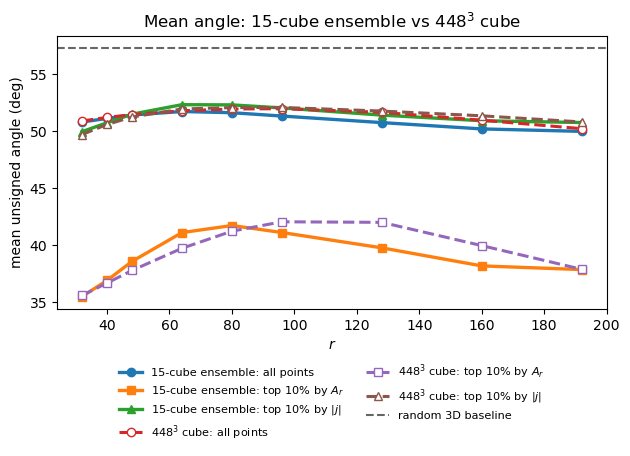

In [103]:
# --- FIGURE 1: mean angle, ensemble vs large cube ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")

ensemble_path = PROC / "ensemble_trial_320cubes_xyplane_interp_r32_192.json"
large_path    = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

with open(ensemble_path, "r") as f:
    ens = json.load(f)
with open(large_path, "r") as f:
    lg = json.load(f)

r_ens = np.asarray(ens["scales"], dtype=float)
r_lg  = np.asarray(lg["scales"], dtype=float)

plt.figure(figsize=(6.4, 5.3))

plt.plot(r_ens, np.asarray(ens["mean_all_ensemble_deg"], dtype=float),
         marker="o", lw=2.4, label="15-cube ensemble: all points")
plt.plot(r_ens, np.asarray(ens["mean_A_ensemble_deg"], dtype=float),
         marker="s", lw=2.4, label=r"15-cube ensemble: top 10% by $A_r$")
plt.plot(r_ens, np.asarray(ens["mean_J_ensemble_deg"], dtype=float),
         marker="^", lw=2.4, label=r"15-cube ensemble: top 10% by $|j|$")

plt.plot(r_lg, np.asarray(lg["mean_all_deg"], dtype=float),
         ls="--", marker="o", mfc="white", lw=2.2, label=r"$448^3$ cube: all points")
plt.plot(r_lg, np.asarray(lg["mean_A_deg"], dtype=float),
         ls="--", marker="s", mfc="white", lw=2.2, label=r"$448^3$ cube: top 10% by $A_r$")
plt.plot(r_lg, np.asarray(lg["mean_J_deg"], dtype=float),
         ls="--", marker="^", mfc="white", lw=2.2, label=r"$448^3$ cube: top 10% by $|j|$")

plt.axhline(float(ens["random_unsigned_3d_baseline_deg"]),
            color="0.4", ls="--", lw=1.5, label="random 3D baseline")

plt.xlabel(r"$r$")
plt.ylabel("mean unsigned angle (deg)")
plt.title(r"Mean angle: 15-cube ensemble vs $448^3$ cube")

plt.legend(fontsize=8.1, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.16))
plt.tight_layout(rect=[0, 0.08, 1, 1])

out_png = PROC / "sm_largecube_mean_angle_compare.png"
out_pdf = PROC / "sm_largecube_mean_angle_compare.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_crossscale_decay_compare.png
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_crossscale_decay_compare.pdf


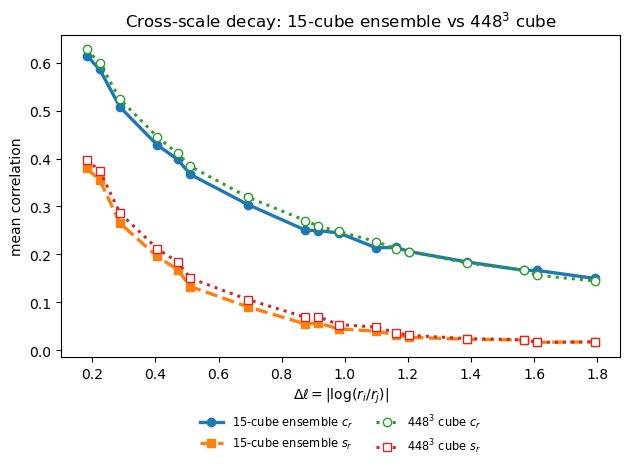

In [104]:
# --- FIGURE 2: cross-scale decay, ensemble vs large cube ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")

ensemble_path = PROC / "ensemble_trial_320cubes_xyplane_interp_r32_192.json"
large_path    = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

with open(ensemble_path, "r") as f:
    ens = json.load(f)
with open(large_path, "r") as f:
    lg = json.load(f)

def decay_curve(scales, mat):
    scales = np.asarray(scales, dtype=float)
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(len(scales), k=1)
    dlog = np.abs(np.log(scales[iu[0]] / scales[iu[1]]))
    vals = mat[iu]
    good = np.isfinite(vals)
    dlog = dlog[good]
    vals = vals[good]
    tags = np.round(dlog, 12)
    uniq = np.unique(tags)
    x, y = [], []
    for u in uniq:
        sel = tags == u
        x.append(dlog[sel].mean())
        y.append(vals[sel].mean())
    return np.asarray(x), np.asarray(y)

x_ec, y_ec = decay_curve(ens["scales"], ens["pearson_c_ensemble"])
x_es, y_es = decay_curve(ens["scales"], ens["pearson_s_ensemble"])
x_lc, y_lc = decay_curve(lg["scales"],  lg["pearson_c"])
x_ls, y_ls = decay_curve(lg["scales"],  lg["pearson_s"])

plt.figure(figsize=(6.4, 5.3))

plt.plot(x_ec, y_ec, marker="o", lw=2.4, label=r"15-cube ensemble $c_r$")
plt.plot(x_es, y_es, marker="s", lw=2.4, ls="--", label=r"15-cube ensemble $s_r$")

plt.plot(x_lc, y_lc, marker="o", mfc="white", lw=2.2, ls=":", label=r"$448^3$ cube $c_r$")
plt.plot(x_ls, y_ls, marker="s", mfc="white", lw=2.2, ls=":", label=r"$448^3$ cube $s_r$")

plt.xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
plt.ylabel("mean correlation")
plt.title(r"Cross-scale decay: 15-cube ensemble vs $448^3$ cube")

plt.legend(fontsize=8.2, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.14))
plt.tight_layout(rect=[0, 0.07, 1, 1])

out_png = PROC / "sm_largecube_crossscale_decay_compare.png"
out_pdf = PROC / "sm_largecube_crossscale_decay_compare.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()

In [105]:
plt.errorbar(r_ens, np.asarray(ens["mean_all_ensemble_deg"], dtype=float),
             yerr=np.asarray(ens["std_all_ensemble_deg"], dtype=float),
             color="C0", ecolor="k", elinewidth=1.4, capsize=3.5, capthick=1.2,
             marker="o", lw=2.4, label="15-cube ensemble: all points")

plt.errorbar(r_ens, np.asarray(ens["mean_A_ensemble_deg"], dtype=float),
             yerr=np.asarray(ens["std_A_ensemble_deg"], dtype=float),
             color="C1", ecolor="k", elinewidth=1.4, capsize=3.5, capthick=1.2,
             marker="s", lw=2.4, label=r"15-cube ensemble: top 10% by $A_r$")

plt.errorbar(r_ens, np.asarray(ens["mean_J_ensemble_deg"], dtype=float),
             yerr=np.asarray(ens["std_J_ensemble_deg"], dtype=float),
             color="C2", ecolor="k", elinewidth=1.4, capsize=3.5, capthick=1.2,
             marker="^", lw=2.4, label=r"15-cube ensemble: top 10% by $|j|$")

KeyError: 'std_all_ensemble_deg'

In [106]:
# --- FIGURE 1: mean angle, ensemble vs large cube ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")

ensemble_path = PROC / "ensemble_trial_320cubes_xyplane_interp_r32_192.json"
large_path    = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

with open(ensemble_path, "r") as f:
    ens = json.load(f)
with open(large_path, "r") as f:
    lg = json.load(f)

r_ens = np.asarray(ens["scales"], dtype=float)
r_lg  = np.asarray(lg["scales"], dtype=float)

plt.figure(figsize=(6.4, 5.3))

plt.errorbar(r_ens, np.asarray(ens["mean_all_ensemble_deg"], dtype=float),
             yerr=np.asarray(ens["std_all_ensemble_deg"], dtype=float),
             color="C0", ecolor="k", elinewidth=1.4, capsize=3.5, capthick=1.2,
             marker="o", lw=2.4, label="15-cube ensemble: all points")

plt.errorbar(r_ens, np.asarray(ens["mean_A_ensemble_deg"], dtype=float),
             yerr=np.asarray(ens["std_A_ensemble_deg"], dtype=float),
             color="C1", ecolor="k", elinewidth=1.4, capsize=3.5, capthick=1.2,
             marker="s", lw=2.4, label=r"15-cube ensemble: top 10% by $A_r$")

plt.errorbar(r_ens, np.asarray(ens["mean_J_ensemble_deg"], dtype=float),
             yerr=np.asarray(ens["std_J_ensemble_deg"], dtype=float),
             color="C2", ecolor="k", elinewidth=1.4, capsize=3.5, capthick=1.2,
             marker="^", lw=2.4, label=r"15-cube ensemble: top 10% by $|j|$")

plt.plot(r_lg, np.asarray(lg["mean_all_deg"], dtype=float),
         ls="--", marker="o", mfc="white", lw=2.2, color="C0",
         label=r"$448^3$ cube: all points")
plt.plot(r_lg, np.asarray(lg["mean_A_deg"], dtype=float),
         ls="--", marker="s", mfc="white", lw=2.2, color="C1",
         label=r"$448^3$ cube: top 10% by $A_r$")
plt.plot(r_lg, np.asarray(lg["mean_J_deg"], dtype=float),
         ls="--", marker="^", mfc="white", lw=2.2, color="C2",
         label=r"$448^3$ cube: top 10% by $|j|$")

plt.axhline(float(ens["random_unsigned_3d_baseline_deg"]),
            color="0.4", ls="--", lw=1.5, label="random 3D baseline")

plt.xlabel(r"$r$")
plt.ylabel("mean unsigned angle (deg)")
plt.title(r"Mean angle: 15-cube ensemble vs $448^3$ cube")

plt.legend(fontsize=8.1, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.16))
plt.tight_layout(rect=[0, 0.08, 1, 1])

out_png = PROC / "sm_largecube_mean_angle_compare.png"
out_pdf = PROC / "sm_largecube_mean_angle_compare.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()

KeyError: 'std_all_ensemble_deg'

<Figure size 640x530 with 0 Axes>

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_mean_angle_compare.png
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_mean_angle_compare.pdf


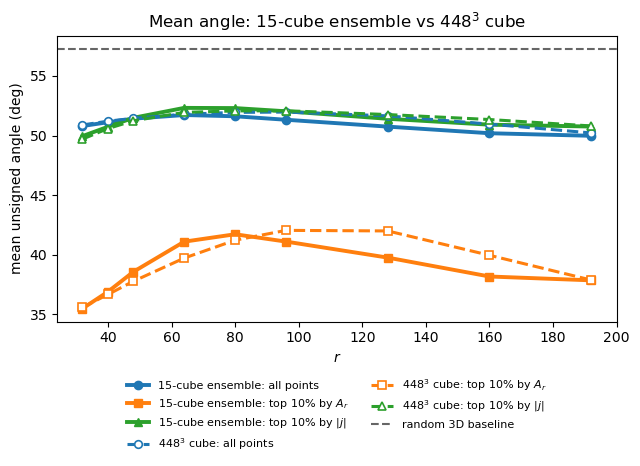

In [107]:
# --- FIGURE 1: mean angle, ensemble mean vs large cube (no error bars) ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")

ensemble_path = PROC / "ensemble_trial_320cubes_xyplane_interp_r32_192.json"
large_path    = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

with open(ensemble_path, "r") as f:
    ens = json.load(f)
with open(large_path, "r") as f:
    lg = json.load(f)

r_ens = np.asarray(ens["scales"], dtype=float)
r_lg  = np.asarray(lg["scales"], dtype=float)

plt.figure(figsize=(6.5, 5.4))

# 15-cube ensemble means
plt.plot(r_ens, np.asarray(ens["mean_all_ensemble_deg"], dtype=float),
         color="C0", marker="o", lw=2.8, ms=6,
         label="15-cube ensemble: all points")
plt.plot(r_ens, np.asarray(ens["mean_A_ensemble_deg"], dtype=float),
         color="C1", marker="s", lw=2.8, ms=6,
         label=r"15-cube ensemble: top 10% by $A_r$")
plt.plot(r_ens, np.asarray(ens["mean_J_ensemble_deg"], dtype=float),
         color="C2", marker="^", lw=2.8, ms=6,
         label=r"15-cube ensemble: top 10% by $|j|$")

# large cube overlay
plt.plot(r_lg, np.asarray(lg["mean_all_deg"], dtype=float),
         color="C0", ls="--", marker="o", mfc="white", mec="C0", mew=1.2, lw=2.2, ms=5.5,
         label=r"$448^3$ cube: all points")
plt.plot(r_lg, np.asarray(lg["mean_A_deg"], dtype=float),
         color="C1", ls="--", marker="s", mfc="white", mec="C1", mew=1.2, lw=2.2, ms=5.5,
         label=r"$448^3$ cube: top 10% by $A_r$")
plt.plot(r_lg, np.asarray(lg["mean_J_deg"], dtype=float),
         color="C2", ls="--", marker="^", mfc="white", mec="C2", mew=1.2, lw=2.2, ms=5.5,
         label=r"$448^3$ cube: top 10% by $|j|$")

# baseline
plt.axhline(float(ens["random_unsigned_3d_baseline_deg"]),
            color="0.4", ls="--", lw=1.5, label="random 3D baseline")

plt.xlabel(r"$r$")
plt.ylabel("mean unsigned angle (deg)")
plt.title(r"Mean angle: 15-cube ensemble vs $448^3$ cube")

plt.legend(fontsize=8.0, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.16))
plt.tight_layout(rect=[0, 0.08, 1, 1])

out_png = PROC / "sm_largecube_mean_angle_compare.png"
out_pdf = PROC / "sm_largecube_mean_angle_compare.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()


saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_crossscale_decay_compare.png
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_crossscale_decay_compare.pdf


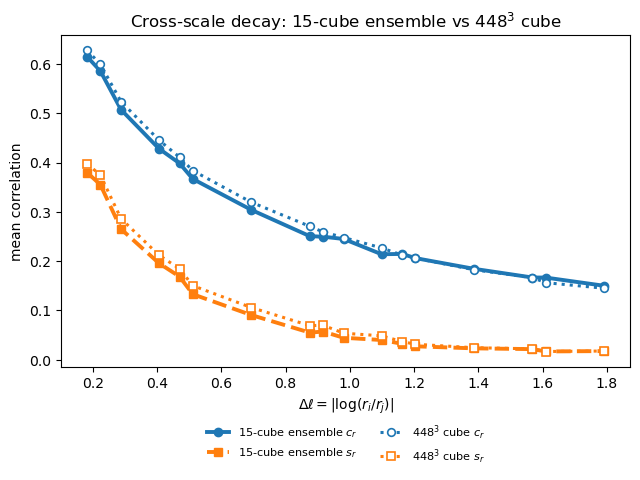

In [108]:
# --- FIGURE 2: cross-scale decay, ensemble mean vs large cube (no error bars) ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")

ensemble_path = PROC / "ensemble_trial_320cubes_xyplane_interp_r32_192.json"
large_path    = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

with open(ensemble_path, "r") as f:
    ens = json.load(f)
with open(large_path, "r") as f:
    lg = json.load(f)

def decay_curve(scales, mat):
    scales = np.asarray(scales, dtype=float)
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(len(scales), k=1)
    dlog = np.abs(np.log(scales[iu[0]] / scales[iu[1]]))
    vals = mat[iu]
    good = np.isfinite(vals)
    dlog = dlog[good]
    vals = vals[good]
    tags = np.round(dlog, 12)
    uniq = np.unique(tags)
    x, y = [], []
    for u in uniq:
        sel = tags == u
        x.append(dlog[sel].mean())
        y.append(vals[sel].mean())
    return np.asarray(x), np.asarray(y)

x_ec, y_ec = decay_curve(ens["scales"], ens["pearson_c_ensemble"])
x_es, y_es = decay_curve(ens["scales"], ens["pearson_s_ensemble"])
x_lc, y_lc = decay_curve(lg["scales"],  lg["pearson_c"])
x_ls, y_ls = decay_curve(lg["scales"],  lg["pearson_s"])

plt.figure(figsize=(6.5, 5.4))

# 15-cube ensemble means
plt.plot(x_ec, y_ec, color="C0", marker="o", lw=2.8, ms=6,
         label=r"15-cube ensemble $c_r$")
plt.plot(x_es, y_es, color="C1", marker="s", lw=2.8, ms=6, ls="--",
         label=r"15-cube ensemble $s_r$")

# large cube overlay
plt.plot(x_lc, y_lc, color="C0", marker="o", mfc="white", mec="C0", mew=1.2,
         lw=2.2, ms=5.5, ls=":",
         label=r"$448^3$ cube $c_r$")
plt.plot(x_ls, y_ls, color="C1", marker="s", mfc="white", mec="C1", mew=1.2,
         lw=2.2, ms=5.5, ls=":",
         label=r"$448^3$ cube $s_r$")

plt.xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
plt.ylabel("mean correlation")
plt.title(r"Cross-scale decay: 15-cube ensemble vs $448^3$ cube")

plt.legend(fontsize=8.1, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.14))
plt.tight_layout(rect=[0, 0.07, 1, 1])

out_png = PROC / "sm_largecube_crossscale_decay_compare.png"
out_pdf = PROC / "sm_largecube_crossscale_decay_compare.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()

used: 16
 OK: 320cube_S1_t21_xyplane_interp_r32_192.json
 OK: 320cube_S1_t33_xyplane_interp_r32_192.json
 OK: 320cube_S1_t37_xyplane_interp_r32_192.json
 OK: 320cube_S1_t49_xyplane_interp_r32_192.json
 OK: 320cube_S1_t9_xyplane_interp_r32_192.json
 OK: 320cube_S2_t13_xyplane_interp_r32_192.json
 OK: 320cube_S2_t25_xyplane_interp_r32_192.json
 OK: 320cube_S2_t41_xyplane_interp_r32_192.json
 OK: 320cube_S3_t17_xyplane_interp_r32_192.json
 OK: 320cube_S3_t29_xyplane_interp_r32_192.json
 OK: 320cube_S3_t45_xyplane_interp_r32_192.json
 OK: 320cube_S3_t53_xyplane_interp_r32_192.json
 OK: 320cube_S3_t5_xyplane_interp_r32_192.json
 OK: audit_alignment_crossscale_256cube_xyplane_interp_r32_192.json
 OK: audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json
 OK: audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_mean_angle_compare_errbars.png
saved: /home/idies/workspace/St

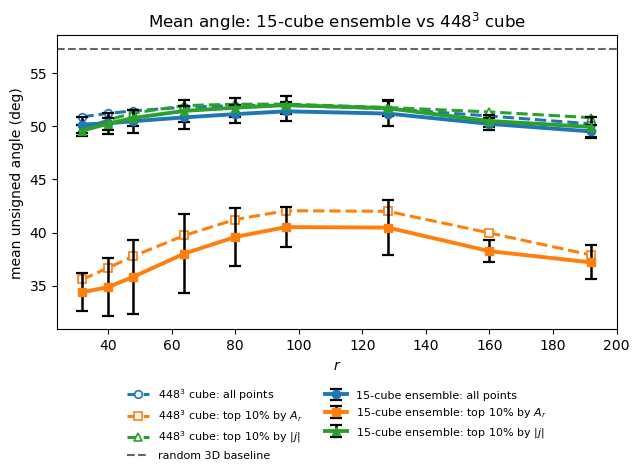

In [109]:
# --- FIGURE 1: mean angle, 15-cube mean ± std vs 448^3 cube ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")
large_path = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

candidate_paths = sorted(
    p for p in PROC.glob("*xyplane_interp_r32_192.json")
    if p.name != large_path.name
    and "largecube_" not in p.name
    and "ensemble_trial_" not in p.name
)

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def get_1d(d, names, n):
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float).squeeze()
            if arr.ndim == 1 and arr.size == n:
                return arr
    raise KeyError(names)

large = load_json(large_path)
rL = np.asarray(large["scales"], dtype=float)

allL = get_1d(large, ["mean_all_phi_deg", "mean_all_deg"], len(rL))
AL   = get_1d(large, ["mean_A_phi_deg",   "mean_A_deg"],   len(rL))
JL   = get_1d(large, ["mean_J_phi_deg",   "mean_J_deg"],   len(rL))

small_all, small_A, small_J = [], [], []
used, skipped = [], []

for p in candidate_paths:
    try:
        d = load_json(p)
        r = np.asarray(d["scales"], dtype=float)
        if not np.array_equal(r, rL):
            skipped.append((p.name, "scale mismatch"))
            continue
        small_all.append(get_1d(d, ["mean_all_phi_deg", "mean_all_deg"], len(r)))
        small_A.append(get_1d(d, ["mean_A_phi_deg",   "mean_A_deg"],   len(r)))
        small_J.append(get_1d(d, ["mean_J_phi_deg",   "mean_J_deg"],   len(r)))
        used.append(p.name)
    except Exception as e:
        skipped.append((p.name, str(e)))

print("used:", len(used))
for x in used:
    print(" OK:", x)
if skipped:
    print("\nskipped:")
    for a, b in skipped:
        print(" ", a, "->", b)

small_all = np.vstack(small_all)
small_A   = np.vstack(small_A)
small_J   = np.vstack(small_J)

all_mean = small_all.mean(axis=0)
A_mean   = small_A.mean(axis=0)
J_mean   = small_J.mean(axis=0)

all_std = small_all.std(axis=0, ddof=1)
A_std   = small_A.std(axis=0, ddof=1)
J_std   = small_J.std(axis=0, ddof=1)

baseline = 54.74
for p in candidate_paths:
    try:
        d = load_json(p)
        if "random_unsigned_3d_baseline_deg" in d:
            baseline = float(d["random_unsigned_3d_baseline_deg"])
            break
    except:
        pass

plt.figure(figsize=(6.5, 5.5))

plt.errorbar(rL, all_mean, yerr=all_std,
             color="C0", ecolor="k", elinewidth=1.8, capsize=4.5, capthick=1.6,
             marker="o", ms=6, lw=2.8, zorder=3,
             label="15-cube ensemble: all points")
plt.errorbar(rL, A_mean, yerr=A_std,
             color="C1", ecolor="k", elinewidth=1.8, capsize=4.5, capthick=1.6,
             marker="s", ms=6, lw=2.8, zorder=3,
             label=r"15-cube ensemble: top 10% by $A_r$")
plt.errorbar(rL, J_mean, yerr=J_std,
             color="C2", ecolor="k", elinewidth=1.8, capsize=4.5, capthick=1.6,
             marker="^", ms=6, lw=2.8, zorder=3,
             label=r"15-cube ensemble: top 10% by $|j|$")

plt.plot(rL, allL, color="C0", ls="--", marker="o", mfc="white", mec="C0", mew=1.2,
         lw=2.2, ms=5.5, zorder=2, label=r"$448^3$ cube: all points")
plt.plot(rL, AL, color="C1", ls="--", marker="s", mfc="white", mec="C1", mew=1.2,
         lw=2.2, ms=5.5, zorder=2, label=r"$448^3$ cube: top 10% by $A_r$")
plt.plot(rL, JL, color="C2", ls="--", marker="^", mfc="white", mec="C2", mew=1.2,
         lw=2.2, ms=5.5, zorder=2, label=r"$448^3$ cube: top 10% by $|j|$")

plt.axhline(baseline, color="0.4", ls="--", lw=1.5, label="random 3D baseline")

plt.xlabel(r"$r$")
plt.ylabel("mean unsigned angle (deg)")
plt.title(r"Mean angle: 15-cube ensemble vs $448^3$ cube")
plt.legend(fontsize=8.0, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.16))
plt.tight_layout(rect=[0, 0.08, 1, 1])

out_png = PROC / "sm_largecube_mean_angle_compare_errbars.png"
out_pdf = PROC / "sm_largecube_mean_angle_compare_errbars.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()

used: 16
 OK: 320cube_S1_t21_xyplane_interp_r32_192.json
 OK: 320cube_S1_t33_xyplane_interp_r32_192.json
 OK: 320cube_S1_t37_xyplane_interp_r32_192.json
 OK: 320cube_S1_t49_xyplane_interp_r32_192.json
 OK: 320cube_S1_t9_xyplane_interp_r32_192.json
 OK: 320cube_S2_t13_xyplane_interp_r32_192.json
 OK: 320cube_S2_t25_xyplane_interp_r32_192.json
 OK: 320cube_S2_t41_xyplane_interp_r32_192.json
 OK: 320cube_S3_t17_xyplane_interp_r32_192.json
 OK: 320cube_S3_t29_xyplane_interp_r32_192.json
 OK: 320cube_S3_t45_xyplane_interp_r32_192.json
 OK: 320cube_S3_t53_xyplane_interp_r32_192.json
 OK: 320cube_S3_t5_xyplane_interp_r32_192.json
 OK: audit_alignment_crossscale_256cube_xyplane_interp_r32_192.json
 OK: audit_alignment_crossscale_320cube_S2_t1_xyplane_interp_r32_192.json
 OK: audit_alignment_crossscale_320cube_S2_t2_xyplane_interp_r32_192.json
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_crossscale_decay_compare_errbars.png
saved: /home/idies/worksp

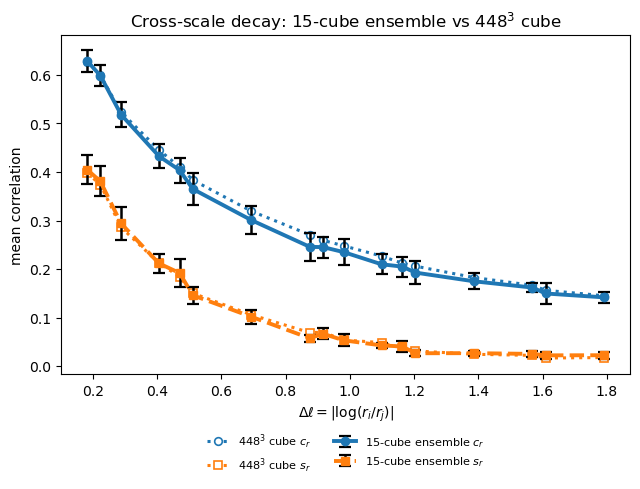

In [110]:
# --- FIGURE 2: cross-scale decay, 15-cube mean ± std vs 448^3 cube ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")
large_path = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

candidate_paths = sorted(
    p for p in PROC.glob("*xyplane_interp_r32_192.json")
    if p.name != large_path.name
    and "largecube_" not in p.name
    and "ensemble_trial_" not in p.name
)

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def decay_curve(scales, mat):
    scales = np.asarray(scales, dtype=float)
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(len(scales), k=1)
    dlog = np.abs(np.log(scales[iu[0]] / scales[iu[1]]))
    vals = mat[iu]
    good = np.isfinite(vals)
    dlog = dlog[good]
    vals = vals[good]
    tags = np.round(dlog, 12)
    uniq = np.unique(tags)
    x, y = [], []
    for u in uniq:
        sel = tags == u
        x.append(dlog[sel].mean())
        y.append(vals[sel].mean())
    return np.asarray(x), np.asarray(y)

large = load_json(large_path)
xLc, yLc = decay_curve(large["scales"], large["pearson_c"])
xLs, yLs = decay_curve(large["scales"], large["pearson_s"])

small_c, small_s = [], []
used, skipped = [], []

for p in candidate_paths:
    try:
        d = load_json(p)
        xc, yc = decay_curve(d["scales"], d["pearson_c"])
        xs, ys = decay_curve(d["scales"], d["pearson_s"])
        if not (np.allclose(xc, xLc) and np.allclose(xs, xLs)):
            skipped.append((p.name, "decay mismatch"))
            continue
        small_c.append(yc)
        small_s.append(ys)
        used.append(p.name)
    except Exception as e:
        skipped.append((p.name, str(e)))

print("used:", len(used))
for x in used:
    print(" OK:", x)
if skipped:
    print("\nskipped:")
    for a, b in skipped:
        print(" ", a, "->", b)

small_c = np.vstack(small_c)
small_s = np.vstack(small_s)

c_mean = small_c.mean(axis=0)
s_mean = small_s.mean(axis=0)
c_std  = small_c.std(axis=0, ddof=1)
s_std  = small_s.std(axis=0, ddof=1)

plt.figure(figsize=(6.5, 5.5))

plt.errorbar(xLc, c_mean, yerr=c_std,
             color="C0", ecolor="k", elinewidth=1.8, capsize=4.5, capthick=1.6,
             marker="o", ms=6, lw=2.8, zorder=3,
             label=r"15-cube ensemble $c_r$")
plt.errorbar(xLs, s_mean, yerr=s_std,
             color="C1", ecolor="k", elinewidth=1.8, capsize=4.5, capthick=1.6,
             marker="s", ms=6, lw=2.8, ls="--", zorder=3,
             label=r"15-cube ensemble $s_r$")

plt.plot(xLc, yLc, color="C0", ls=":", marker="o", mfc="white", mec="C0", mew=1.2,
         lw=2.2, ms=5.5, zorder=2, label=r"$448^3$ cube $c_r$")
plt.plot(xLs, yLs, color="C1", ls=":", marker="s", mfc="white", mec="C1", mew=1.2,
         lw=2.2, ms=5.5, zorder=2, label=r"$448^3$ cube $s_r$")

plt.xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
plt.ylabel("mean correlation")
plt.title(r"Cross-scale decay: 15-cube ensemble vs $448^3$ cube")
plt.legend(fontsize=8.1, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.14))
plt.tight_layout(rect=[0, 0.07, 1, 1])

out_png = PROC / "sm_largecube_crossscale_decay_compare_errbars.png"
out_pdf = PROC / "sm_largecube_crossscale_decay_compare_errbars.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_mean_angle_compare_final.png
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_mean_angle_compare_final.pdf


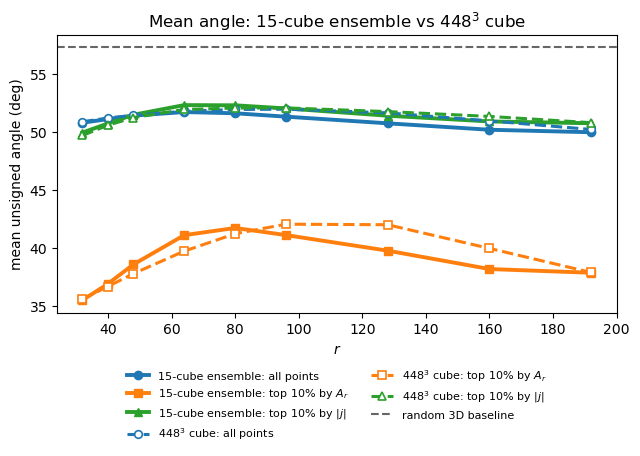

In [111]:
# --- FINAL FIGURE 1: mean angle, clean overlay, no error bars ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")

ensemble_path = PROC / "ensemble_trial_320cubes_xyplane_interp_r32_192.json"
large_path    = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

with open(ensemble_path, "r") as f:
    ens = json.load(f)
with open(large_path, "r") as f:
    lg = json.load(f)

r_ens = np.asarray(ens["scales"], dtype=float)
r_lg  = np.asarray(lg["scales"], dtype=float)

plt.figure(figsize=(6.5, 5.3))

# 15-cube ensemble means
plt.plot(r_ens, np.asarray(ens["mean_all_ensemble_deg"], dtype=float),
         color="C0", marker="o", lw=2.8, ms=6,
         label="15-cube ensemble: all points")
plt.plot(r_ens, np.asarray(ens["mean_A_ensemble_deg"], dtype=float),
         color="C1", marker="s", lw=2.8, ms=6,
         label=r"15-cube ensemble: top 10% by $A_r$")
plt.plot(r_ens, np.asarray(ens["mean_J_ensemble_deg"], dtype=float),
         color="C2", marker="^", lw=2.8, ms=6,
         label=r"15-cube ensemble: top 10% by $|j|$")

# 448^3 cube overlay
plt.plot(r_lg, np.asarray(lg["mean_all_deg"], dtype=float),
         color="C0", ls="--", marker="o", mfc="white", mec="C0", mew=1.2,
         lw=2.2, ms=5.5, label=r"$448^3$ cube: all points")
plt.plot(r_lg, np.asarray(lg["mean_A_deg"], dtype=float),
         color="C1", ls="--", marker="s", mfc="white", mec="C1", mew=1.2,
         lw=2.2, ms=5.5, label=r"$448^3$ cube: top 10% by $A_r$")
plt.plot(r_lg, np.asarray(lg["mean_J_deg"], dtype=float),
         color="C2", ls="--", marker="^", mfc="white", mec="C2", mew=1.2,
         lw=2.2, ms=5.5, label=r"$448^3$ cube: top 10% by $|j|$")

plt.axhline(float(ens["random_unsigned_3d_baseline_deg"]),
            color="0.4", ls="--", lw=1.5, label="random 3D baseline")

plt.xlabel(r"$r$")
plt.ylabel("mean unsigned angle (deg)")
plt.title(r"Mean angle: 15-cube ensemble vs $448^3$ cube")

plt.legend(fontsize=8.0, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.16))
plt.tight_layout(rect=[0, 0.08, 1, 1])

out_png = PROC / "sm_largecube_mean_angle_compare_final.png"
out_pdf = PROC / "sm_largecube_mean_angle_compare_final.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_crossscale_decay_compare_final.png
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/sm_largecube_crossscale_decay_compare_final.pdf


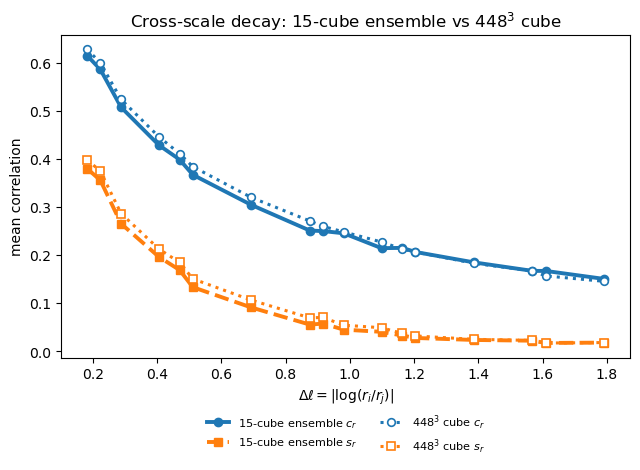

In [112]:
# --- FINAL FIGURE 2: cross-scale decay, clean overlay, no error bars ---
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")

ensemble_path = PROC / "ensemble_trial_320cubes_xyplane_interp_r32_192.json"
large_path    = PROC / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

with open(ensemble_path, "r") as f:
    ens = json.load(f)
with open(large_path, "r") as f:
    lg = json.load(f)

def decay_curve(scales, mat):
    scales = np.asarray(scales, dtype=float)
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(len(scales), k=1)
    dlog = np.abs(np.log(scales[iu[0]] / scales[iu[1]]))
    vals = mat[iu]
    good = np.isfinite(vals)
    dlog = dlog[good]
    vals = vals[good]
    tags = np.round(dlog, 12)
    uniq = np.unique(tags)
    x, y = [], []
    for u in uniq:
        sel = tags == u
        x.append(dlog[sel].mean())
        y.append(vals[sel].mean())
    return np.asarray(x), np.asarray(y)

x_ec, y_ec = decay_curve(ens["scales"], ens["pearson_c_ensemble"])
x_es, y_es = decay_curve(ens["scales"], ens["pearson_s_ensemble"])
x_lc, y_lc = decay_curve(lg["scales"],  lg["pearson_c"])
x_ls, y_ls = decay_curve(lg["scales"],  lg["pearson_s"])

plt.figure(figsize=(6.5, 5.3))

# 15-cube ensemble means
plt.plot(x_ec, y_ec, color="C0", marker="o", lw=2.8, ms=6,
         label=r"15-cube ensemble $c_r$")
plt.plot(x_es, y_es, color="C1", marker="s", lw=2.8, ms=6, ls="--",
         label=r"15-cube ensemble $s_r$")

# 448^3 cube overlay
plt.plot(x_lc, y_lc, color="C0", marker="o", mfc="white", mec="C0", mew=1.2,
         lw=2.2, ms=5.5, ls=":",
         label=r"$448^3$ cube $c_r$")
plt.plot(x_ls, y_ls, color="C1", marker="s", mfc="white", mec="C1", mew=1.2,
         lw=2.2, ms=5.5, ls=":",
         label=r"$448^3$ cube $s_r$")

plt.xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
plt.ylabel("mean correlation")
plt.title(r"Cross-scale decay: 15-cube ensemble vs $448^3$ cube")

plt.legend(fontsize=8.1, ncol=2, frameon=False,
           loc="upper center", bbox_to_anchor=(0.5, -0.14))
plt.tight_layout(rect=[0, 0.07, 1, 1])

out_png = PROC / "sm_largecube_crossscale_decay_compare_final.png"
out_pdf = PROC / "sm_largecube_crossscale_decay_compare_final.pdf"
plt.savefig(out_png, dpi=220, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
print("saved:", out_png)
print("saved:", out_pdf)
plt.show()

In [113]:
from pathlib import Path
import shutil

PROC = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed")
NB = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks")

for name in [
    "sm_largecube_mean_angle_compare_final.pdf",
    "sm_largecube_mean_angle_compare_final.png",
    "sm_largecube_crossscale_decay_compare_errbars.pdf",
    "sm_largecube_crossscale_decay_compare_errbars.png",
]:
    src = PROC / name
    dst = NB / name
    if src.exists():
        shutil.copy2(src, dst)
        print("copied:", dst)
    else:
        print("missing:", src)

copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/sm_largecube_mean_angle_compare_final.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/sm_largecube_mean_angle_compare_final.png
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/sm_largecube_crossscale_decay_compare_errbars.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/sm_largecube_crossscale_decay_compare_errbars.png


In [114]:
import json, csv, itertools
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
SEED = 20260421
N_CUBES = 15
CUBE = 320
DOMAIN = 1024

# Use 1-based times if that is what your current workflow uses.
# Change only if your downloader expects a different valid range.
AVAILABLE_TIMES = np.arange(1, 1025, dtype=int)

ROOT = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
RAW_DIR = ROOT / "raw"
MANIFEST_DIR = ROOT / "manifests"
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# BUILD 27 NON-OVERLAPPING BOXES
# =========================
starts = [0, 320, 640]
boxes = []
for x0, y0, z0 in itertools.product(starts, starts, starts):
    boxes.append({
        "x0": x0, "x1": x0 + CUBE - 1,
        "y0": y0, "y1": y0 + CUBE - 1,
        "z0": z0, "z1": z0 + CUBE - 1,
    })

assert len(boxes) == 27

rng = np.random.default_rng(SEED)

sel_times = rng.choice(AVAILABLE_TIMES, size=N_CUBES, replace=False)
sel_box_idx = rng.choice(np.arange(len(boxes)), size=N_CUBES, replace=False)

# random pairing between chosen times and chosen boxes
rng.shuffle(sel_times)
rng.shuffle(sel_box_idx)

rows = []
for i, (t, bi) in enumerate(zip(sel_times, sel_box_idx), start=1):
    b = boxes[int(bi)]
    rows.append({
        "cube_id": f"C{i:02d}",
        "t": int(t),
        "box_index": int(bi),
        **b
    })

manifest = pd.DataFrame(rows).sort_values("cube_id").reset_index(drop=True)

# =========================
# VALIDATE DISTINCT TIMES + NON-OVERLAP
# =========================
assert manifest["t"].nunique() == N_CUBES, "Times are not all distinct."
assert manifest["box_index"].nunique() == N_CUBES, "Boxes are not all distinct."

def overlap_1d(a0, a1, b0, b1):
    return not (a1 < b0 or b1 < a0)

def overlap_3d(r1, r2):
    return (
        overlap_1d(r1["x0"], r1["x1"], r2["x0"], r2["x1"]) and
        overlap_1d(r1["y0"], r1["y1"], r2["y0"], r2["y1"]) and
        overlap_1d(r1["z0"], r1["z1"], r2["z0"], r2["z1"])
    )

for i in range(len(manifest)):
    for j in range(i + 1, len(manifest)):
        a = manifest.iloc[i].to_dict()
        b = manifest.iloc[j].to_dict()
        assert not overlap_3d(a, b), f"Overlap found: {a['cube_id']} and {b['cube_id']}"

csv_path = MANIFEST_DIR / f"manifest_15_random_nonoverlap_320_seed{SEED}.csv"
json_path = MANIFEST_DIR / f"manifest_15_random_nonoverlap_320_seed{SEED}.json"

manifest.to_csv(csv_path, index=False)
with open(json_path, "w") as f:
    json.dump(manifest.to_dict(orient="records"), f, indent=2)

print("Saved manifest:")
print(csv_path)
print(json_path)
print()
print(manifest[["cube_id","t","x0","x1","y0","y1","z0","z1"]].to_string(index=False))

Saved manifest:
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/manifests/manifest_15_random_nonoverlap_320_seed20260421.csv
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/manifests/manifest_15_random_nonoverlap_320_seed20260421.json

cube_id   t  x0  x1  y0  y1  z0  z1
    C01 218 640 959 640 959 640 959
    C02 553 320 639 640 959 320 639
    C03 825 640 959 640 959   0 319
    C04 217 320 639   0 319 640 959
    C05 493   0 319 640 959 640 959
    C06  22 320 639 640 959 640 959
    C07 292 640 959 320 639 640 959
    C08 976   0 319   0 319 320 639
    C09 699   0 319 320 639   0 319
    C10 778 320 639 320 639   0 319
    C11 843 640 959   0 319 320 639
    C12 273 640 959 320 639 320 639
    C13 539   0 319 640 959   0 319
    C14 302 320 639 320 639 320 639
    C15 118   0 319 320 639 640 959


In [115]:
import numpy as np
import pandas as pd
from pathlib import Path
import traceback

# Load manifest written above
manifest = pd.read_csv(csv_path)

RAW_DIR = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

def velocity_path(rec):
    return RAW_DIR / (
        f"mhd1024_velocity_t{int(rec.t):04d}_"
        f"x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    )

def magnetic_path(rec):
    return RAW_DIR / (
        f"mhd1024_magneticfield_t{int(rec.t):04d}_"
        f"x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    )

# ==========================================================
# REPLACE ONLY THIS FUNCTION BODY WITH YOUR WORKING FETCHER
# ==========================================================
def FETCH_FIELD(field_name, t, x0, y0, z0, cube_size):
    """
    Must return ndarray with shape (cube_size, cube_size, cube_size, 3).

    field_name will be either:
      - 'velocity'
      - 'magneticfield'

    Replace the body below with your already-working one-cube downloader.
    """
    raise NotImplementedError(
        "Paste your working single-cube fetch call here. "
        "It must return an ndarray of shape (320,320,320,3)."
    )

# ==========================================================
# DOWNLOAD LOOP
# ==========================================================
download_log = []

for rec in manifest.itertuples(index=False):
    print("=" * 80)
    print(f"{rec.cube_id}: t={rec.t}  x=[{rec.x0},{rec.x1}]  y=[{rec.y0},{rec.y1}]  z=[{rec.z0},{rec.z1}]")

    vpath = velocity_path(rec)
    bpath = magnetic_path(rec)

    try:
        if vpath.exists():
            print("velocity exists:", vpath.name)
        else:
            u = FETCH_FIELD("velocity", int(rec.t), int(rec.x0), int(rec.y0), int(rec.z0), 320)
            assert isinstance(u, np.ndarray), "Velocity fetch did not return ndarray."
            assert u.shape == (320, 320, 320, 3), f"Bad velocity shape: {u.shape}"
            np.save(vpath, u.astype(np.float32, copy=False))
            print("saved velocity:", vpath.name)

        if bpath.exists():
            print("magnetic exists:", bpath.name)
        else:
            b = FETCH_FIELD("magneticfield", int(rec.t), int(rec.x0), int(rec.y0), int(rec.z0), 320)
            assert isinstance(b, np.ndarray), "Magnetic fetch did not return ndarray."
            assert b.shape == (320, 320, 320, 3), f"Bad magnetic shape: {b.shape}"
            np.save(bpath, b.astype(np.float32, copy=False))
            print("saved magnetic:", bpath.name)

        download_log.append({"cube_id": rec.cube_id, "status": "ok", "velocity": str(vpath), "magnetic": str(bpath)})

    except Exception as e:
        print("FAILED:", rec.cube_id, e)
        traceback.print_exc()
        download_log.append({"cube_id": rec.cube_id, "status": f"failed: {e}", "velocity": str(vpath), "magnetic": str(bpath)})

log_path = RAW_DIR / f"download_log_seed{SEED}.json"
with open(log_path, "w") as f:
    json.dump(download_log, f, indent=2)

print("\nDownload log written to:")
print(log_path)

C01: t=218  x=[640,959]  y=[640,959]  z=[640,959]
FAILED: C01 Paste your working single-cube fetch call here. It must return an ndarray of shape (320,320,320,3).
C02: t=553  x=[320,639]  y=[640,959]  z=[320,639]
FAILED: C02 Paste your working single-cube fetch call here. It must return an ndarray of shape (320,320,320,3).
C03: t=825  x=[640,959]  y=[640,959]  z=[0,319]
FAILED: C03 Paste your working single-cube fetch call here. It must return an ndarray of shape (320,320,320,3).
C04: t=217  x=[320,639]  y=[0,319]  z=[640,959]
FAILED: C04 Paste your working single-cube fetch call here. It must return an ndarray of shape (320,320,320,3).
C05: t=493  x=[0,319]  y=[640,959]  z=[640,959]
FAILED: C05 Paste your working single-cube fetch call here. It must return an ndarray of shape (320,320,320,3).
C06: t=22  x=[320,639]  y=[640,959]  z=[640,959]
FAILED: C06 Paste your working single-cube fetch call here. It must return an ndarray of shape (320,320,320,3).
C07: t=292  x=[640,959]  y=[320,639

Traceback (most recent call last):
  File "/tmp/ipykernel_104/16576081.py", line 58, in <module>
    u = FETCH_FIELD("velocity", int(rec.t), int(rec.x0), int(rec.y0), int(rec.z0), 320)
  File "/tmp/ipykernel_104/16576081.py", line 37, in FETCH_FIELD
    raise NotImplementedError(
NotImplementedError: Paste your working single-cube fetch call here. It must return an ndarray of shape (320,320,320,3).
Traceback (most recent call last):
  File "/tmp/ipykernel_104/16576081.py", line 58, in <module>
    u = FETCH_FIELD("velocity", int(rec.t), int(rec.x0), int(rec.y0), int(rec.z0), 320)
  File "/tmp/ipykernel_104/16576081.py", line 37, in FETCH_FIELD
    raise NotImplementedError(
NotImplementedError: Paste your working single-cube fetch call here. It must return an ndarray of shape (320,320,320,3).
Traceback (most recent call last):
  File "/tmp/ipykernel_104/16576081.py", line 58, in <module>
    u = FETCH_FIELD("velocity", int(rec.t), int(rec.x0), int(rec.y0), int(rec.z0), 320)
  File "/tm

In [116]:
import inspect, re
from pathlib import Path

print("=== Candidate functions already defined in this kernel ===")
hits = []
for name, obj in list(globals().items()):
    if callable(obj):
        try:
            src = inspect.getsource(obj)
        except Exception:
            continue
        low = src.lower()
        if any(k in low for k in ["getcutout", "pyjhtdb", "giverny", "mhd1024", "velocity", "magneticfield"]):
            hits.append((name, str(inspect.signature(obj))))
for name, sig in hits:
    print(f"{name}{sig}")

print("\n=== Search saved IPython history for likely cutout code ===")
hist_path = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/ipython_history_2026-04-21.py")
if hist_path.exists():
    lines = hist_path.read_text(errors="ignore").splitlines()
    pats = ["getCutout", "getbigCutout", "pyJHTDB", "giverny", "mhd1024", "magneticfield", "velocity", "np.save", "raw/"]
    for i, line in enumerate(lines):
        if any(p.lower() in line.lower() for p in pats):
            lo = max(0, i-3)
            hi = min(len(lines), i+4)
            print(f"\n--- history lines {lo+1}-{hi} ---")
            for j in range(lo, hi):
                print(f"{j+1:05d}: {lines[j]}")
else:
    print("History file not found:", hist_path)

=== Candidate functions already defined in this kernel ===
TurbulenceDB(*, name: str, description: Optional[str] = None, pickled_metadata_filepath: str, variables: List[giverny.turbulence_gizmos.jhtdb_schema.Variable], spatial_operators: List[giverny.turbulence_gizmos.jhtdb_schema.Feature], spatial_methods: List[giverny.turbulence_gizmos.jhtdb_schema.SpatialMethod], temporal_methods: List[giverny.turbulence_gizmos.jhtdb_schema.Feature], giverny_constants: giverny.turbulence_gizmos.jhtdb_schema.GivernyConstants, datasets: List[giverny.turbulence_gizmos.jhtdb_schema.Dataset], **extra_data: Any) -> None
load_json_metadata(url)
check_variable(metadata, variable, dataset_title, query_type)
check_timepoint(metadata, timepoint, dataset_title, query_type, max_num_timepoints=1)
get_time_dt(metadata, dataset_title, query_type)
get_time_index_shift(metadata, dataset_title, query_type)
get_time_index_from_timepoint(metadata, dataset_title, timepoint, tint, query_type)
get_giverny_datasets()
get_va

In [117]:
import json, itertools
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 20260421
N_CUBES = 15
CUBE = 320

# Keep this unless you know your valid time-index range is different.
AVAILABLE_TIMES = np.arange(1, 1025, dtype=int)

base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"
manifest_dir = base_dir / "manifests"
raw_dir.mkdir(parents=True, exist_ok=True)
manifest_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 27 strict non-overlapping 320^3 boxes using 1-based indexing
# ------------------------------------------------------------
starts = [1, 321, 641]
boxes = []
for x0, y0, z0 in itertools.product(starts, starts, starts):
    boxes.append({
        "x0": x0, "x1": x0 + CUBE - 1,
        "y0": y0, "y1": y0 + CUBE - 1,
        "z0": z0, "z1": z0 + CUBE - 1,
    })

assert len(boxes) == 27

rng = np.random.default_rng(SEED)

sel_times = rng.choice(AVAILABLE_TIMES, size=N_CUBES, replace=False)
sel_box_idx = rng.choice(np.arange(len(boxes)), size=N_CUBES, replace=False)

rng.shuffle(sel_times)
rng.shuffle(sel_box_idx)

rows = []
for i, (t, bi) in enumerate(zip(sel_times, sel_box_idx), start=1):
    b = boxes[int(bi)]
    rows.append({
        "cube_id": f"C{i:02d}",
        "t": int(t),
        "box_index": int(bi),
        **b
    })

manifest = pd.DataFrame(rows).sort_values("cube_id").reset_index(drop=True)

# ------------------------------------------------------------
# Validate: distinct times, distinct boxes, no overlap
# ------------------------------------------------------------
assert manifest["t"].nunique() == N_CUBES
assert manifest["box_index"].nunique() == N_CUBES

def overlap_1d(a0, a1, b0, b1):
    return not (a1 < b0 or b1 < a0)

def overlap_3d(r1, r2):
    return (
        overlap_1d(r1["x0"], r1["x1"], r2["x0"], r2["x1"]) and
        overlap_1d(r1["y0"], r1["y1"], r2["y0"], r2["y1"]) and
        overlap_1d(r1["z0"], r1["z1"], r2["z0"], r2["z1"])
    )

for i in range(len(manifest)):
    for j in range(i + 1, len(manifest)):
        a = manifest.iloc[i].to_dict()
        b = manifest.iloc[j].to_dict()
        assert not overlap_3d(a, b), f"Overlap found: {a['cube_id']} and {b['cube_id']}"

csv_path = manifest_dir / f"manifest_15_random_nonoverlap_320_1based_seed{SEED}.csv"
json_path = manifest_dir / f"manifest_15_random_nonoverlap_320_1based_seed{SEED}.json"

manifest.to_csv(csv_path, index=False)
with open(json_path, "w") as f:
    json.dump(manifest.to_dict(orient="records"), f, indent=2)

print("Saved manifest:")
print(csv_path)
print(json_path)
print()
print(manifest[["cube_id","t","x0","x1","y0","y1","z0","z1"]].to_string(index=False))

Saved manifest:
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/manifests/manifest_15_random_nonoverlap_320_1based_seed20260421.csv
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/manifests/manifest_15_random_nonoverlap_320_1based_seed20260421.json

cube_id   t  x0  x1  y0  y1  z0  z1
    C01 218 641 960 641 960 641 960
    C02 553 321 640 641 960 321 640
    C03 825 641 960 641 960   1 320
    C04 217 321 640   1 320 641 960
    C05 493   1 320 641 960 641 960
    C06  22 321 640 641 960 641 960
    C07 292 641 960 321 640 641 960
    C08 976   1 320   1 320 321 640
    C09 699   1 320 321 640   1 320
    C10 778 321 640 321 640   1 320
    C11 843 641 960   1 320 321 640
    C12 273 641 960 321 640 321 640
    C13 539   1 320 641 960   1 320
    C14 302 321 640 321 640 321 640
    C15 118   1 320 321 640 641 960


In [118]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import traceback

# ------------------------------------------------------------
# Make sure the authenticated Giverny dataset object exists
# ------------------------------------------------------------
if "dataset" not in globals():
    raise RuntimeError(
        "No Giverny dataset object named `dataset` is in memory.\n"
        "Re-run the authentication / turb_dataset cell first."
    )

if isinstance(dataset, str):
    raise RuntimeError(
        "`dataset` is a string, not the authenticated Giverny object.\n"
        "Re-run the turb_dataset(...) cell first."
    )

manifest = pd.read_csv(csv_path)

base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"
raw_dir.mkdir(parents=True, exist_ok=True)

strides = np.array([1, 1, 1, 1], dtype=int)

download_log = []

for rec in manifest.itertuples(index=False):
    t_idx = int(rec.t)
    x_rng = [int(rec.x0), int(rec.x1)]
    y_rng = [int(rec.y0), int(rec.y1)]
    z_rng = [int(rec.z0), int(rec.z1)]

    axes_cube = np.array([
        x_rng,
        y_rng,
        z_rng,
        [t_idx, t_idx]
    ], dtype=int)

    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

    print("\n" + "="*80)
    print(f"{rec.cube_id}: t={t_idx}  x={x_rng}  y={y_rng}  z={z_rng}")

    try:
        if not u_path.exists():
            result_u = getCutout(dataset, "velocity", axes_cube, strides, verbose=False)
            u_key = next(iter(result_u.data_vars))
            u320 = result_u[u_key].values
            print("velocity key =", u_key, " shape =", u320.shape, " dtype =", u320.dtype)
            assert u320.shape == (320, 320, 320, 3), f"Bad velocity shape: {u320.shape}"
            np.save(u_path, u320.astype(np.float32, copy=False))
            print("saved:", u_path)
        else:
            print("velocity already exists:", u_path)

        if not b_path.exists():
            result_b = getCutout(dataset, "magneticfield", axes_cube, strides, verbose=False)
            b_key = next(iter(result_b.data_vars))
            b320 = result_b[b_key].values
            print("magnetic key =", b_key, " shape =", b320.shape, " dtype =", b320.dtype)
            assert b320.shape == (320, 320, 320, 3), f"Bad magnetic shape: {b320.shape}"
            np.save(b_path, b320.astype(np.float32, copy=False))
            print("saved:", b_path)
        else:
            print("magnetic already exists:", b_path)

        download_log.append({
            "cube_id": rec.cube_id,
            "status": "ok",
            "t": t_idx,
            "x": x_rng,
            "y": y_rng,
            "z": z_rng,
            "velocity": str(u_path),
            "magneticfield": str(b_path),
        })

    except Exception as e:
        print("FAILED:", rec.cube_id, e)
        traceback.print_exc()
        download_log.append({
            "cube_id": rec.cube_id,
            "status": f"failed: {e}",
            "t": t_idx,
            "x": x_rng,
            "y": y_rng,
            "z": z_rng,
            "velocity": str(u_path),
            "magneticfield": str(b_path),
        })

log_path = raw_dir / f"download_log_15_random_nonoverlap_1based_seed{SEED}.json"
with open(log_path, "w") as f:
    json.dump(download_log, f, indent=2)

print("\nDownload log written to:")
print(log_path)


C01: t=218  x=[641, 960]  y=[641, 960]  z=[641, 960]
velocity key = velocity_0218  shape = (320, 320, 320, 3)  dtype = float32
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_velocity_t0218_x641-960_y641-960_z641-960.npy
magnetic key = magneticfield_0218  shape = (320, 320, 320, 3)  dtype = float32
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_magneticfield_t0218_x641-960_y641-960_z641-960.npy

C02: t=553  x=[321, 640]  y=[641, 960]  z=[321, 640]
velocity key = velocity_0553  shape = (320, 320, 320, 3)  dtype = float32
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_velocity_t0553_x321-640_y641-960_z321-640.npy
magnetic key = magneticfield_0553  shape = (320, 320, 320, 3)  dtype = float32
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/raw/mhd1024_magneticfield_t0553_x321-640_y641-960_z321-640.npy

C03: t=825  x=[641, 960]  y=[641, 960]  z=[1, 320]
velocity key = veloc

In [119]:
import numpy as np
import pandas as pd
from pathlib import Path

manifest = pd.read_csv(csv_path)

base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"

def velocity_path(rec):
    return raw_dir / (
        f"mhd1024_velocity_t{int(rec.t):04d}_"
        f"x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    )

def magnetic_path(rec):
    return raw_dir / (
        f"mhd1024_magneticfield_t{int(rec.t):04d}_"
        f"x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    )

def audit_file(path):
    assert path.exists(), f"Missing file: {path}"
    arr = np.load(path, mmap_mode="r")
    assert arr.shape == (320, 320, 320, 3), f"Bad shape for {path.name}: {arr.shape}"
    assert arr.dtype.kind in ("f", "i"), f"Unexpected dtype for {path.name}: {arr.dtype}"

    pts = [(0,0,0,0), (10,20,30,1), (100,150,200,2), (319,319,319,0)]
    vals = np.array([arr[idx] for idx in pts], dtype=float)
    assert np.all(np.isfinite(vals)), f"Non-finite sampled values in {path.name}"
    assert np.nanmax(np.abs(vals)) > 0.0, f"Sampled values look zero in {path.name}"
    return arr

assert manifest["t"].nunique() == 15, "Times are not all distinct."
assert manifest["box_index"].nunique() == 15, "Boxes are not all distinct."

summary = []

for rec in manifest.itertuples(index=False):
    vpath = velocity_path(rec)
    bpath = magnetic_path(rec)

    u = audit_file(vpath)
    b = audit_file(bpath)

    pts = [(0,0,0,0), (10,20,30,1), (100,150,200,2), (319,319,319,0)]
    du = np.array([u[idx] for idx in pts], dtype=float)
    db = np.array([b[idx] for idx in pts], dtype=float)

    assert not np.allclose(du, db), f"Velocity and magnetic sampled values look identical for {rec.cube_id}"

    summary.append({
        "cube_id": rec.cube_id,
        "t": int(rec.t),
        "velocity_ok": True,
        "magnetic_ok": True,
        "velocity_file": vpath.name,
        "magnetic_file": bpath.name,
    })

audit_df = pd.DataFrame(summary)
audit_path = raw_dir / f"audit_15_random_nonoverlap_1based_seed{SEED}.csv"
audit_df.to_csv(audit_path, index=False)

print("ALL AUDITS PASSED")
print(audit_df.to_string(index=False))
print("\nAudit written to:")
print(audit_path)

ALL AUDITS PASSED
cube_id   t  velocity_ok  magnetic_ok                                         velocity_file                                              magnetic_file
    C01 218         True         True mhd1024_velocity_t0218_x641-960_y641-960_z641-960.npy mhd1024_magneticfield_t0218_x641-960_y641-960_z641-960.npy
    C02 553         True         True mhd1024_velocity_t0553_x321-640_y641-960_z321-640.npy mhd1024_magneticfield_t0553_x321-640_y641-960_z321-640.npy
    C03 825         True         True   mhd1024_velocity_t0825_x641-960_y641-960_z1-320.npy   mhd1024_magneticfield_t0825_x641-960_y641-960_z1-320.npy
    C04 217         True         True   mhd1024_velocity_t0217_x321-640_y1-320_z641-960.npy   mhd1024_magneticfield_t0217_x321-640_y1-320_z641-960.npy
    C05 493         True         True   mhd1024_velocity_t0493_x1-320_y641-960_z641-960.npy   mhd1024_magneticfield_t0493_x1-320_y641-960_z641-960.npy
    C06  22         True         True mhd1024_velocity_t0022_x321-640_y641-9

In [120]:
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"
processed_dir = base_dir / "processed"
manifest_path = base_dir / "manifests" / "manifest_15_random_nonoverlap_320_1based_seed20260421.csv"

out_dir = processed_dir / "final_figures_new15"
out_dir.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(manifest_path)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def make_raw_names(rec):
    vel = f"mhd1024_velocity_t{int(rec.t):04d}_x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    mag = f"mhd1024_magneticfield_t{int(rec.t):04d}_x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    return vel, mag

def get_curve(d, names):
    n = len(d["scales"])
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float).squeeze()
            if arr.ndim == 1 and arr.size == n:
                return arr
    raise KeyError(f"Missing curve among {names}. Keys: {list(d.keys())}")

def get_matrix(d, names):
    n = len(d["scales"])
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float)
            if arr.shape == (n, n):
                return arr
    raise KeyError(f"Missing matrix among {names}. Keys: {list(d.keys())}")

def get_baseline(d):
    for k in ["random_unsigned_3d_baseline_deg", "random_3d_baseline_deg"]:
        if k in d:
            return float(d[k])
    raise KeyError("Missing random 3D baseline.")

def get_surrogate_mean(d, obs_kind, stat_kind):
    ss = d["surrogate_summary"]

    obs_candidates = {
        "c": ["pearson_c", "c"],
        "s": ["pearson_s", "s"],
    }[obs_kind]

    stat_candidates = {
        "full": ["full_shuffle"],
        "Abin": ["A_bin_shuffle", "Ar_bin_shuffle", "A_r_bin_shuffle"],
        "jbin": ["j_bin_shuffle", "|j|_bin_shuffle"],
    }[stat_kind]

    for ok in obs_candidates:
        if ok in ss:
            block = ss[ok]
            for sk in stat_candidates:
                if sk in block:
                    entry = block[sk]
                    if isinstance(entry, dict) and "mean" in entry:
                        return float(entry["mean"])
                    return float(entry)
    raise KeyError(f"Missing surrogate summary for obs={obs_kind}, stat={stat_kind}")

def offdiag_mean(mat):
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(mat.shape[0], k=1)
    return float(np.nanmean(mat[iu]))

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = a.shape[axis]
    return np.nanstd(a, axis=axis, ddof=1) / np.sqrt(n)

def decay_curve(scales, mat):
    scales = np.asarray(scales, dtype=float)
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(len(scales), k=1)
    dlog = np.abs(np.log(scales[iu[0]] / scales[iu[1]]))
    vals = mat[iu]
    good = np.isfinite(vals)
    dlog, vals = dlog[good], vals[good]

    tags = np.round(dlog, 12)
    uniq = np.unique(tags)

    x, y = [], []
    for u in uniq:
        sel = tags == u
        x.append(dlog[sel].mean())
        y.append(vals[sel].mean())
    return np.asarray(x), np.asarray(y)

# ------------------------------------------------------------
# find processed JSONs matching the new 15 raw cubes
# ------------------------------------------------------------
wanted = {}
for rec in manifest.itertuples(index=False):
    vel_name, mag_name = make_raw_names(rec)
    wanted[(vel_name, mag_name)] = {
        "cube_id": rec.cube_id,
        "t": int(rec.t),
        "x": [int(rec.x0), int(rec.x1)],
        "y": [int(rec.y0), int(rec.y1)],
        "z": [int(rec.z0), int(rec.z1)],
    }

matches = defaultdict(list)

for path in processed_dir.rglob("*.json"):
    try:
        with open(path, "r") as f:
            d = json.load(f)
    except Exception:
        continue
    if not isinstance(d, dict):
        continue
    rf = d.get("raw_files", None)
    if not isinstance(rf, dict):
        continue
    vel = rf.get("velocity", None)
    mag = rf.get("magneticfield", None)
    if vel is None or mag is None:
        continue
    key = (Path(str(vel)).name, Path(str(mag)).name)
    if key in wanted:
        matches[key].append(path)

records = []
missing = []

for key, meta in wanted.items():
    paths = matches.get(key, [])
    if len(paths) == 0:
        missing.append((meta["cube_id"], key[0], key[1]))
        continue

    # choose newest matching JSON
    chosen = max(paths, key=lambda p: p.stat().st_mtime)
    with open(chosen, "r") as f:
        d = json.load(f)

    records.append({
        "cube_id": meta["cube_id"],
        "t": meta["t"],
        "x": meta["x"],
        "y": meta["y"],
        "z": meta["z"],
        "json_path": chosen,
        "data": d,
    })

records = sorted(records, key=lambda r: r["cube_id"])

print("Matched processed JSONs:", len(records))
for r in records:
    print(f"  {r['cube_id']}  t={r['t']:04d}  <-  {r['json_path'].name}")

if missing:
    print("\nMISSING:")
    for m in missing:
        print(" ", m[0], m[1], m[2])

assert len(records) == 15, "Did not find all 15 processed JSONs."

# ------------------------------------------------------------
# assemble ensemble arrays
# ------------------------------------------------------------
scales = np.asarray(records[0]["data"]["scales"], dtype=float)
baseline = get_baseline(records[0]["data"])

mean_all = np.vstack([get_curve(r["data"], ["mean_all_phi_deg"]) for r in records])
mean_A   = np.vstack([get_curve(r["data"], ["mean_A_phi_deg"])   for r in records])
mean_J   = np.vstack([get_curve(r["data"], ["mean_J_phi_deg"])   for r in records])

pearson_c = np.stack([get_matrix(r["data"], ["pearson_c"]) for r in records], axis=0)
pearson_s = np.stack([get_matrix(r["data"], ["pearson_s"]) for r in records], axis=0)
spearman_c = np.stack([get_matrix(r["data"], ["spearman_c"]) for r in records], axis=0)
spearman_s = np.stack([get_matrix(r["data"], ["spearman_s"]) for r in records], axis=0)

ens = {
    "scales": scales,
    "baseline": baseline,

    "mean_all": mean_all,
    "mean_A": mean_A,
    "mean_J": mean_J,

    "mean_all_avg": mean_all.mean(axis=0),
    "mean_A_avg": mean_A.mean(axis=0),
    "mean_J_avg": mean_J.mean(axis=0),

    "mean_all_sem": sem(mean_all, axis=0),
    "mean_A_sem": sem(mean_A, axis=0),
    "mean_J_sem": sem(mean_J, axis=0),

    "pearson_c_each": pearson_c,
    "pearson_s_each": pearson_s,
    "spearman_c_each": spearman_c,
    "spearman_s_each": spearman_s,

    "pearson_c_avg": pearson_c.mean(axis=0),
    "pearson_s_avg": pearson_s.mean(axis=0),
    "spearman_c_avg": spearman_c.mean(axis=0),
    "spearman_s_avg": spearman_s.mean(axis=0),
}

# surrogate summary points for main2C
cats = ["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"]
xcat = np.arange(len(cats), dtype=float)

cr_real = np.array([offdiag_mean(m) for m in pearson_c], dtype=float)
sr_real = np.array([offdiag_mean(m) for m in pearson_s], dtype=float)

cr_full = np.array([get_surrogate_mean(r["data"], "c", "full") for r in records], dtype=float)
sr_full = np.array([get_surrogate_mean(r["data"], "s", "full") for r in records], dtype=float)

cr_Abin = np.array([get_surrogate_mean(r["data"], "c", "Abin") for r in records], dtype=float)
sr_Abin = np.array([get_surrogate_mean(r["data"], "s", "Abin") for r in records], dtype=float)

cr_jbin = np.array([get_surrogate_mean(r["data"], "c", "jbin") for r in records], dtype=float)
sr_jbin = np.array([get_surrogate_mean(r["data"], "s", "jbin") for r in records], dtype=float)

ens["surrogate_cr"] = np.vstack([cr_real, cr_full, cr_Abin, cr_jbin]).T
ens["surrogate_sr"] = np.vstack([sr_real, sr_full, sr_Abin, sr_jbin]).T

# save compact ensemble summary
summary_out = out_dir / "ensemble_320cubes_summary_new15.json"
summary = {
    "n_cubes": len(records),
    "cube_ids": [r["cube_id"] for r in records],
    "json_paths": [str(r["json_path"]) for r in records],
    "scales": [int(x) for x in scales],
    "random_unsigned_3d_baseline_deg": float(baseline),
    "mean_all_ensemble_deg": ens["mean_all_avg"].tolist(),
    "mean_A_ensemble_deg": ens["mean_A_avg"].tolist(),
    "mean_J_ensemble_deg": ens["mean_J_avg"].tolist(),
    "mean_all_sem_deg": ens["mean_all_sem"].tolist(),
    "mean_A_sem_deg": ens["mean_A_sem"].tolist(),
    "mean_J_sem_deg": ens["mean_J_sem"].tolist(),
    "pearson_c_ensemble": ens["pearson_c_avg"].tolist(),
    "pearson_s_ensemble": ens["pearson_s_avg"].tolist(),
    "spearman_c_ensemble": ens["spearman_c_avg"].tolist(),
    "spearman_s_ensemble": ens["spearman_s_avg"].tolist(),
}
with open(summary_out, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved summary:")
print(summary_out)

Matched processed JSONs: 0

MISSING:
  C01 mhd1024_velocity_t0218_x641-960_y641-960_z641-960.npy mhd1024_magneticfield_t0218_x641-960_y641-960_z641-960.npy
  C02 mhd1024_velocity_t0553_x321-640_y641-960_z321-640.npy mhd1024_magneticfield_t0553_x321-640_y641-960_z321-640.npy
  C03 mhd1024_velocity_t0825_x641-960_y641-960_z1-320.npy mhd1024_magneticfield_t0825_x641-960_y641-960_z1-320.npy
  C04 mhd1024_velocity_t0217_x321-640_y1-320_z641-960.npy mhd1024_magneticfield_t0217_x321-640_y1-320_z641-960.npy
  C05 mhd1024_velocity_t0493_x1-320_y641-960_z641-960.npy mhd1024_magneticfield_t0493_x1-320_y641-960_z641-960.npy
  C06 mhd1024_velocity_t0022_x321-640_y641-960_z641-960.npy mhd1024_magneticfield_t0022_x321-640_y641-960_z641-960.npy
  C07 mhd1024_velocity_t0292_x641-960_y321-640_z641-960.npy mhd1024_magneticfield_t0292_x641-960_y321-640_z641-960.npy
  C08 mhd1024_velocity_t0976_x1-320_y1-320_z321-640.npy mhd1024_magneticfield_t0976_x1-320_y1-320_z321-640.npy
  C09 mhd1024_velocity_t0699_x1

AssertionError: Did not find all 15 processed JSONs.

In [121]:
# ------------------------------------------------------------
# Build new_cube_specs from the new 15-cube manifest
# This is for your existing per-cube processing cell.
# ------------------------------------------------------------
import pandas as pd
from pathlib import Path

base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
manifest_path = base_dir / "manifests" / "manifest_15_random_nonoverlap_320_1based_seed20260421.csv"

manifest = pd.read_csv(manifest_path)

new_cube_specs = []
for rec in manifest.itertuples(index=False):
    cube_tag = f"{rec.cube_id}_t{int(rec.t):04d}"
    t_idx = int(rec.t)
    x_rng = [int(rec.x0), int(rec.x1)]
    y_rng = [int(rec.y0), int(rec.y1)]
    z_rng = [int(rec.z0), int(rec.z1)]
    new_cube_specs.append((cube_tag, t_idx, x_rng, y_rng, z_rng))

print("Prepared new_cube_specs for", len(new_cube_specs), "cubes")
for item in new_cube_specs:
    print(item)

Prepared new_cube_specs for 15 cubes
('C01_t0218', 218, [641, 960], [641, 960], [641, 960])
('C02_t0553', 553, [321, 640], [641, 960], [321, 640])
('C03_t0825', 825, [641, 960], [641, 960], [1, 320])
('C04_t0217', 217, [321, 640], [1, 320], [641, 960])
('C05_t0493', 493, [1, 320], [641, 960], [641, 960])
('C06_t0022', 22, [321, 640], [641, 960], [641, 960])
('C07_t0292', 292, [641, 960], [321, 640], [641, 960])
('C08_t0976', 976, [1, 320], [1, 320], [321, 640])
('C09_t0699', 699, [1, 320], [321, 640], [1, 320])
('C10_t0778', 778, [321, 640], [321, 640], [1, 320])
('C11_t0843', 843, [641, 960], [1, 320], [321, 640])
('C12_t0273', 273, [641, 960], [321, 640], [321, 640])
('C13_t0539', 539, [1, 320], [641, 960], [1, 320])
('C14_t0302', 302, [321, 640], [321, 640], [321, 640])
('C15_t0118', 118, [1, 320], [321, 640], [641, 960])


In [122]:
# ------------------------------------------------------------
# Confirm the raw files are there for all 15 cubes
# ------------------------------------------------------------
from pathlib import Path

raw_dir = base_dir / "raw"

for cube_tag, t_idx, x_rng, y_rng, z_rng in new_cube_specs:
    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    print(cube_tag, u_path.exists(), b_path.exists())

C01_t0218 True True
C02_t0553 True True
C03_t0825 True True
C04_t0217 True True
C05_t0493 True True
C06_t0022 True True
C07_t0292 True True
C08_t0976 True True
C09_t0699 True True
C10_t0778 True True
C11_t0843 True True
C12_t0273 True True
C13_t0539 True True
C14_t0302 True True
C15_t0118 True True


In [123]:
# ------------------------------------------------------------
# Check processed JSONs for the new 15 cubes
# ------------------------------------------------------------
import json
from pathlib import Path

processed_dir = base_dir / "processed"

hits = []
for path in processed_dir.rglob("*.json"):
    try:
        with open(path, "r") as f:
            d = json.load(f)
    except Exception:
        continue
    if not isinstance(d, dict):
        continue
    rf = d.get("raw_files", {})
    if not isinstance(rf, dict):
        continue
    v = rf.get("velocity", "")
    b = rf.get("magneticfield", "")
    if v and b:
        hits.append((path, Path(v).name, Path(b).name))

wanted = set()
for cube_tag, t_idx, x_rng, y_rng, z_rng in new_cube_specs:
    v = f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b = f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    wanted.add((v, b))

matched = []
for path, v, b in hits:
    if (v, b) in wanted:
        matched.append(path)

print("matched processed JSONs:", len(matched))
for p in sorted(matched):
    print(" ", p)

matched processed JSONs: 0


In [124]:
import pandas as pd
from pathlib import Path

base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
manifest_path = base_dir / "manifests" / "manifest_15_random_nonoverlap_320_1based_seed20260421.csv"

manifest = pd.read_csv(manifest_path)

new_cube_specs = []
for rec in manifest.itertuples(index=False):
    cube_tag = f"{rec.cube_id}_t{int(rec.t):04d}"
    t_idx = int(rec.t)
    x_rng = [int(rec.x0), int(rec.x1)]
    y_rng = [int(rec.y0), int(rec.y1)]
    z_rng = [int(rec.z0), int(rec.z1)]
    new_cube_specs.append((cube_tag, t_idx, x_rng, y_rng, z_rng))

print("Prepared new_cube_specs for", len(new_cube_specs), "cubes")
for item in new_cube_specs:
    print(item)

Prepared new_cube_specs for 15 cubes
('C01_t0218', 218, [641, 960], [641, 960], [641, 960])
('C02_t0553', 553, [321, 640], [641, 960], [321, 640])
('C03_t0825', 825, [641, 960], [641, 960], [1, 320])
('C04_t0217', 217, [321, 640], [1, 320], [641, 960])
('C05_t0493', 493, [1, 320], [641, 960], [641, 960])
('C06_t0022', 22, [321, 640], [641, 960], [641, 960])
('C07_t0292', 292, [641, 960], [321, 640], [641, 960])
('C08_t0976', 976, [1, 320], [1, 320], [321, 640])
('C09_t0699', 699, [1, 320], [321, 640], [1, 320])
('C10_t0778', 778, [321, 640], [321, 640], [1, 320])
('C11_t0843', 843, [641, 960], [1, 320], [321, 640])
('C12_t0273', 273, [641, 960], [321, 640], [321, 640])
('C13_t0539', 539, [1, 320], [641, 960], [1, 320])
('C14_t0302', 302, [321, 640], [321, 640], [321, 640])
('C15_t0118', 118, [1, 320], [321, 640], [641, 960])


In [125]:
# ============================================================
# PROCESS THE NEW 15 RANDOM NON-OVERLAPPING 320^3 CUBES
# Writes per-cube JSON files used by the plotting cells
# ============================================================
import json
import time
import gc
from pathlib import Path

import numpy as np

# ------------------------------------------------------------
# required input
# ------------------------------------------------------------
if "new_cube_specs" not in globals():
    raise RuntimeError("new_cube_specs is not defined in memory.")

base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"
processed_dir = base_dir / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# settings
# ------------------------------------------------------------
SCALES = np.array([32, 40, 48, 64, 80, 96, 128, 160, 192], dtype=int)
PHIS = np.linspace(0.0, np.pi, 8, endpoint=False)
TOP_FRACTION = 0.10
SURROGATE_N_BINS = 10
N_SAMPLE_COMMON = 30000
SEED_BASE = 20260421
OVERWRITE = False

RANDOM_UNSIGNED_3D_BASELINE_DEG = float(np.degrees(1.0))  # 57.2957795...

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def compute_jmag_periodic(b):
    bx = b[..., 0]
    by = b[..., 1]
    bz = b[..., 2]

    dBz_dy = 0.5 * (np.roll(bz, -1, axis=1) - np.roll(bz, 1, axis=1))
    dBy_dz = 0.5 * (np.roll(by, -1, axis=2) - np.roll(by, 1, axis=2))
    jx = dBz_dy - dBy_dz

    dBx_dz = 0.5 * (np.roll(bx, -1, axis=2) - np.roll(bx, 1, axis=2))
    dBz_dx = 0.5 * (np.roll(bz, -1, axis=0) - np.roll(bz, 1, axis=0))
    jy = dBx_dz - dBz_dx

    dBy_dx = 0.5 * (np.roll(by, -1, axis=0) - np.roll(by, 1, axis=0))
    dBx_dy = 0.5 * (np.roll(bx, -1, axis=1) - np.roll(bx, 1, axis=1))
    jz = dBy_dx - dBx_dy

    jmag = np.sqrt(jx*jx + jy*jy + jz*jz).astype(np.float32, copy=False)

    del dBz_dy, dBy_dz, jx, dBx_dz, dBz_dx, jy, dBy_dx, dBx_dy, jz
    gc.collect()

    return jmag

def interp_periodic_xy(field, ix, iy, iz, dx, dy):
    nx, ny, nz, nc = field.shape

    xf = (ix.astype(np.float64) + dx) % nx
    yf = (iy.astype(np.float64) + dy) % ny

    x0 = np.floor(xf).astype(np.int64)
    y0 = np.floor(yf).astype(np.int64)
    x1 = (x0 + 1) % nx
    y1 = (y0 + 1) % ny

    tx = (xf - x0).astype(np.float32)
    ty = (yf - y0).astype(np.float32)

    f00 = field[x0, y0, iz, :]
    f10 = field[x1, y0, iz, :]
    f01 = field[x0, y1, iz, :]
    f11 = field[x1, y1, iz, :]

    tx = tx[:, None]
    ty = ty[:, None]

    out = (
        (1 - tx) * (1 - ty) * f00 +
        tx * (1 - ty) * f10 +
        (1 - tx) * ty * f01 +
        tx * ty * f11
    )
    return out.astype(np.float32, copy=False)

def corrcoef_rows(arr):
    return np.corrcoef(arr)

def rank_rows(arr):
    out = np.empty_like(arr, dtype=np.float64)
    for i in range(arr.shape[0]):
        order = np.argsort(arr[i], kind="mergesort")
        ranks = np.empty(arr.shape[1], dtype=np.float64)
        ranks[order] = np.arange(arr.shape[1], dtype=np.float64)
        out[i] = ranks
    return out

def bin_shuffle(values, key, rng, n_bins=10):
    order = np.argsort(key, kind="mergesort")
    bins = np.array_split(order, n_bins)
    out = np.empty_like(values)
    for idx in bins:
        if len(idx) == 0:
            continue
        perm = rng.permutation(idx)
        out[idx] = values[perm]
    return out

def offdiag_mean(mat):
    iu = np.triu_indices(mat.shape[0], k=1)
    return float(np.nanmean(mat[iu]))

# ------------------------------------------------------------
# main processing loop
# ------------------------------------------------------------
for icube, (cube_tag, t_idx, x_rng, y_rng, z_rng) in enumerate(new_cube_specs, start=1):
    out_path = processed_dir / f"{cube_tag}_xyplane_interp_r32_192.json"

    print("\n" + "="*92)
    print(f"[{icube}/{len(new_cube_specs)}] Processing {cube_tag}")
    print("time =", t_idx, " x =", x_rng, " y =", y_rng, " z =", z_rng)
    print("output =", out_path)

    if out_path.exists() and not OVERWRITE:
        print("already exists; skipping")
        continue

    u_path = raw_dir / f"mhd1024_velocity_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"
    b_path = raw_dir / f"mhd1024_magneticfield_t{t_idx:04d}_x{x_rng[0]}-{x_rng[1]}_y{y_rng[0]}-{y_rng[1]}_z{z_rng[0]}-{z_rng[1]}.npy"

    assert u_path.exists(), f"Missing velocity file: {u_path}"
    assert b_path.exists(), f"Missing magnetic file: {b_path}"

    t0 = time.time()

    u = np.load(u_path)
    b = np.load(b_path)

    assert u.shape == (320, 320, 320, 3), f"Bad velocity shape: {u.shape}"
    assert b.shape == (320, 320, 320, 3), f"Bad magnetic shape: {b.shape}"

    print("loaded u.shape =", u.shape, " b.shape =", b.shape)

    jmag = compute_jmag_periodic(b)
    print("computed |j| field:", jmag.shape)

    rng = np.random.default_rng(SEED_BASE + int(t_idx))
    nx, ny, nz, _ = u.shape

    ix = rng.integers(0, nx, size=N_SAMPLE_COMMON, endpoint=False, dtype=np.int64)
    iy = rng.integers(0, ny, size=N_SAMPLE_COMMON, endpoint=False, dtype=np.int64)
    iz = rng.integers(0, nz, size=N_SAMPLE_COMMON, endpoint=False, dtype=np.int64)

    u0 = u[ix, iy, iz, :].astype(np.float32, copy=False)
    b0 = b[ix, iy, iz, :].astype(np.float32, copy=False)
    j0 = jmag[ix, iy, iz].astype(np.float32, copy=False)

    j_thresh = np.quantile(j0, 1.0 - TOP_FRACTION)
    j_mask = j0 >= j_thresh

    phi_mean_all = []
    phi_mean_A = []
    phi_mean_J = []

    phi_pearson_c = []
    phi_pearson_s = []
    phi_spearman_c = []
    phi_spearman_s = []

    phi_sur_full_c = []
    phi_sur_full_s = []
    phi_sur_Abin_c = []
    phi_sur_Abin_s = []
    phi_sur_jbin_c = []
    phi_sur_jbin_s = []

    for iphi, phi in enumerate(PHIS, start=1):
        print(f"  phi {iphi}/{len(PHIS)} : {phi:.6f} rad")

        c_fields = np.empty((len(SCALES), N_SAMPLE_COMMON), dtype=np.float32)
        s_fields = np.empty((len(SCALES), N_SAMPLE_COMMON), dtype=np.float32)
        A_fields = np.empty((len(SCALES), N_SAMPLE_COMMON), dtype=np.float32)

        mean_all_this_phi = np.empty(len(SCALES), dtype=np.float64)
        mean_A_this_phi = np.empty(len(SCALES), dtype=np.float64)
        mean_J_this_phi = np.empty(len(SCALES), dtype=np.float64)

        for ir, r in enumerate(SCALES):
            dx = float(r * np.cos(phi))
            dy = float(r * np.sin(phi))

            u1 = interp_periodic_xy(u, ix, iy, iz, dx, dy)
            b1 = interp_periodic_xy(b, ix, iy, iz, dx, dy)

            du = u1 - u0
            db = b1 - b0

            dzp = du + db
            dzm = du - db

            np_p = np.sqrt(np.sum(dzp*dzp, axis=1))
            np_m = np.sqrt(np.sum(dzm*dzm, axis=1))
            A_r = np_p * np_m

            dot = np.sum(dzp*dzm, axis=1)
            denom = np_p * np_m
            good = denom > 1e-12

            c = np.zeros(N_SAMPLE_COMMON, dtype=np.float32)
            c[good] = np.clip(dot[good] / denom[good], -1.0, 1.0)

            s = np.sqrt(np.clip(1.0 - c.astype(np.float64)**2, 0.0, 1.0)).astype(np.float32)
            theta_unsigned_deg = np.degrees(np.arccos(np.clip(np.abs(c.astype(np.float64)), 0.0, 1.0)))

            c_fields[ir] = c
            s_fields[ir] = s
            A_fields[ir] = A_r

            mean_all_this_phi[ir] = float(np.mean(theta_unsigned_deg))

            A_thresh = np.quantile(A_r, 1.0 - TOP_FRACTION)
            A_mask = A_r >= A_thresh

            mean_A_this_phi[ir] = float(np.mean(theta_unsigned_deg[A_mask]))
            mean_J_this_phi[ir] = float(np.mean(theta_unsigned_deg[j_mask]))

        # save phi-level mean curves
        phi_mean_all.append(mean_all_this_phi)
        phi_mean_A.append(mean_A_this_phi)
        phi_mean_J.append(mean_J_this_phi)

        # real matrices
        Rc = corrcoef_rows(c_fields)
        Rs = corrcoef_rows(s_fields)
        Rhoc = corrcoef_rows(rank_rows(c_fields))
        Rhos = corrcoef_rows(rank_rows(s_fields))

        phi_pearson_c.append(Rc)
        phi_pearson_s.append(Rs)
        phi_spearman_c.append(Rhoc)
        phi_spearman_s.append(Rhos)

        # surrogates (Pearson only)
        c_full = np.empty_like(c_fields)
        s_full = np.empty_like(s_fields)
        c_Abin = np.empty_like(c_fields)
        s_Abin = np.empty_like(s_fields)
        c_jbin = np.empty_like(c_fields)
        s_jbin = np.empty_like(s_fields)

        rng_phi = np.random.default_rng(SEED_BASE + 1000*int(t_idx) + iphi)

        for ir in range(len(SCALES)):
            c_full[ir] = c_fields[ir][rng_phi.permutation(N_SAMPLE_COMMON)]
            s_full[ir] = s_fields[ir][rng_phi.permutation(N_SAMPLE_COMMON)]

            c_Abin[ir] = bin_shuffle(c_fields[ir], A_fields[ir], rng_phi, n_bins=SURROGATE_N_BINS)
            s_Abin[ir] = bin_shuffle(s_fields[ir], A_fields[ir], rng_phi, n_bins=SURROGATE_N_BINS)

            c_jbin[ir] = bin_shuffle(c_fields[ir], j0, rng_phi, n_bins=SURROGATE_N_BINS)
            s_jbin[ir] = bin_shuffle(s_fields[ir], j0, rng_phi, n_bins=SURROGATE_N_BINS)

        phi_sur_full_c.append(offdiag_mean(corrcoef_rows(c_full)))
        phi_sur_full_s.append(offdiag_mean(corrcoef_rows(s_full)))
        phi_sur_Abin_c.append(offdiag_mean(corrcoef_rows(c_Abin)))
        phi_sur_Abin_s.append(offdiag_mean(corrcoef_rows(s_Abin)))
        phi_sur_jbin_c.append(offdiag_mean(corrcoef_rows(c_jbin)))
        phi_sur_jbin_s.append(offdiag_mean(corrcoef_rows(s_jbin)))

    # average over phis
    mean_all_phi_deg = np.mean(np.vstack(phi_mean_all), axis=0)
    mean_A_phi_deg   = np.mean(np.vstack(phi_mean_A),   axis=0)
    mean_J_phi_deg   = np.mean(np.vstack(phi_mean_J),   axis=0)

    pearson_c = np.mean(np.stack(phi_pearson_c, axis=0), axis=0)
    pearson_s = np.mean(np.stack(phi_pearson_s, axis=0), axis=0)
    spearman_c = np.mean(np.stack(phi_spearman_c, axis=0), axis=0)
    spearman_s = np.mean(np.stack(phi_spearman_s, axis=0), axis=0)

    surrogate_summary = {
        "pearson_c": {
            "full_shuffle": {
                "mean": float(np.mean(phi_sur_full_c)),
                "phi_values": [float(x) for x in phi_sur_full_c],
            },
            "A_bin_shuffle": {
                "mean": float(np.mean(phi_sur_Abin_c)),
                "phi_values": [float(x) for x in phi_sur_Abin_c],
            },
            "j_bin_shuffle": {
                "mean": float(np.mean(phi_sur_jbin_c)),
                "phi_values": [float(x) for x in phi_sur_jbin_c],
            },
        },
        "pearson_s": {
            "full_shuffle": {
                "mean": float(np.mean(phi_sur_full_s)),
                "phi_values": [float(x) for x in phi_sur_full_s],
            },
            "A_bin_shuffle": {
                "mean": float(np.mean(phi_sur_Abin_s)),
                "phi_values": [float(x) for x in phi_sur_Abin_s],
            },
            "j_bin_shuffle": {
                "mean": float(np.mean(phi_sur_jbin_s)),
                "phi_values": [float(x) for x in phi_sur_jbin_s],
            },
        },
    }

    out = {
        "cube": {
            "tag": cube_tag,
            "t": int(t_idx),
            "x": [int(x_rng[0]), int(x_rng[1])],
            "y": [int(y_rng[0]), int(y_rng[1])],
            "z": [int(z_rng[0]), int(z_rng[1])],
        },
        "raw_files": {
            "velocity": str(u_path),
            "magneticfield": str(b_path),
        },
        "scales": [int(r) for r in SCALES],
        "phis": [float(p) for p in PHIS],
        "top_fraction": float(TOP_FRACTION),
        "surrogate_n_bins": int(SURROGATE_N_BINS),
        "n_sample_common_per_phi": int(N_SAMPLE_COMMON),
        "random_unsigned_3d_baseline_deg": float(RANDOM_UNSIGNED_3D_BASELINE_DEG),

        # keep both names for compatibility with older plotting code
        "mean_all_deg": [float(x) for x in mean_all_phi_deg],
        "mean_A_deg":   [float(x) for x in mean_A_phi_deg],
        "mean_J_deg":   [float(x) for x in mean_J_phi_deg],

        "mean_all_phi_deg": [float(x) for x in mean_all_phi_deg],
        "mean_A_phi_deg":   [float(x) for x in mean_A_phi_deg],
        "mean_J_phi_deg":   [float(x) for x in mean_J_phi_deg],

        "pearson_c": pearson_c.tolist(),
        "pearson_s": pearson_s.tolist(),
        "spearman_c": spearman_c.tolist(),
        "spearman_s": spearman_s.tolist(),

        "surrogate_summary": surrogate_summary,

        "notes": {
            "processor": "self_contained_new15_random_nonoverlap_processor",
            "boundary_condition_for_increments": "periodic within cube in x/y",
            "current_density_operator": "periodic central differences on B",
        },
    }

    with open(out_path, "w") as f:
        json.dump(out, f, indent=2)

    print("saved:", out_path)
    print("elapsed minutes = %.2f" % ((time.time() - t0) / 60.0))

    del u, b, jmag, u0, b0, j0
    gc.collect()

print("\nDone processing all new cubes.")


[1/15] Processing C01_t0218
time = 218  x = [641, 960]  y = [641, 960]  z = [641, 960]
output = /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/C01_t0218_xyplane_interp_r32_192.json
loaded u.shape = (320, 320, 320, 3)  b.shape = (320, 320, 320, 3)
computed |j| field: (320, 320, 320)
  phi 1/8 : 0.000000 rad
  phi 2/8 : 0.392699 rad
  phi 3/8 : 0.785398 rad
  phi 4/8 : 1.178097 rad
  phi 5/8 : 1.570796 rad
  phi 6/8 : 1.963495 rad
  phi 7/8 : 2.356194 rad
  phi 8/8 : 2.748894 rad
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/C01_t0218_xyplane_interp_r32_192.json
elapsed minutes = 0.30

[2/15] Processing C02_t0553
time = 553  x = [321, 640]  y = [641, 960]  z = [321, 640]
output = /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/C02_t0553_xyplane_interp_r32_192.json
loaded u.shape = (320, 320, 320, 3)  b.shape = (320, 320, 320, 3)
computed |j| field: (320, 320, 320)
  phi 1/8 : 0.000000 rad
  phi 2/8 : 0.392699

KeyError: 'mean_all'

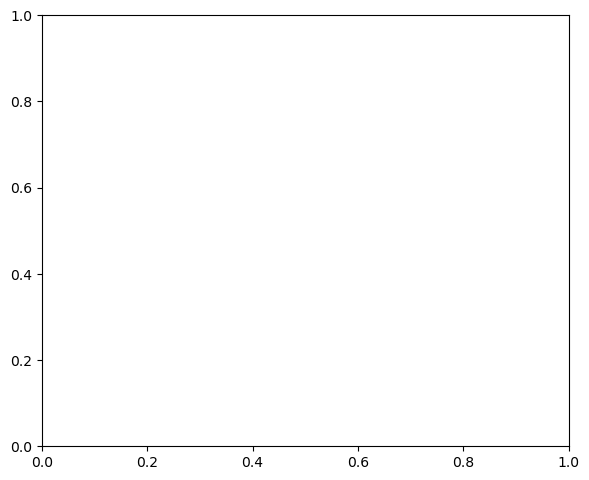

In [126]:
# ------------------------------------------------------------
# MAIN FIGURE 1: mean angle vs scale
# ------------------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(6.8, 5.6))

# faint individual cubes
for y in ens["mean_all"]:
    ax.plot(scales, y, color="C0", lw=1.2, alpha=0.25)
for y in ens["mean_A"]:
    ax.plot(scales, y, color="C1", lw=1.2, alpha=0.25, ls="--")
for y in ens["mean_J"]:
    ax.plot(scales, y, color="C2", lw=1.2, alpha=0.25, ls=":")

# bold ensemble means + black SEM bars
ax.errorbar(scales, ens["mean_all_avg"], yerr=ens["mean_all_sem"],
            color="C0", lw=2.6, marker="o", ms=6,
            ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
ax.errorbar(scales, ens["mean_A_avg"], yerr=ens["mean_A_sem"],
            color="C1", lw=2.6, marker="s", ms=6, ls="--",
            ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
ax.errorbar(scales, ens["mean_J_avg"], yerr=ens["mean_J_sem"],
            color="C2", lw=2.6, marker="d", ms=6, ls=":",
            ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)

ax.axhline(baseline, color="k", lw=1.8, ls="--")

ax.set_xlabel("r")
ax.set_ylabel("mean angle (deg)")

legend_handles = [
    Line2D([0], [0], color="k", lw=1.8, ls="--", label=r"random 3D baseline = 57.3$^\circ$"),
    Line2D([0], [0], color="C0", lw=2.6, marker="o", ms=7, label="all points"),
    Line2D([0], [0], color="C1", lw=2.6, marker="s", ms=7, ls="--", label=r"top 10% by $A_r$"),
    Line2D([0], [0], color="C2", lw=2.6, marker="d", ms=7, ls=":", label=r"top 10% by $|j|$"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=2, frameon=True, fontsize=10)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(out_dir / "main1.pdf", bbox_inches="tight")
fig.savefig(out_dir / "main1.png", dpi=220, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# MAIN FIGURE 2A / 2B: ensemble Pearson matrices
# ------------------------------------------------------------
for fname, mat, title in [
    ("main2A", ens["pearson_c_avg"], r"Ensemble Pearson of $c_r=\cos\theta_r$"),
    ("main2B", ens["pearson_s_avg"], r"Ensemble Pearson of $s_r=|\sin\theta_r|$"),
]:
    fig, ax = plt.subplots(figsize=(5.0, 4.7))
    im = ax.imshow(mat, origin="lower", cmap="viridis", vmin=np.nanmin(mat), vmax=1.0)
    ax.set_xticks(range(len(scales)))
    ax.set_yticks(range(len(scales)))
    ax.set_xticklabels([str(int(x)) for x in scales])
    ax.set_yticklabels([str(int(x)) for x in scales])
    ax.set_xlabel(r"$r_j$")
    ax.set_ylabel(r"$r_i$")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("correlation")
    fig.tight_layout()
    fig.savefig(out_dir / f"{fname}.pdf", bbox_inches="tight")
    fig.savefig(out_dir / f"{fname}.png", dpi=220, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# MAIN FIGURE 2C: surrogate summary
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.4, 4.7))

rng = np.random.default_rng(12345)
jit = 0.035

cr_vals = ens["surrogate_cr"]
sr_vals = ens["surrogate_sr"]

for j in range(len(cats)):
    xj_c = np.full(cr_vals.shape[0], xcat[j] - 0.07) + rng.uniform(-jit, jit, size=cr_vals.shape[0])
    xj_s = np.full(sr_vals.shape[0], xcat[j] + 0.07) + rng.uniform(-jit, jit, size=sr_vals.shape[0])

    ax.scatter(xj_c, cr_vals[:, j], s=34, alpha=0.20, color="C0", edgecolors="none")
    ax.scatter(xj_s, sr_vals[:, j], s=34, alpha=0.20, color="C1", edgecolors="none")

    mc = np.mean(cr_vals[:, j]); sc = sem(cr_vals[:, j], axis=0)
    ms = np.mean(sr_vals[:, j]); ss = sem(sr_vals[:, j], axis=0)

    ax.errorbar(xcat[j] - 0.07, mc, yerr=sc, fmt="o", ms=8,
                mfc="white", mec="C0", mew=2.0, color="C0",
                ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
    ax.errorbar(xcat[j] + 0.07, ms, yerr=ss, fmt="s", ms=8,
                mfc="white", mec="C1", mew=2.0, color="C1",
                ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)

ax.set_xticks(xcat)
ax.set_xticklabels(cats, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")

legend_handles = [
    Line2D([0], [0], marker="o", ms=9, mfc="white", mec="C0", mew=2.0, lw=0, label=r"$c_r$"),
    Line2D([0], [0], marker="s", ms=9, mfc="white", mec="C1", mew=2.0, lw=0, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=10)

fig.tight_layout()
fig.savefig(out_dir / "main2C.pdf", bbox_inches="tight")
fig.savefig(out_dir / "main2C.png", dpi=220, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# COMBINED MAIN FIGURE 2: matrices + surrogate summary
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(14.8, 4.7), gridspec_kw={"width_ratios": [1, 1, 1.1]})

# 2A
im0 = axs[0].imshow(ens["pearson_c_avg"], origin="lower", cmap="viridis",
                    vmin=np.nanmin(ens["pearson_c_avg"]), vmax=1.0)
axs[0].set_xticks(range(len(scales))); axs[0].set_yticks(range(len(scales)))
axs[0].set_xticklabels([str(int(x)) for x in scales]); axs[0].set_yticklabels([str(int(x)) for x in scales])
axs[0].set_xlabel(r"$r_j$"); axs[0].set_ylabel(r"$r_i$")
axs[0].set_title(r"Ensemble Pearson of $c_r=\cos\theta_r$")
cbar0 = fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# 2B
im1 = axs[1].imshow(ens["pearson_s_avg"], origin="lower", cmap="viridis",
                    vmin=np.nanmin(ens["pearson_s_avg"]), vmax=1.0)
axs[1].set_xticks(range(len(scales))); axs[1].set_yticks(range(len(scales)))
axs[1].set_xticklabels([str(int(x)) for x in scales]); axs[1].set_yticklabels([str(int(x)) for x in scales])
axs[1].set_xlabel(r"$r_j$"); axs[1].set_ylabel(r"$r_i$")
axs[1].set_title(r"Ensemble Pearson of $s_r=|\sin\theta_r|$")
cbar1 = fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

# 2C
ax = axs[2]
for j in range(len(cats)):
    xj_c = np.full(cr_vals.shape[0], xcat[j] - 0.07) + rng.uniform(-jit, jit, size=cr_vals.shape[0])
    xj_s = np.full(sr_vals.shape[0], xcat[j] + 0.07) + rng.uniform(-jit, jit, size=sr_vals.shape[0])

    ax.scatter(xj_c, cr_vals[:, j], s=34, alpha=0.20, color="C0", edgecolors="none")
    ax.scatter(xj_s, sr_vals[:, j], s=34, alpha=0.20, color="C1", edgecolors="none")

    mc = np.mean(cr_vals[:, j]); sc = sem(cr_vals[:, j], axis=0)
    ms = np.mean(sr_vals[:, j]); ss = sem(sr_vals[:, j], axis=0)

    ax.errorbar(xcat[j] - 0.07, mc, yerr=sc, fmt="o", ms=8,
                mfc="white", mec="C0", mew=2.0, color="C0",
                ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
    ax.errorbar(xcat[j] + 0.07, ms, yerr=ss, fmt="s", ms=8,
                mfc="white", mec="C1", mew=2.0, color="C1",
                ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)

ax.set_xticks(xcat)
ax.set_xticklabels(cats, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")
ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=10)

fig.tight_layout()
fig.savefig(out_dir / "ensemble_crossscale_and_surrogates_320cubes.pdf", bbox_inches="tight")
fig.savefig(out_dir / "ensemble_crossscale_and_surrogates_320cubes.png", dpi=220, bbox_inches="tight")
plt.show()

In [127]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
raw_dir = base_dir / "raw"
processed_dir = base_dir / "processed"
manifest_path = base_dir / "manifests" / "manifest_15_random_nonoverlap_320_1based_seed20260421.csv"

out_dir = processed_dir / "final_figures_new15"
out_dir.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(manifest_path)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def make_raw_names(rec):
    vel = f"mhd1024_velocity_t{int(rec.t):04d}_x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    mag = f"mhd1024_magneticfield_t{int(rec.t):04d}_x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    return vel, mag

def get_curve(d, names):
    n = len(d["scales"])
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float).squeeze()
            if arr.ndim == 1 and arr.size == n:
                return arr
    raise KeyError(f"Missing curve among {names}. Keys: {list(d.keys())}")

def get_matrix(d, names):
    n = len(d["scales"])
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float)
            if arr.shape == (n, n):
                return arr
    raise KeyError(f"Missing matrix among {names}. Keys: {list(d.keys())}")

def get_baseline(d):
    for k in ["random_unsigned_3d_baseline_deg", "random_3d_baseline_deg"]:
        if k in d:
            return float(d[k])
    raise KeyError("Missing random 3D baseline.")

def get_surrogate_mean(d, obs_kind, stat_kind):
    ss = d["surrogate_summary"]

    obs_candidates = {
        "c": ["pearson_c", "c"],
        "s": ["pearson_s", "s"],
    }[obs_kind]

    stat_candidates = {
        "full": ["full_shuffle"],
        "Abin": ["A_bin_shuffle", "Ar_bin_shuffle", "A_r_bin_shuffle"],
        "jbin": ["j_bin_shuffle", "|j|_bin_shuffle"],
    }[stat_kind]

    for ok in obs_candidates:
        if ok in ss:
            block = ss[ok]
            for sk in stat_candidates:
                if sk in block:
                    entry = block[sk]
                    if isinstance(entry, dict) and "mean" in entry:
                        return float(entry["mean"])
                    return float(entry)
    raise KeyError(f"Missing surrogate summary for obs={obs_kind}, stat={stat_kind}")

def offdiag_mean(mat):
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(mat.shape[0], k=1)
    return float(np.nanmean(mat[iu]))

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = a.shape[axis]
    return np.nanstd(a, axis=axis, ddof=1) / np.sqrt(n)

def decay_curve(scales, mat):
    scales = np.asarray(scales, dtype=float)
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(len(scales), k=1)
    dlog = np.abs(np.log(scales[iu[0]] / scales[iu[1]]))
    vals = mat[iu]
    good = np.isfinite(vals)
    dlog, vals = dlog[good], vals[good]

    tags = np.round(dlog, 12)
    uniq = np.unique(tags)

    x, y = [], []
    for u in uniq:
        sel = tags == u
        x.append(dlog[sel].mean())
        y.append(vals[sel].mean())
    return np.asarray(x), np.asarray(y)

# ------------------------------------------------------------
# match processed JSONs to new 15 raw files
# ------------------------------------------------------------
wanted = {}
for rec in manifest.itertuples(index=False):
    vel_name, mag_name = make_raw_names(rec)
    wanted[(vel_name, mag_name)] = {
        "cube_id": rec.cube_id,
        "t": int(rec.t),
    }

records = []
missing = []

for (vel_name, mag_name), meta in wanted.items():
    candidates = []
    for path in processed_dir.rglob("*.json"):
        try:
            with open(path, "r") as f:
                d = json.load(f)
        except Exception:
            continue
        if not isinstance(d, dict):
            continue
        rf = d.get("raw_files", {})
        if not isinstance(rf, dict):
            continue
        v = Path(str(rf.get("velocity", ""))).name
        b = Path(str(rf.get("magneticfield", ""))).name
        if v == vel_name and b == mag_name:
            candidates.append(path)

    if len(candidates) == 0:
        missing.append((meta["cube_id"], vel_name, mag_name))
        continue

    chosen = max(candidates, key=lambda p: p.stat().st_mtime)
    with open(chosen, "r") as f:
        d = json.load(f)

    records.append({
        "cube_id": meta["cube_id"],
        "t": meta["t"],
        "json_path": chosen,
        "data": d,
    })

records = sorted(records, key=lambda r: r["cube_id"])

print("Matched processed JSONs:", len(records))
for r in records:
    print(f"  {r['cube_id']}  t={r['t']:04d}  <-  {r['json_path'].name}")

if missing:
    print("\nMISSING:")
    for m in missing:
        print(" ", m[0], m[1], m[2])

assert len(records) == 15, "Did not find all 15 processed JSONs."

# ------------------------------------------------------------
# assemble ensemble arrays
# ------------------------------------------------------------
scales = np.asarray(records[0]["data"]["scales"], dtype=float)
baseline = get_baseline(records[0]["data"])

mean_all = np.vstack([get_curve(r["data"], ["mean_all_phi_deg", "mean_all_deg"]) for r in records])
mean_A   = np.vstack([get_curve(r["data"], ["mean_A_phi_deg", "mean_A_deg"]) for r in records])
mean_J   = np.vstack([get_curve(r["data"], ["mean_J_phi_deg", "mean_J_deg"]) for r in records])

pearson_c = np.stack([get_matrix(r["data"], ["pearson_c"]) for r in records], axis=0)
pearson_s = np.stack([get_matrix(r["data"], ["pearson_s"]) for r in records], axis=0)
spearman_c = np.stack([get_matrix(r["data"], ["spearman_c"]) for r in records], axis=0)
spearman_s = np.stack([get_matrix(r["data"], ["spearman_s"]) for r in records], axis=0)

# surrogate arrays
cats = ["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"]
xcat = np.arange(len(cats), dtype=float)

cr_real = np.array([offdiag_mean(m) for m in pearson_c], dtype=float)
sr_real = np.array([offdiag_mean(m) for m in pearson_s], dtype=float)
cr_full = np.array([get_surrogate_mean(r["data"], "c", "full") for r in records], dtype=float)
sr_full = np.array([get_surrogate_mean(r["data"], "s", "full") for r in records], dtype=float)
cr_Abin = np.array([get_surrogate_mean(r["data"], "c", "Abin") for r in records], dtype=float)
sr_Abin = np.array([get_surrogate_mean(r["data"], "s", "Abin") for r in records], dtype=float)
cr_jbin = np.array([get_surrogate_mean(r["data"], "c", "jbin") for r in records], dtype=float)
sr_jbin = np.array([get_surrogate_mean(r["data"], "s", "jbin") for r in records], dtype=float)

# decay arrays
c_decay_each = []
s_decay_each = []
x_decay = None
for mc, ms in zip(pearson_c, pearson_s):
    xc, yc = decay_curve(scales, mc)
    xs, ys = decay_curve(scales, ms)
    if x_decay is None:
        x_decay = xc
    c_decay_each.append(yc)
    s_decay_each.append(ys)

c_decay_each = np.vstack(c_decay_each)
s_decay_each = np.vstack(s_decay_each)

print("\nReady for plotting.")

Matched processed JSONs: 15
  C01  t=0218  <-  C01_t0218_xyplane_interp_r32_192.json
  C02  t=0553  <-  C02_t0553_xyplane_interp_r32_192.json
  C03  t=0825  <-  C03_t0825_xyplane_interp_r32_192.json
  C04  t=0217  <-  C04_t0217_xyplane_interp_r32_192.json
  C05  t=0493  <-  C05_t0493_xyplane_interp_r32_192.json
  C06  t=0022  <-  C06_t0022_xyplane_interp_r32_192.json
  C07  t=0292  <-  C07_t0292_xyplane_interp_r32_192.json
  C08  t=0976  <-  C08_t0976_xyplane_interp_r32_192.json
  C09  t=0699  <-  C09_t0699_xyplane_interp_r32_192.json
  C10  t=0778  <-  C10_t0778_xyplane_interp_r32_192.json
  C11  t=0843  <-  C11_t0843_xyplane_interp_r32_192.json
  C12  t=0273  <-  C12_t0273_xyplane_interp_r32_192.json
  C13  t=0539  <-  C13_t0539_xyplane_interp_r32_192.json
  C14  t=0302  <-  C14_t0302_xyplane_interp_r32_192.json
  C15  t=0118  <-  C15_t0118_xyplane_interp_r32_192.json

Ready for plotting.


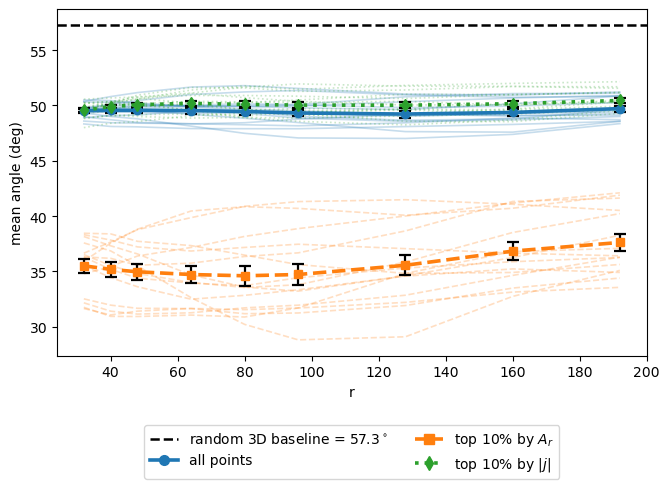

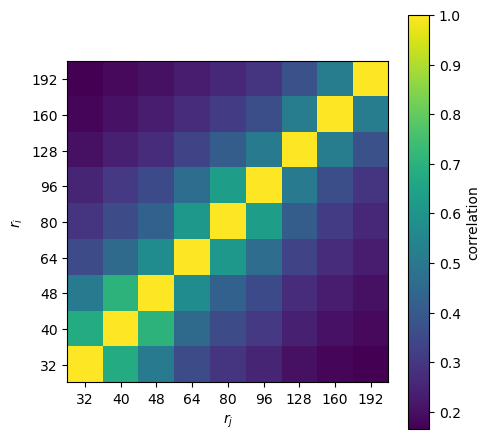

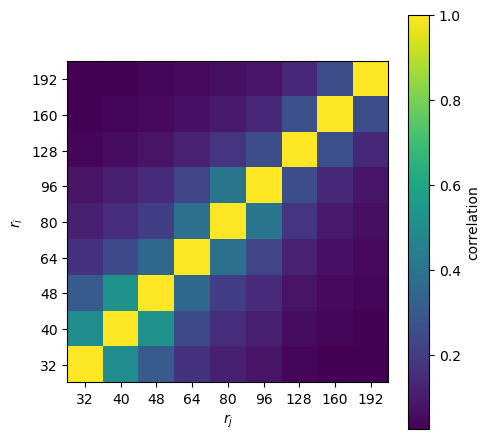

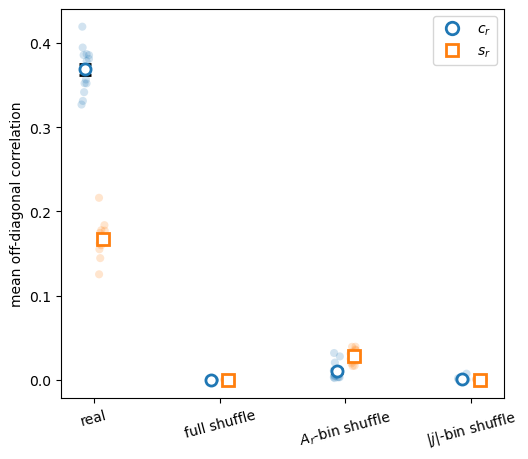

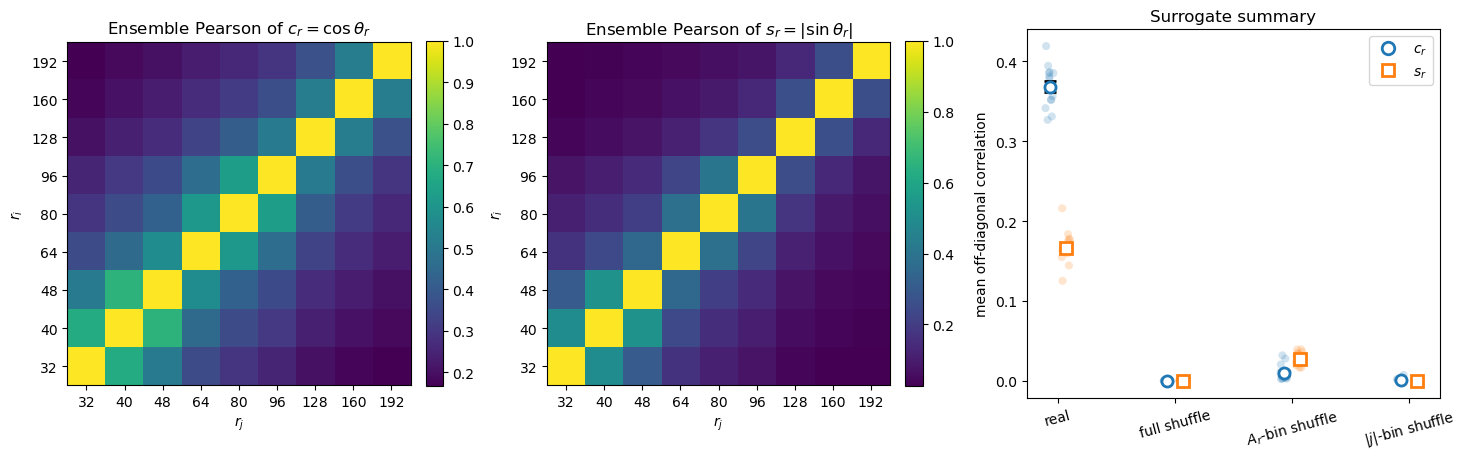

Saved main figures to:
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15


In [128]:
# ------------------------------------------------------------
# MAIN FIGURE 1
# ------------------------------------------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(6.8, 5.6))

for y in mean_all:
    ax.plot(scales, y, color="C0", lw=1.2, alpha=0.25)
for y in mean_A:
    ax.plot(scales, y, color="C1", lw=1.2, alpha=0.25, ls="--")
for y in mean_J:
    ax.plot(scales, y, color="C2", lw=1.2, alpha=0.25, ls=":")

ax.errorbar(scales, mean_all.mean(axis=0), yerr=sem(mean_all, axis=0),
            color="C0", lw=2.6, marker="o", ms=6,
            ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
ax.errorbar(scales, mean_A.mean(axis=0), yerr=sem(mean_A, axis=0),
            color="C1", lw=2.6, marker="s", ms=6, ls="--",
            ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
ax.errorbar(scales, mean_J.mean(axis=0), yerr=sem(mean_J, axis=0),
            color="C2", lw=2.6, marker="d", ms=6, ls=":",
            ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)

ax.axhline(baseline, color="k", lw=1.8, ls="--")

ax.set_xlabel("r")
ax.set_ylabel("mean angle (deg)")

legend_handles = [
    Line2D([0], [0], color="k", lw=1.8, ls="--", label=r"random 3D baseline = 57.3$^\circ$"),
    Line2D([0], [0], color="C0", lw=2.6, marker="o", ms=7, label="all points"),
    Line2D([0], [0], color="C1", lw=2.6, marker="s", ms=7, ls="--", label=r"top 10% by $A_r$"),
    Line2D([0], [0], color="C2", lw=2.6, marker="d", ms=7, ls=":", label=r"top 10% by $|j|$"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=2, frameon=True, fontsize=10)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(out_dir / "main1.pdf", bbox_inches="tight")
fig.savefig(out_dir / "main1.png", dpi=220, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# MAIN FIGURES 2A and 2B
# ------------------------------------------------------------
for fname, mat in [
    ("main2A", pearson_c.mean(axis=0)),
    ("main2B", pearson_s.mean(axis=0)),
]:
    fig, ax = plt.subplots(figsize=(5.0, 4.7))
    im = ax.imshow(mat, origin="lower", cmap="viridis", vmin=np.nanmin(mat), vmax=1.0)
    ax.set_xticks(range(len(scales)))
    ax.set_yticks(range(len(scales)))
    ax.set_xticklabels([str(int(x)) for x in scales])
    ax.set_yticklabels([str(int(x)) for x in scales])
    ax.set_xlabel(r"$r_j$")
    ax.set_ylabel(r"$r_i$")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("correlation")
    fig.tight_layout()
    fig.savefig(out_dir / f"{fname}.pdf", bbox_inches="tight")
    fig.savefig(out_dir / f"{fname}.png", dpi=220, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# MAIN FIGURE 2C
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.4, 4.7))

rng = np.random.default_rng(12345)
jit = 0.035

cr_vals = np.vstack([cr_real, cr_full, cr_Abin, cr_jbin]).T
sr_vals = np.vstack([sr_real, sr_full, sr_Abin, sr_jbin]).T

for j in range(len(cats)):
    xj_c = np.full(cr_vals.shape[0], xcat[j] - 0.07) + rng.uniform(-jit, jit, size=cr_vals.shape[0])
    xj_s = np.full(sr_vals.shape[0], xcat[j] + 0.07) + rng.uniform(-jit, jit, size=sr_vals.shape[0])

    ax.scatter(xj_c, cr_vals[:, j], s=34, alpha=0.20, color="C0", edgecolors="none")
    ax.scatter(xj_s, sr_vals[:, j], s=34, alpha=0.20, color="C1", edgecolors="none")

    ax.errorbar(xcat[j] - 0.07, np.mean(cr_vals[:, j]), yerr=sem(cr_vals[:, j], axis=0),
                fmt="o", ms=8, mfc="white", mec="C0", mew=2.0, color="C0",
                ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
    ax.errorbar(xcat[j] + 0.07, np.mean(sr_vals[:, j]), yerr=sem(sr_vals[:, j], axis=0),
                fmt="s", ms=8, mfc="white", mec="C1", mew=2.0, color="C1",
                ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)

ax.set_xticks(xcat)
ax.set_xticklabels(cats, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")

legend_handles = [
    Line2D([0], [0], marker="o", ms=9, mfc="white", mec="C0", mew=2.0, lw=0, label=r"$c_r$"),
    Line2D([0], [0], marker="s", ms=9, mfc="white", mec="C1", mew=2.0, lw=0, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=10)

fig.tight_layout()
fig.savefig(out_dir / "main2C.pdf", bbox_inches="tight")
fig.savefig(out_dir / "main2C.png", dpi=220, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# COMBINED MAIN FIGURE 2
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(14.8, 4.7), gridspec_kw={"width_ratios": [1, 1, 1.1]})

im0 = axs[0].imshow(pearson_c.mean(axis=0), origin="lower", cmap="viridis",
                    vmin=np.nanmin(pearson_c.mean(axis=0)), vmax=1.0)
axs[0].set_xticks(range(len(scales))); axs[0].set_yticks(range(len(scales)))
axs[0].set_xticklabels([str(int(x)) for x in scales]); axs[0].set_yticklabels([str(int(x)) for x in scales])
axs[0].set_xlabel(r"$r_j$"); axs[0].set_ylabel(r"$r_i$")
axs[0].set_title(r"Ensemble Pearson of $c_r=\cos\theta_r$")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(pearson_s.mean(axis=0), origin="lower", cmap="viridis",
                    vmin=np.nanmin(pearson_s.mean(axis=0)), vmax=1.0)
axs[1].set_xticks(range(len(scales))); axs[1].set_yticks(range(len(scales)))
axs[1].set_xticklabels([str(int(x)) for x in scales]); axs[1].set_yticklabels([str(int(x)) for x in scales])
axs[1].set_xlabel(r"$r_j$"); axs[1].set_ylabel(r"$r_i$")
axs[1].set_title(r"Ensemble Pearson of $s_r=|\sin\theta_r|$")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

ax = axs[2]
for j in range(len(cats)):
    xj_c = np.full(cr_vals.shape[0], xcat[j] - 0.07) + rng.uniform(-jit, jit, size=cr_vals.shape[0])
    xj_s = np.full(sr_vals.shape[0], xcat[j] + 0.07) + rng.uniform(-jit, jit, size=sr_vals.shape[0])

    ax.scatter(xj_c, cr_vals[:, j], s=34, alpha=0.20, color="C0", edgecolors="none")
    ax.scatter(xj_s, sr_vals[:, j], s=34, alpha=0.20, color="C1", edgecolors="none")

    ax.errorbar(xcat[j] - 0.07, np.mean(cr_vals[:, j]), yerr=sem(cr_vals[:, j], axis=0),
                fmt="o", ms=8, mfc="white", mec="C0", mew=2.0, color="C0",
                ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
    ax.errorbar(xcat[j] + 0.07, np.mean(sr_vals[:, j]), yerr=sem(sr_vals[:, j], axis=0),
                fmt="s", ms=8, mfc="white", mec="C1", mew=2.0, color="C1",
                ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)

ax.set_xticks(xcat)
ax.set_xticklabels(cats, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")
ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=10)

fig.tight_layout()
fig.savefig(out_dir / "ensemble_crossscale_and_surrogates_320cubes.pdf", bbox_inches="tight")
fig.savefig(out_dir / "ensemble_crossscale_and_surrogates_320cubes.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved main figures to:")
print(out_dir)

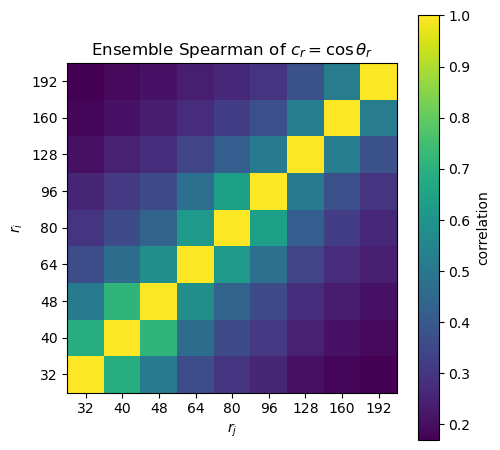

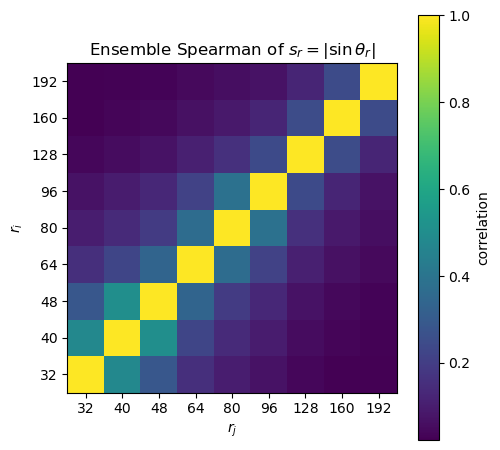

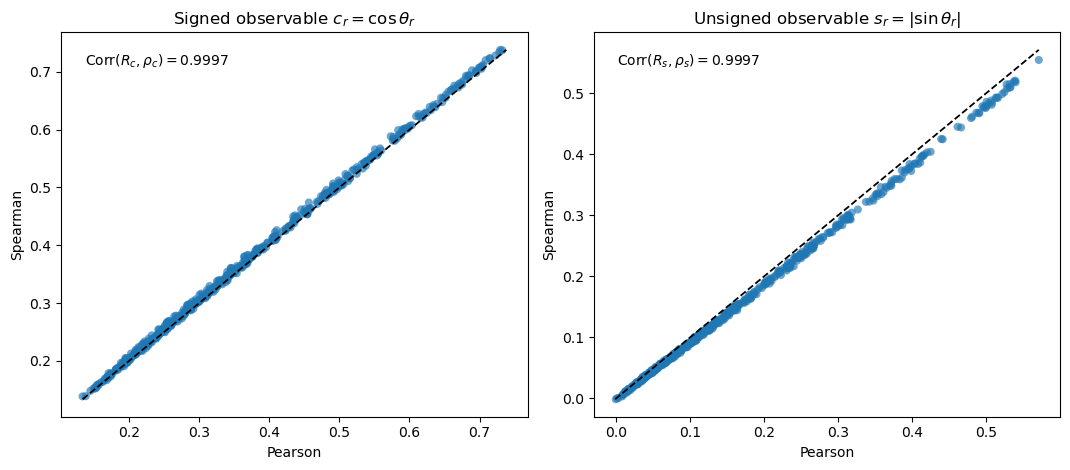

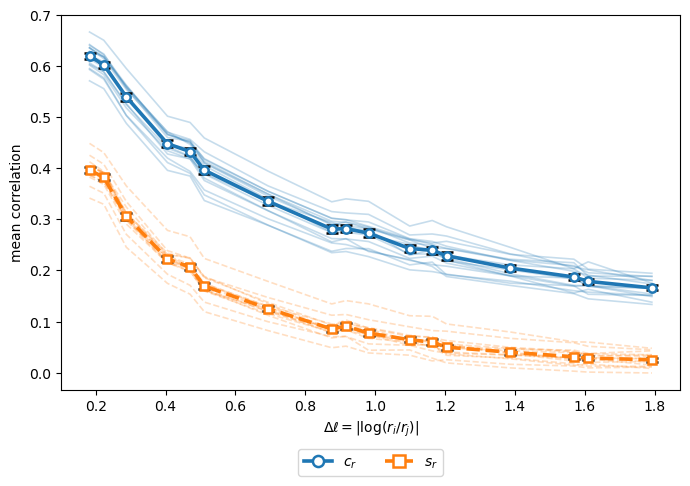

Saved supplementary figures to:
/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15


In [129]:
# ------------------------------------------------------------
# SUPP FIGURES S1A and S1B
# ------------------------------------------------------------
for fname, mat, title in [
    ("mainS1A", spearman_c.mean(axis=0), r"Ensemble Spearman of $c_r=\cos\theta_r$"),
    ("mainS1B", spearman_s.mean(axis=0), r"Ensemble Spearman of $s_r=|\sin\theta_r|$"),
]:
    fig, ax = plt.subplots(figsize=(5.1, 4.8))
    im = ax.imshow(mat, origin="lower", cmap="viridis", vmin=np.nanmin(mat), vmax=1.0)
    ax.set_xticks(range(len(scales)))
    ax.set_yticks(range(len(scales)))
    ax.set_xticklabels([str(int(x)) for x in scales])
    ax.set_yticklabels([str(int(x)) for x in scales])
    ax.set_xlabel(r"$r_j$")
    ax.set_ylabel(r"$r_i$")
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("correlation")
    fig.tight_layout()
    fig.savefig(out_dir / f"{fname}.pdf", bbox_inches="tight")
    fig.savefig(out_dir / f"{fname}.png", dpi=220, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# SUPP FIGURE S2
# ------------------------------------------------------------
iu = np.triu_indices(len(scales), k=1)

Pc = np.concatenate([m[iu] for m in pearson_c])
Ps = np.concatenate([m[iu] for m in spearman_c])
Qc = np.concatenate([m[iu] for m in pearson_s])
Qs = np.concatenate([m[iu] for m in spearman_s])

corr_c = np.corrcoef(Pc, Ps)[0, 1]
corr_s = np.corrcoef(Qc, Qs)[0, 1]

fig, axs = plt.subplots(1, 2, figsize=(10.8, 4.8))

axs[0].scatter(Pc, Ps, s=34, alpha=0.65, color="C0", edgecolors="none")
xmin = min(Pc.min(), Ps.min()); xmax = max(Pc.max(), Ps.max())
axs[0].plot([xmin, xmax], [xmin, xmax], "k--", lw=1.3)
axs[0].set_xlabel("Pearson")
axs[0].set_ylabel("Spearman")
axs[0].set_title(r"Signed observable $c_r=\cos\theta_r$")
axs[0].text(0.05, 0.95, rf"$\mathrm{{Corr}}(R_c,\rho_c) = {corr_c:.4f}$",
            transform=axs[0].transAxes, ha="left", va="top")

axs[1].scatter(Qc, Qs, s=34, alpha=0.65, color="C0", edgecolors="none")
xmin = min(Qc.min(), Qs.min()); xmax = max(Qc.max(), Qs.max())
axs[1].plot([xmin, xmax], [xmin, xmax], "k--", lw=1.3)
axs[1].set_xlabel("Pearson")
axs[1].set_ylabel("Spearman")
axs[1].set_title(r"Unsigned observable $s_r=|\sin\theta_r|$")
axs[1].text(0.05, 0.95, rf"$\mathrm{{Corr}}(R_s,\rho_s) = {corr_s:.4f}$",
            transform=axs[1].transAxes, ha="left", va="top")

fig.tight_layout()
fig.savefig(out_dir / "mainS2.pdf", bbox_inches="tight")
fig.savefig(out_dir / "mainS2.png", dpi=220, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# SUPP FIGURE S3
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.0, 5.4))

for y in c_decay_each:
    ax.plot(x_decay, y, color="C0", lw=1.2, alpha=0.25)
for y in s_decay_each:
    ax.plot(x_decay, y, color="C1", lw=1.2, alpha=0.25, ls="--")

ax.errorbar(x_decay, c_decay_each.mean(axis=0), yerr=sem(c_decay_each, axis=0),
            color="C0", lw=2.6, marker="o", ms=6,
            mfc="white", mec="C0", mew=1.8,
            ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
ax.errorbar(x_decay, s_decay_each.mean(axis=0), yerr=sem(s_decay_each, axis=0),
            color="C1", lw=2.6, marker="s", ms=6, ls="--",
            mfc="white", mec="C1", mew=1.8,
            ecolor="k", elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")

legend_handles = [
    Line2D([0], [0], color="C0", lw=2.6, marker="o", ms=8, mfc="white", mec="C0", mew=1.8, label=r"$c_r$"),
    Line2D([0], [0], color="C1", lw=2.6, marker="s", ms=8, mfc="white", mec="C1", mew=1.8, ls="--", label=r"$s_r$"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.14),
          ncol=2, frameon=True, fontsize=10)

fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(out_dir / "mainS3.pdf", bbox_inches="tight")
fig.savefig(out_dir / "mainS3.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved supplementary figures to:")
print(out_dir)

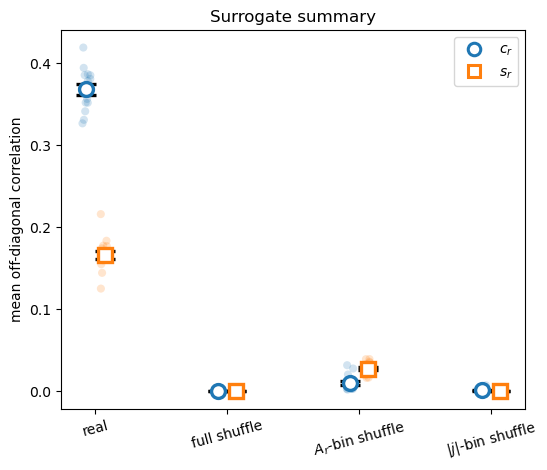

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/main2C.pdf
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/main2C.png


In [130]:
# ------------------------------------------------------------
# CLEAN MAIN FIGURE 2C ONLY
# visible black error bars + no repeated panels
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.close("all")

fig, ax = plt.subplots(figsize=(5.6, 4.8))

cats = ["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"]
xcat = np.arange(len(cats), dtype=float)

rng = np.random.default_rng(12345)
jit = 0.035

cr_vals = np.vstack([cr_real, cr_full, cr_Abin, cr_jbin]).T
sr_vals = np.vstack([sr_real, sr_full, sr_Abin, sr_jbin]).T

for j in range(len(cats)):
    # faint individual-cube points
    xj_c = np.full(cr_vals.shape[0], xcat[j] - 0.07) + rng.uniform(-jit, jit, size=cr_vals.shape[0])
    xj_s = np.full(sr_vals.shape[0], xcat[j] + 0.07) + rng.uniform(-jit, jit, size=sr_vals.shape[0])

    ax.scatter(xj_c, cr_vals[:, j], s=34, alpha=0.20, color="C0", edgecolors="none", zorder=1)
    ax.scatter(xj_s, sr_vals[:, j], s=34, alpha=0.20, color="C1", edgecolors="none", zorder=1)

    # ensemble means + SEM
    mc = np.mean(cr_vals[:, j]); sc = sem(cr_vals[:, j], axis=0)
    ms = np.mean(sr_vals[:, j]); ss = sem(sr_vals[:, j], axis=0)

    # draw BLACK error bars first, with no marker
    ax.errorbar(xcat[j] - 0.07, mc, yerr=sc, fmt="none",
                ecolor="k", elinewidth=2.4, capsize=7, capthick=2.4, zorder=4)
    ax.errorbar(xcat[j] + 0.07, ms, yerr=ss, fmt="none",
                ecolor="k", elinewidth=2.4, capsize=7, capthick=2.4, zorder=4)

    # open markers on top
    ax.plot(xcat[j] - 0.07, mc, marker="o", ms=10,
            mfc="white", mec="C0", mew=2.4, linestyle="none", zorder=5)
    ax.plot(xcat[j] + 0.07, ms, marker="s", ms=10,
            mfc="white", mec="C1", mew=2.4, linestyle="none", zorder=5)

ax.set_xticks(xcat)
ax.set_xticklabels(cats, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")

legend_handles = [
    Line2D([0], [0], marker="o", ms=9, mfc="white", mec="C0", mew=2.2, lw=0, label=r"$c_r$"),
    Line2D([0], [0], marker="s", ms=9, mfc="white", mec="C1", mew=2.2, lw=0, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=10)

fig.tight_layout()
fig.savefig(out_dir / "main2C.pdf", bbox_inches="tight")
fig.savefig(out_dir / "main2C.png", dpi=220, bbox_inches="tight")
plt.show()

print("saved:", out_dir / "main2C.pdf")
print("saved:", out_dir / "main2C.png")

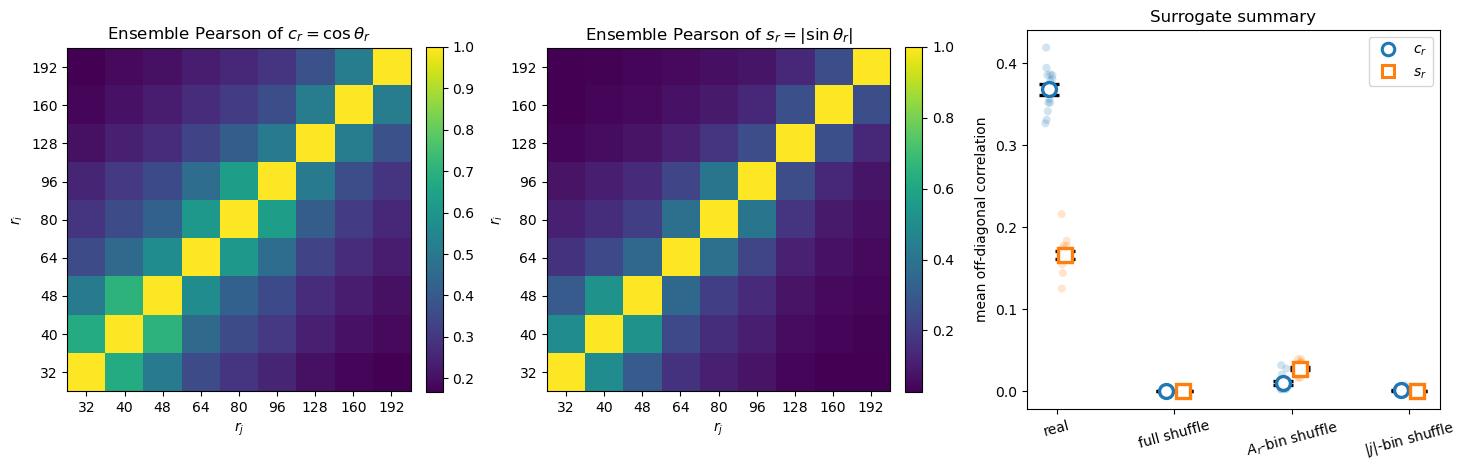

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/ensemble_crossscale_and_surrogates_320cubes.pdf
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/ensemble_crossscale_and_surrogates_320cubes.png


In [131]:
# ------------------------------------------------------------
# CLEAN COMBINED MAIN FIGURE 2 ONLY
# (2A heatmap, 2B heatmap, 2C surrogate summary)
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.close("all")

fig, axs = plt.subplots(1, 3, figsize=(14.8, 4.8), gridspec_kw={"width_ratios": [1, 1, 1.1]})

# ------------------------------------------------------------
# panel A
# ------------------------------------------------------------
mat_c = pearson_c.mean(axis=0)
im0 = axs[0].imshow(mat_c, origin="lower", cmap="viridis",
                    vmin=np.nanmin(mat_c), vmax=1.0)
axs[0].set_xticks(range(len(scales)))
axs[0].set_yticks(range(len(scales)))
axs[0].set_xticklabels([str(int(x)) for x in scales])
axs[0].set_yticklabels([str(int(x)) for x in scales])
axs[0].set_xlabel(r"$r_j$")
axs[0].set_ylabel(r"$r_i$")
axs[0].set_title(r"Ensemble Pearson of $c_r=\cos\theta_r$")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

# ------------------------------------------------------------
# panel B
# ------------------------------------------------------------
mat_s = pearson_s.mean(axis=0)
im1 = axs[1].imshow(mat_s, origin="lower", cmap="viridis",
                    vmin=np.nanmin(mat_s), vmax=1.0)
axs[1].set_xticks(range(len(scales)))
axs[1].set_yticks(range(len(scales)))
axs[1].set_xticklabels([str(int(x)) for x in scales])
axs[1].set_yticklabels([str(int(x)) for x in scales])
axs[1].set_xlabel(r"$r_j$")
axs[1].set_ylabel(r"$r_i$")
axs[1].set_title(r"Ensemble Pearson of $s_r=|\sin\theta_r|$")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

# ------------------------------------------------------------
# panel C
# ------------------------------------------------------------
ax = axs[2]

cats = ["real", "full shuffle", r"$A_r$-bin shuffle", r"$|j|$-bin shuffle"]
xcat = np.arange(len(cats), dtype=float)

rng = np.random.default_rng(12345)
jit = 0.035

cr_vals = np.vstack([cr_real, cr_full, cr_Abin, cr_jbin]).T
sr_vals = np.vstack([sr_real, sr_full, sr_Abin, sr_jbin]).T

for j in range(len(cats)):
    # faint individual-cube points
    xj_c = np.full(cr_vals.shape[0], xcat[j] - 0.07) + rng.uniform(-jit, jit, size=cr_vals.shape[0])
    xj_s = np.full(sr_vals.shape[0], xcat[j] + 0.07) + rng.uniform(-jit, jit, size=sr_vals.shape[0])

    ax.scatter(xj_c, cr_vals[:, j], s=34, alpha=0.20, color="C0", edgecolors="none", zorder=1)
    ax.scatter(xj_s, sr_vals[:, j], s=34, alpha=0.20, color="C1", edgecolors="none", zorder=1)

    # means
    mc = np.mean(cr_vals[:, j]); sc = sem(cr_vals[:, j], axis=0)
    ms = np.mean(sr_vals[:, j]); ss = sem(sr_vals[:, j], axis=0)

    # black error bars first
    ax.errorbar(xcat[j] - 0.07, mc, yerr=sc, fmt="none",
                ecolor="k", elinewidth=2.4, capsize=7, capthick=2.4, zorder=4)
    ax.errorbar(xcat[j] + 0.07, ms, yerr=ss, fmt="none",
                ecolor="k", elinewidth=2.4, capsize=7, capthick=2.4, zorder=4)

    # open markers on top
    ax.plot(xcat[j] - 0.07, mc, marker="o", ms=10,
            mfc="white", mec="C0", mew=2.4, linestyle="none", zorder=5)
    ax.plot(xcat[j] + 0.07, ms, marker="s", ms=10,
            mfc="white", mec="C1", mew=2.4, linestyle="none", zorder=5)

ax.set_xticks(xcat)
ax.set_xticklabels(cats, rotation=15)
ax.set_ylabel("mean off-diagonal correlation")
ax.set_title("Surrogate summary")

legend_handles = [
    Line2D([0], [0], marker="o", ms=9, mfc="white", mec="C0", mew=2.2, lw=0, label=r"$c_r$"),
    Line2D([0], [0], marker="s", ms=9, mfc="white", mec="C1", mew=2.2, lw=0, label=r"$s_r$"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=10)

fig.tight_layout()
fig.savefig(out_dir / "ensemble_crossscale_and_surrogates_320cubes.pdf", bbox_inches="tight")
fig.savefig(out_dir / "ensemble_crossscale_and_surrogates_320cubes.png", dpi=220, bbox_inches="tight")
plt.show()

print("saved:", out_dir / "ensemble_crossscale_and_surrogates_320cubes.pdf")
print("saved:", out_dir / "ensemble_crossscale_and_surrogates_320cubes.png")

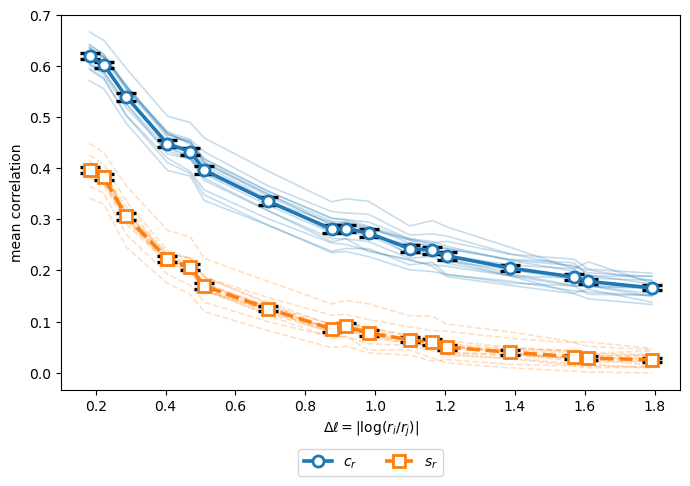

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/mainS3.pdf
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/mainS3.png


In [132]:
# ------------------------------------------------------------
# CLEAN SUPP FIGURE S3 ONLY
# ------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.close("all")

fig, ax = plt.subplots(figsize=(7.0, 5.4))

for y in c_decay_each:
    ax.plot(x_decay, y, color="C0", lw=1.2, alpha=0.25)
for y in s_decay_each:
    ax.plot(x_decay, y, color="C1", lw=1.2, alpha=0.25, ls="--")

c_mean = c_decay_each.mean(axis=0)
s_mean = s_decay_each.mean(axis=0)
c_sem  = sem(c_decay_each, axis=0)
s_sem  = sem(s_decay_each, axis=0)

# black error bars first
ax.errorbar(x_decay, c_mean, yerr=c_sem, fmt="none",
            ecolor="k", elinewidth=2.4, capsize=7, capthick=2.4, zorder=4)
ax.errorbar(x_decay, s_mean, yerr=s_sem, fmt="none",
            ecolor="k", elinewidth=2.4, capsize=7, capthick=2.4, zorder=4)

# open markers + colored lines on top
ax.plot(x_decay, c_mean, color="C0", lw=2.6, marker="o", ms=8,
        mfc="white", mec="C0", mew=2.0, zorder=5)
ax.plot(x_decay, s_mean, color="C1", lw=2.6, marker="s", ms=8, ls="--",
        mfc="white", mec="C1", mew=2.0, zorder=5)

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")

legend_handles = [
    Line2D([0], [0], color="C0", lw=2.6, marker="o", ms=8, mfc="white", mec="C0", mew=2.0, label=r"$c_r$"),
    Line2D([0], [0], color="C1", lw=2.6, marker="s", ms=8, mfc="white", mec="C1", mew=2.0, ls="--", label=r"$s_r$"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.14),
          ncol=2, frameon=True, fontsize=10)

fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(out_dir / "mainS3.pdf", bbox_inches="tight")
fig.savefig(out_dir / "mainS3.png", dpi=220, bbox_inches="tight")
plt.show()

print("saved:", out_dir / "mainS3.pdf")
print("saved:", out_dir / "mainS3.png")

In [133]:
from pathlib import Path
from IPython.display import display, IFrame, HTML

fig_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15")

pdfs = [
    "main1.pdf",
    "main2A.pdf",
    "main2B.pdf",
    "main2C.pdf",
    "ensemble_crossscale_and_surrogates_320cubes.pdf",
    "mainS1A.pdf",
    "mainS1B.pdf",
    "mainS2.pdf",
    "mainS3.pdf",
]

for name in pdfs:
    path = fig_dir / name
    print(path.exists(), path)
    if path.exists():
        display(HTML(f"<h3>{name}</h3>"))
        display(IFrame(src=str(path), width=900, height=650))

True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/main1.pdf


True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/main2A.pdf


True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/main2B.pdf


True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/main2C.pdf


True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/ensemble_crossscale_and_surrogates_320cubes.pdf


True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/mainS1A.pdf


True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/mainS1B.pdf


True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/mainS2.pdf


True /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/mainS3.pdf


In [134]:
from pathlib import Path
import shutil

src_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15")
dst_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks")
dst_dir.mkdir(parents=True, exist_ok=True)

files = [
    "main1.pdf", "main1.png",
    "main2A.pdf", "main2A.png",
    "main2B.pdf", "main2B.png",
    "main2C.pdf", "main2C.png",
    "ensemble_crossscale_and_surrogates_320cubes.pdf",
    "ensemble_crossscale_and_surrogates_320cubes.png",
    "mainS1A.pdf", "mainS1A.png",
    "mainS1B.pdf", "mainS1B.png",
    "mainS2.pdf", "mainS2.png",
    "mainS3.pdf", "mainS3.png",
]

for name in files:
    src = src_dir / name
    dst = dst_dir / name
    if src.exists():
        shutil.copy2(src, dst)
        print("copied:", dst)
    else:
        print("missing:", src)

copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/main1.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/main1.png
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/main2A.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/main2A.png
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/main2B.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/main2B.png
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/main2C.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/main2C.png
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/ensemble_crossscale_and_surrogates_320cubes.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/ensemble_crossscale_and_surrogates_320cubes.png
copied: /home/idies/workspac

In [135]:
import json
import itertools
from pathlib import Path

import numpy as np
import pandas as pd

# ============================================================
# paths
# ============================================================
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
manifest_path = base_dir / "manifests" / "manifest_15_random_nonoverlap_320_1based_seed20260421.csv"
out_dir = processed_dir / "tables_new15"
out_dir.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(manifest_path)

# ============================================================
# helpers
# ============================================================
def make_raw_names(rec):
    vel = f"mhd1024_velocity_t{int(rec.t):04d}_x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    mag = f"mhd1024_magneticfield_t{int(rec.t):04d}_x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    return vel, mag

def load_matching_records():
    wanted = {}
    for rec in manifest.itertuples(index=False):
        vel_name, mag_name = make_raw_names(rec)
        wanted[(vel_name, mag_name)] = {"cube_id": rec.cube_id, "t": int(rec.t)}

    records = []
    missing = []

    for (vel_name, mag_name), meta in wanted.items():
        candidates = []
        for path in processed_dir.rglob("*.json"):
            try:
                with open(path, "r") as f:
                    d = json.load(f)
            except Exception:
                continue
            if not isinstance(d, dict):
                continue
            rf = d.get("raw_files", {})
            if not isinstance(rf, dict):
                continue
            v = Path(str(rf.get("velocity", ""))).name
            b = Path(str(rf.get("magneticfield", ""))).name
            if v == vel_name and b == mag_name:
                candidates.append(path)

        if len(candidates) == 0:
            missing.append((meta["cube_id"], vel_name, mag_name))
            continue

        chosen = max(candidates, key=lambda p: p.stat().st_mtime)
        with open(chosen, "r") as f:
            d = json.load(f)

        records.append({
            "cube_id": meta["cube_id"],
            "t": meta["t"],
            "json_path": chosen,
            "data": d,
        })

    records = sorted(records, key=lambda r: r["cube_id"])
    return records, missing

def get_curve(d, names):
    n = len(d["scales"])
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float).squeeze()
            if arr.ndim == 1 and arr.size == n:
                return arr
    raise KeyError(f"Missing curve among {names}. Keys: {list(d.keys())}")

def get_matrix(d, names):
    n = len(d["scales"])
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float)
            if arr.shape == (n, n):
                return arr
    raise KeyError(f"Missing matrix among {names}. Keys: {list(d.keys())}")

def get_surrogate_mean(d, obs_kind, stat_kind):
    ss = d["surrogate_summary"]

    obs_candidates = {
        "c": ["pearson_c", "c"],
        "s": ["pearson_s", "s"],
    }[obs_kind]

    stat_candidates = {
        "full": ["full_shuffle"],
        "Abin": ["A_bin_shuffle", "Ar_bin_shuffle", "A_r_bin_shuffle"],
        "jbin": ["j_bin_shuffle", "|j|_bin_shuffle"],
    }[stat_kind]

    for ok in obs_candidates:
        if ok in ss:
            block = ss[ok]
            for sk in stat_candidates:
                if sk in block:
                    entry = block[sk]
                    if isinstance(entry, dict) and "mean" in entry:
                        return float(entry["mean"])
                    return float(entry)
    raise KeyError(f"Missing surrogate summary for obs={obs_kind}, stat={stat_kind}")

def offdiag_mean(mat):
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(mat.shape[0], k=1)
    return float(np.nanmean(mat[iu]))

def bootstrap_ci_mean(x, n_boot=20000, seed=12345):
    x = np.asarray(x, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    boots = x[idx].mean(axis=1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(lo), float(hi)

def exact_signflip_pvalue(x):
    """
    Two-sided exact sign-flip randomization p-value
    for H0: ensemble mean = 0, using cubes as units.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    obs = abs(np.mean(x))

    # all 2^n sign patterns
    signs = np.array(list(itertools.product([-1.0, 1.0], repeat=n)), dtype=float)
    means = np.abs((signs * x[None, :]).mean(axis=1))
    p = np.mean(means >= obs - 1e-15)
    return float(p)

def fmt_ci(lo, hi, angle=False):
    if angle:
        return f"[{lo:.2f},\\,{hi:.2f}]^\\circ"
    return f"[{lo:.3f},\\,{hi:.3f}]"

def fmt_num(x, angle=False):
    if angle:
        return f"{x:.2f}^\\circ"
    return f"{x:.3f}"

def latex_p(x):
    if x == 0:
        return "0"
    if x < 1e-3:
        # compact scientific
        exp = int(np.floor(np.log10(abs(x))))
        mant = x / (10**exp)
        return f"{mant:.2f}\\times10^{{{exp}}}"
    return f"{x:.3f}"

# ============================================================
# load records
# ============================================================
records, missing = load_matching_records()
print("Matched processed JSONs:", len(records))
for r in records:
    print(f"  {r['cube_id']} <- {r['json_path'].name}")

if missing:
    print("\nMISSING:")
    for m in missing:
        print(" ", m)

assert len(records) == 15, "Need all 15 processed JSONs before making tables."

# ============================================================
# assemble per-cube quantities
# ============================================================
scales = np.asarray(records[0]["data"]["scales"], dtype=int)
scale_to_idx = {int(r): i for i, r in enumerate(scales)}

mean_all = np.vstack([get_curve(r["data"], ["mean_all_phi_deg", "mean_all_deg"]) for r in records])
mean_A   = np.vstack([get_curve(r["data"], ["mean_A_phi_deg", "mean_A_deg"]) for r in records])
mean_J   = np.vstack([get_curve(r["data"], ["mean_J_phi_deg", "mean_J_deg"]) for r in records])

pearson_c = np.stack([get_matrix(r["data"], ["pearson_c"]) for r in records], axis=0)
pearson_s = np.stack([get_matrix(r["data"], ["pearson_s"]) for r in records], axis=0)
spearman_c = np.stack([get_matrix(r["data"], ["spearman_c"]) for r in records], axis=0)
spearman_s = np.stack([get_matrix(r["data"], ["spearman_s"]) for r in records], axis=0)

# inertial-range averages (over the 9 scales already used)
all_ir = mean_all.mean(axis=1)
A_ir   = mean_A.mean(axis=1)
J_ir   = mean_J.mean(axis=1)

Rc_real = np.array([offdiag_mean(m) for m in pearson_c], dtype=float)
Rs_real = np.array([offdiag_mean(m) for m in pearson_s], dtype=float)

Rc_full = np.array([get_surrogate_mean(r["data"], "c", "full") for r in records], dtype=float)
Rs_full = np.array([get_surrogate_mean(r["data"], "s", "full") for r in records], dtype=float)
Rc_Abin = np.array([get_surrogate_mean(r["data"], "c", "Abin") for r in records], dtype=float)
Rs_Abin = np.array([get_surrogate_mean(r["data"], "s", "Abin") for r in records], dtype=float)
Rc_jbin = np.array([get_surrogate_mean(r["data"], "c", "jbin") for r in records], dtype=float)
Rs_jbin = np.array([get_surrogate_mean(r["data"], "s", "jbin") for r in records], dtype=float)

# ============================================================
# TABLE I
# ============================================================
table1_items = [
    ("Mean unsigned angle, all points (inertial-range average)", all_ir, True),
    (r"Mean unsigned angle, top 10\% by $A_r$ (inertial-range average)", A_ir, True),
    (r"Mean unsigned angle, top 10\% by $|j|$ (inertial-range average)", J_ir, True),
    (r"Mean off-diagonal $R_c$ (real data)", Rc_real, False),
    (r"Mean off-diagonal $R_s$ (real data)", Rs_real, False),
    (r"Mean off-diagonal $R_c$ (full shuffle)", Rc_full, False),
    (r"Mean off-diagonal $R_s$ (full shuffle)", Rs_full, False),
    (r"Mean off-diagonal $R_c$ ($A_r$-bin shuffle)", Rc_Abin, False),
    (r"Mean off-diagonal $R_s$ ($A_r$-bin shuffle)", Rs_Abin, False),
    (r"Mean off-diagonal $R_c$ ($|j|$-bin shuffle)", Rc_jbin, False),
    (r"Mean off-diagonal $R_s$ ($|j|$-bin shuffle)", Rs_jbin, False),
]

table1_rows = []
for label, vals, is_angle in table1_items:
    mu = float(np.mean(vals))
    lo, hi = bootstrap_ci_mean(vals, n_boot=20000, seed=12345)
    table1_rows.append({
        "Quantity": label,
        "Ensemble mean": f"{mu:.2f}°" if is_angle else f"{mu:.3f}",
        "95% CI": f"[{lo:.2f}, {hi:.2f}]°" if is_angle else f"[{lo:.3f}, {hi:.3f}]",
        "_mu": mu,
        "_lo": lo,
        "_hi": hi,
        "_is_angle": is_angle,
    })

table1_df = pd.DataFrame(table1_rows)[["Quantity", "Ensemble mean", "95% CI"]]
print("\nTABLE I")
print(table1_df.to_string(index=False))

# ============================================================
# TABLE II
# ============================================================
pair_specs = [(64, 96), (48, 160)]

table2_rows = []
for r1, r2 in pair_specs:
    i = scale_to_idx[r1]
    j = scale_to_idx[r2]

    vals = [
        (r"$c_r$", pearson_c[:, i, j], spearman_c[:, i, j]),
        (r"$s_r$", pearson_s[:, i, j], spearman_s[:, i, j]),
    ]

    for obs_label, pvals, svals in vals:
        p_mu = float(np.mean(pvals))
        s_mu = float(np.mean(svals))

        p_lo, p_hi = bootstrap_ci_mean(pvals, n_boot=20000, seed=12345 + i + 10*j)
        s_lo, s_hi = bootstrap_ci_mean(svals, n_boot=20000, seed=54321 + i + 10*j)

        p_p = exact_signflip_pvalue(pvals)
        p_s = exact_signflip_pvalue(svals)

        table2_rows.append({
            "Observable": obs_label,
            "Scale pair": f"({r1},{r2})",
            "Pearson": f"{p_mu:.3f}",
            "Spearman": f"{s_mu:.3f}",
            "95% CI (Pearson)": f"[{p_lo:.3f}, {p_hi:.3f}]",
            "95% CI (Spearman)": f"[{s_lo:.3f}, {s_hi:.3f}]",
            "p_P": latex_p(p_p),
            "p_S": latex_p(p_s),
            "_p_mu": p_mu, "_s_mu": s_mu,
            "_p_lo": p_lo, "_p_hi": p_hi,
            "_s_lo": s_lo, "_s_hi": s_hi,
            "_p_p": p_p, "_p_s": p_s,
        })

table2_df = pd.DataFrame(table2_rows)[[
    "Observable", "Scale pair", "Pearson", "Spearman",
    "95% CI (Pearson)", "95% CI (Spearman)", "p_P", "p_S"
]]
print("\nTABLE II")
print(table2_df.to_string(index=False))

# ============================================================
# save CSVs
# ============================================================
table1_csv = out_dir / "table1_new15.csv"
table2_csv = out_dir / "table2_new15.csv"
table1_df.to_csv(table1_csv, index=False)
table2_df.to_csv(table2_csv, index=False)

# ============================================================
# save LaTeX rows
# ============================================================
table1_tex = out_dir / "table1_rows_new15.tex"
with open(table1_tex, "w") as f:
    for row in table1_rows:
        is_angle = row["_is_angle"]
        f.write(
            f"{row['Quantity']} & "
            f"{fmt_num(row['_mu'], angle=is_angle)} & "
            f"${fmt_ci(row['_lo'], row['_hi'], angle=is_angle)}$ \\\\\n"
        )

table2_tex = out_dir / "table2_rows_new15.tex"
with open(table2_tex, "w") as f:
    for row in table2_rows:
        f.write(
            f"{row['Observable']} & "
            f"${row['Scale pair']}$ & "
            f"{row['_p_mu']:.3f} & "
            f"{row['_s_mu']:.3f} & "
            f"$[{row['_p_lo']:.3f},\\,{row['_p_hi']:.3f}]$ & "
            f"$[{row['_s_lo']:.3f},\\,{row['_s_hi']:.3f}]$ & "
            f"${latex_p(row['_p_p'])}$ & "
            f"${latex_p(row['_p_s'])}$ \\\\\n"
        )

print("\nSaved:")
print(table1_csv)
print(table2_csv)
print(table1_tex)
print(table2_tex)

Matched processed JSONs: 15
  C01 <- C01_t0218_xyplane_interp_r32_192.json
  C02 <- C02_t0553_xyplane_interp_r32_192.json
  C03 <- C03_t0825_xyplane_interp_r32_192.json
  C04 <- C04_t0217_xyplane_interp_r32_192.json
  C05 <- C05_t0493_xyplane_interp_r32_192.json
  C06 <- C06_t0022_xyplane_interp_r32_192.json
  C07 <- C07_t0292_xyplane_interp_r32_192.json
  C08 <- C08_t0976_xyplane_interp_r32_192.json
  C09 <- C09_t0699_xyplane_interp_r32_192.json
  C10 <- C10_t0778_xyplane_interp_r32_192.json
  C11 <- C11_t0843_xyplane_interp_r32_192.json
  C12 <- C12_t0273_xyplane_interp_r32_192.json
  C13 <- C13_t0539_xyplane_interp_r32_192.json
  C14 <- C14_t0302_xyplane_interp_r32_192.json
  C15 <- C15_t0118_xyplane_interp_r32_192.json

TABLE I
                                                       Quantity Ensemble mean          95% CI
       Mean unsigned angle, all points (inertial-range average)        49.47° [49.02, 49.93]°
Mean unsigned angle, top 10\% by $A_r$ (inertial-range average)       

In [136]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
base_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024")
processed_dir = base_dir / "processed"
manifest_path = base_dir / "manifests" / "manifest_15_random_nonoverlap_320_1based_seed20260421.csv"
large_path = processed_dir / "largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json"

out_dir = processed_dir / "final_figures_new15"
out_dir.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(manifest_path)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def make_raw_names(rec):
    vel = f"mhd1024_velocity_t{int(rec.t):04d}_x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    mag = f"mhd1024_magneticfield_t{int(rec.t):04d}_x{int(rec.x0)}-{int(rec.x1)}_y{int(rec.y0)}-{int(rec.y1)}_z{int(rec.z0)}-{int(rec.z1)}.npy"
    return vel, mag

def get_curve(d, names):
    n = len(d["scales"])
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float).squeeze()
            if arr.ndim == 1 and arr.size == n:
                return arr
    raise KeyError(f"Missing curve among {names}. Keys: {list(d.keys())}")

def get_matrix(d, names):
    n = len(d["scales"])
    for k in names:
        if k in d:
            arr = np.asarray(d[k], dtype=float)
            if arr.shape == (n, n):
                return arr
    raise KeyError(f"Missing matrix among {names}. Keys: {list(d.keys())}")

def get_baseline(d):
    for k in ["random_unsigned_3d_baseline_deg", "random_3d_baseline_deg"]:
        if k in d:
            return float(d[k])
    raise KeyError("Missing random baseline.")

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = a.shape[axis]
    return np.nanstd(a, axis=axis, ddof=1) / np.sqrt(n)

def decay_curve(scales, mat):
    scales = np.asarray(scales, dtype=float)
    mat = np.asarray(mat, dtype=float)
    iu = np.triu_indices(len(scales), k=1)
    dlog = np.abs(np.log(scales[iu[0]] / scales[iu[1]]))
    vals = mat[iu]
    good = np.isfinite(vals)
    dlog, vals = dlog[good], vals[good]

    tags = np.round(dlog, 12)
    uniq = np.unique(tags)

    x, y = [], []
    for u in uniq:
        sel = tags == u
        x.append(dlog[sel].mean())
        y.append(vals[sel].mean())
    return np.asarray(x), np.asarray(y)

# ------------------------------------------------------------
# match new 15 processed JSONs
# ------------------------------------------------------------
wanted = {}
for rec in manifest.itertuples(index=False):
    vel_name, mag_name = make_raw_names(rec)
    wanted[(vel_name, mag_name)] = rec.cube_id

records = []
for path in processed_dir.rglob("*.json"):
    try:
        with open(path, "r") as f:
            d = json.load(f)
    except Exception:
        continue
    if not isinstance(d, dict):
        continue
    rf = d.get("raw_files", {})
    if not isinstance(rf, dict):
        continue
    vel = Path(str(rf.get("velocity", ""))).name
    mag = Path(str(rf.get("magneticfield", ""))).name
    key = (vel, mag)
    if key in wanted:
        records.append((wanted[key], path, d))

# keep newest if duplicates
best = {}
for cube_id, path, d in records:
    if cube_id not in best or path.stat().st_mtime > best[cube_id][0].stat().st_mtime:
        best[cube_id] = (path, d)

records = [(cid, best[cid][0], best[cid][1]) for cid in sorted(best.keys())]
print("matched new-cube processed JSONs:", len(records))
for cid, path, _ in records:
    print(" ", cid, "<-", path.name)

assert len(records) == 15, "Need all 15 processed JSONs."

# ------------------------------------------------------------
# ensemble arrays from new 15
# ------------------------------------------------------------
scales = np.asarray(records[0][2]["scales"], dtype=float)
baseline = get_baseline(records[0][2])

mean_all = np.vstack([get_curve(d, ["mean_all_phi_deg", "mean_all_deg"]) for _, _, d in records])
mean_A   = np.vstack([get_curve(d, ["mean_A_phi_deg", "mean_A_deg"]) for _, _, d in records])
mean_J   = np.vstack([get_curve(d, ["mean_J_phi_deg", "mean_J_deg"]) for _, _, d in records])

pearson_c = np.stack([get_matrix(d, ["pearson_c"]) for _, _, d in records], axis=0)
pearson_s = np.stack([get_matrix(d, ["pearson_s"]) for _, _, d in records], axis=0)

# ------------------------------------------------------------
# large cube
# ------------------------------------------------------------
with open(large_path, "r") as f:
    large = json.load(f)

scales_L = np.asarray(large["scales"], dtype=float)
assert np.array_equal(scales, scales_L), "Scale grids do not match."

large_all = get_curve(large, ["mean_all_phi_deg", "mean_all_deg"])
large_A   = get_curve(large, ["mean_A_phi_deg", "mean_A_deg"])
large_J   = get_curve(large, ["mean_J_phi_deg", "mean_J_deg"])

large_pc = get_matrix(large, ["pearson_c"])
large_ps = get_matrix(large, ["pearson_s"])

# decay curves
x_decay = None
c_decay_each = []
s_decay_each = []

for mc, ms in zip(pearson_c, pearson_s):
    xc, yc = decay_curve(scales, mc)
    xs, ys = decay_curve(scales, ms)
    if x_decay is None:
        x_decay = xc
    c_decay_each.append(yc)
    s_decay_each.append(ys)

c_decay_each = np.vstack(c_decay_each)
s_decay_each = np.vstack(s_decay_each)

xL_c, yL_c = decay_curve(scales, large_pc)
xL_s, yL_s = decay_curve(scales, large_ps)

print("\nready for 448^3 comparison plots")

matched new-cube processed JSONs: 15
  C01 <- C01_t0218_xyplane_interp_r32_192.json
  C02 <- C02_t0553_xyplane_interp_r32_192.json
  C03 <- C03_t0825_xyplane_interp_r32_192.json
  C04 <- C04_t0217_xyplane_interp_r32_192.json
  C05 <- C05_t0493_xyplane_interp_r32_192.json
  C06 <- C06_t0022_xyplane_interp_r32_192.json
  C07 <- C07_t0292_xyplane_interp_r32_192.json
  C08 <- C08_t0976_xyplane_interp_r32_192.json
  C09 <- C09_t0699_xyplane_interp_r32_192.json
  C10 <- C10_t0778_xyplane_interp_r32_192.json
  C11 <- C11_t0843_xyplane_interp_r32_192.json
  C12 <- C12_t0273_xyplane_interp_r32_192.json
  C13 <- C13_t0539_xyplane_interp_r32_192.json
  C14 <- C14_t0302_xyplane_interp_r32_192.json
  C15 <- C15_t0118_xyplane_interp_r32_192.json

ready for 448^3 comparison plots


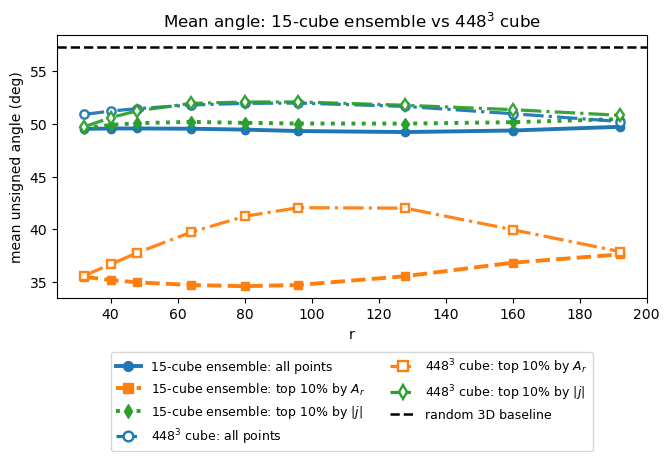

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/Angle448.pdf
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/Angle448.png


In [137]:
plt.close("all")

fig, ax = plt.subplots(figsize=(6.8, 5.5))

# new 15-cube ensemble means
ax.plot(scales, mean_all.mean(axis=0), color="C0", lw=2.8, marker="o", ms=6)
ax.plot(scales, mean_A.mean(axis=0),   color="C1", lw=2.8, marker="s", ms=6, ls="--")
ax.plot(scales, mean_J.mean(axis=0),   color="C2", lw=2.8, marker="d", ms=6, ls=":")

# 448^3 overlay
ax.plot(scales, large_all, color="C0", lw=2.3, marker="o", ms=6,
        mfc="white", mec="C0", mew=1.7, ls="-.", alpha=0.95)
ax.plot(scales, large_A, color="C1", lw=2.3, marker="s", ms=6,
        mfc="white", mec="C1", mew=1.7, ls="-.", alpha=0.95)
ax.plot(scales, large_J, color="C2", lw=2.3, marker="d", ms=6,
        mfc="white", mec="C2", mew=1.7, ls="-.", alpha=0.95)

ax.axhline(baseline, color="k", lw=1.8, ls="--")

ax.set_xlabel("r")
ax.set_ylabel("mean unsigned angle (deg)")
ax.set_title(r"Mean angle: 15-cube ensemble vs $448^3$ cube")

legend_handles = [
    Line2D([0], [0], color="C0", lw=2.8, marker="o", ms=7, label="15-cube ensemble: all points"),
    Line2D([0], [0], color="C1", lw=2.8, marker="s", ms=7, ls="--", label=r"15-cube ensemble: top 10% by $A_r$"),
    Line2D([0], [0], color="C2", lw=2.8, marker="d", ms=7, ls=":", label=r"15-cube ensemble: top 10% by $|j|$"),
    Line2D([0], [0], color="C0", lw=2.3, marker="o", ms=7, mfc="white", mec="C0", mew=1.7, ls="-.", label=r"$448^3$ cube: all points"),
    Line2D([0], [0], color="C1", lw=2.3, marker="s", ms=7, mfc="white", mec="C1", mew=1.7, ls="-.", label=r"$448^3$ cube: top 10% by $A_r$"),
    Line2D([0], [0], color="C2", lw=2.3, marker="d", ms=7, mfc="white", mec="C2", mew=1.7, ls="-.", label=r"$448^3$ cube: top 10% by $|j|$"),
    Line2D([0], [0], color="k", lw=1.8, ls="--", label=r"random 3D baseline"),
]

ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.18),
          ncol=2, frameon=True, fontsize=9)

fig.tight_layout(rect=[0, 0.09, 1, 1])
fig.savefig(out_dir / "Angle448.pdf", bbox_inches="tight")
fig.savefig(out_dir / "Angle448.png", dpi=220, bbox_inches="tight")
plt.show()

print("saved:", out_dir / "Angle448.pdf")
print("saved:", out_dir / "Angle448.png")

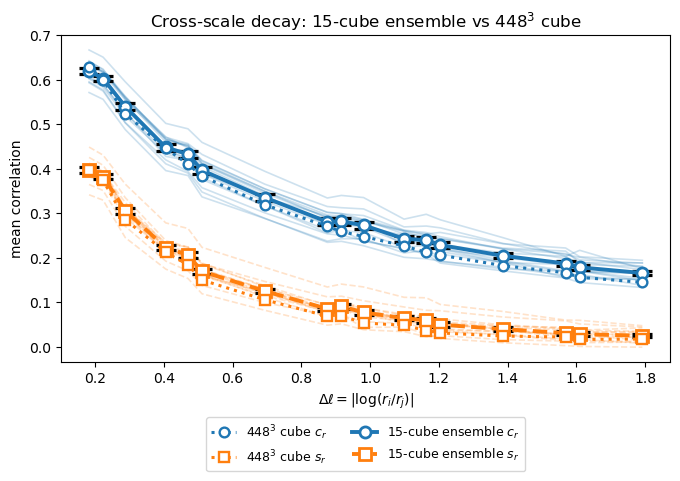

saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/Correlation448.pdf
saved: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15/Correlation448.png


In [138]:
plt.close("all")

fig, ax = plt.subplots(figsize=(6.9, 5.5))

# faint individual cubes
for y in c_decay_each:
    ax.plot(x_decay, y, color="C0", lw=1.2, alpha=0.22)
for y in s_decay_each:
    ax.plot(x_decay, y, color="C1", lw=1.2, alpha=0.22, ls="--")

c_mean = c_decay_each.mean(axis=0)
s_mean = s_decay_each.mean(axis=0)
c_sem  = sem(c_decay_each, axis=0)
s_sem  = sem(s_decay_each, axis=0)

# visible black error bars first
ax.errorbar(x_decay, c_mean, yerr=c_sem, fmt="none",
            ecolor="k", elinewidth=2.3, capsize=7, capthick=2.3, zorder=4)
ax.errorbar(x_decay, s_mean, yerr=s_sem, fmt="none",
            ecolor="k", elinewidth=2.3, capsize=7, capthick=2.3, zorder=4)

# ensemble means on top
ax.plot(x_decay, c_mean, color="C0", lw=2.8, marker="o", ms=8,
        mfc="white", mec="C0", mew=2.0, zorder=5)
ax.plot(x_decay, s_mean, color="C1", lw=2.8, marker="s", ms=8, ls="--",
        mfc="white", mec="C1", mew=2.0, zorder=5)

# 448^3 overlay
ax.plot(xL_c, yL_c, color="C0", lw=2.2, marker="o", ms=7, ls=":",
        mfc="white", mec="C0", mew=1.7, zorder=6)
ax.plot(xL_s, yL_s, color="C1", lw=2.2, marker="s", ms=7, ls=":",
        mfc="white", mec="C1", mew=1.7, zorder=6)

ax.set_xlabel(r"$\Delta \ell = |\log(r_i/r_j)|$")
ax.set_ylabel("mean correlation")
ax.set_title(r"Cross-scale decay: 15-cube ensemble vs $448^3$ cube")

legend_handles = [
    Line2D([0], [0], color="C0", lw=2.2, marker="o", ms=7, mfc="white", mec="C0", mew=1.7, ls=":", label=r"$448^3$ cube $c_r$"),
    Line2D([0], [0], color="C1", lw=2.2, marker="s", ms=7, mfc="white", mec="C1", mew=1.7, ls=":", label=r"$448^3$ cube $s_r$"),
    Line2D([0], [0], color="C0", lw=2.8, marker="o", ms=8, mfc="white", mec="C0", mew=2.0, label=r"15-cube ensemble $c_r$"),
    Line2D([0], [0], color="C1", lw=2.8, marker="s", ms=8, mfc="white", mec="C1", mew=2.0, ls="--", label=r"15-cube ensemble $s_r$"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=2, frameon=True, fontsize=9)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(out_dir / "Correlation448.pdf", bbox_inches="tight")
fig.savefig(out_dir / "Correlation448.png", dpi=220, bbox_inches="tight")
plt.show()

print("saved:", out_dir / "Correlation448.pdf")
print("saved:", out_dir / "Correlation448.png")


In [139]:
from pathlib import Path
import shutil

src_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15")
dst_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks")
dst_dir.mkdir(parents=True, exist_ok=True)

files = [
    "Angle448.pdf", "Angle448.png",
    "Correlation448.pdf", "Correlation448.png",
]

for name in files:
    src = src_dir / name
    dst = dst_dir / name
    if src.exists():
        shutil.copy2(src, dst)
        print("copied:", dst)
    else:
        print("missing:", src)


copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/Angle448.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/Angle448.png
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/Correlation448.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/Correlation448.png


In [140]:
from pathlib import Path
import shutil

src_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/processed/final_figures_new15")
dst_dir = Path("/home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/final_figures_new15")
dst_dir.mkdir(parents=True, exist_ok=True)

for name in ["Angle448.pdf", "Angle448.png", "Correlation448.pdf", "Correlation448.png"]:
    src = src_dir / name
    dst = dst_dir / name
    if src.exists():
        shutil.copy2(src, dst)
        print("copied:", dst)
    else:
        print("missing:", src)

copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/final_figures_new15/Angle448.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/final_figures_new15/Angle448.png
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/final_figures_new15/Correlation448.pdf
copied: /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/notebooks/final_figures_new15/Correlation448.png


In [ ]:
mkdir -p /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024/github_export

cd /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024

# manuscript source: adjust these names if needed
cp -f notebooks/*.tex github_export/ 2>/dev/null
cp -f notebooks/*.bib github_export/ 2>/dev/null
cp -f notebooks/*.bst github_export/ 2>/dev/null
cp -f notebooks/*.cls github_export/ 2>/dev/null
cp -f notebooks/*.sty github_export/ 2>/dev/null

# figures
mkdir -p github_export/final_figures
cp -f processed/final_figures_new15/main1.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/main2A.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/main2B.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/main2C.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/mainS1A.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/mainS1B.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/mainS2.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/mainS3.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/Angle448.* github_export/final_figures/ 2>/dev/null
cp -f processed/final_figures_new15/Correlation448.* github_export/final_figures/ 2>/dev/null

# tables
mkdir -p github_export/tables
cp -f processed/tables_new15/* github_export/tables/ 2>/dev/null

# processed summaries
mkdir -p github_export/processed_json
cp -f processed/largecube_t0057_x289-736_y289-736_z289-736_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C0*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C1*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C2*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C3*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C4*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C5*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C6*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C7*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C8*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null
cp -f processed/*C9*_xyplane_interp_r32_192.json github_export/processed_json/ 2>/dev/null

# manifests / audits
mkdir -p github_export/manifests
cp -f manifests/* github_export/manifests/ 2>/dev/null
cp -f raw/audit_15_random_nonoverlap_1based_seed20260421.csv github_export/manifests/ 2>/dev/null

# optionally keep your notebook history file
cp -f processed/ipython_history_2026-04-21.py github_export/ 2>/dev/null

# zip everything
cd /home/idies/workspace/Storage/elenceq/mhd_work/jhtdb_mhd1024
zip -r github_export.zip github_export